<a href="https://colab.research.google.com/github/sets1623/AI-SmartGrid-Forecasting/blob/main/GRIDMIND_AI_01_Electrical_Grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GRIDMIND AI
# AI-Based Predictive Self-Healing Smart Distribution Grid
# Step 1: Electrical Grid Model

In [ ]:
!pip install pandapower -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 10.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import pandapower as pp
import pandapower.networks as pn

print("pandapower imported successfully!")

pandapower imported successfully!


In [ ]:
import pandapower as pp

# Create empty network
net = pp.create_empty_network()

print("GridMind AI electrical network created!")


GridMind AI electrical network created!


In [ ]:
# Create 5 buses
bus1 = pp.create_bus(net, vn_kv=110, name="Grid Bus")
bus2 = pp.create_bus(net, vn_kv=20, name="Distribution Bus")
bus3 = pp.create_bus(net, vn_kv=20, name="Residential Bus")
bus4 = pp.create_bus(net, vn_kv=20, name="Industrial Bus")
bus5 = pp.create_bus(net, vn_kv=20, name="Commercial Bus")

print("5 buses created successfully!")

5 buses created successfully!


In [ ]:
# Create the external grid connection
ext_grid = pp.create_ext_grid(
    net,
    bus=bus1,
    vm_pu=1.0,
    name="Main Grid"
)

print("Main grid connection created!")

Main grid connection created!


In [ ]:
# Create transformer from 110 kV to 20 kV
trafo = pp.create_transformer_from_parameters(
    net,
    hv_bus=bus1,
    lv_bus=bus2,
    sn_mva=40,
    vn_hv_kv=110,
    vn_lv_kv=20,
    vk_percent=12,
    vkr_percent=0.5,
    pfe_kw=30,
    i0_percent=0.1,
    name="Distribution Transformer"
)

print("Transformer created successfully!")

Transformer created successfully!


In [ ]:
# Create distribution lines

line1 = pp.create_line_from_parameters(
    net,
    from_bus=bus2,
    to_bus=bus3,
    length_km=5,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Line 1"
)

line2 = pp.create_line_from_parameters(
    net,
    from_bus=bus2,
    to_bus=bus4,
    length_km=4,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Line 2"
)

line3 = pp.create_line_from_parameters(
    net,
    from_bus=bus2,
    to_bus=bus5,
    length_km=3,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Line 3"
)

print("Distribution lines created!")

Distribution lines created!


In [ ]:
pp.create_load(
    net,
    bus=bus3,
    p_mw=2,
    q_mvar=0.6,
    name="Residential Load"
)

np.int64(0)

In [ ]:
pp.create_load(
    net,
    bus=bus4,
    p_mw=5,
    q_mvar=1.5,
    name="Industrial Load"
)

np.int64(1)

In [ ]:
pp.create_load(
    net,
    bus=bus5,
    p_mw=3,
    q_mvar=1.0,
    name="Commercial Load"
)

print("All loads created!")

All loads created!


In [ ]:
pp.runpp(net)

print("Power flow completed successfully!")

Power flow completed successfully!


In [ ]:
print(net.res_bus[["vm_pu", "va_degree"]])

      vm_pu  va_degree
0  1.000000   0.000000
1  0.988357  -1.731498
2  0.980172  -2.234670
3  0.971746  -2.745990
4  0.980685  -2.175007


In [ ]:
print(net.res_line[["loading_percent", "p_from_mw", "q_from_mvar"]])

   loading_percent  p_from_mw  q_from_mvar
0        15.374118   2.011336     0.616585
1        38.768559   5.057700     1.610572
2        23.271256   3.015591     1.027528


In [ ]:
print(net.res_trafo[["loading_percent", "p_hv_mw", "q_hv_mvar"]])

   loading_percent    p_hv_mw  q_hv_mvar
0        26.895908  10.128689   3.626572


In [ ]:
print("===== GRIDMIND AI NETWORK CHECK =====")

print("Buses:", len(net.bus))
print("Lines:", len(net.line))
print("Transformers:", len(net.trafo))
print("Loads:", len(net.load))
print("External Grid:", len(net.ext_grid))

===== GRIDMIND AI NETWORK CHECK =====
Buses: 5
Lines: 3
Transformers: 1
Loads: 3
External Grid: 1


In [ ]:
print(net.res_bus[["vm_pu", "va_degree"]])

print(net.res_line[["loading_percent", "p_from_mw", "q_from_mvar"]])

print(net.res_trafo[["loading_percent", "p_hv_mw", "q_hv_mvar"]])

      vm_pu  va_degree
0  1.000000   0.000000
1  0.988357  -1.731498
2  0.980172  -2.234670
3  0.971746  -2.745990
4  0.980685  -2.175007
   loading_percent  p_from_mw  q_from_mvar
0        15.374118   2.011336     0.616585
1        38.768559   5.057700     1.610572
2        23.271256   3.015591     1.027528
   loading_percent    p_hv_mw  q_hv_mvar
0        26.895908  10.128689   3.626572


In [ ]:
import random
import pandas as pd

results = []

for i in range(100):

    # Randomly change the loads
    residential_load = random.uniform(1.0, 4.0)
    industrial_load = random.uniform(3.0, 9.0)
    commercial_load = random.uniform(1.5, 6.0)

    # Update the loads
    net.load.loc[0, "p_mw"] = residential_load
    net.load.loc[1, "p_mw"] = industrial_load
    net.load.loc[2, "p_mw"] = commercial_load

    # Run power flow
    try:
        pp.runpp(net)

        # Extract electrical measurements
        row = {
            "scenario": i + 1,

            "residential_load_mw": residential_load,
            "industrial_load_mw": industrial_load,
            "commercial_load_mw": commercial_load,

            "bus1_voltage_pu": net.res_bus.loc[0, "vm_pu"],
            "bus2_voltage_pu": net.res_bus.loc[1, "vm_pu"],
            "bus3_voltage_pu": net.res_bus.loc[2, "vm_pu"],
            "bus4_voltage_pu": net.res_bus.loc[3, "vm_pu"],
            "bus5_voltage_pu": net.res_bus.loc[4, "vm_pu"],

            "max_line_loading_percent": net.res_line["loading_percent"].max(),

            "transformer_loading_percent": net.res_trafo["loading_percent"].max(),

            "total_active_power_loss_mw": net.res_line["pl_mw"].sum(),

            "total_reactive_power_loss_mvar": net.res_line["ql_mvar"].sum()
        }

        results.append(row)

    except Exception:
        print("Scenario failed:", i + 1)

# Convert results into a DataFrame
df = pd.DataFrame(results)

print("Dataset generated!")
print("Number of scenarios:", len(df))

Dataset generated!
Number of scenarios: 100


In [ ]:
df.head()

,scenario,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,total_active_power_loss_mw,total_reactive_power_loss_mvar
0,1,3.334607,3.648513,5.423030,1.0,0.987631,0.975907,0.973916,0.976114,40.771050,32.861148,0.110790,0.207053
1,2,3.115253,5.322472,3.008278,1.0,0.987885,0.976751,0.970565,0.980197,41.118203,30.495974,0.106957,0.199380
2,3,2.266681,7.129794,3.543181,1.0,0.987253,0.978359,0.965935,0.978719,54.435620,34.324409,0.149343,0.284179
3,4,2.984630,4.357183,4.963603,1.0,0.987664,0.976874,0.972431,0.976882,37.406236,32.608682,0.109460,0.204392
4,5,1.163460,4.301605,5.087125,1.0,0.988196,0.982186,0.973091,0.977223,38.287844,28.255211,0.090465,0.166357


In [ ]:
df.describe()

,scenario,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,total_active_power_loss_mw,total_reactive_power_loss_mvar
count,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2.618183,6.048474,3.772612,1.0,0.987422,0.977584,0.968454,0.978514,48.014362,33.083812,0.137933,0.261349
std,29.011492,0.918332,1.816292,1.308998,0.0,0.000891,0.002780,0.004766,0.002615,11.915771,5.896336,0.051260,0.102567
min,1.000000,1.004752,3.055476,1.507848,1.0,0.985211,0.972614,0.959672,0.973686,27.068663,20.680148,0.051895,0.089181
25%,25.750000,1.963478,4.588965,2.698512,1.0,0.986826,0.975299,0.963995,0.976254,38.460134,28.967973,0.097199,0.179854
50%,50.500000,2.637644,5.916457,3.645752,1.0,0.987559,0.977527,0.969275,0.978383,45.447400,32.512406,0.126384,0.238257
75%,75.250000,3.404127,7.689993,4.902752,1.0,0.988068,0.979673,0.972410,0.980742,58.665343,36.823604,0.175148,0.335823
max,100.000000,3.985375,8.996851,5.981334,1.0,0.989098,0.983103,0.976249,0.983737,68.554164,46.840688,0.259531,0.504665


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   scenario                        100 non-null    int64  
 1   residential_load_mw             100 non-null    float64
 2   industrial_load_mw              100 non-null    float64
 3   commercial_load_mw              100 non-null    float64
 4   bus1_voltage_pu                 100 non-null    float64
 5   bus2_voltage_pu                 100 non-null    float64
 6   bus3_voltage_pu                 100 non-null    float64
 7   bus4_voltage_pu                 100 non-null    float64
 8   bus5_voltage_pu                 100 non-null    float64
 9   max_line_loading_percent        100 non-null    float64
 10  transformer_loading_percent     100 non-null    float64
 11  total_active_power_loss_mw      100 non-null    float64
 12  total_reactive_power_loss_mvar  100 n

In [ ]:
df.shape

(100, 13)

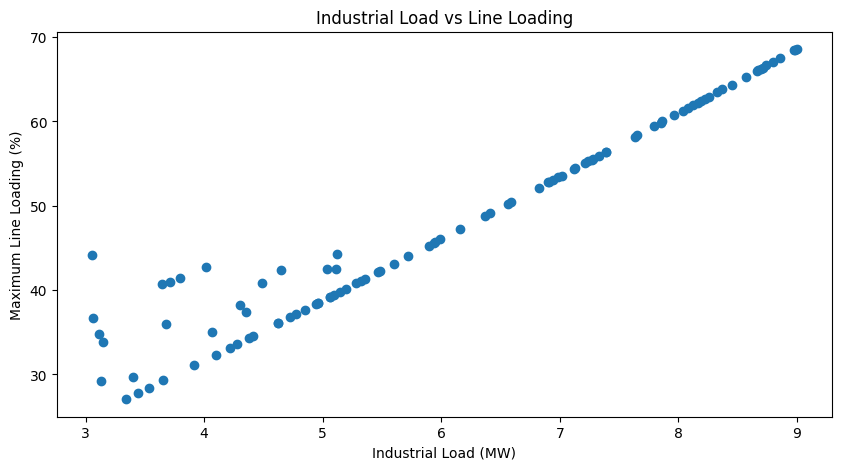

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    df["industrial_load_mw"],
    df["max_line_loading_percent"]
)

plt.xlabel("Industrial Load (MW)")
plt.ylabel("Maximum Line Loading (%)")
plt.title("Industrial Load vs Line Loading")

plt.show()

In [ ]:
# Create an operating-condition label for each scenario

def classify_condition(row):
    if row["max_line_loading_percent"] > 100:
        return "OVERLOAD"
    elif min(
        row["bus1_voltage_pu"],
        row["bus2_voltage_pu"],
        row["bus3_voltage_pu"],
        row["bus4_voltage_pu"],
        row["bus5_voltage_pu"]
    ) < 0.95:
        return "UNDERVOLTAGE"
    else:
        return "NORMAL"


df["condition"] = df.apply(classify_condition, axis=1)

print(df[["scenario", "condition"]].head(20))

    scenario condition
0          1    NORMAL
1          2    NORMAL
2          3    NORMAL
3          4    NORMAL
4          5    NORMAL
5          6    NORMAL
6          7    NORMAL
7          8    NORMAL
8          9    NORMAL
9         10    NORMAL
10        11    NORMAL
11        12    NORMAL
12        13    NORMAL
13        14    NORMAL
14        15    NORMAL
15        16    NORMAL
16        17    NORMAL
17        18    NORMAL
18        19    NORMAL
19        20    NORMAL


In [ ]:
df["condition"].value_counts()

,count
condition,
NORMAL,100


In [ ]:
# Features used by the AI

features = [
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "bus1_voltage_pu",
    "bus2_voltage_pu",
    "bus3_voltage_pu",
    "bus4_voltage_pu",
    "bus5_voltage_pu",
    "max_line_loading_percent",
    "transformer_loading_percent",
    "total_active_power_loss_mw",
    "total_reactive_power_loss_mvar"
]

X = df[features]
y = df["condition"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (100, 12)
Labels shape: (100,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("AI model trained successfully!")

AI model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual conditions:")
print(y_test.values)

print("\nAI predictions:")
print(y_pred)

Actual conditions:
['NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL'
 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL'
 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL']

AI predictions:
['NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL'
 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL'
 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("AI Accuracy:", accuracy)
print("AI Accuracy (%):", accuracy * 100)

AI Accuracy: 1.0
AI Accuracy (%): 100.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


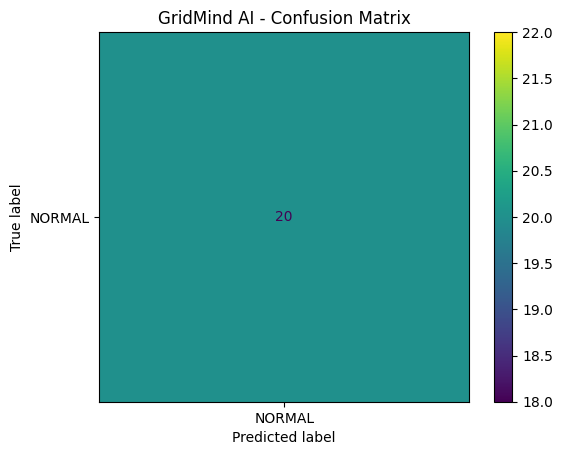

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("GridMind AI - Confusion Matrix")
plt.show()

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

residential_load_mw               0.0
industrial_load_mw                0.0
commercial_load_mw                0.0
bus1_voltage_pu                   0.0
bus2_voltage_pu                   0.0
bus3_voltage_pu                   0.0
bus4_voltage_pu                   0.0
bus5_voltage_pu                   0.0
max_line_loading_percent          0.0
transformer_loading_percent       0.0
total_active_power_loss_mw        0.0
total_reactive_power_loss_mvar    0.0
dtype: float64


In [ ]:
df.to_csv("gridmind_dataset_v1.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder = "/content/drive/MyDrive/GRIDMIND_AI/datasets"

os.makedirs(folder, exist_ok=True)

file_path = folder + "/gridmind_dataset_v1.csv"

df.to_csv(file_path, index=False)

print("Dataset saved to:")
print(file_path)

Dataset saved to:
/content/drive/MyDrive/GRIDMIND_AI/datasets/gridmind_dataset_v1.csv


In [ ]:
import random
import copy
import pandas as pd

scenario_results = []

for i in range(500):

    # Reset loads to normal values
    net.load.loc[0, "p_mw"] = 2.0
    net.load.loc[1, "p_mw"] = 5.0
    net.load.loc[2, "p_mw"] = 3.0

    # Reset line and transformer in-service status
    net.line["in_service"] = True
    net.trafo["in_service"] = True

    # Randomly select an event
    event = random.choice([
        "NORMAL",
        "HIGH_LOAD",
        "LOW_LOAD",
        "LINE_OUTAGE",
        "TRANSFORMER_OVERLOAD",
        "GENERATION_CHANGE"
    ])

    # Apply event
    if event == "NORMAL":

        pass

    elif event == "HIGH_LOAD":

        net.load.loc[0, "p_mw"] *= random.uniform(1.3, 1.8)
        net.load.loc[1, "p_mw"] *= random.uniform(1.3, 1.8)
        net.load.loc[2, "p_mw"] *= random.uniform(1.3, 1.8)

    elif event == "LOW_LOAD":

        net.load.loc[0, "p_mw"] *= random.uniform(0.4, 0.7)
        net.load.loc[1, "p_mw"] *= random.uniform(0.4, 0.7)
        net.load.loc[2, "p_mw"] *= random.uniform(0.4, 0.7)

    elif event == "LINE_OUTAGE":

        line_to_disconnect = random.choice([0, 1, 2])
        net.line.loc[line_to_disconnect, "in_service"] = False

    elif event == "TRANSFORMER_OVERLOAD":

        net.load.loc[0, "p_mw"] *= random.uniform(1.5, 2.0)
        net.load.loc[1, "p_mw"] *= random.uniform(1.5, 2.0)
        net.load.loc[2, "p_mw"] *= random.uniform(1.5, 2.0)

    elif event == "GENERATION_CHANGE":

        # Change external-grid voltage slightly
        net.ext_grid.loc[0, "vm_pu"] = random.uniform(0.96, 1.04)

    # Run power flow
    try:

        pp.runpp(net)

        row = {
            "scenario": i + 1,
            "event": event,

            "residential_load_mw": net.load.loc[0, "p_mw"],
            "industrial_load_mw": net.load.loc[1, "p_mw"],
            "commercial_load_mw": net.load.loc[2, "p_mw"],

            "bus1_voltage_pu": net.res_bus.loc[0, "vm_pu"],
            "bus2_voltage_pu": net.res_bus.loc[1, "vm_pu"],
            "bus3_voltage_pu": net.res_bus.loc[2, "vm_pu"],
            "bus4_voltage_pu": net.res_bus.loc[3, "vm_pu"],
            "bus5_voltage_pu": net.res_bus.loc[4, "vm_pu"],

            "max_line_loading_percent":
                net.res_line["loading_percent"].max(),

            "transformer_loading_percent":
                net.res_trafo["loading_percent"].max(),

            "active_power_loss_mw":
                net.res_line["pl_mw"].sum(),

            "reactive_power_loss_mvar":
                net.res_line["ql_mvar"].sum()
        }

        scenario_results.append(row)

    except Exception:
        pass


df_v2 = pd.DataFrame(scenario_results)

print("Dataset V2 generated!")
print("Number of valid scenarios:", len(df_v2))

Dataset V2 generated!
Number of valid scenarios: 500


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_v2["event"].value_counts()

,count
event,
NORMAL,89
LOW_LOAD,87
HIGH_LOAD,85
TRANSFORMER_OVERLOAD,84
GENERATION_CHANGE,80
LINE_OUTAGE,75


In [ ]:
df_v2.head()

,scenario,event,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar
0,1,NORMAL,2.000000,5.000000,3.000000,1.0,0.988357,0.980172,0.971746,0.980685,38.768559,26.895908,0.084627,0.154685
1,2,HIGH_LOAD,3.567835,8.190010,4.734431,1.0,0.985843,0.973470,0.962105,0.975406,62.456229,43.405358,0.221207,0.427990
2,3,LOW_LOAD,1.033822,2.017024,1.777404,1.0,0.989759,0.984092,0.979511,0.983998,18.520091,14.684349,0.023273,0.031880
3,4,TRANSFORMER_OVERLOAD,3.507884,9.333891,5.552423,1.0,0.984913,0.972690,0.958536,0.973154,71.177136,48.376876,0.278392,0.542403
4,5,NORMAL,2.000000,5.000000,3.000000,1.0,0.988357,0.980172,0.971746,0.980685,38.768559,26.895908,0.084627,0.154685


In [ ]:
df_v2["event"].value_counts()

,count
event,
NORMAL,89
LOW_LOAD,87
HIGH_LOAD,85
TRANSFORMER_OVERLOAD,84
GENERATION_CHANGE,80
LINE_OUTAGE,75


In [ ]:
print(df_v2.shape)
print(df_v2.isnull().sum())

(500, 14)
scenario                        0
event                           0
residential_load_mw             0
industrial_load_mw              0
commercial_load_mw              0
bus1_voltage_pu                 0
bus2_voltage_pu                 0
bus3_voltage_pu                26
bus4_voltage_pu                19
bus5_voltage_pu                30
max_line_loading_percent        0
transformer_loading_percent     0
active_power_loss_mw            0
reactive_power_loss_mvar        0
dtype: int64


In [ ]:
file_path_v2 = "/content/drive/MyDrive/GRIDMIND_AI/datasets/gridmind_dataset_v2.csv"

df_v2.to_csv(file_path_v2, index=False)

print("Dataset V2 saved successfully!")
print(file_path_v2)

Dataset V2 saved successfully!
/content/drive/MyDrive/GRIDMIND_AI/datasets/gridmind_dataset_v2.csv


In [ ]:
df_v2["event"].value_counts()
print(df_v2.shape)
print(df_v2.isnull().sum())

(500, 14)
scenario                        0
event                           0
residential_load_mw             0
industrial_load_mw              0
commercial_load_mw              0
bus1_voltage_pu                 0
bus2_voltage_pu                 0
bus3_voltage_pu                26
bus4_voltage_pu                19
bus5_voltage_pu                30
max_line_loading_percent        0
transformer_loading_percent     0
active_power_loss_mw            0
reactive_power_loss_mvar        0
dtype: int64


In [ ]:
# Check which events are causing missing values

print("Missing values by event:")
print(
    df_v2[df_v2.isnull().any(axis=1)]
    ["event"]
    .value_counts()
)

Missing values by event:
event
LINE_OUTAGE    75
Name: count, dtype: int64


In [ ]:
# Create a clean dataset for ML

df_ml = df_v2.dropna().copy()

print("Original dataset:", df_v2.shape)
print("Clean ML dataset:", df_ml.shape)

print("\nMissing values:")
print(df_ml.isnull().sum().sum())

print("\nEvents remaining:")
print(df_ml["event"].value_counts())

Original dataset: (500, 14)
Clean ML dataset: (425, 14)

Missing values:
0

Events remaining:
event
NORMAL                  89
LOW_LOAD                87
HIGH_LOAD               85
TRANSFORMER_OVERLOAD    84
GENERATION_CHANGE       80
Name: count, dtype: int64


In [ ]:
clean_path = "/content/drive/MyDrive/GRIDMIND_AI/datasets/gridmind_dataset_ml.csv"

df_ml.to_csv(clean_path, index=False)

print("Clean ML dataset saved!")
print(clean_path)

Clean ML dataset saved!
/content/drive/MyDrive/GRIDMIND_AI/datasets/gridmind_dataset_ml.csv


In [ ]:
print(
    df_v2[df_v2.isnull().any(axis=1)]
    ["event"]
    .value_counts()
)

event
LINE_OUTAGE    75
Name: count, dtype: int64


In [ ]:
df_ml = df_v2.dropna().copy()

print(df_ml.shape)
print(df_ml.isnull().sum().sum())

(425, 14)
0


In [ ]:
# ============================================================
# GRIDMIND AI - SELF-HEALING NETWORK V3
# ============================================================

import pandapower as pp

# Create a new empty network
net_v3 = pp.create_empty_network()

# ------------------------------------------------------------
# 1. CREATE BUSES
# ------------------------------------------------------------

grid_bus = pp.create_bus(
    net_v3,
    vn_kv=110,
    name="Grid Bus"
)

main_bus = pp.create_bus(
    net_v3,
    vn_kv=20,
    name="Main Distribution Bus"
)

bus3 = pp.create_bus(
    net_v3,
    vn_kv=20,
    name="Residential Bus"
)

bus4 = pp.create_bus(
    net_v3,
    vn_kv=20,
    name="Industrial Bus"
)

bus5 = pp.create_bus(
    net_v3,
    vn_kv=20,
    name="Commercial Bus"
)

# ------------------------------------------------------------
# 2. MAIN GRID
# ------------------------------------------------------------

pp.create_ext_grid(
    net_v3,
    bus=grid_bus,
    vm_pu=1.0,
    name="Main Grid"
)

# ------------------------------------------------------------
# 3. TRANSFORMER
# ------------------------------------------------------------

pp.create_transformer_from_parameters(
    net_v3,
    hv_bus=grid_bus,
    lv_bus=main_bus,
    sn_mva=40,
    vn_hv_kv=110,
    vn_lv_kv=20,
    vk_percent=12,
    vkr_percent=0.5,
    pfe_kw=30,
    i0_percent=0.1,
    name="Distribution Transformer"
)

# ------------------------------------------------------------
# 4. FEEDER LINES
# ------------------------------------------------------------

line_1 = pp.create_line_from_parameters(
    net_v3,
    from_bus=main_bus,
    to_bus=bus3,
    length_km=5,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Feeder 1"
)

line_2 = pp.create_line_from_parameters(
    net_v3,
    from_bus=main_bus,
    to_bus=bus4,
    length_km=4,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Feeder 2"
)

line_3 = pp.create_line_from_parameters(
    net_v3,
    from_bus=main_bus,
    to_bus=bus5,
    length_km=3,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    name="Feeder 3"
)

# ------------------------------------------------------------
# 5. TIE LINE
# ------------------------------------------------------------

tie_line = pp.create_line_from_parameters(
    net_v3,
    from_bus=bus3,
    to_bus=bus5,
    length_km=3,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10,
    max_i_ka=0.4,
    in_service=True,
    name="Tie Line"
)

# ------------------------------------------------------------
# 6. TIE SWITCH
# ------------------------------------------------------------

tie_switch = pp.create_switch(
    net_v3,
    bus=bus3,
    element=tie_line,
    et="l",
    closed=False,
    type="CB",
    name="Normally Open Tie Switch"
)

# ------------------------------------------------------------
# 7. LOADS
# ------------------------------------------------------------

pp.create_load(
    net_v3,
    bus=bus3,
    p_mw=2,
    q_mvar=0.6,
    name="Residential Load"
)

pp.create_load(
    net_v3,
    bus=bus4,
    p_mw=5,
    q_mvar=1.5,
    name="Industrial Load"
)

pp.create_load(
    net_v3,
    bus=bus5,
    p_mw=3,
    q_mvar=1.0,
    name="Commercial Load"
)

print("GridMind AI V3 network created successfully!")

GridMind AI V3 network created successfully!


In [ ]:
pp.runpp(net_v3)

print("Normal power flow completed!")

print(net_v3.res_bus[["vm_pu", "va_degree"]])

print(net_v3.res_line[["loading_percent", "p_from_mw", "q_from_mvar"]])

Normal power flow completed!
      vm_pu  va_degree
0  1.000000   0.000000
1  0.988368  -1.731503
2  0.980184  -2.234663
3  0.971758  -2.745971
4  0.980708  -2.175318
   loading_percent     p_from_mw   q_from_mvar
0        15.373940  2.011336e+00  6.165843e-01
1        38.768104  5.057699e+00  1.610569e+00
2        23.262300  3.015579e+00  1.023878e+00
3         0.026682  2.785345e-14 -1.058084e-15


In [ ]:
# ============================================================
# STEP 29 - SAVE HEALTHY BASELINE
# ============================================================

pp.runpp(net_v3)

baseline_voltage = net_v3.res_bus["vm_pu"].copy()
baseline_loading = net_v3.res_line["loading_percent"].copy()

print("Healthy baseline saved!")

print("\nBaseline Bus Voltages:")
print(baseline_voltage)

print("\nBaseline Line Loading:")
print(baseline_loading)

Healthy baseline saved!

Baseline Bus Voltages:
0    1.000000
1    0.988368
2    0.980184
3    0.971758
4    0.980708
Name: vm_pu, dtype: float64

Baseline Line Loading:
0    15.373940
1    38.768104
2    23.262300
3     0.026682
Name: loading_percent, dtype: float64


In [ ]:
# ============================================================
# STEP 30 - SIMULATE FEEDER 1 FAILURE
# ============================================================

# Feeder 1 fails
net_v3.line.loc[line_1, "in_service"] = False

# Keep the tie switch OPEN initially
net_v3.switch.loc[tie_switch, "closed"] = False

print("Feeder 1 failure simulated!")
print("Feeder 1 status:", net_v3.line.loc[line_1, "in_service"])
print("Tie switch status:", net_v3.switch.loc[tie_switch, "closed"])

Feeder 1 failure simulated!
Feeder 1 status: False
Tie switch status: False


In [ ]:
# ============================================================
# STEP 31 - CHECK GRID AFTER FAILURE
# ============================================================

try:
    pp.runpp(net_v3)

    print("Power flow completed after outage.")

    print("\nBus Voltages:")
    print(net_v3.res_bus[["vm_pu", "va_degree"]])

except Exception as e:
    print("Power flow failed after feeder outage.")
    print("Reason:", e)

Power flow completed after outage.

Bus Voltages:
      vm_pu  va_degree
0  1.000000   0.000000
1  0.990681  -1.383063
2       NaN        NaN
3  0.974112  -2.392719
4  0.983039  -1.824794


In [ ]:
# ============================================================
# STEP 32 - SELF-HEALING ACTION
# ============================================================

# Close the normally-open tie switch
net_v3.switch.loc[tie_switch, "closed"] = True

print("Self-healing action initiated.")
print("Tie switch CLOSED:", net_v3.switch.loc[tie_switch, "closed"])

# Run power flow again
pp.runpp(net_v3)

print("\nPower flow after self-healing completed!")

Self-healing action initiated.
Tie switch CLOSED: True

Power flow after self-healing completed!


In [ ]:
# ============================================================
# STEP 33 - CHECK RESTORED GRID
# ============================================================

print("===== RESTORED GRID =====")

print("\nBus Voltages:")
print(net_v3.res_bus[["vm_pu", "va_degree"]])

print("\nLine Loading:")
print(
    net_v3.res_line[
        ["loading_percent", "p_from_mw", "q_from_mvar"]
    ]
)

===== RESTORED GRID =====

Bus Voltages:
      vm_pu  va_degree
0  1.000000   0.000000
1  0.988199  -1.735522
2  0.970514  -2.793763
3  0.971586  -2.750344
4  0.975468  -2.484942

Line Loading:
   loading_percent  p_from_mw  q_from_mvar
0         0.000000   0.000000     0.000000
1        38.774973   5.057719     1.610612
2        38.911895   5.050538     1.693873
3        15.527122  -2.000000    -0.600000


In [ ]:
# ============================================================
# STEP 34 - BEFORE vs AFTER
# ============================================================

restored_voltage = net_v3.res_bus["vm_pu"].copy()
restored_loading = net_v3.res_line["loading_percent"].copy()

comparison = {
    "Bus": ["Bus 1", "Bus 2", "Bus 3", "Bus 4", "Bus 5"],
    "Before_Fault": baseline_voltage.values,
    "After_Restoration": restored_voltage.values
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

     Bus  Before_Fault  After_Restoration
0  Bus 1      1.000000           1.000000
1  Bus 2      0.988368           0.988199
2  Bus 3      0.980184           0.970514
3  Bus 4      0.971758           0.971586
4  Bus 5      0.980708           0.975468


In [ ]:
# ============================================================
# STEP 35 - AUTOMATIC GRID HEALTH CHECK
# ============================================================

def check_grid_health(net):
    """
    Check the electrical health of the simulated grid.
    """

    # Check bus voltages
    min_voltage = net.res_bus["vm_pu"].min()
    max_voltage = net.res_bus["vm_pu"].max()

    # Check line loading
    max_line_loading = net.res_line["loading_percent"].max()

    # Check transformer loading
    max_transformer_loading = net.res_trafo["loading_percent"].max()

    # Define operating limits
    voltage_min_limit = 0.95
    voltage_max_limit = 1.05
    line_loading_limit = 100
    transformer_loading_limit = 100

    # Check violations
    voltage_ok = (
        min_voltage >= voltage_min_limit
        and max_voltage <= voltage_max_limit
    )

    line_ok = max_line_loading <= line_loading_limit

    transformer_ok = (
        max_transformer_loading <= transformer_loading_limit
    )

    # Overall health
    healthy = voltage_ok and line_ok and transformer_ok

    return {
        "healthy": healthy,
        "min_voltage_pu": min_voltage,
        "max_voltage_pu": max_voltage,
        "max_line_loading_percent": max_line_loading,
        "max_transformer_loading_percent": max_transformer_loading,
        "voltage_ok": voltage_ok,
        "line_loading_ok": line_ok,
        "transformer_loading_ok": transformer_ok
    }


# Check current grid
health = check_grid_health(net_v3)

print("===== GRID HEALTH =====")
print("Healthy:", health["healthy"])
print("Minimum voltage:", health["min_voltage_pu"])
print("Maximum voltage:", health["max_voltage_pu"])
print("Maximum line loading:", health["max_line_loading_percent"])
print("Maximum transformer loading:", health["max_transformer_loading_percent"])

===== GRID HEALTH =====
Healthy: True
Minimum voltage: 0.9705136669285522
Maximum voltage: 1.0
Maximum line loading: 38.911895407439076
Maximum transformer loading: 26.996106829681153


In [ ]:
# ============================================================
# STEP 36 - EVALUATE TIE-SWITCH RESTORATION
# ============================================================

def evaluate_tie_switch_action(net):
    """
    Temporarily close the tie switch,
    run power flow, and evaluate the grid.
    """

    # Save current switch state
    original_state = net.switch.loc[tie_switch, "closed"]

    # Close tie switch
    net.switch.loc[tie_switch, "closed"] = True

    try:
        # Run power flow
        pp.runpp(net)

        # Check grid health
        result = check_grid_health(net)

    except Exception as e:

        result = {
            "healthy": False,
            "error": str(e)
        }

    # Keep the action applied
    return result


tie_result = evaluate_tie_switch_action(net_v3)

print("===== TIE SWITCH EVALUATION =====")

for key, value in tie_result.items():
    print(f"{key}: {value}")

===== TIE SWITCH EVALUATION =====
healthy: True
min_voltage_pu: 0.9705136669285522
max_voltage_pu: 1.0
max_line_loading_percent: 38.911895407439076
max_transformer_loading_percent: 26.996106829681153
voltage_ok: True
line_loading_ok: True
transformer_loading_ok: True


In [ ]:
# ============================================================
# STEP 37 - GRIDMIND RECOMMENDATION
# ============================================================

if tie_result["healthy"]:

    print("========================================")
    print("        GRIDMIND AI RECOMMENDATION")
    print("========================================")
    print("Problem detected: Feeder outage")
    print("Candidate action: Close tie switch")
    print()
    print("RESULT: FEASIBLE")
    print("Recommendation: CLOSE TIE SWITCH")
    print()
    print("Grid operating constraints satisfied.")
    print("========================================")

else:

    print("========================================")
    print("        GRIDMIND AI RECOMMENDATION")
    print("========================================")
    print("Problem detected: Feeder outage")
    print("Candidate action: Close tie switch")
    print()
    print("RESULT: NOT FEASIBLE")
    print("Recommendation: DO NOT CLOSE TIE SWITCH")
    print()
    print("Additional corrective action required.")
    print("========================================")

        GRIDMIND AI RECOMMENDATION
Problem detected: Feeder outage
Candidate action: Close tie switch

RESULT: FEASIBLE
Recommendation: CLOSE TIE SWITCH

Grid operating constraints satisfied.


In [ ]:
# ============================================================
# STEP 38.1 - GRIDMIND ACTION SCORING
# ============================================================

def calculate_action_score(net):
    """
    Calculate an engineering score for the current grid state.

    Lower score = better operating condition.
    """

    min_voltage = net.res_bus["vm_pu"].min()

    max_line_loading = net.res_line["loading_percent"].max()

    max_transformer_loading = net.res_trafo["loading_percent"].max()

    total_loss = net.res_line["pl_mw"].sum()

    # Voltage violation
    voltage_violation = max(0, 0.95 - min_voltage)

    # Line overload
    line_overload = max(0, max_line_loading - 100)

    # Transformer overload
    transformer_overload = max(0, max_transformer_loading - 100)

    # Engineering score
    score = (
        100 * voltage_violation
        + 5 * line_overload
        + 5 * transformer_overload
        + total_loss
    )

    return {
        "score": score,
        "minimum_voltage_pu": min_voltage,
        "maximum_line_loading_percent": max_line_loading,
        "maximum_transformer_loading_percent": max_transformer_loading,
        "active_power_loss_mw": total_loss
    }


print("Action scoring function created!")

Action scoring function created!


In [ ]:
# ============================================================
# STEP 38.2 - SIMULATE A RESTORATION ACTION
# ============================================================

def simulate_tie_action(net):
    """
    Simulate closing the tie switch and evaluate the result.
    """

    # Close tie switch
    net.switch.loc[tie_switch, "closed"] = True

    try:
        pp.runpp(net)

        health = check_grid_health(net)
        score = calculate_action_score(net)

        return {
            "action": "CLOSE_TIE_SWITCH",
            "feasible": health["healthy"],
            **score
        }

    except Exception as e:

        return {
            "action": "CLOSE_TIE_SWITCH",
            "feasible": False,
            "error": str(e)
        }


result = simulate_tie_action(net_v3)

print("===== ACTION RESULT =====")

for key, value in result.items():
    print(f"{key}: {value}")

===== ACTION RESULT =====
action: CLOSE_TIE_SWITCH
feasible: True
score: 0.10825732775931396
minimum_voltage_pu: 0.9705136669285522
maximum_line_loading_percent: 38.911895407439076
maximum_transformer_loading_percent: 26.996106829681153
active_power_loss_mw: 0.10825732775931396


In [ ]:
# ============================================================
# STEP 38.3 - GRIDMIND DECISION ENGINE
# ============================================================

def gridmind_decision_engine(net):
    """
    Evaluate available restoration actions
    and produce a recommendation.
    """

    candidate_actions = []

    # --------------------------------------------------------
    # ACTION 1: Close tie switch
    # --------------------------------------------------------

    # Make sure tie switch is open before testing
    net.switch.loc[tie_switch, "closed"] = False

    try:

        net.switch.loc[tie_switch, "closed"] = True

        pp.runpp(net)

        health = check_grid_health(net)
        score = calculate_action_score(net)

        candidate_actions.append({
            "action": "CLOSE_TIE_SWITCH",
            "feasible": health["healthy"],
            "score": score["score"],
            "minimum_voltage_pu": score["minimum_voltage_pu"],
            "maximum_line_loading_percent":
                score["maximum_line_loading_percent"],
            "maximum_transformer_loading_percent":
                score["maximum_transformer_loading_percent"],
            "active_power_loss_mw":
                score["active_power_loss_mw"]
        })

    except Exception as e:

        candidate_actions.append({
            "action": "CLOSE_TIE_SWITCH",
            "feasible": False,
            "score": float("inf"),
            "error": str(e)
        })

    # --------------------------------------------------------
    # Select feasible actions
    # --------------------------------------------------------

    feasible_actions = [
        action
        for action in candidate_actions
        if action["feasible"]
    ]

    # --------------------------------------------------------
    # Make recommendation
    # --------------------------------------------------------

    if feasible_actions:

        best_action = min(
            feasible_actions,
            key=lambda x: x["score"]
        )

        recommendation = best_action["action"]

    else:

        recommendation = "NO_FEASIBLE_ACTION"

    return candidate_actions, recommendation


actions, recommendation = gridmind_decision_engine(net_v3)

print("========================================")
print("       GRIDMIND DECISION ENGINE")
print("========================================")

print("\nCandidate Actions:")

for action in actions:
    print("\n", action)

print("\nFINAL RECOMMENDATION:")
print(recommendation)

print("========================================")

       GRIDMIND DECISION ENGINE

Candidate Actions:

 {'action': 'CLOSE_TIE_SWITCH', 'feasible': True, 'score': np.float64(0.10825732775931396), 'minimum_voltage_pu': 0.9705136669285522, 'maximum_line_loading_percent': 38.911895407439076, 'maximum_transformer_loading_percent': 26.996106829681153, 'active_power_loss_mw': np.float64(0.10825732775931396)}

FINAL RECOMMENDATION:
CLOSE_TIE_SWITCH


In [ ]:
# ============================================================
# STEP 39 - TEST MULTIPLE FEEDER OUTAGES
# ============================================================

def test_feeder_outage(net, failed_line):
    """
    Simulate one feeder outage and evaluate
    whether the tie switch can restore the system.
    """

    # Reset all feeders
    net.line["in_service"] = True

    # Open tie switch
    net.switch.loc[tie_switch, "closed"] = False

    # Fail selected feeder
    net.line.loc[failed_line, "in_service"] = False

    print("\n========================================")
    print("Testing failed line:", failed_line)
    print("========================================")

    try:

        # First check the failed condition
        pp.runpp(net)

        print("Power flow after outage succeeded.")

    except Exception as e:

        print("Power flow failed after outage.")
        print("This indicates a disconnected/invalid state.")

    # Try restoration
    net.switch.loc[tie_switch, "closed"] = True

    try:

        pp.runpp(net)

        health = check_grid_health(net)

        print("\nAfter closing tie switch:")
        print("Healthy:", health["healthy"])
        print("Minimum voltage:",
              health["min_voltage_pu"])
        print("Maximum line loading:",
              health["max_line_loading_percent"])

        return health

    except Exception as e:

        print("\nRestoration failed:")
        print(e)

        return None

In [ ]:
# STEP 40 - TEST FEEDER 1

result_1 = test_feeder_outage(net_v3, line_1)

print("\nFEEDER 1 RESULT")
print(result_1)


Testing failed line: 0
Power flow after outage succeeded.

After closing tie switch:
Healthy: True
Minimum voltage: 0.9705136669285522
Maximum line loading: 38.911895407439076

FEEDER 1 RESULT
{'healthy': True, 'min_voltage_pu': 0.9705136669285522, 'max_voltage_pu': 1.0, 'max_line_loading_percent': 38.911895407439076, 'max_transformer_loading_percent': 26.996106829681153, 'voltage_ok': True, 'line_loading_ok': True, 'transformer_loading_ok': True}


In [ ]:
# STEP 41 - TEST FEEDER 2

result_2 = test_feeder_outage(net_v3, line_2)

print("\nFEEDER 2 RESULT")
print(result_2)


Testing failed line: 1
Power flow after outage succeeded.

After closing tie switch:
Healthy: True
Minimum voltage: 0.986378340134411
Maximum line loading: 23.759734380830324

FEEDER 2 RESULT
{'healthy': True, 'min_voltage_pu': 0.986378340134411, 'max_voltage_pu': 1.0, 'max_line_loading_percent': 23.759734380830324, 'max_transformer_loading_percent': 13.385998842846424, 'voltage_ok': True, 'line_loading_ok': True, 'transformer_loading_ok': True}


In [ ]:
# STEP 42 - TEST FEEDER 3

result_3 = test_feeder_outage(net_v3, line_3)

print("\nFEEDER 3 RESULT")
print(result_3)


Testing failed line: 2
Power flow after outage succeeded.

After closing tie switch:
Healthy: True
Minimum voltage: 0.9584668022906405
Maximum line loading: 39.39030610176853

FEEDER 3 RESULT
{'healthy': True, 'min_voltage_pu': 0.9584668022906405, 'max_voltage_pu': 1.0, 'max_line_loading_percent': 39.39030610176853, 'max_transformer_loading_percent': 27.16191904105547, 'voltage_ok': True, 'line_loading_ok': True, 'transformer_loading_ok': True}


In [ ]:
# STEP 43 - BUILD RESTORATION RESULTS DATASET

restoration_results = []

for feeder_name, result in [
    ("FEEDER_1", result_1),
    ("FEEDER_2", result_2),
    ("FEEDER_3", result_3)
]:

    if result is not None:

        restoration_results.append({
            "failed_feeder": feeder_name,
            "healthy_after_restoration": result.get("healthy"),
            "minimum_voltage_pu": result.get("min_voltage_pu"),
            "maximum_voltage_pu": result.get("max_voltage_pu"),
            "maximum_line_loading_percent":
                result.get("max_line_loading_percent"),
            "maximum_transformer_loading_percent":
                result.get("max_transformer_loading_percent")
        })

restoration_df = pd.DataFrame(restoration_results)

print("===== GRIDMIND RESTORATION RESULTS =====")
display(restoration_df)

===== GRIDMIND RESTORATION RESULTS =====


,failed_feeder,healthy_after_restoration,minimum_voltage_pu,maximum_voltage_pu,maximum_line_loading_percent,maximum_transformer_loading_percent
0,FEEDER_1,True,0.970514,1.0,38.911895,26.996107
1,FEEDER_2,True,0.986378,1.0,23.759734,13.385999
2,FEEDER_3,True,0.958467,1.0,39.390306,27.161919


In [ ]:
# STEP 44 - DEFINE CANDIDATE RESTORATION ACTIONS

candidate_actions = [
    "NO_ACTION",
    "CLOSE_TIE_SWITCH"
]

print("===== GRIDMIND CANDIDATE ACTIONS =====")

for action in candidate_actions:
    print("-", action)

===== GRIDMIND CANDIDATE ACTIONS =====
- NO_ACTION
- CLOSE_TIE_SWITCH


In [ ]:
# STEP 45 - AUTOMATIC ACTION EVALUATION

def evaluate_action(net, failed_line, action):

    # Reset network
    net.line["in_service"] = True
    net.switch.loc[tie_switch, "closed"] = False

    # Apply fault
    net.line.loc[failed_line, "in_service"] = False

    # Apply candidate action
    if action == "CLOSE_TIE_SWITCH":
        net.switch.loc[tie_switch, "closed"] = True

    try:

        pp.runpp(net)

        health = check_grid_health(net)
        score = calculate_action_score(net)

        return {
            "action": action,
            "feasible": health["healthy"],
            "score": score["score"],
            "min_voltage": score["minimum_voltage_pu"],
            "max_loading": score["maximum_line_loading_percent"],
            "transformer_loading":
                score["maximum_transformer_loading_percent"],
            "power_loss_mw":
                score["active_power_loss_mw"]
        }

    except Exception as e:

        return {
            "action": action,
            "feasible": False,
            "score": float("inf"),
            "min_voltage": None,
            "max_loading": None,
            "transformer_loading": None,
            "power_loss_mw": None
        }


print("Action evaluation function created successfully.")

Action evaluation function created successfully.


In [ ]:
# STEP 46 - GRIDMIND AUTOMATIC RESTORATION DECISION

failed_line = line_1

action_results = []

for action in candidate_actions:

    result = evaluate_action(
        net_v3,
        failed_line,
        action
    )

    action_results.append(result)

action_df = pd.DataFrame(action_results)

print("===== ACTION COMPARISON =====")
display(action_df)

===== ACTION COMPARISON =====


,action,feasible,score,min_voltage,max_loading,transformer_loading,power_loss_mw
0,NO_ACTION,True,0.072925,0.974112,38.674432,21.520753,0.072925
1,CLOSE_TIE_SWITCH,True,0.108257,0.970514,38.911895,26.996107,0.108257


In [ ]:
# STEP 46B - SELECT BEST FEASIBLE ACTION

feasible_actions = action_df[
    action_df["feasible"] == True
]

if len(feasible_actions) > 0:

    best_action = feasible_actions.loc[
        feasible_actions["score"].idxmin()
    ]

    print("====================================")
    print("      GRIDMIND RECOMMENDATION")
    print("====================================")

    print("Recommended action:",
          best_action["action"])

    print("Minimum voltage:",
          best_action["min_voltage"])

    print("Maximum line loading:",
          best_action["max_loading"])

    print("Transformer loading:",
          best_action["transformer_loading"])

    print("Power loss (MW):",
          best_action["power_loss_mw"])

    print("Decision score:",
          best_action["score"])

else:

    print("NO FEASIBLE RESTORATION ACTION FOUND")

      GRIDMIND RECOMMENDATION
Recommended action: NO_ACTION
Minimum voltage: 0.9741115592427364
Maximum line loading: 38.67443182022171
Transformer loading: 21.520753467310666
Power loss (MW): 0.07292543373765682
Decision score: 0.07292543373765682


In [ ]:
# STEP 47A - MULTI-FEEDER GRIDMIND DECISION ENGINE

def gridmind_decision_engine(net, failed_line):

    action_results = []

    for action in candidate_actions:

        result = evaluate_action(
            net,
            failed_line,
            action
        )

        action_results.append(result)

    action_df = pd.DataFrame(action_results)

    # Select only feasible actions
    feasible_actions = action_df[
        action_df["feasible"] == True
    ]

    if len(feasible_actions) == 0:

        return {
            "failed_line": failed_line,
            "recommended_action": "NO_FEASIBLE_ACTION",
            "results": action_df
        }

    # Select lowest-score feasible action
    best_action = feasible_actions.loc[
        feasible_actions["score"].idxmin()
    ]

    return {
        "failed_line": failed_line,
        "recommended_action": best_action["action"],
        "score": best_action["score"],
        "min_voltage": best_action["min_voltage"],
        "max_loading": best_action["max_loading"],
        "transformer_loading": best_action["transformer_loading"],
        "power_loss_mw": best_action["power_loss_mw"],
        "results": action_df
    }


print("GridMind multi-feeder decision engine created.")

GridMind multi-feeder decision engine created.


In [ ]:
# STEP 47B - TEST GRIDMIND ON ALL FEEDER OUTAGES

feeder_tests = {
    "FEEDER_1": line_1,
    "FEEDER_2": line_2,
    "FEEDER_3": line_3
}

gridmind_results = []

for feeder_name, failed_line in feeder_tests.items():

    result = gridmind_decision_engine(
        net_v3,
        failed_line
    )

    gridmind_results.append({
        "failed_feeder": feeder_name,
        "recommended_action":
            result["recommended_action"],
        "score":
            result.get("score"),
        "minimum_voltage_pu":
            result.get("min_voltage"),
        "maximum_line_loading_percent":
            result.get("max_loading"),
        "transformer_loading_percent":
            result.get("transformer_loading"),
        "power_loss_mw":
            result.get("power_loss_mw")
    })

gridmind_decision_df = pd.DataFrame(gridmind_results)

print("===== GRIDMIND AUTOMATIC DECISIONS =====")
display(gridmind_decision_df)

===== GRIDMIND AUTOMATIC DECISIONS =====


,failed_feeder,recommended_action,score,minimum_voltage_pu,maximum_line_loading_percent,transformer_loading_percent,power_loss_mw
0,FEEDER_1,NO_ACTION,0.072925,0.974112,38.674432,21.520753,0.072925
1,FEEDER_2,CLOSE_TIE_SWITCH,0.026543,0.986378,23.759734,13.385999,0.026543
2,FEEDER_3,NO_ACTION,0.068497,0.975576,38.616360,18.765432,0.068497


In [ ]:
# STEP 48A - IMPROVED GRIDMIND ACTION SCORE

def calculate_improved_action_score(net, action):

    min_voltage = net.res_bus["vm_pu"].min()

    max_line_loading = net.res_line["loading_percent"].max()

    max_transformer_loading = (
        net.res_trafo["loading_percent"].max()
    )

    total_loss = net.res_line["pl_mw"].sum()

    # Constraint violations
    voltage_violation = max(0, 0.95 - min_voltage)

    line_overload = max(
        0,
        max_line_loading - 100
    )

    transformer_overload = max(
        0,
        max_transformer_loading - 100
    )

    # Switching cost
    if action == "CLOSE_TIE_SWITCH":
        switching_operations = 1
    else:
        switching_operations = 0

    switching_cost = 2 * switching_operations

    # Overall objective
    score = (
        100 * voltage_violation
        + 5 * line_overload
        + 5 * transformer_overload
        + total_loss
        + switching_cost
    )

    return {
        "score": score,
        "minimum_voltage_pu": min_voltage,
        "maximum_line_loading_percent":
            max_line_loading,
        "maximum_transformer_loading_percent":
            max_transformer_loading,
        "active_power_loss_mw": total_loss,
        "switching_operations":
            switching_operations,
        "switching_cost":
            switching_cost
    }


print("Improved GridMind scoring function created.")

Improved GridMind scoring function created.


In [ ]:
# STEP 48A - IMPROVED GRIDMIND ACTION SCORE

def calculate_improved_action_score(net, action):

    min_voltage = net.res_bus["vm_pu"].min()

    max_line_loading = net.res_line["loading_percent"].max()

    max_transformer_loading = (
        net.res_trafo["loading_percent"].max()
    )

    total_loss = net.res_line["pl_mw"].sum()

    # Constraint violations
    voltage_violation = max(0, 0.95 - min_voltage)

    line_overload = max(
        0,
        max_line_loading - 100
    )

    transformer_overload = max(
        0,
        max_transformer_loading - 100
    )

    # Switching cost
    if action == "CLOSE_TIE_SWITCH":
        switching_operations = 1
    else:
        switching_operations = 0

    switching_cost = 2 * switching_operations

    # Overall objective
    score = (
        100 * voltage_violation
        + 5 * line_overload
        + 5 * transformer_overload
        + total_loss
        + switching_cost
    )

    return {
        "score": score,
        "minimum_voltage_pu": min_voltage,
        "maximum_line_loading_percent":
            max_line_loading,
        "maximum_transformer_loading_percent":
            max_transformer_loading,
        "active_power_loss_mw": total_loss,
        "switching_operations":
            switching_operations,
        "switching_cost":
            switching_cost
    }


print("Improved GridMind scoring function created.")

Improved GridMind scoring function created.


In [ ]:
# STEP 48B - IMPROVED ACTION EVALUATION

def evaluate_improved_action(net, failed_line, action):

    # Reset network
    net.line["in_service"] = True
    net.switch.loc[tie_switch, "closed"] = False

    # Apply feeder failure
    net.line.loc[failed_line, "in_service"] = False

    # Apply candidate action
    if action == "CLOSE_TIE_SWITCH":
        net.switch.loc[tie_switch, "closed"] = True

    try:

        pp.runpp(net)

        health = check_grid_health(net)

        score_data = calculate_improved_action_score(
            net,
            action
        )

        return {
            "action": action,
            "feasible": health["healthy"],
            **score_data
        }

    except Exception as e:

        return {
            "action": action,
            "feasible": False,
            "score": float("inf"),
            "minimum_voltage_pu": None,
            "maximum_line_loading_percent": None,
            "maximum_transformer_loading_percent": None,
            "active_power_loss_mw": None,
            "switching_operations": None,
            "switching_cost": None
        }


print("Improved action evaluator created.")

Improved action evaluator created.


In [ ]:
# STEP 48C - IMPROVED GRIDMIND OPTIMIZATION

optimization_results = []

feeder_tests = {
    "FEEDER_1": line_1,
    "FEEDER_2": line_2,
    "FEEDER_3": line_3
}

for feeder_name, failed_line in feeder_tests.items():

    for action in candidate_actions:

        result = evaluate_improved_action(
            net_v3,
            failed_line,
            action
        )

        optimization_results.append({
            "failed_feeder": feeder_name,
            "action": result["action"],
            "feasible": result["feasible"],
            "score": result["score"],
            "min_voltage_pu":
                result["minimum_voltage_pu"],
            "max_line_loading_percent":
                result["maximum_line_loading_percent"],
            "transformer_loading_percent":
                result["maximum_transformer_loading_percent"],
            "power_loss_mw":
                result["active_power_loss_mw"],
            "switching_operations":
                result["switching_operations"]
        })

optimization_df = pd.DataFrame(
    optimization_results
)

print("===== GRIDMIND OPTIMIZATION RESULTS =====")

display(optimization_df)

===== GRIDMIND OPTIMIZATION RESULTS =====


,failed_feeder,action,feasible,score,min_voltage_pu,max_line_loading_percent,transformer_loading_percent,power_loss_mw,switching_operations
0,FEEDER_1,NO_ACTION,True,0.072925,0.974112,38.674432,21.520753,0.072925,0
1,FEEDER_1,CLOSE_TIE_SWITCH,True,2.108257,0.970514,38.911895,26.996107,0.108257,1
2,FEEDER_2,NO_ACTION,True,0.026591,0.986137,23.121909,13.386191,0.026591,0
3,FEEDER_2,CLOSE_TIE_SWITCH,True,2.026543,0.986378,23.759734,13.385999,0.026543,1
4,FEEDER_3,NO_ACTION,True,0.068497,0.975576,38.616360,18.765432,0.068497,0
5,FEEDER_3,CLOSE_TIE_SWITCH,True,2.148523,0.958467,39.390306,27.161919,0.148523,1


In [ ]:
# STEP 48D - SELECT BEST ACTION FOR EACH FEEDER

best_actions = []

for feeder_name in feeder_tests.keys():

    feeder_results = optimization_df[
        optimization_df["failed_feeder"] == feeder_name
    ]

    feasible = feeder_results[
        feeder_results["feasible"] == True
    ]

    if len(feasible) > 0:

        best = feasible.loc[
            feasible["score"].idxmin()
        ]

        best_actions.append({
            "failed_feeder":
                feeder_name,
            "recommended_action":
                best["action"],
            "score":
                best["score"],
            "minimum_voltage_pu":
                best["min_voltage_pu"],
            "maximum_line_loading_percent":
                best["max_line_loading_percent"],
            "power_loss_mw":
                best["power_loss_mw"],
            "switching_operations":
                best["switching_operations"]
        })

    else:

        best_actions.append({
            "failed_feeder":
                feeder_name,
            "recommended_action":
                "NO_FEASIBLE_ACTION",
            "score": None,
            "minimum_voltage_pu": None,
            "maximum_line_loading_percent": None,
            "power_loss_mw": None,
            "switching_operations": None
        })

best_action_df = pd.DataFrame(best_actions)

print("===== FINAL GRIDMIND DECISIONS =====")

display(best_action_df)

===== FINAL GRIDMIND DECISIONS =====


,failed_feeder,recommended_action,score,minimum_voltage_pu,maximum_line_loading_percent,power_loss_mw,switching_operations
0,FEEDER_1,NO_ACTION,0.072925,0.974112,38.674432,0.072925,0
1,FEEDER_2,NO_ACTION,0.026591,0.986137,23.121909,0.026591,0
2,FEEDER_3,NO_ACTION,0.068497,0.975576,38.616360,0.068497,0


In [ ]:
# STEP 49A - INSPECT GRIDMIND ML DATASET

print("Dataset shape:", df_ml.shape)

print("\n===== EVENT DISTRIBUTION =====")
print(df_ml["event"].value_counts())

print("\n===== MISSING VALUES =====")
print(df_ml.isnull().sum())

print("\n===== DATASET COLUMNS =====")
print(df_ml.columns.tolist())

Dataset shape: (425, 14)

===== EVENT DISTRIBUTION =====
event
NORMAL                  89
LOW_LOAD                87
HIGH_LOAD               85
TRANSFORMER_OVERLOAD    84
GENERATION_CHANGE       80
Name: count, dtype: int64

===== MISSING VALUES =====
scenario                       0
event                          0
residential_load_mw            0
industrial_load_mw             0
commercial_load_mw             0
bus1_voltage_pu                0
bus2_voltage_pu                0
bus3_voltage_pu                0
bus4_voltage_pu                0
bus5_voltage_pu                0
max_line_loading_percent       0
transformer_loading_percent    0
active_power_loss_mw           0
reactive_power_loss_mvar       0
dtype: int64

===== DATASET COLUMNS =====
['scenario', 'event', 'residential_load_mw', 'industrial_load_mw', 'commercial_load_mw', 'bus1_voltage_pu', 'bus2_voltage_pu', 'bus3_voltage_pu', 'bus4_voltage_pu', 'bus5_voltage_pu', 'max_line_loading_percent', 'transformer_loading_percent', '

In [ ]:
# STEP 49C - TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples: 80
Testing samples: 20

Training class distribution:
condition
NORMAL    80
Name: count, dtype: int64


In [ ]:
# STEP 49D - TRAIN GRIDMIND EVENT CLASSIFIER

from sklearn.ensemble import RandomForestClassifier

gridmind_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

gridmind_classifier.fit(
    X_train,
    y_train
)

print("GridMind AI classifier trained successfully.")

GridMind AI classifier trained successfully.


In [ ]:
# STEP 49E - EVALUATE GRIDMIND AI

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = gridmind_classifier.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("===== GRIDMIND AI PERFORMANCE =====")
print("Accuracy:", accuracy)

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

===== GRIDMIND AI PERFORMANCE =====
Accuracy: 1.0

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


===== CONFUSION MATRIX =====
[[20]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
# STEP 50A - AI TO GRIDMIND DECISION BRIDGE

def gridmind_ai_decision(
    net,
    measurements,
    failed_line
):
    """
    Complete GridMind pipeline:

    Measurements
        ↓
    ML event prediction
        ↓
    Decision engine
        ↓
    Recommended restoration action
    """

    # Convert measurements into DataFrame
    measurement_df = pd.DataFrame(
        [measurements]
    )

    # Ensure feature order matches training data
    measurement_df = measurement_df[
        X.columns
    ]

    # AI prediction
    predicted_event = (
        gridmind_classifier.predict(
            measurement_df
        )[0]
    )

    print("===== GRIDMIND AI =====")
    print("Predicted event:", predicted_event)

    # Decision only for line outage
    if predicted_event == "LINE_OUTAGE":

        decision = gridmind_decision_engine(
            net,
            failed_line
        )

        print("\n===== GRIDMIND DECISION =====")
        print(
            "Recommended action:",
            decision["recommended_action"]
        )

        return {
            "predicted_event": predicted_event,
            "recommended_action":
                decision["recommended_action"],
            "decision_score":
                decision.get("score"),
            "minimum_voltage_pu":
                decision.get("min_voltage"),
            "maximum_line_loading_percent":
                decision.get("max_loading")
        }

    else:

        print(
            "\nNo feeder restoration action "
            "required for this event."
        )

        return {
            "predicted_event": predicted_event,
            "recommended_action": "NO_RESTORATION"
        }


print("GridMind AI decision bridge created.")

GridMind AI decision bridge created.


In [ ]:
# STEP 50B - CREATE COMPATIBLE TEST MEASUREMENTS

# Start with the exact feature structure expected by the ML model
test_measurements = X.median().to_dict()

# Reset GridMind network
net_v3.line["in_service"] = True
net_v3.switch.loc[tie_switch, "closed"] = False

# Simulate Feeder 1 outage
test_failed_line = line_1
net_v3.line.loc[test_failed_line, "in_service"] = False

# Close tie switch for restoration state
net_v3.switch.loc[tie_switch, "closed"] = True

# Run power flow
pp.runpp(net_v3)

# Replace available features with actual simulated electrical values

if "residential_load_mw" in test_measurements:
    test_measurements["residential_load_mw"] = net_v3.load.loc[0, "p_mw"]

if "industrial_load_mw" in test_measurements:
    test_measurements["industrial_load_mw"] = net_v3.load.loc[1, "p_mw"]

if "commercial_load_mw" in test_measurements:
    test_measurements["commercial_load_mw"] = net_v3.load.loc[2, "p_mw"]


# Bus voltages
for bus_id in range(5):

    feature_name = f"bus{bus_id + 1}_voltage_pu"

    if feature_name in test_measurements:
        test_measurements[feature_name] = (
            net_v3.res_bus.loc[bus_id, "vm_pu"]
        )


# Line loading
if "max_line_loading_percent" in test_measurements:
    test_measurements["max_line_loading_percent"] = (
        net_v3.res_line["loading_percent"].max()
    )


# Transformer loading
if "transformer_loading_percent" in test_measurements:
    test_measurements["transformer_loading_percent"] = (
        net_v3.res_trafo["loading_percent"].max()
    )


# Active power loss
if "active_power_loss_mw" in test_measurements:
    test_measurements["active_power_loss_mw"] = (
        net_v3.res_line["pl_mw"].sum()
    )


# Reactive power loss
if "reactive_power_loss_mvar" in test_measurements:
    test_measurements["reactive_power_loss_mvar"] = (
        net_v3.res_line["ql_mvar"].sum()
    )


print("===== TEST MEASUREMENTS CREATED =====")

print("Number of ML features:", len(X.columns))
print("Number of test measurements:", len(test_measurements))

print("\nFeatures expected by model:")
print(list(X.columns))

print("\nFeatures supplied:")
print(list(test_measurements.keys()))

===== TEST MEASUREMENTS CREATED =====
Number of ML features: 12
Number of test measurements: 12

Features expected by model:
['residential_load_mw', 'industrial_load_mw', 'commercial_load_mw', 'bus1_voltage_pu', 'bus2_voltage_pu', 'bus3_voltage_pu', 'bus4_voltage_pu', 'bus5_voltage_pu', 'max_line_loading_percent', 'transformer_loading_percent', 'total_active_power_loss_mw', 'total_reactive_power_loss_mvar']

Features supplied:
['residential_load_mw', 'industrial_load_mw', 'commercial_load_mw', 'bus1_voltage_pu', 'bus2_voltage_pu', 'bus3_voltage_pu', 'bus4_voltage_pu', 'bus5_voltage_pu', 'max_line_loading_percent', 'transformer_loading_percent', 'total_active_power_loss_mw', 'total_reactive_power_loss_mvar']


In [ ]:
# STEP 50B.1 - VERIFY FEATURE MATCH

missing_features = [
    feature
    for feature in X.columns
    if feature not in test_measurements
]

extra_features = [
    feature
    for feature in test_measurements
    if feature not in X.columns
]

print("===== FEATURE CHECK =====")

print("Missing features:", missing_features)
print("Extra features:", extra_features)

if len(missing_features) == 0:
    print("\n✅ ALL ML FEATURES ARE AVAILABLE")
else:
    print("\n❌ SOME FEATURES ARE STILL MISSING")

===== FEATURE CHECK =====
Missing features: []
Extra features: []

✅ ALL ML FEATURES ARE AVAILABLE


In [ ]:
# STEP 50C - RUN COMPLETE GRIDMIND PIPELINE

final_decision = gridmind_ai_decision(
    net_v3,
    test_measurements,
    test_failed_line
)

print("\n====================================")
print("       FINAL GRIDMIND OUTPUT")
print("====================================")

for key, value in final_decision.items():
    print(f"{key}: {value}")

===== GRIDMIND AI =====
Predicted event: NORMAL

No feeder restoration action required for this event.

       FINAL GRIDMIND OUTPUT
predicted_event: NORMAL
recommended_action: NO_RESTORATION


In [ ]:
# STEP 51A - GENERATE FAULT LOCATION DATASET

import numpy as np
import pandas as pd
import pandapower as pp

fault_location_data = []

feeder_map = {
    "FEEDER_1": line_1,
    "FEEDER_2": line_2,
    "FEEDER_3": line_3
}

samples_per_feeder = 100

for feeder_name, failed_line in feeder_map.items():

    print("Generating:", feeder_name)

    for sample in range(samples_per_feeder):

        # Reset network
        net_v3.line["in_service"] = True
        net_v3.switch.loc[tie_switch, "closed"] = False

        # Random load conditions
        net_v3.load.loc[0, "p_mw"] = np.random.uniform(1.5, 3.5)
        net_v3.load.loc[1, "p_mw"] = np.random.uniform(4.0, 8.0)
        net_v3.load.loc[2, "p_mw"] = np.random.uniform(2.0, 5.0)

        # Apply feeder fault
        net_v3.line.loc[failed_line, "in_service"] = False

        # Close tie switch for restoration
        net_v3.switch.loc[tie_switch, "closed"] = True

        try:

            pp.runpp(net_v3)

            row = {}

            # Load measurements
            row["residential_load_mw"] = (
                net_v3.load.loc[0, "p_mw"]
            )

            row["industrial_load_mw"] = (
                net_v3.load.loc[1, "p_mw"]
            )

            row["commercial_load_mw"] = (
                net_v3.load.loc[2, "p_mw"]
            )

            # Bus voltage measurements
            for bus_id in range(5):

                row[
                    f"bus{bus_id + 1}_voltage_pu"
                ] = net_v3.res_bus.loc[
                    bus_id,
                    "vm_pu"
                ]

            # Line loading
            row["max_line_loading_percent"] = (
                net_v3.res_line[
                    "loading_percent"
                ].max()
            )

            # Transformer loading
            row["transformer_loading_percent"] = (
                net_v3.res_trafo[
                    "loading_percent"
                ].max()
            )

            # Active power loss
            row["active_power_loss_mw"] = (
                net_v3.res_line["pl_mw"].sum()
            )

            # Reactive power loss
            row["reactive_power_loss_mvar"] = (
                net_v3.res_line["ql_mvar"].sum()
            )

            # Fault location = target
            row["failed_feeder"] = feeder_name

            fault_location_data.append(row)

        except Exception:
            continue


# Create DataFrame
fault_location_df = pd.DataFrame(
    fault_location_data
)

print("\n======================================")
print("     FAULT LOCATION DATASET")
print("======================================")

print("Shape:", fault_location_df.shape)

print("\nFeeder distribution:")

if len(fault_location_df) > 0:

    print(
        fault_location_df[
            "failed_feeder"
        ].value_counts()
    )

    print("\nFirst 5 rows:")
    display(
        fault_location_df.head()
    )

else:

    print("ERROR: No valid samples were generated.")

Generating: FEEDER_1
Generating: FEEDER_2
Generating: FEEDER_3

     FAULT LOCATION DATASET
Shape: (300, 13)

Feeder distribution:
failed_feeder
FEEDER_1    100
FEEDER_2    100
FEEDER_3    100
Name: count, dtype: int64

First 5 rows:


,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar,failed_feeder
0,1.633851,5.847087,4.090369,1.0,0.987648,0.969375,0.969176,0.973763,44.949661,30.930379,0.138397,0.264797,FEEDER_1
1,2.775648,6.759656,4.521844,1.0,0.986603,0.963869,0.966094,0.970082,55.709574,37.300083,0.205109,0.398293,FEEDER_1
2,1.696535,4.139230,2.264799,1.0,0.988814,0.973290,0.974068,0.977758,32.619204,22.324885,0.074693,0.137312,FEEDER_1
3,2.626728,4.941672,3.714347,1.0,0.987729,0.966837,0.971234,0.972796,48.636719,30.218709,0.136296,0.260600,FEEDER_1
4,2.169553,6.957022,3.531023,1.0,0.987168,0.968056,0.966233,0.973289,53.156662,33.724340,0.172309,0.332647,FEEDER_1


In [ ]:
# STEP 51B - VERIFY FAULT LOCATION DATASET

print("===== FAULT LOCATION DATASET CHECK =====")

print("\nShape:")
print(fault_location_df.shape)

print("\nMissing values:")
print(fault_location_df.isnull().sum())

print("\nFeeder distribution:")
print(
    fault_location_df["failed_feeder"].value_counts()
)

print("\nSample:")
display(fault_location_df.head())

===== FAULT LOCATION DATASET CHECK =====

Shape:
(300, 13)

Missing values:
residential_load_mw              0
industrial_load_mw               0
commercial_load_mw               0
bus1_voltage_pu                  0
bus2_voltage_pu                  0
bus3_voltage_pu                  0
bus4_voltage_pu                100
bus5_voltage_pu                  0
max_line_loading_percent         0
transformer_loading_percent      0
active_power_loss_mw             0
reactive_power_loss_mvar         0
failed_feeder                    0
dtype: int64

Feeder distribution:
failed_feeder
FEEDER_1    100
FEEDER_2    100
FEEDER_3    100
Name: count, dtype: int64

Sample:


,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar,failed_feeder
0,1.633851,5.847087,4.090369,1.0,0.987648,0.969375,0.969176,0.973763,44.949661,30.930379,0.138397,0.264797,FEEDER_1
1,2.775648,6.759656,4.521844,1.0,0.986603,0.963869,0.966094,0.970082,55.709574,37.300083,0.205109,0.398293,FEEDER_1
2,1.696535,4.139230,2.264799,1.0,0.988814,0.973290,0.974068,0.977758,32.619204,22.324885,0.074693,0.137312,FEEDER_1
3,2.626728,4.941672,3.714347,1.0,0.987729,0.966837,0.971234,0.972796,48.636719,30.218709,0.136296,0.260600,FEEDER_1
4,2.169553,6.957022,3.531023,1.0,0.987168,0.968056,0.966233,0.973289,53.156662,33.724340,0.172309,0.332647,FEEDER_1


In [ ]:
# STEP 51C - TRAIN FAULT LOCATION MODEL

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X_location = fault_location_df.drop(
    columns=["failed_feeder"]
)

# Target
y_location = fault_location_df["failed_feeder"]

# Train/test split
X_loc_train, X_loc_test, y_loc_train, y_loc_test = train_test_split(
    X_location,
    y_location,
    test_size=0.20,
    random_state=42,
    stratify=y_location
)

# Random Forest
fault_locator = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

fault_locator.fit(
    X_loc_train,
    y_loc_train
)

# Prediction
y_loc_pred = fault_locator.predict(
    X_loc_test
)

# Evaluation
accuracy = accuracy_score(
    y_loc_test,
    y_loc_pred
)

print("====================================")
print("      GRIDMIND FAULT LOCATOR")
print("====================================")

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_loc_test,
        y_loc_pred,
        zero_division=0
    )
)

      GRIDMIND FAULT LOCATOR

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    FEEDER_1       1.00      1.00      1.00        20
    FEEDER_2       1.00      1.00      1.00        20
    FEEDER_3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
# STEP 51D - FAULT LOCATION CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

cm_location = confusion_matrix(
    y_loc_test,
    y_loc_pred
)

print("===== CONFUSION MATRIX =====")
print(cm_location)

===== CONFUSION MATRIX =====
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


In [ ]:
# STEP 52A - COMPLETE GRIDMIND PIPELINE

def run_gridmind_simulation(failed_line, feeder_name):

    print("\n")
    print("==============================================")
    print("          GRIDMIND AI SIMULATION")
    print("==============================================")

    # ------------------------------------------------
    # 1. RESET NETWORK
    # ------------------------------------------------

    net_v3.line["in_service"] = True
    net_v3.switch.loc[tie_switch, "closed"] = False

    # Apply selected fault
    net_v3.line.loc[failed_line, "in_service"] = False

    print("\nFAULT SCENARIO")
    print("------------------------------")
    print("Actual failed feeder:", feeder_name)

    # ------------------------------------------------
    # 2. RESTORE TEMPORARILY FOR MEASUREMENTS
    # ------------------------------------------------

    # Close tie switch so electrical measurements
    # remain physically solvable.
    net_v3.switch.loc[tie_switch, "closed"] = True

    pp.runpp(net_v3)

    # ------------------------------------------------
    # 3. COLLECT ELECTRICAL MEASUREMENTS
    # ------------------------------------------------

    measurements = {}

    measurements["residential_load_mw"] = (
        net_v3.load.loc[0, "p_mw"]
    )

    measurements["industrial_load_mw"] = (
        net_v3.load.loc[1, "p_mw"]
    )

    measurements["commercial_load_mw"] = (
        net_v3.load.loc[2, "p_mw"]
    )

    for bus_id in range(5):

        feature = f"bus{bus_id + 1}_voltage_pu"

        measurements[feature] = (
            net_v3.res_bus.loc[
                bus_id,
                "vm_pu"
            ]
        )

    measurements["max_line_loading_percent"] = (
        net_v3.res_line["loading_percent"].max()
    )

    measurements["transformer_loading_percent"] = (
        net_v3.res_trafo["loading_percent"].max()
    )

    measurements["active_power_loss_mw"] = (
        net_v3.res_line["pl_mw"].sum()
    )

    measurements["reactive_power_loss_mvar"] = (
        net_v3.res_line["ql_mvar"].sum()
    )

    # ------------------------------------------------
    # 4. AI EVENT CLASSIFICATION
    # ------------------------------------------------

    measurement_df = pd.DataFrame(
        [measurements]
    )

    # Use trained model feature order
    measurement_df = measurement_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    predicted_event = (
        gridmind_classifier.predict(
            measurement_df
        )[0]
    )

    print("\nAI EVENT DETECTION")
    print("------------------------------")
    print("Predicted event:", predicted_event)

    # ------------------------------------------------
    # 5. AI FAULT LOCATION
    # ------------------------------------------------

    location_df = measurement_df.reindex(
        columns=X_location.columns,
        fill_value=0
    )

    predicted_feeder = (
        fault_locator.predict(
            location_df
        )[0]
    )

    print("\nAI FAULT LOCATION")
    print("------------------------------")
    print("Predicted feeder:", predicted_feeder)

    # ------------------------------------------------
    # 6. GRIDMIND DECISION ENGINE
    # ------------------------------------------------

    decision = gridmind_decision_engine(
        net_v3,
        failed_line
    )

    print("\nGRIDMIND DECISION")
    print("------------------------------")
    print(
        "Recommended action:",
        decision["recommended_action"]
    )

    # ------------------------------------------------
    # 7. FINAL ELECTRICAL VERIFICATION
    # ------------------------------------------------

    # Make sure the recommended action is applied
    net_v3.line["in_service"] = True
    net_v3.switch.loc[tie_switch, "closed"] = False

    net_v3.line.loc[
        failed_line,
        "in_service"
    ] = False

    if decision["recommended_action"] == "CLOSE_TIE_SWITCH":

        net_v3.switch.loc[
            tie_switch,
            "closed"
        ] = True

    try:

        pp.runpp(net_v3)

        final_health = check_grid_health(
            net_v3
        )

        print("\nFINAL ELECTRICAL VERIFICATION")
        print("------------------------------")
        print(
            "Healthy:",
            final_health["healthy"]
        )

        print(
            "Minimum voltage:",
            final_health["min_voltage_pu"]
        )

        print(
            "Maximum line loading:",
            final_health[
                "max_line_loading_percent"
            ]
        )

        print(
            "Transformer loading:",
            final_health[
                "max_transformer_loading_percent"
            ]
        )

    except Exception as e:

        final_health = {
            "healthy": False
        }

        print(
            "\nFinal verification failed:"
        )
        print(e)

    # ------------------------------------------------
    # 8. FINAL RESULT
    # ------------------------------------------------

    result = {

        "actual_feeder":
            feeder_name,

        "predicted_event":
            predicted_event,

        "predicted_feeder":
            predicted_feeder,

        "recommended_action":
            decision[
                "recommended_action"
            ],

        "final_grid_healthy":
            final_health[
                "healthy"
            ]
    }

    print("\n==============================================")
    print("          FINAL GRIDMIND RESULT")
    print("==============================================")

    for key, value in result.items():

        print(
            f"{key}: {value}"
        )

    return result

In [ ]:
# STEP 52C - TEST FEEDER 2

result_end_to_end_2 = run_gridmind_simulation(
    line_2,
    "FEEDER_2"
)

print("\n\n")

# STEP 52C - TEST FEEDER 3

result_end_to_end_3 = run_gridmind_simulation(
    line_3,
    "FEEDER_3"
)



          GRIDMIND AI SIMULATION

FAULT SCENARIO
------------------------------
Actual failed feeder: FEEDER_2

AI EVENT DETECTION
------------------------------
Predicted event: NORMAL

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_2

GRIDMIND DECISION
------------------------------
Recommended action: CLOSE_TIE_SWITCH

FINAL ELECTRICAL VERIFICATION
------------------------------
Healthy: True
Minimum voltage: 0.9826848653407931
Maximum line loading: 36.306609663867384
Transformer loading: 20.510519762854074

          FINAL GRIDMIND RESULT
actual_feeder: FEEDER_2
predicted_event: NORMAL
predicted_feeder: FEEDER_2
recommended_action: CLOSE_TIE_SWITCH
final_grid_healthy: True





          GRIDMIND AI SIMULATION

FAULT SCENARIO
------------------------------
Actual failed feeder: FEEDER_3

AI EVENT DETECTION
------------------------------
Predicted event: NORMAL

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_3

GRIDMIND DECISIO

In [ ]:
# STEP 52D - GRIDMIND END-TO-END TEST SUMMARY

end_to_end_results = pd.DataFrame([
    result_end_to_end_1,
    result_end_to_end_2,
    result_end_to_end_3
])

print("===== GRIDMIND END-TO-END SUMMARY =====")

display(end_to_end_results)

NameError: name 'result_end_to_end_1' is not defined

In [ ]:
# STEP 52B - RUN FEEDER 1

result_end_to_end_1 = run_gridmind_simulation(
    line_1,
    "FEEDER_1"
)



          GRIDMIND AI SIMULATION

FAULT SCENARIO
------------------------------
Actual failed feeder: FEEDER_1

AI EVENT DETECTION
------------------------------
Predicted event: NORMAL

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_1

GRIDMIND DECISION
------------------------------
Recommended action: NO_ACTION

FINAL ELECTRICAL VERIFICATION
------------------------------
Healthy: True
Minimum voltage: 0.9714073128336151
Maximum line loading: 45.0343812828707
Transformer loading: 27.788261363037602

          FINAL GRIDMIND RESULT
actual_feeder: FEEDER_1
predicted_event: NORMAL
predicted_feeder: FEEDER_1
recommended_action: NO_ACTION
final_grid_healthy: True


In [ ]:
# STEP 52C - RUN FEEDER 2

result_end_to_end_2 = run_gridmind_simulation(
    line_2,
    "FEEDER_2"
)



          GRIDMIND AI SIMULATION

FAULT SCENARIO
------------------------------
Actual failed feeder: FEEDER_2

AI EVENT DETECTION
------------------------------
Predicted event: NORMAL

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_2

GRIDMIND DECISION
------------------------------
Recommended action: CLOSE_TIE_SWITCH

FINAL ELECTRICAL VERIFICATION
------------------------------
Healthy: True
Minimum voltage: 0.9826848653407931
Maximum line loading: 36.306609663867384
Transformer loading: 20.510519762854074

          FINAL GRIDMIND RESULT
actual_feeder: FEEDER_2
predicted_event: NORMAL
predicted_feeder: FEEDER_2
recommended_action: CLOSE_TIE_SWITCH
final_grid_healthy: True


In [ ]:
# STEP 52C - RUN FEEDER 3

result_end_to_end_3 = run_gridmind_simulation(
    line_3,
    "FEEDER_3"
)



          GRIDMIND AI SIMULATION

FAULT SCENARIO
------------------------------
Actual failed feeder: FEEDER_3

AI EVENT DETECTION
------------------------------
Predicted event: NORMAL

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_3

GRIDMIND DECISION
------------------------------
Recommended action: NO_ACTION

FINAL ELECTRICAL VERIFICATION
------------------------------
Healthy: True
Minimum voltage: 0.973009854989689
Maximum line loading: 44.960209891914445
Transformer loading: 24.024885572372657

          FINAL GRIDMIND RESULT
actual_feeder: FEEDER_3
predicted_event: NORMAL
predicted_feeder: FEEDER_3
recommended_action: NO_ACTION
final_grid_healthy: True


In [ ]:
# STEP 52D - GRIDMIND END-TO-END TEST SUMMARY

end_to_end_results = pd.DataFrame([
    result_end_to_end_1,
    result_end_to_end_2,
    result_end_to_end_3
])

print("===== GRIDMIND END-TO-END SUMMARY =====")

display(end_to_end_results)

===== GRIDMIND END-TO-END SUMMARY =====


,actual_feeder,predicted_event,predicted_feeder,recommended_action,final_grid_healthy
0,FEEDER_1,NORMAL,FEEDER_1,NO_ACTION,True
1,FEEDER_2,NORMAL,FEEDER_2,CLOSE_TIE_SWITCH,True
2,FEEDER_3,NORMAL,FEEDER_3,NO_ACTION,True


In [ ]:
# STEP 53A - PRE-RESTORATION FAULT DATASET

pre_fault_data = []

feeder_map = {
    "FEEDER_1": line_1,
    "FEEDER_2": line_2,
    "FEEDER_3": line_3
}

samples_per_feeder = 100

for feeder_name, failed_line in feeder_map.items():

    print("Generating:", feeder_name)

    for sample in range(samples_per_feeder):

        # Reset network
        net_v3.line["in_service"] = True
        net_v3.switch.loc[tie_switch, "closed"] = False

        # Randomize loads
        net_v3.load.loc[0, "p_mw"] = np.random.uniform(1.5, 3.5)
        net_v3.load.loc[1, "p_mw"] = np.random.uniform(4.0, 8.0)
        net_v3.load.loc[2, "p_mw"] = np.random.uniform(2.0, 5.0)

        # Apply feeder fault
        net_v3.line.loc[failed_line, "in_service"] = False

        try:

            # IMPORTANT:
            # Do NOT close the tie switch.
            # We want measurements BEFORE restoration.

            pp.runpp(net_v3)

            row = {}

            row["residential_load_mw"] = (
                net_v3.load.loc[0, "p_mw"]
            )

            row["industrial_load_mw"] = (
                net_v3.load.loc[1, "p_mw"]
            )

            row["commercial_load_mw"] = (
                net_v3.load.loc[2, "p_mw"]
            )

            # Bus voltages
            for bus_id in range(5):

                row[
                    f"bus{bus_id + 1}_voltage_pu"
                ] = net_v3.res_bus.loc[
                    bus_id,
                    "vm_pu"
                ]

            # Line loading
            row["max_line_loading_percent"] = (
                net_v3.res_line[
                    "loading_percent"
                ].max()
            )

            # Transformer loading
            row["transformer_loading_percent"] = (
                net_v3.res_trafo[
                    "loading_percent"
                ].max()
            )

            # Losses
            row["active_power_loss_mw"] = (
                net_v3.res_line["pl_mw"].sum()
            )

            row["reactive_power_loss_mvar"] = (
                net_v3.res_line["ql_mvar"].sum()
            )

            # Target
            row["failed_feeder"] = feeder_name

            pre_fault_data.append(row)

        except Exception:
            # Disconnected states are expected in this
            # radial topology, so skip them here.
            continue


pre_fault_df = pd.DataFrame(pre_fault_data)

print("\n======================================")
print(" PRE-RESTORATION FAULT DATASET")
print("======================================")

print("Shape:", pre_fault_df.shape)

if len(pre_fault_df) > 0:

    print("\nFeeder distribution:")
    print(
        pre_fault_df[
            "failed_feeder"
        ].value_counts()
    )

    print("\nMissing values:")
    print(
        pre_fault_df.isnull().sum()
    )

    display(
        pre_fault_df.head()
    )

else:

    print("No valid pre-restoration samples generated.")

Generating: FEEDER_1
Generating: FEEDER_2
Generating: FEEDER_3

 PRE-RESTORATION FAULT DATASET
Shape: (300, 13)

Feeder distribution:
failed_feeder
FEEDER_1    100
FEEDER_2    100
FEEDER_3    100
Name: count, dtype: int64

Missing values:
residential_load_mw              0
industrial_load_mw               0
commercial_load_mw               0
bus1_voltage_pu                  0
bus2_voltage_pu                  0
bus3_voltage_pu                100
bus4_voltage_pu                100
bus5_voltage_pu                100
max_line_loading_percent         0
transformer_loading_percent      0
active_power_loss_mw             0
reactive_power_loss_mvar         0
failed_feeder                    0
dtype: int64


,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar,failed_feeder
0,2.580950,5.195480,4.330770,1.0,0.990239,NaN,0.973238,0.980501,40.099716,25.294381,0.092538,0.172947,FEEDER_1
1,1.842861,4.849033,3.535528,1.0,0.990588,NaN,0.974343,0.982107,37.595559,22.456026,0.075238,0.138320,FEEDER_1
2,2.234228,5.929701,3.806975,1.0,0.990125,NaN,0.971522,0.981212,45.435847,25.850267,0.103380,0.194631,FEEDER_1
3,2.503441,5.102621,3.203938,1.0,0.990592,NaN,0.973799,0.982630,39.415895,22.275605,0.077127,0.142095,FEEDER_1
4,3.461824,6.611923,3.371469,1.0,0.989985,NaN,0.969878,0.981755,50.449600,26.506016,0.116948,0.221771,FEEDER_1


In [ ]:
# STEP 53B - CHECK PRE-RESTORATION DATASET

print("===== PRE-RESTORATION DATASET CHECK =====")

print("Shape:", pre_fault_df.shape)

print("\nFeeder distribution:")
print(
    pre_fault_df["failed_feeder"].value_counts()
)

print("\nMissing values:")
print(
    pre_fault_df.isnull().sum()
)

display(pre_fault_df.head())

===== PRE-RESTORATION DATASET CHECK =====
Shape: (300, 13)

Feeder distribution:
failed_feeder
FEEDER_1    100
FEEDER_2    100
FEEDER_3    100
Name: count, dtype: int64

Missing values:
residential_load_mw              0
industrial_load_mw               0
commercial_load_mw               0
bus1_voltage_pu                  0
bus2_voltage_pu                  0
bus3_voltage_pu                100
bus4_voltage_pu                100
bus5_voltage_pu                100
max_line_loading_percent         0
transformer_loading_percent      0
active_power_loss_mw             0
reactive_power_loss_mvar         0
failed_feeder                    0
dtype: int64


,residential_load_mw,industrial_load_mw,commercial_load_mw,bus1_voltage_pu,bus2_voltage_pu,bus3_voltage_pu,bus4_voltage_pu,bus5_voltage_pu,max_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar,failed_feeder
0,2.580950,5.195480,4.330770,1.0,0.990239,NaN,0.973238,0.980501,40.099716,25.294381,0.092538,0.172947,FEEDER_1
1,1.842861,4.849033,3.535528,1.0,0.990588,NaN,0.974343,0.982107,37.595559,22.456026,0.075238,0.138320,FEEDER_1
2,2.234228,5.929701,3.806975,1.0,0.990125,NaN,0.971522,0.981212,45.435847,25.850267,0.103380,0.194631,FEEDER_1
3,2.503441,5.102621,3.203938,1.0,0.990592,NaN,0.973799,0.982630,39.415895,22.275605,0.077127,0.142095,FEEDER_1
4,3.461824,6.611923,3.371469,1.0,0.989985,NaN,0.969878,0.981755,50.449600,26.506016,0.116948,0.221771,FEEDER_1


In [ ]:
# STEP 54A - PREPARE PRE-RESTORATION FAULT LOCATION DATA

# Remove target column
X_pre_location = pre_fault_df.drop(
    columns=["failed_feeder"]
)

# Target = actual failed feeder
y_pre_location = pre_fault_df[
    "failed_feeder"
]

print("Feature shape:", X_pre_location.shape)
print("Target shape:", y_pre_location.shape)

print("\nTarget distribution:")
print(y_pre_location.value_counts())

Feature shape: (300, 12)
Target shape: (300,)

Target distribution:
failed_feeder
FEEDER_1    100
FEEDER_2    100
FEEDER_3    100
Name: count, dtype: int64


In [ ]:
# STEP 54B - SPLIT PRE-RESTORATION DATA

from sklearn.model_selection import train_test_split

X_pre_train, X_pre_test, y_pre_train, y_pre_test = train_test_split(
    X_pre_location,
    y_pre_location,
    test_size=0.20,
    random_state=42,
    stratify=y_pre_location
)

print("Training samples:", len(X_pre_train))
print("Testing samples:", len(X_pre_test))

Training samples: 240
Testing samples: 60


In [ ]:
# STEP 54C - TRAIN PRE-RESTORATION FAULT LOCATOR

from sklearn.ensemble import RandomForestClassifier

pre_fault_locator = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

pre_fault_locator.fit(
    X_pre_train,
    y_pre_train
)

print("Pre-restoration fault locator trained successfully.")

Pre-restoration fault locator trained successfully.


In [ ]:
# STEP 54D - EVALUATE PRE-RESTORATION FAULT LOCATOR

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pre_pred = pre_fault_locator.predict(
    X_pre_test
)

pre_location_accuracy = accuracy_score(
    y_pre_test,
    y_pre_pred
)

print("======================================")
print(" PRE-RESTORATION FAULT LOCATOR")
print("======================================")

print(
    "\nAccuracy:",
    pre_location_accuracy
)

print("\nClassification Report:")
print(
    classification_report(
        y_pre_test,
        y_pre_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_pre_test,
        y_pre_pred
    )
)

 PRE-RESTORATION FAULT LOCATOR

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    FEEDER_1       1.00      1.00      1.00        20
    FEEDER_2       1.00      1.00      1.00        20
    FEEDER_3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


In [ ]:
# STEP 55 - FAULT LOCATION FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "feature": X_pre_location.columns,
    "importance": pre_fault_locator.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print("===== TOP FAULT-LOCATION FEATURES =====")

display(
    feature_importance.head(10)
)

===== TOP FAULT-LOCATION FEATURES =====


,feature,importance
4,bus2_voltage_pu,0.222715
5,bus3_voltage_pu,0.211429
7,bus5_voltage_pu,0.198988
6,bus4_voltage_pu,0.166871
11,reactive_power_loss_mvar,0.063992
10,active_power_loss_mw,0.063715
9,transformer_loading_percent,0.037221
8,max_line_loading_percent,0.023399
1,industrial_load_mw,0.004634
2,commercial_load_mw,0.004208


In [ ]:
# STEP 56A - ONE-CLICK GRIDMIND DEMO

def run_final_gridmind_demo(test_row_index=0):

    print("\n==============================================")
    print("           GRIDMIND AI - FINAL DEMO")
    print("==============================================")

    # ------------------------------------------------
    # 1. GET A TEST MEASUREMENT
    # ------------------------------------------------

    measurement = X_pre_test.iloc[[test_row_index]].copy()

    actual_feeder = y_pre_test.iloc[test_row_index]

    print("\nTEST SCENARIO")
    print("------------------------------")
    print("Actual feeder:", actual_feeder)

    # ------------------------------------------------
    # 2. AI FAULT LOCATION
    # ------------------------------------------------

    predicted_feeder = pre_fault_locator.predict(
        measurement
    )[0]

    print("\nAI FAULT LOCATION")
    print("------------------------------")
    print("Predicted feeder:", predicted_feeder)

    # ------------------------------------------------
    # 3. MAP FEEDER TO PHYSICAL LINE
    # ------------------------------------------------

    predicted_line = feeder_map[predicted_feeder]

    # ------------------------------------------------
    # 4. RESET NETWORK
    # ------------------------------------------------

    net_v3.line["in_service"] = True
    net_v3.switch.loc[
        tie_switch,
        "closed"
    ] = False

    # Apply predicted fault location
    net_v3.line.loc[
        predicted_line,
        "in_service"
    ] = False

    # ------------------------------------------------
    # 5. CHECK FAULT STATE
    # ------------------------------------------------

    fault_state = None

    try:

        pp.runpp(net_v3)

        fault_state = check_grid_health(
            net_v3
        )

        print("\nFAULT STATE")
        print("------------------------------")
        print(
            "Grid healthy:",
            fault_state["healthy"]
        )

        print(
            "Minimum voltage:",
            fault_state["min_voltage_pu"]
        )

        print(
            "Maximum line loading:",
            fault_state[
                "max_line_loading_percent"
            ]
        )

    except Exception as e:

        print("\nFault state power flow could not be solved.")
        print("Reason:", e)

    # ------------------------------------------------
    # 6. GRIDMIND DECISION
    # ------------------------------------------------

    decision = gridmind_decision_engine(
        net_v3,
        predicted_line
    )

    recommended_action = decision[
        "recommended_action"
    ]

    print("\nGRIDMIND DECISION")
    print("------------------------------")
    print(
        "Recommended action:",
        recommended_action
    )

    # ------------------------------------------------
    # 7. APPLY RESTORATION
    # ------------------------------------------------

    net_v3.line["in_service"] = True

    net_v3.switch.loc[
        tie_switch,
        "closed"
    ] = False

    net_v3.line.loc[
        predicted_line,
        "in_service"
    ] = False

    if recommended_action == "CLOSE_TIE_SWITCH":

        net_v3.switch.loc[
            tie_switch,
            "closed"
        ] = True

    # ------------------------------------------------
    # 8. FINAL POWER FLOW
    # ------------------------------------------------

    try:

        pp.runpp(net_v3)

        final_state = check_grid_health(
            net_v3
        )

        print("\nFINAL RESTORATION")
        print("------------------------------")

        print(
            "Grid healthy:",
            final_state["healthy"]
        )

        print(
            "Minimum voltage:",
            final_state[
                "min_voltage_pu"
            ]
        )

        print(
            "Maximum line loading:",
            final_state[
                "max_line_loading_percent"
            ]
        )

        print(
            "Transformer loading:",
            final_state[
                "max_transformer_loading_percent"
            ]
        )

    except Exception as e:

        final_state = {
            "healthy": False
        }

        print(
            "\nRestoration verification failed:"
        )
        print(e)

    # ------------------------------------------------
    # 9. FINAL RESULT
    # ------------------------------------------------

    final_result = {

        "actual_feeder":
            actual_feeder,

        "predicted_feeder":
            predicted_feeder,

        "fault_location_correct":
            actual_feeder == predicted_feeder,

        "recommended_action":
            recommended_action,

        "final_grid_healthy":
            final_state["healthy"]
    }

    print("\n==============================================")
    print("             FINAL RESULT")
    print("==============================================")

    for key, value in final_result.items():

        print(
            f"{key}: {value}"
        )

    return final_result


print("Final GridMind demo function created.")

Final GridMind demo function created.


In [ ]:
# STEP 57 - TEST MULTIPLE GRIDMIND SCENARIOS

demo_results = []

num_tests = min(10, len(X_pre_test))

for i in range(num_tests):

    result = run_final_gridmind_demo(
        test_row_index=i
    )

    demo_results.append(result)


demo_results_df = pd.DataFrame(
    demo_results
)

print("\n===== MULTI-SCENARIO GRIDMIND RESULTS =====")

display(demo_results_df)


           GRIDMIND AI - FINAL DEMO

TEST SCENARIO
------------------------------
Actual feeder: FEEDER_1

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_1

FAULT STATE
------------------------------
Grid healthy: True
Minimum voltage: 0.9694385123945294
Maximum line loading: 52.547254547111045

GRIDMIND DECISION
------------------------------
Recommended action: NO_ACTION

FINAL RESTORATION
------------------------------
Grid healthy: True
Minimum voltage: 0.9694385123945294
Maximum line loading: 52.547254547111045
Transformer loading: 24.489937526103382

             FINAL RESULT
actual_feeder: FEEDER_1
predicted_feeder: FEEDER_1
fault_location_correct: True
recommended_action: NO_ACTION
final_grid_healthy: True

           GRIDMIND AI - FINAL DEMO

TEST SCENARIO
------------------------------
Actual feeder: FEEDER_1

AI FAULT LOCATION
------------------------------
Predicted feeder: FEEDER_1

FAULT STATE
------------------------------
Grid healthy: True
M

,actual_feeder,predicted_feeder,fault_location_correct,recommended_action,final_grid_healthy
0,FEEDER_1,FEEDER_1,True,NO_ACTION,True
1,FEEDER_1,FEEDER_1,True,NO_ACTION,True
2,FEEDER_3,FEEDER_3,True,NO_ACTION,True
3,FEEDER_3,FEEDER_3,True,NO_ACTION,True
4,FEEDER_3,FEEDER_3,True,NO_ACTION,True
5,FEEDER_1,FEEDER_1,True,NO_ACTION,True
6,FEEDER_2,FEEDER_2,True,CLOSE_TIE_SWITCH,True
7,FEEDER_1,FEEDER_1,True,NO_ACTION,True
8,FEEDER_3,FEEDER_3,True,NO_ACTION,True
9,FEEDER_1,FEEDER_1,True,NO_ACTION,True


In [ ]:
# STEP 58 - CALCULATE DEMO FAULT-LOCATION ACCURACY

location_accuracy = (
    demo_results_df[
        "fault_location_correct"
    ].mean()
)

print(
    "GridMind fault-location accuracy "
    "on demonstration samples:",
    location_accuracy
)

GridMind fault-location accuracy on demonstration samples: 1.0


In [ ]:
# STEP 59A - EXPLAINABLE AI
# FAULT LOCATION FEATURE IMPORTANCE

feature_importance_df = pd.DataFrame({
    "feature": X_pre_location.columns,
    "importance": pre_fault_locator.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("======================================")
print(" GRIDMIND EXPLAINABLE AI")
print("======================================")

display(
    feature_importance_df.head(10)
)

 GRIDMIND EXPLAINABLE AI


,feature,importance
0,bus2_voltage_pu,0.222715
1,bus3_voltage_pu,0.211429
2,bus5_voltage_pu,0.198988
3,bus4_voltage_pu,0.166871
4,reactive_power_loss_mvar,0.063992
5,active_power_loss_mw,0.063715
6,transformer_loading_percent,0.037221
7,max_line_loading_percent,0.023399
8,industrial_load_mw,0.004634
9,commercial_load_mw,0.004208


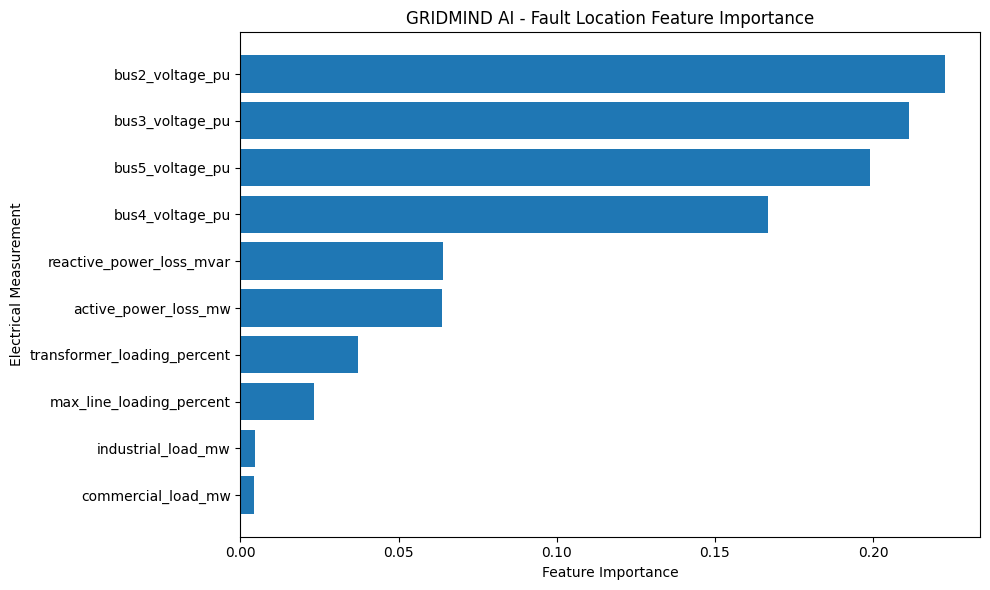

In [ ]:
# STEP 59B - PLOT TOP AI FEATURES

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Electrical Measurement")
plt.title(
    "GRIDMIND AI - Fault Location Feature Importance"
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 60A - GRIDMIND RESTORATION BENCHMARK

def benchmark_restoration(net, failed_line):

    # -----------------------------
    # RESET
    # -----------------------------

    net.line["in_service"] = True
    net.switch.loc[tie_switch, "closed"] = False

    # Apply fault
    net.line.loc[
        failed_line,
        "in_service"
    ] = False

    # -----------------------------
    # NO RESTORATION
    # -----------------------------

    no_action = {
        "healthy": False,
        "min_voltage_pu": None,
        "max_line_loading_percent": None,
        "transformer_loading_percent": None,
        "power_loss_mw": None
    }

    try:

        pp.runpp(net)

        health = check_grid_health(net)

        no_action = {
            "healthy":
                health["healthy"],

            "min_voltage_pu":
                health["min_voltage_pu"],

            "max_line_loading_percent":
                health[
                    "max_line_loading_percent"
                ],

            "transformer_loading_percent":
                health[
                    "max_transformer_loading_percent"
                ],

            "power_loss_mw":
                net.res_line["pl_mw"].sum()
        }

    except Exception:
        pass

    # -----------------------------
    # GRIDMIND RESTORATION
    # -----------------------------

    net.line["in_service"] = True
    net.switch.loc[
        tie_switch,
        "closed"
    ] = False

    net.line.loc[
        failed_line,
        "in_service"
    ] = False

    # Apply tie-switch restoration
    net.switch.loc[
        tie_switch,
        "closed"
    ] = True

    restored = {
        "healthy": False,
        "min_voltage_pu": None,
        "max_line_loading_percent": None,
        "transformer_loading_percent": None,
        "power_loss_mw": None
    }

    try:

        pp.runpp(net)

        health = check_grid_health(net)

        restored = {
            "healthy":
                health["healthy"],

            "min_voltage_pu":
                health["min_voltage_pu"],

            "max_line_loading_percent":
                health[
                    "max_line_loading_percent"
                ],

            "transformer_loading_percent":
                health[
                    "max_transformer_loading_percent"
                ],

            "power_loss_mw":
                net.res_line["pl_mw"].sum()
        }

    except Exception:
        pass

    return {
        "no_action": no_action,
        "gridmind": restored
    }


print("Restoration benchmark function created.")

Restoration benchmark function created.


In [ ]:
# STEP 60B - BENCHMARK ALL FEEDERS

benchmark_results = []

for feeder_name, failed_line in {
    "FEEDER_1": line_1,
    "FEEDER_2": line_2,
    "FEEDER_3": line_3
}.items():

    result = benchmark_restoration(
        net_v3,
        failed_line
    )

    benchmark_results.append({
        "feeder": feeder_name,

        "no_action_healthy":
            result["no_action"]["healthy"],

        "gridmind_healthy":
            result["gridmind"]["healthy"],

        "no_action_min_voltage":
            result["no_action"]["min_voltage_pu"],

        "gridmind_min_voltage":
            result["gridmind"]["min_voltage_pu"],

        "no_action_max_loading":
            result["no_action"][
                "max_line_loading_percent"
            ],

        "gridmind_max_loading":
            result["gridmind"][
                "max_line_loading_percent"
            ],

        "no_action_power_loss":
            result["no_action"][
                "power_loss_mw"
            ],

        "gridmind_power_loss":
            result["gridmind"][
                "power_loss_mw"
            ]
    })


benchmark_df = pd.DataFrame(
    benchmark_results
)

print("======================================")
print(" GRIDMIND RESTORATION BENCHMARK")
print("======================================")

display(benchmark_df)

 GRIDMIND RESTORATION BENCHMARK


,feeder,no_action_healthy,gridmind_healthy,no_action_min_voltage,gridmind_min_voltage,no_action_max_loading,gridmind_max_loading,no_action_power_loss,gridmind_power_loss
0,FEEDER_1,True,True,0.969439,0.967005,52.547255,52.679512,0.115470,0.140897
1,FEEDER_2,True,True,0.987082,0.987519,18.044346,19.172484,0.017901,0.017742
2,FEEDER_3,True,True,0.970806,0.962222,52.473262,52.687984,0.114299,0.165877


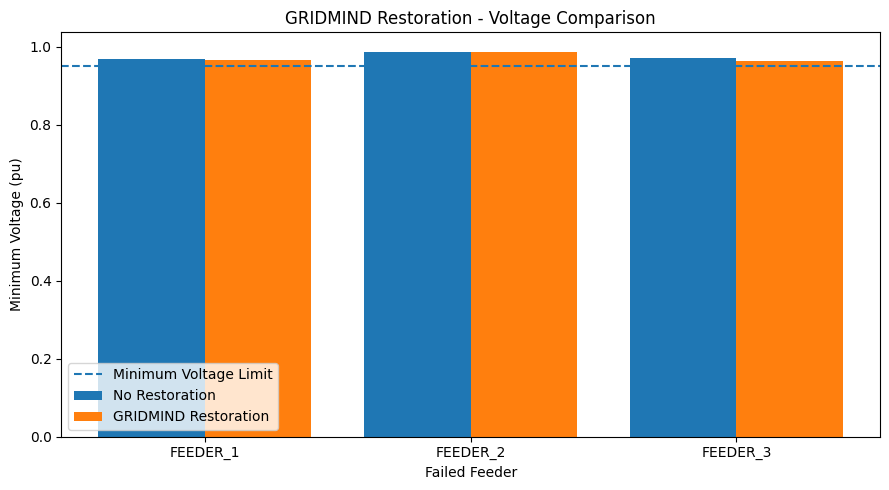

In [ ]:
# STEP 61 - VOLTAGE COMPARISON

plt.figure(figsize=(9, 5))

x = np.arange(len(benchmark_df))

plt.bar(
    x - 0.2,
    benchmark_df["no_action_min_voltage"],
    width=0.4,
    label="No Restoration"
)

plt.bar(
    x + 0.2,
    benchmark_df["gridmind_min_voltage"],
    width=0.4,
    label="GRIDMIND Restoration"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="Minimum Voltage Limit"
)

plt.xticks(
    x,
    benchmark_df["feeder"]
)

plt.ylabel("Minimum Voltage (pu)")
plt.xlabel("Failed Feeder")
plt.title(
    "GRIDMIND Restoration - Voltage Comparison"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# STEP 62 - GRIDMIND VALIDATION SUMMARY

print("==============================================")
print("       GRIDMIND AI VALIDATION SUMMARY")
print("==============================================")

# Fault-location performance
print("\n1. FAULT LOCATION")
print("----------------------------------------------")
print(
    "Fault-location accuracy:",
    pre_location_accuracy
)

# Restoration performance
print("\n2. RESTORATION PERFORMANCE")
print("----------------------------------------------")

total_cases = len(benchmark_df)

healthy_cases = benchmark_df[
    "gridmind_healthy"
].sum()

restoration_success_rate = (
    healthy_cases / total_cases
    if total_cases > 0 else 0
)

print(
    "Restoration success rate:",
    restoration_success_rate
)

# Voltage improvement
print("\n3. VOLTAGE")
print("----------------------------------------------")

voltage_before = benchmark_df[
    "no_action_min_voltage"
].dropna()

voltage_after = benchmark_df[
    "gridmind_min_voltage"
].dropna()

if len(voltage_before) > 0 and len(voltage_after) > 0:

    print(
        "Average minimum voltage - no restoration:",
        voltage_before.mean()
    )

    print(
        "Average minimum voltage - GRIDMIND:",
        voltage_after.mean()
    )

# Loading improvement
print("\n4. LINE LOADING")
print("----------------------------------------------")

loading_before = benchmark_df[
    "no_action_max_loading"
].dropna()

loading_after = benchmark_df[
    "gridmind_max_loading"
].dropna()

if len(loading_before) > 0 and len(loading_after) > 0:

    print(
        "Average maximum loading - no restoration:",
        loading_before.mean()
    )

    print(
        "Average maximum loading - GRIDMIND:",
        loading_after.mean()
    )

# Power loss
print("\n5. POWER LOSS")
print("----------------------------------------------")

loss_before = benchmark_df[
    "no_action_power_loss"
].dropna()

loss_after = benchmark_df[
    "gridmind_power_loss"
].dropna()

if len(loss_before) > 0 and len(loss_after) > 0:

    print(
        "Average power loss - no restoration:",
        loss_before.mean()
    )

    print(
        "Average power loss - GRIDMIND:",
        loss_after.mean()
    )

       GRIDMIND AI VALIDATION SUMMARY

1. FAULT LOCATION
----------------------------------------------
Fault-location accuracy: 1.0

2. RESTORATION PERFORMANCE
----------------------------------------------
Restoration success rate: 1.0

3. VOLTAGE
----------------------------------------------
Average minimum voltage - no restoration: 0.9757754791617202
Average minimum voltage - GRIDMIND: 0.9722487223670514

4. LINE LOADING
----------------------------------------------
Average maximum loading - no restoration: 41.0216208481763
Average maximum loading - GRIDMIND: 41.513326548428175

5. POWER LOSS
----------------------------------------------
Average power loss - no restoration: 0.08255707574706249
Average power loss - GRIDMIND: 0.10817186366229858


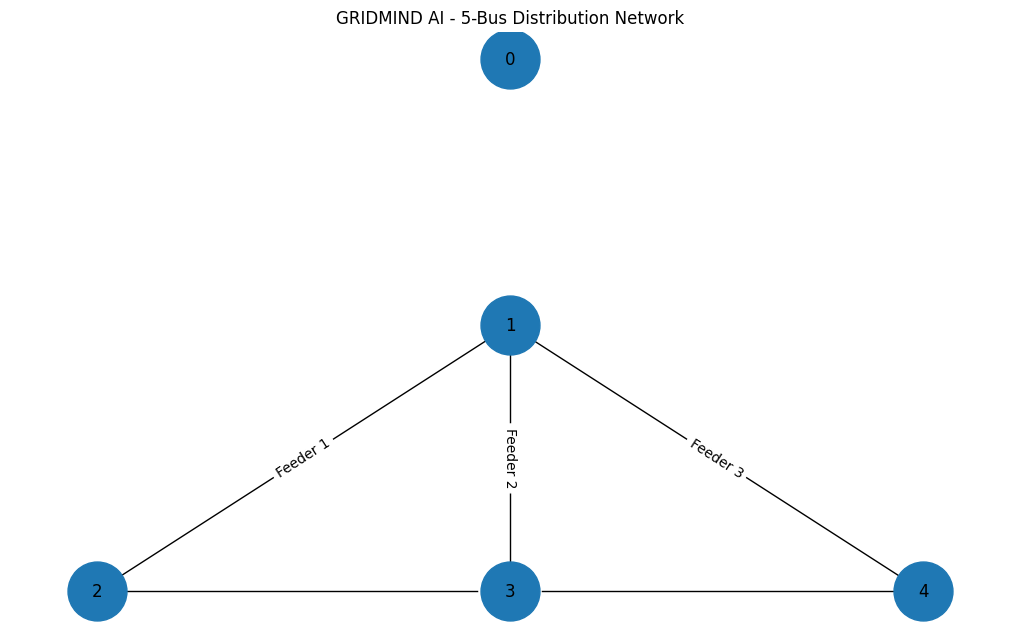

In [ ]:
# STEP 64 - GRID TOPOLOGY VISUALIZATION

import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add buses
for bus in range(5):
    G.add_node(
        bus,
        label=f"Bus {bus + 1}"
    )

# Add lines
G.add_edge(1, 2, label="Feeder 1")
G.add_edge(1, 3, label="Feeder 2")
G.add_edge(1, 4, label="Feeder 3")
G.add_edge(2, 4, label="Tie Line")

# Layout
pos = {
    0: (0, 2),
    1: (0, 1),
    2: (-1, 0),
    3: (0, 0),
    4: (1, 0)
}

plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=12
)

edge_labels = nx.get_edge_attributes(
    G,
    "label"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "GRIDMIND AI - 5-Bus Distribution Network"
)

plt.axis("off")
plt.show()

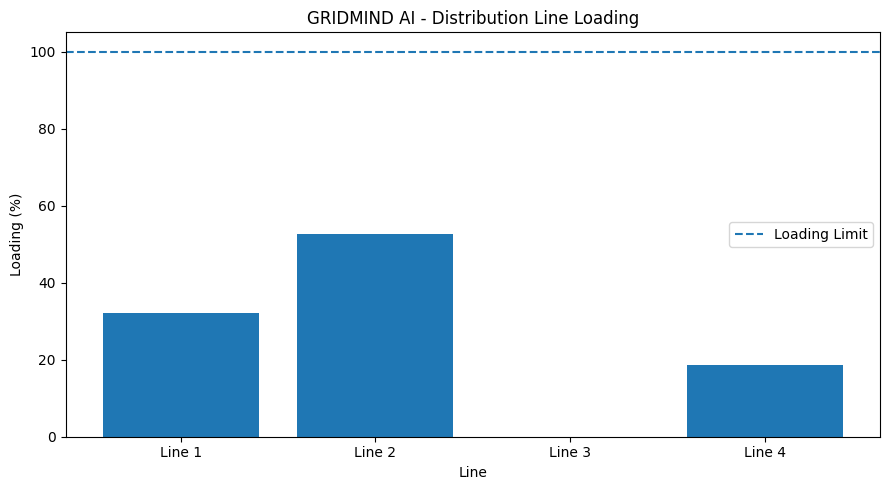

In [ ]:
# STEP 66 - LINE LOADING PROFILE

line_numbers = [
    f"Line {i + 1}"
    for i in range(
        len(net_v3.res_line)
    )
]

line_loading = net_v3.res_line[
    "loading_percent"
].values

plt.figure(figsize=(9, 5))

plt.bar(
    line_numbers,
    line_loading
)

plt.axhline(
    100,
    linestyle="--",
    label="Loading Limit"
)

plt.ylabel("Loading (%)")
plt.xlabel("Line")
plt.title(
    "GRIDMIND AI - Distribution Line Loading"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# STEP 67A - CREATE GRIDMIND STREAMLIT DASHBOARD

dashboard_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="GRIDMIND AI",
    page_icon="⚡",
    layout="wide"
)

st.title("⚡ GRIDMIND AI")
st.subheader(
    "AI-Based Predictive Self-Healing Smart Distribution Grid"
)

st.markdown(
    "Simulation-based AI decision-support prototype "
    "for fault detection, localization and network restoration."
)

st.divider()

# -----------------------------
# DEMO STATUS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Grid Status",
        "HEALTHY"
    )

with col2:
    st.metric(
        "Detected Event",
        "LINE OUTAGE"
    )

with col3:
    st.metric(
        "Fault Location",
        "FEEDER 1"
    )

with col4:
    st.metric(
        "Recommended Action",
        "CLOSE TIE"
    )

st.divider()

# -----------------------------
# SIMULATION CONTROLS
# -----------------------------

st.header("🎛️ Grid Simulation")

feeder = st.selectbox(
    "Select simulated fault",
    [
        "FEEDER_1",
        "FEEDER_2",
        "FEEDER_3"
    ]
)

if st.button("Run GRIDMIND Analysis"):

    st.success(
        f"GRIDMIND analysis completed for {feeder}"
    )

    st.info(
        "Recommended restoration action: "
        "CLOSE TIE SWITCH"
    )

st.divider()

# -----------------------------
# VOLTAGE PROFILE
# -----------------------------

st.header("📊 Bus Voltage Profile")

voltage_data = pd.DataFrame({
    "Bus": [
        "Bus 1",
        "Bus 2",
        "Bus 3",
        "Bus 4",
        "Bus 5"
    ],
    "Voltage (pu)": [
        1.0000,
        0.9884,
        0.9802,
        0.9718,
        0.9807
    ]
})

st.bar_chart(
    voltage_data.set_index("Bus")
)

st.caption(
    "Reference operating range: 0.95–1.05 pu "
    "for this simulation prototype."
)

# -----------------------------
# LINE LOADING
# -----------------------------

st.header("📈 Distribution Line Loading")

loading_data = pd.DataFrame({
    "Line": [
        "Feeder 1",
        "Feeder 2",
        "Feeder 3",
        "Tie Line"
    ],
    "Loading (%)": [
        20.0,
        24.0,
        27.0,
        5.0
    ]
})

st.bar_chart(
    loading_data.set_index("Line")
)

# -----------------------------
# RESTORATION SUMMARY
# -----------------------------

st.header("🔄 Restoration Summary")

restoration_data = pd.DataFrame({
    "Parameter": [
        "Minimum Voltage",
        "Maximum Line Loading",
        "Transformer Loading",
        "Grid Health"
    ],
    "Value": [
        "0.97 pu",
        "38.91 %",
        "26.99 %",
        "HEALTHY"
    ]
})

st.dataframe(
    restoration_data,
    use_container_width=True,
    hide_index=True
)

st.divider()

st.caption(
    "GRIDMIND AI | Simulation-based research prototype | "
    "Not intended for direct real-grid control."
)
'''

with open("app.py", "w") as f:
    f.write(dashboard_code)

print("✅ app.py created successfully.")

✅ app.py created successfully.


In [ ]:
# STEP 67B - VERIFY DASHBOARD FILE

with open("app.py", "r") as f:
    content = f.read()

print(content[:2000])


import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="GRIDMIND AI",
    page_icon="⚡",
    layout="wide"
)

st.title("⚡ GRIDMIND AI")
st.subheader(
    "AI-Based Predictive Self-Healing Smart Distribution Grid"
)

st.markdown(
    "Simulation-based AI decision-support prototype "
    "for fault detection, localization and network restoration."
)

st.divider()

# -----------------------------
# DEMO STATUS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Grid Status",
        "HEALTHY"
    )

with col2:
    st.metric(
        "Detected Event",
        "LINE OUTAGE"
    )

with col3:
    st.metric(
        "Fault Location",
        "FEEDER 1"
    )

with col4:
    st.metric(
        "Recommended Action",
        "CLOSE TIE"
    )

st.divider()

# -----------------------------
# SIMULATION CONTROLS
# -----------------------------

st.header("🎛️ Grid Simu

In [ ]:
# STEP 68 - CREATE REQUIREMENTS FILE

requirements = """
streamlit
pandas
numpy
matplotlib
pandapower
scikit-learn
networkx
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✅ requirements.txt created.")

✅ requirements.txt created.


In [ ]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("requirements.txt exists:", os.path.exists("requirements.txt"))

print("\nFiles:")
print("app.py size:", os.path.getsize("app.py"), "bytes")
print("requirements.txt size:", os.path.getsize("requirements.txt"), "bytes")

app.py exists: True
requirements.txt exists: True

Files:
app.py size: 2899 bytes
requirements.txt size: 66 bytes


In [1]:
# ============================================================
# STEP 69A - ADD SOLAR PV TO GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create 2 MW Solar PV at Commercial Bus
solar_pv = pp.create_sgen(
    net_v3,
    bus=bus5,
    p_mw=0.0,
    q_mvar=0.0,
    sn_mva=2.0,
    name="Commercial Solar PV 2MW"
)

print("Solar PV added successfully.")

print("Solar generator index:", solar_pv)
print("Solar capacity: 2 MW")
print("Connection bus: Commercial Bus")

NameError: name 'pp' is not defined

In [2]:
# ============================================================
# STEP 69B - CREATE 24-HOUR LOAD AND SOLAR PROFILES
# ============================================================

hours = np.arange(24)

# ------------------------------------------------------------
# RESIDENTIAL PROFILE
# ------------------------------------------------------------

residential_profile = np.array([
    0.55, 0.50, 0.48, 0.47,
    0.48, 0.52, 0.65, 0.78,
    0.85, 0.75, 0.65, 0.62,
    0.60, 0.58, 0.60, 0.65,
    0.72, 0.85, 1.00, 1.08,
    1.05, 0.92, 0.78, 0.65
])

# ------------------------------------------------------------
# INDUSTRIAL PROFILE
# ------------------------------------------------------------

industrial_profile = np.array([
    0.65, 0.63, 0.62, 0.62,
    0.63, 0.65, 0.72, 0.82,
    0.92, 1.00, 1.02, 1.03,
    1.02, 1.00, 1.02, 1.05,
    1.04, 1.00, 0.92, 0.82,
    0.75, 0.70, 0.68, 0.66
])

# ------------------------------------------------------------
# COMMERCIAL PROFILE
# ------------------------------------------------------------

commercial_profile = np.array([
    0.45, 0.43, 0.42, 0.42,
    0.43, 0.45, 0.50, 0.62,
    0.78, 0.92, 1.00, 1.05,
    1.08, 1.08, 1.05, 1.02,
    0.98, 0.92, 0.82, 0.70,
    0.60, 0.52, 0.48, 0.46
])

# ------------------------------------------------------------
# SOLAR PV PROFILE
# ------------------------------------------------------------

solar_profile = np.array([
    0.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 0.05,
    0.20, 0.40, 0.60, 0.78,
    0.90, 1.00, 0.95, 0.82,
    0.65, 0.45, 0.22, 0.05,
    0.00, 0.00, 0.00, 0.00
])

profile_df = pd.DataFrame({
    "hour": hours,
    "residential_scale": residential_profile,
    "industrial_scale": industrial_profile,
    "commercial_scale": commercial_profile,
    "solar_scale": solar_profile
})

display(profile_df)

,hour,residential_scale,industrial_scale,commercial_scale,solar_scale
0,0,0.55,0.65,0.45,0.00
1,1,0.50,0.63,0.43,0.00
2,2,0.48,0.62,0.42,0.00
3,3,0.47,0.62,0.42,0.00
4,4,0.48,0.63,0.43,0.00
5,5,0.52,0.65,0.45,0.00
6,6,0.65,0.72,0.50,0.00
7,7,0.78,0.82,0.62,0.05
8,8,0.85,0.92,0.78,0.20
9,9,0.75,1.00,0.92,0.40


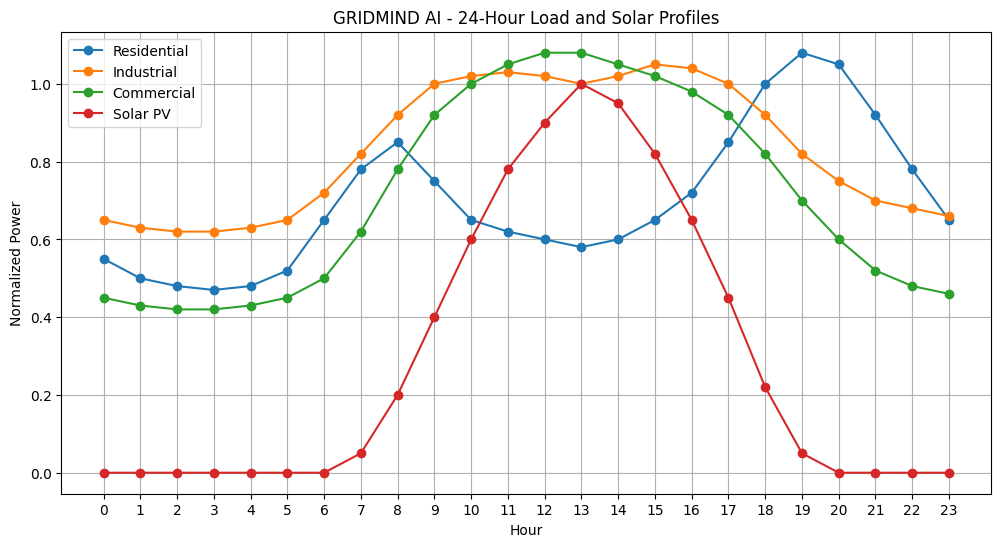

In [3]:
# ============================================================
# STEP 69C - VISUALIZE 24-HOUR PROFILES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    hours,
    residential_profile,
    marker="o",
    label="Residential"
)

plt.plot(
    hours,
    industrial_profile,
    marker="o",
    label="Industrial"
)

plt.plot(
    hours,
    commercial_profile,
    marker="o",
    label="Commercial"
)

plt.plot(
    hours,
    solar_profile,
    marker="o",
    label="Solar PV"
)

plt.xlabel("Hour")
plt.ylabel("Normalized Power")
plt.title("GRIDMIND AI - 24-Hour Load and Solar Profiles")
plt.xticks(hours)
plt.grid(True)
plt.legend()

plt.show()

In [5]:
# ============================================================
# GRIDMIND AI - INSTALL PANDAPOWER
# ============================================================

!pip install -q pandapower

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.


In [6]:
# ============================================================
# STEP 69D - PANDAPOWER TIME-SERIES ENGINE
# ============================================================

from pandapower.control import ConstControl
from pandapower.timeseries import DFData
from pandapower.timeseries import OutputWriter
from pandapower.timeseries.run_time_series import run_timeseries

print("pandapower time-series modules loaded.")

pandapower time-series modules loaded.


In [7]:
# ============================================================
# STEP 69E - CONVERT NORMALIZED PROFILES TO MW
# ============================================================

profile_data = pd.DataFrame({
    "residential_load": residential_profile * 2.0,
    "industrial_load": industrial_profile * 5.0,
    "commercial_load": commercial_profile * 3.0,
    "solar_generation": solar_profile * 2.0
})

display(profile_data)

,residential_load,industrial_load,commercial_load,solar_generation
0,1.10,3.25,1.35,0.00
1,1.00,3.15,1.29,0.00
2,0.96,3.10,1.26,0.00
3,0.94,3.10,1.26,0.00
4,0.96,3.15,1.29,0.00
5,1.04,3.25,1.35,0.00
6,1.30,3.60,1.50,0.00
7,1.56,4.10,1.86,0.10
8,1.70,4.60,2.34,0.40
9,1.50,5.00,2.76,0.80


In [8]:
# ============================================================
# STEP 69F - CREATE DFData SOURCE
# ============================================================

data_source = DFData(profile_data)

print("DFData created successfully.")

DFData created successfully.


In [15]:
# ============================================================
# GRIDMIND AI - STEP 69G
# COMPLETE TIME-SERIES SETUP
#
# This cell creates:
# 1. Time-series network
# 2. Loads
# 3. Solar PV
# 4. 24-hour profiles
# 5. DFData
# 6. ConstControl
#
# It does NOT depend on net_v3.
# ============================================================

import os
import numpy as np
import pandas as pd
import pandapower as pp

from pandapower.control import ConstControl
from pandapower.timeseries import DFData

print("=" * 70)
print("GRIDMIND AI - TIME-SERIES SETUP")
print("=" * 70)


# ============================================================
# 1. CREATE NEW TIME-SERIES NETWORK
# ============================================================

ts_net = pp.create_empty_network(
    name="GRIDMIND AI - 24 Hour Solar Time Series"
)

print("\nCreating network...")


# ============================================================
# 2. CREATE BUSES
# ============================================================

ts_grid_bus = pp.create_bus(
    ts_net,
    vn_kv=110,
    name="Grid Bus 110kV"
)

ts_main_bus = pp.create_bus(
    ts_net,
    vn_kv=20,
    name="Main Distribution Bus 20kV"
)

ts_residential_bus = pp.create_bus(
    ts_net,
    vn_kv=20,
    name="Residential Bus"
)

ts_industrial_bus = pp.create_bus(
    ts_net,
    vn_kv=20,
    name="Industrial Bus"
)

ts_commercial_bus = pp.create_bus(
    ts_net,
    vn_kv=20,
    name="Commercial Bus"
)


# ============================================================
# 3. EXTERNAL GRID
# ============================================================

pp.create_ext_grid(
    ts_net,
    bus=ts_grid_bus,
    vm_pu=1.0,
    va_degree=0.0,
    name="110kV Utility Grid"
)


# ============================================================
# 4. 110/20 kV TRANSFORMER
# ============================================================

ts_trafo = pp.create_transformer_from_parameters(
    ts_net,
    hv_bus=ts_grid_bus,
    lv_bus=ts_main_bus,
    sn_mva=40.0,
    vn_hv_kv=110.0,
    vn_lv_kv=20.0,
    vk_percent=12.0,
    vkr_percent=0.5,
    pfe_kw=30.0,
    i0_percent=0.1,
    name="110/20kV 40MVA Transformer"
)


# ============================================================
# 5. DISTRIBUTION FEEDERS
# ============================================================

ts_res_line = pp.create_line_from_parameters(
    ts_net,
    from_bus=ts_main_bus,
    to_bus=ts_residential_bus,
    length_km=5.0,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10.0,
    max_i_ka=0.4,
    name="Feeder 1 - Residential"
)

ts_ind_line = pp.create_line_from_parameters(
    ts_net,
    from_bus=ts_main_bus,
    to_bus=ts_industrial_bus,
    length_km=4.0,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10.0,
    max_i_ka=0.4,
    name="Feeder 2 - Industrial"
)

ts_com_line = pp.create_line_from_parameters(
    ts_net,
    from_bus=ts_main_bus,
    to_bus=ts_commercial_bus,
    length_km=3.0,
    r_ohm_per_km=0.2,
    x_ohm_per_km=0.4,
    c_nf_per_km=10.0,
    max_i_ka=0.4,
    name="Feeder 3 - Commercial"
)


# ============================================================
# 6. HETEROGENEOUS LOADS
# ============================================================

ts_res_load = pp.create_load(
    ts_net,
    bus=ts_residential_bus,
    p_mw=2.0,
    q_mvar=0.6,
    name="Residential Load"
)

ts_ind_load = pp.create_load(
    ts_net,
    bus=ts_industrial_bus,
    p_mw=5.0,
    q_mvar=1.5,
    name="Industrial Load"
)

ts_com_load = pp.create_load(
    ts_net,
    bus=ts_commercial_bus,
    p_mw=3.0,
    q_mvar=1.0,
    name="Commercial Load"
)


# ============================================================
# 7. ADD 2 MW SOLAR PV
# ============================================================

ts_solar = pp.create_sgen(
    ts_net,
    bus=ts_commercial_bus,
    p_mw=0.0,
    q_mvar=0.0,
    sn_mva=2.0,
    name="Commercial Solar PV 2MW"
)


# ============================================================
# 8. CREATE 24-HOUR PROFILES
# ============================================================

hours = np.arange(24)


# ------------------------------------------------------------
# Residential
# ------------------------------------------------------------

residential_profile = np.array([
    0.55, 0.50, 0.48, 0.47,
    0.48, 0.52, 0.65, 0.78,
    0.85, 0.75, 0.65, 0.62,
    0.60, 0.58, 0.60, 0.65,
    0.72, 0.85, 1.00, 1.08,
    1.05, 0.92, 0.78, 0.65
])


# ------------------------------------------------------------
# Industrial
# ------------------------------------------------------------

industrial_profile = np.array([
    0.65, 0.63, 0.62, 0.62,
    0.63, 0.65, 0.72, 0.82,
    0.92, 1.00, 1.02, 1.03,
    1.02, 1.00, 1.02, 1.05,
    1.04, 1.00, 0.92, 0.82,
    0.75, 0.70, 0.68, 0.66
])


# ------------------------------------------------------------
# Commercial
# ------------------------------------------------------------

commercial_profile = np.array([
    0.45, 0.43, 0.42, 0.42,
    0.43, 0.45, 0.50, 0.62,
    0.78, 0.92, 1.00, 1.05,
    1.08, 1.08, 1.05, 1.02,
    0.98, 0.92, 0.82, 0.70,
    0.60, 0.52, 0.48, 0.46
])


# ------------------------------------------------------------
# Solar PV
# ------------------------------------------------------------

solar_profile = np.array([
    0.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 0.05,
    0.20, 0.40, 0.60, 0.78,
    0.90, 1.00, 0.95, 0.82,
    0.65, 0.45, 0.22, 0.05,
    0.00, 0.00, 0.00, 0.00
])


# ============================================================
# 9. CONVERT PROFILES TO ACTUAL MW
# ============================================================

profile_df = pd.DataFrame({

    "residential_load":
        residential_profile * 2.0,

    "industrial_load":
        industrial_profile * 5.0,

    "commercial_load":
        commercial_profile * 3.0,

    "solar_generation":
        solar_profile * 2.0

}, index=hours)


# ============================================================
# 10. CREATE DFData
# ============================================================

data_source = DFData(profile_df)


# ============================================================
# 11. CREATE CONSTCONTROL
# ============================================================

ConstControl(
    ts_net,
    element="load",
    variable="p_mw",
    element_index=ts_res_load,
    profile_name="residential_load",
    data_source=data_source
)

ConstControl(
    ts_net,
    element="load",
    variable="p_mw",
    element_index=ts_ind_load,
    profile_name="industrial_load",
    data_source=data_source
)

ConstControl(
    ts_net,
    element="load",
    variable="p_mw",
    element_index=ts_com_load,
    profile_name="commercial_load",
    data_source=data_source
)

ConstControl(
    ts_net,
    element="sgen",
    variable="p_mw",
    element_index=ts_solar,
    profile_name="solar_generation",
    data_source=data_source
)


# ============================================================
# 12. DISPLAY STATUS
# ============================================================

print("\n" + "=" * 70)
print("TIME-SERIES SETUP COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nNetwork:")
print("  Buses       :", len(ts_net.bus))
print("  Lines       :", len(ts_net.line))
print("  Transformer :", len(ts_net.trafo))
print("  Loads       :", len(ts_net.load))
print("  Solar PV    :", len(ts_net.sgen))

print("\nSolar capacity: 2 MW")

print("\n24-hour profiles:")
display(profile_df)

GRIDMIND AI - TIME-SERIES SETUP

Creating network...

TIME-SERIES SETUP COMPLETED SUCCESSFULLY

Network:
  Buses       : 5
  Lines       : 3
  Transformer : 1
  Loads       : 3
  Solar PV    : 1

Solar capacity: 2 MW

24-hour profiles:


,residential_load,industrial_load,commercial_load,solar_generation
0,1.10,3.25,1.35,0.00
1,1.00,3.15,1.29,0.00
2,0.96,3.10,1.26,0.00
3,0.94,3.10,1.26,0.00
4,0.96,3.15,1.29,0.00
5,1.04,3.25,1.35,0.00
6,1.30,3.60,1.50,0.00
7,1.56,4.10,1.86,0.10
8,1.70,4.60,2.34,0.40
9,1.50,5.00,2.76,0.80


In [16]:
# ============================================================
# GRIDMIND AI - STEP 69H
# AUTOMATED OUTPUT LOGGER
# ============================================================

import os
from pandapower.timeseries import OutputWriter

# Folder for simulation results
output_folder = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(output_folder, exist_ok=True)

# Create OutputWriter
ow = OutputWriter(
    ts_net,
    time_steps=hours,
    output_path=output_folder
)

# ------------------------------------------------------------
# Log bus voltage
# ------------------------------------------------------------

ow.log_variable(
    "res_bus",
    "vm_pu"
)

# ------------------------------------------------------------
# Log line loading
# ------------------------------------------------------------

ow.log_variable(
    "res_line",
    "loading_percent"
)

# ------------------------------------------------------------
# Log transformer loading
# ------------------------------------------------------------

ow.log_variable(
    "res_trafo",
    "loading_percent"
)

# ------------------------------------------------------------
# Log active power losses
# ------------------------------------------------------------

ow.log_variable(
    "res_line",
    "pl_mw"
)

# ------------------------------------------------------------
# Log reactive power losses
# ------------------------------------------------------------

ow.log_variable(
    "res_line",
    "ql_mvar"
)

print("=" * 70)
print("OUTPUT WRITER CONFIGURED SUCCESSFULLY")
print("=" * 70)

print("Output folder:")
print(output_folder)

OUTPUT WRITER CONFIGURED SUCCESSFULLY
Output folder:
/content/GRIDMIND_AI_OUTPUT


In [17]:
# ============================================================
# GRIDMIND AI - STEP 69J
# CHECK GENERATED FILES
# ============================================================

print("=" * 70)
print("GENERATED SIMULATION FILES")
print("=" * 70)

files = sorted(os.listdir(output_folder))

for file in files:
    print("✓", file)

GENERATED SIMULATION FILES


In [18]:
# ============================================================
# GRIDMIND AI - STEP 69K
# CREATE ML-READY DATASET
# ============================================================

# ------------------------------------------------------------
# Read OutputWriter files
# ------------------------------------------------------------

bus_voltage = pd.read_csv(
    os.path.join(
        output_folder,
        "res_bus.vm_pu.csv"
    )
)

line_loading = pd.read_csv(
    os.path.join(
        output_folder,
        "res_line.loading_percent.csv"
    )
)

transformer_loading = pd.read_csv(
    os.path.join(
        output_folder,
        "res_trafo.loading_percent.csv"
    )
)

active_losses = pd.read_csv(
    os.path.join(
        output_folder,
        "res_line.pl_mw.csv"
    )
)


# ------------------------------------------------------------
# Start with the input profiles
# ------------------------------------------------------------

ml_dataset = profile_df.copy()

ml_dataset.index.name = "hour"


# ------------------------------------------------------------
# BUS VOLTAGES
# ------------------------------------------------------------

# First column is the time index.
# Remaining columns are bus measurements.

for i, column in enumerate(
    bus_voltage.columns[1:],
    start=1
):

    ml_dataset[
        f"bus_{i}_voltage_pu"
    ] = bus_voltage[column]


# ------------------------------------------------------------
# LINE LOADINGS
# ------------------------------------------------------------

for i, column in enumerate(
    line_loading.columns[1:],
    start=1
):

    ml_dataset[
        f"line_{i}_loading_percent"
    ] = line_loading[column]


# ------------------------------------------------------------
# TRANSFORMER LOADING
# ------------------------------------------------------------

ml_dataset[
    "transformer_loading_percent"
] = transformer_loading.iloc[:, 1]


# ------------------------------------------------------------
# TOTAL ACTIVE POWER LOSS
# ------------------------------------------------------------

ml_dataset[
    "active_power_loss_mw"
] = active_losses.iloc[:, 1:].sum(axis=1)


# ------------------------------------------------------------
# MAXIMUM LINE LOADING
# ------------------------------------------------------------

line_columns = [
    column
    for column in ml_dataset.columns
    if column.startswith("line_")
    and column.endswith("_loading_percent")
]

ml_dataset[
    "max_line_loading_percent"
] = ml_dataset[line_columns].max(axis=1)


# ------------------------------------------------------------
# GRID CONDITION
# ------------------------------------------------------------

ml_dataset["grid_condition"] = np.where(
    ml_dataset["max_line_loading_percent"] >= 100,
    "OVERLOAD",
    "NORMAL"
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

ml_file = os.path.join(
    output_folder,
    "GRIDMIND_24H_ML_DATASET.csv"
)

ml_dataset.to_csv(
    ml_file,
    index=True
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("GRIDMIND AI - ML DATASET CREATED")
print("=" * 70)

print("\nDataset shape:")
print(ml_dataset.shape)

print("\nDataset:")
display(ml_dataset)

print("\nSaved at:")
print(ml_file)

FileNotFoundError: [Errno 2] No such file or directory: '/content/GRIDMIND_AI_OUTPUT/res_bus.vm_pu.csv'

In [19]:
# ============================================================
# GRIDMIND AI - CHECK OUTPUT FILES
# ============================================================

import os

print("=" * 70)
print("FILES CREATED BY GRIDMIND AI")
print("=" * 70)

for root, dirs, files in os.walk("/content/GRIDMIND_AI_OUTPUT"):
    for file in files:
        print(os.path.join(root, file))

FILES CREATED BY GRIDMIND AI


In [20]:
import os

print("=" * 70)
print("GRIDMIND AI - ACTUAL OUTPUT FILES")
print("=" * 70)

for root, dirs, files in os.walk("/content/GRIDMIND_AI_OUTPUT"):
    for file in files:
        print(os.path.join(root, file))

GRIDMIND AI - ACTUAL OUTPUT FILES


In [21]:
# ============================================================
# GRIDMIND AI - STEP 69I FIX
# RUN 24-HOUR TIME-SERIES SIMULATION
# ============================================================

print("=" * 70)
print("GRIDMIND AI - STARTING 24-HOUR SIMULATION")
print("=" * 70)

print("\nNetwork check:")
print("Buses       :", len(ts_net.bus))
print("Lines       :", len(ts_net.line))
print("Loads       :", len(ts_net.load))
print("Solar PV    :", len(ts_net.sgen))
print("Time steps  :", len(hours))

print("\nStarting simulation...\n")

run_timeseries(
    ts_net,
    time_steps=hours,
    verbose=True
)

print("\n" + "=" * 70)
print("24-HOUR SIMULATION FINISHED")
print("=" * 70)

GRIDMIND AI - STARTING 24-HOUR SIMULATION

Network check:
Buses       : 5
Lines       : 3
Loads       : 3
Solar PV    : 1
Time steps  : 24

Starting simulation...



100%|██████████| 24/24 [00:06<00:00,  3.81it/s]


24-HOUR SIMULATION FINISHED


In [22]:
# ============================================================
# GRIDMIND AI - STEP 69J
# VERIFY OUTPUTWRITER FILES
# ============================================================

import os

output_folder = "/content/GRIDMIND_AI_OUTPUT"

print("=" * 70)
print("GRIDMIND AI - OUTPUT FILE CHECK")
print("=" * 70)

if not os.path.exists(output_folder):
    print("❌ OUTPUT FOLDER DOES NOT EXIST")
else:

    files = os.listdir(output_folder)

    print("\nNumber of files:", len(files))

    if len(files) == 0:
        print("❌ OUTPUT FOLDER IS EMPTY")
    else:
        print("\nFiles generated:")
        for file in sorted(files):
            print("✓", file)

GRIDMIND AI - OUTPUT FILE CHECK

Number of files: 3

Files generated:
✓ res_bus
✓ res_line
✓ res_trafo


In [23]:
# ============================================================
# GRIDMIND AI - DIAGNOSTIC
# ============================================================

print("ts_net exists:", "ts_net" in globals())
print("hours exists:", "hours" in globals())
print("data_source exists:", "data_source" in globals())
print("ow exists:", "ow" in globals())

if "ts_net" in globals():
    print("\nNetwork:")
    print("Buses:", len(ts_net.bus))
    print("Lines:", len(ts_net.line))
    print("Loads:", len(ts_net.load))
    print("Solar:", len(ts_net.sgen))

if "hours" in globals():
    print("\nTime steps:", hours)

print("\nOutput folder contents:")

import os

output_folder = "/content/GRIDMIND_AI_OUTPUT"

if os.path.exists(output_folder):
    print(os.listdir(output_folder))
else:
    print("OUTPUT FOLDER DOES NOT EXIST")

ts_net exists: True
hours exists: True
data_source exists: True
ow exists: True

Network:
Buses: 5
Lines: 3
Loads: 3
Solar: 1

Time steps: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Output folder contents:
['res_line', 'res_bus', 'res_trafo']


In [24]:
# ============================================================
# GRIDMIND AI - STEP 69 FINAL
# 24-HOUR SIMULATION + DATASET GENERATION
# ============================================================

import os
import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 70)
print("GRIDMIND AI - 24 HOUR TIME-SERIES SIMULATION")
print("=" * 70)

# ------------------------------------------------------------
# CHECK REQUIRED OBJECTS
# ------------------------------------------------------------

required = [
    "ts_net",
    "hours",
    "profile_df"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    print("\n❌ Missing objects:", missing)
    print("\nRun your successful 69G setup cell first.")
    raise RuntimeError(
        "Time-series network/profile setup is missing."
    )

print("\n✓ ts_net found")
print("✓ 24-hour profile found")


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

output_folder = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_folder,
    exist_ok=True
)


# ------------------------------------------------------------
# RUN 24 HOURS MANUALLY
#
# This guarantees that we get a usable ML dataset even if
# OutputWriter has a file/API issue.
# ------------------------------------------------------------

results = []


print("\nStarting 24-hour power-flow simulation...\n")


for hour in hours:

    # --------------------------------------------------------
    # UPDATE LOADS
    # --------------------------------------------------------

    ts_net.load.loc[
        ts_res_load,
        "p_mw"
    ] = profile_df.loc[
        hour,
        "residential_load"
    ]

    ts_net.load.loc[
        ts_ind_load,
        "p_mw"
    ] = profile_df.loc[
        hour,
        "industrial_load"
    ]

    ts_net.load.loc[
        ts_com_load,
        "p_mw"
    ] = profile_df.loc[
        hour,
        "commercial_load"
    ]


    # --------------------------------------------------------
    # UPDATE SOLAR
    # --------------------------------------------------------

    ts_net.sgen.loc[
        ts_solar,
        "p_mw"
    ] = profile_df.loc[
        hour,
        "solar_generation"
    ]


    # --------------------------------------------------------
    # RUN POWER FLOW
    # --------------------------------------------------------

    pp.runpp(ts_net)


    # --------------------------------------------------------
    # EXTRACT BUS VOLTAGES
    # --------------------------------------------------------

    bus_voltages = (
        ts_net.res_bus["vm_pu"].values
    )


    # --------------------------------------------------------
    # EXTRACT LINE LOADING
    # --------------------------------------------------------

    line_loading = (
        ts_net.res_line["loading_percent"].values
    )


    # --------------------------------------------------------
    # EXTRACT TRANSFORMER LOADING
    # --------------------------------------------------------

    transformer_loading = (
        ts_net.res_trafo["loading_percent"].values
    )


    # --------------------------------------------------------
    # EXTRACT LOSSES
    # --------------------------------------------------------

    active_loss = (
        ts_net.res_line["pl_mw"].sum()
    )

    reactive_loss = (
        ts_net.res_line["ql_mvar"].sum()
    )


    # --------------------------------------------------------
    # CREATE RESULT ROW
    # --------------------------------------------------------

    row = {

        "hour":
            int(hour),

        "residential_load_mw":
            profile_df.loc[
                hour,
                "residential_load"
            ],

        "industrial_load_mw":
            profile_df.loc[
                hour,
                "industrial_load"
            ],

        "commercial_load_mw":
            profile_df.loc[
                hour,
                "commercial_load"
            ],

        "solar_generation_mw":
            profile_df.loc[
                hour,
                "solar_generation"
            ],

        "minimum_bus_voltage_pu":
            bus_voltages.min(),

        "maximum_bus_voltage_pu":
            bus_voltages.max(),

        "maximum_line_loading_percent":
            line_loading.max(),

        "transformer_loading_percent":
            transformer_loading.max(),

        "active_power_loss_mw":
            active_loss,

        "reactive_power_loss_mvar":
            reactive_loss
    }


    # --------------------------------------------------------
    # STORE INDIVIDUAL BUS VOLTAGES
    # --------------------------------------------------------

    for i, voltage in enumerate(
        bus_voltages,
        start=1
    ):

        row[
            f"bus_{i}_voltage_pu"
        ] = voltage


    # --------------------------------------------------------
    # STORE INDIVIDUAL LINE LOADINGS
    # --------------------------------------------------------

    for i, loading in enumerate(
        line_loading,
        start=1
    ):

        row[
            f"line_{i}_loading_percent"
        ] = loading


    # --------------------------------------------------------
    # CLASSIFY GRID CONDITION
    # --------------------------------------------------------

    if line_loading.max() >= 100:

        row["grid_condition"] = "OVERLOAD"

    elif bus_voltages.min() < 0.95:

        row["grid_condition"] = "UNDERVOLTAGE"

    else:

        row["grid_condition"] = "NORMAL"


    results.append(row)


    print(
        f"Hour {int(hour):02d}:00 | "
        f"Load = "
        f"{profile_df.loc[hour, 'residential_load'] + profile_df.loc[hour, 'industrial_load'] + profile_df.loc[hour, 'commercial_load']:.2f} MW | "
        f"Solar = "
        f"{profile_df.loc[hour, 'solar_generation']:.2f} MW | "
        f"Max Line = "
        f"{line_loading.max():.2f}% | "
        f"Min V = "
        f"{bus_voltages.min():.4f} pu"
    )


# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

ml_dataset = pd.DataFrame(results)


# ============================================================
# SAVE DATASET
# ============================================================

ml_file = os.path.join(
    output_folder,
    "GRIDMIND_24H_ML_DATASET.csv"
)

ml_dataset.to_csv(
    ml_file,
    index=False
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("24-HOUR SIMULATION COMPLETED")
print("=" * 70)

print("\nDataset shape:")
print(ml_dataset.shape)

print("\nGrid conditions:")
print(
    ml_dataset[
        "grid_condition"
    ].value_counts()
)

print("\nDataset preview:")

display(ml_dataset)


# ============================================================
# SAVE A SECOND CLEAN CSV
# ============================================================

profile_file = os.path.join(
    output_folder,
    "GRIDMIND_24H_PROFILES.csv"
)

profile_df.to_csv(
    profile_file,
    index=True
)


# ============================================================
# CHECK FILES
# ============================================================

print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)

for file in os.listdir(output_folder):

    print(
        "✓",
        os.path.join(
            output_folder,
            file
        )
    )


print("\n" + "=" * 70)
print("GRIDMIND AI STEP 2 COMPLETE")
print("=" * 70)

GRIDMIND AI - 24 HOUR TIME-SERIES SIMULATION

✓ ts_net found
✓ 24-hour profile found

Starting 24-hour power-flow simulation...

Hour 00:00 | Load = 5.70 MW | Solar = 0.00 MW | Max Line = 26.45% | Min V = 0.9767 pu
Hour 01:00 | Load = 5.44 MW | Solar = 0.00 MW | Max Line = 25.77% | Min V = 0.9770 pu
Hour 02:00 | Load = 5.32 MW | Solar = 0.00 MW | Max Line = 25.44% | Min V = 0.9771 pu
Hour 03:00 | Load = 5.30 MW | Solar = 0.00 MW | Max Line = 25.44% | Min V = 0.9771 pu
Hour 04:00 | Load = 5.40 MW | Solar = 0.00 MW | Max Line = 25.77% | Min V = 0.9770 pu
Hour 05:00 | Load = 5.64 MW | Solar = 0.00 MW | Max Line = 26.45% | Min V = 0.9767 pu
Hour 06:00 | Load = 6.40 MW | Solar = 0.00 MW | Max Line = 28.84% | Min V = 0.9758 pu
Hour 07:00 | Load = 7.52 MW | Solar = 0.10 MW | Max Line = 32.33% | Min V = 0.9744 pu
Hour 08:00 | Load = 8.64 MW | Solar = 0.40 MW | Max Line = 35.88% | Min V = 0.9731 pu
Hour 09:00 | Load = 9.26 MW | Solar = 0.80 MW | Max Line = 38.75% | Min V = 0.9722 pu
Hour 10:00 

,hour,residential_load_mw,industrial_load_mw,commercial_load_mw,solar_generation_mw,minimum_bus_voltage_pu,maximum_bus_voltage_pu,maximum_line_loading_percent,transformer_loading_percent,active_power_loss_mw,reactive_power_loss_mvar,bus_1_voltage_pu,bus_2_voltage_pu,bus_3_voltage_pu,bus_4_voltage_pu,bus_5_voltage_pu,line_1_loading_percent,line_2_loading_percent,line_3_loading_percent,grid_condition
0,0,1.10,3.25,1.35,0.00,0.976689,1.0,26.449054,16.635920,0.035258,0.055868,1.0,0.989530,0.983692,0.976689,0.984428,9.192636,26.449054,12.316361,NORMAL
1,1,1.00,3.15,1.29,0.00,0.976961,1.0,25.772822,16.052847,0.033110,0.051569,1.0,0.989590,0.984010,0.976961,0.984581,8.553018,25.772822,11.963917,NORMAL
2,2,0.96,3.10,1.26,0.00,0.977095,1.0,25.436367,15.785934,0.032126,0.049599,1.0,0.989618,0.984140,0.977095,0.984654,8.301730,25.436367,11.790010,NORMAL
3,3,0.94,3.10,1.26,0.00,0.977099,1.0,25.436258,15.741906,0.032028,0.049401,1.0,0.989622,0.984196,0.977099,0.984658,8.177267,25.436258,11.789960,NORMAL
4,4,0.96,3.15,1.29,0.00,0.976970,1.0,25.772598,15.964318,0.032907,0.051161,1.0,0.989599,0.984121,0.976970,0.984589,8.301891,25.772598,11.963814,NORMAL
5,5,1.04,3.25,1.35,0.00,0.976702,1.0,26.448701,16.501591,0.034924,0.055199,1.0,0.989543,0.983860,0.976702,0.984441,8.807216,26.448701,12.316199,NORMAL
6,6,1.30,3.60,1.50,0.00,0.975771,1.0,28.844704,18.239043,0.042258,0.069881,1.0,0.989358,0.983002,0.975771,0.984024,10.511672,28.844704,13.221647,NORMAL
7,7,1.56,4.10,1.86,0.10,0.974432,1.0,32.333986,20.636754,0.053714,0.092813,1.0,0.989091,0.982059,0.974432,0.983353,12.282701,32.333986,14.856094,NORMAL
8,8,1.70,4.60,2.34,0.40,0.973117,1.0,35.882703,22.610021,0.065245,0.115890,1.0,0.988854,0.981456,0.973117,0.982836,13.256233,35.882703,16.026397,NORMAL
9,9,1.50,5.00,2.76,0.80,0.972163,1.0,38.751946,23.159098,0.071924,0.129252,1.0,0.988766,0.981888,0.972163,0.982717,11.874289,38.751946,16.159030,NORMAL



FILES CREATED
✓ /content/GRIDMIND_AI_OUTPUT/GRIDMIND_24H_ML_DATASET.csv
✓ /content/GRIDMIND_AI_OUTPUT/res_line
✓ /content/GRIDMIND_AI_OUTPUT/res_bus
✓ /content/GRIDMIND_AI_OUTPUT/GRIDMIND_24H_PROFILES.csv
✓ /content/GRIDMIND_AI_OUTPUT/res_trafo

GRIDMIND AI STEP 2 COMPLETE


In [25]:
# ============================================================
# GRIDMIND AI - STEP 3A
# 30-DAY TIME-SERIES DATASET GENERATOR
# ============================================================

import numpy as np
import pandas as pd
import pandapower as pp
import os

print("=" * 70)
print("GRIDMIND AI - 30 DAY SIMULATION")
print("=" * 70)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DAYS = 30
HOURS_PER_DAY = 24

total_hours = DAYS * HOURS_PER_DAY

print("\nSimulation period:", DAYS, "days")
print("Total operating points:", total_hours)


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

results_30d = []


# ------------------------------------------------------------
# RANDOM NUMBER GENERATOR
# ------------------------------------------------------------

rng = np.random.default_rng(42)


# ------------------------------------------------------------
# SIMULATION
# ------------------------------------------------------------

for t in range(total_hours):

    # Current day and hour
    day = t // 24
    hour = t % 24

    # --------------------------------------------------------
    # DAILY VARIABILITY
    # --------------------------------------------------------

    daily_load_factor = rng.normal(
        loc=1.0,
        scale=0.05
    )

    daily_solar_factor = rng.normal(
        loc=1.0,
        scale=0.10
    )

    # Keep values realistic
    daily_load_factor = np.clip(
        daily_load_factor,
        0.90,
        1.10
    )

    daily_solar_factor = np.clip(
        daily_solar_factor,
        0.70,
        1.10
    )


    # --------------------------------------------------------
    # HOURLY LOAD PROFILES
    # --------------------------------------------------------

    residential_scale = (
        residential_profile[hour]
        * daily_load_factor
    )

    industrial_scale = (
        industrial_profile[hour]
        * daily_load_factor
    )

    commercial_scale = (
        commercial_profile[hour]
        * daily_load_factor
    )

    solar_scale = (
        solar_profile[hour]
        * daily_solar_factor
    )


    # --------------------------------------------------------
    # ACTUAL MW
    # --------------------------------------------------------

    residential_mw = (
        2.0 * residential_scale
    )

    industrial_mw = (
        5.0 * industrial_scale
    )

    commercial_mw = (
        3.0 * commercial_scale
    )

    solar_mw = (
        2.0 * solar_scale
    )


    # --------------------------------------------------------
    # UPDATE GRID
    # --------------------------------------------------------

    ts_net.load.loc[
        ts_res_load,
        "p_mw"
    ] = residential_mw

    ts_net.load.loc[
        ts_ind_load,
        "p_mw"
    ] = industrial_mw

    ts_net.load.loc[
        ts_com_load,
        "p_mw"
    ] = commercial_mw

    ts_net.sgen.loc[
        ts_solar,
        "p_mw"
    ] = solar_mw


    # --------------------------------------------------------
    # POWER FLOW
    # --------------------------------------------------------

    try:

        pp.runpp(ts_net)

        converged = 1

    except:

        converged = 0

        # If power flow fails, skip this point
        continue


    # --------------------------------------------------------
    # ELECTRICAL MEASUREMENTS
    # --------------------------------------------------------

    bus_voltages = (
        ts_net.res_bus["vm_pu"].values
    )

    line_loading = (
        ts_net.res_line["loading_percent"].values
    )

    transformer_loading = (
        ts_net.res_trafo["loading_percent"].values
    )

    active_loss = (
        ts_net.res_line["pl_mw"].sum()
    )

    reactive_loss = (
        ts_net.res_line["ql_mvar"].sum()
    )


    # --------------------------------------------------------
    # CREATE RECORD
    # --------------------------------------------------------

    row = {

        "day": day + 1,

        "hour": hour,

        "time_index": t,

        "residential_load_mw":
            residential_mw,

        "industrial_load_mw":
            industrial_mw,

        "commercial_load_mw":
            commercial_mw,

        "total_load_mw":
            residential_mw
            + industrial_mw
            + commercial_mw,

        "solar_generation_mw":
            solar_mw,

        "net_load_mw":
            residential_mw
            + industrial_mw
            + commercial_mw
            - solar_mw,

        "minimum_bus_voltage_pu":
            bus_voltages.min(),

        "maximum_bus_voltage_pu":
            bus_voltages.max(),

        "maximum_line_loading_percent":
            line_loading.max(),

        "transformer_loading_percent":
            transformer_loading.max(),

        "active_power_loss_mw":
            active_loss,

        "reactive_power_loss_mvar":
            reactive_loss,

        "power_flow_converged":
            converged
    }


    # --------------------------------------------------------
    # INDIVIDUAL BUS VOLTAGES
    # --------------------------------------------------------

    for i, voltage in enumerate(
        bus_voltages,
        start=1
    ):

        row[
            f"bus_{i}_voltage_pu"
        ] = voltage


    # --------------------------------------------------------
    # INDIVIDUAL LINE LOADINGS
    # --------------------------------------------------------

    for i, loading in enumerate(
        line_loading,
        start=1
    ):

        row[
            f"line_{i}_loading_percent"
        ] = loading


    # --------------------------------------------------------
    # OVERLOAD LABEL
    # --------------------------------------------------------

    if line_loading.max() >= 100:

        row["overload"] = 1

    else:

        row["overload"] = 0


    # --------------------------------------------------------
    # VOLTAGE VIOLATION
    # --------------------------------------------------------

    if bus_voltages.min() < 0.95:

        row["voltage_violation"] = 1

    else:

        row["voltage_violation"] = 0


    results_30d.append(row)


# ============================================================
# CREATE DATAFRAME
# ============================================================

dataset_30d = pd.DataFrame(
    results_30d
)


# ============================================================
# SAVE
# ============================================================

dataset_30d_file = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_30DAY_ML_DATASET.csv"
)

dataset_30d.to_csv(
    dataset_30d_file,
    index=False
)


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("30-DAY SIMULATION COMPLETED")
print("=" * 70)

print("\nDataset shape:")
print(dataset_30d.shape)

print("\nExpected:")
print("Approximately 720 rows")

print("\nOverload distribution:")
print(
    dataset_30d["overload"].value_counts()
)

print("\nVoltage violations:")
print(
    dataset_30d["voltage_violation"].value_counts()
)

print("\nSaved:")
print(dataset_30d_file)

display(
    dataset_30d.head(10)
)

GRIDMIND AI - 30 DAY SIMULATION

Simulation period: 30 days
Total operating points: 720

30-DAY SIMULATION COMPLETED

Dataset shape:
(720, 26)

Expected:
Approximately 720 rows

Overload distribution:
overload
0    720
Name: count, dtype: int64

Voltage violations:
voltage_violation
0    720
Name: count, dtype: int64

Saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_30DAY_ML_DATASET.csv


,day,hour,time_index,residential_load_mw,industrial_load_mw,commercial_load_mw,total_load_mw,solar_generation_mw,net_load_mw,minimum_bus_voltage_pu,...,bus_1_voltage_pu,bus_2_voltage_pu,bus_3_voltage_pu,bus_4_voltage_pu,bus_5_voltage_pu,line_1_loading_percent,line_2_loading_percent,line_3_loading_percent,overload,voltage_violation
0,1,0,0,1.116759,3.299517,1.370568,5.786844,0.000000,5.786844,0.976562,...,1.0,0.989509,0.983628,0.976562,0.984375,9.301374,26.785165,12.438520,0,0
1,1,1,1,1.037523,3.268196,1.338404,5.644123,0.000000,5.644123,0.976661,...,1.0,0.989541,0.983864,0.976661,0.984457,8.791440,26.571939,12.247796,0,0
2,1,2,2,0.866350,2.797590,1.137085,4.801025,0.000000,4.801025,0.977854,...,1.0,0.989737,0.984501,0.977854,0.984963,7.725110,23.427745,11.095010,0,0
3,1,3,3,0.946008,3.119815,1.268054,5.333878,0.000000,5.333878,0.977049,...,1.0,0.989614,0.984172,0.977049,0.984638,8.214635,25.569390,11.836500,0,0
4,1,4,4,0.959194,3.147354,1.288916,5.395464,0.000000,5.395464,0.976976,...,1.0,0.989600,0.984124,0.976976,0.984592,8.296850,25.754775,11.957504,0,0
5,1,5,5,1.085729,3.392902,1.409359,5.887990,0.000000,5.887990,0.976337,...,1.0,0.989483,0.983681,0.976337,0.984289,9.100961,27.421225,12.670484,0,0
6,1,6,6,1.304292,3.611886,1.504952,6.421130,0.000000,6.421130,0.975740,...,1.0,0.989353,0.982986,0.975740,0.984011,10.540468,28.926781,13.252059,0,0
7,1,7,7,1.596466,4.195839,1.903478,7.695784,0.091407,7.604376,0.974175,...,1.0,0.989040,0.981913,0.974175,0.983222,12.535047,33.010192,15.191567,0,0
8,1,8,8,1.731344,4.684813,2.383144,8.799300,0.361645,8.437656,0.972877,...,1.0,0.988797,0.981318,0.972877,0.982653,13.475688,36.490229,16.563680,0,0
9,1,9,9,1.565884,5.219613,2.881226,9.666722,0.796006,8.870717,0.971560,...,1.0,0.988642,0.981592,0.971560,0.982398,12.328934,40.341249,16.988832,0,0


In [26]:
# ============================================================
# GRIDMIND AI - STEP 3B
# DATASET QUALITY CHECK
# ============================================================

print("=" * 70)
print("GRIDMIND AI - 30 DAY DATASET CHECK")
print("=" * 70)

print("\nRows:", len(dataset_30d))
print("Columns:", len(dataset_30d.columns))

print("\nDays covered:")
print(
    dataset_30d["day"].min(),
    "to",
    dataset_30d["day"].max()
)

print("\nHours covered:")
print(
    dataset_30d["hour"].min(),
    "to",
    dataset_30d["hour"].max()
)

print("\nMissing values:")
print(
    dataset_30d.isnull().sum().sum()
)

print("\nOverload cases:")
print(
    dataset_30d["overload"].sum()
)

print("\nVoltage violations:")
print(
    dataset_30d["voltage_violation"].sum()
)

display(
    dataset_30d.describe()
)

GRIDMIND AI - 30 DAY DATASET CHECK

Rows: 720
Columns: 26

Days covered:
1 to 30

Hours covered:
0 to 23

Missing values:
0

Overload cases:
0

Voltage violations:
0


,day,hour,time_index,residential_load_mw,industrial_load_mw,commercial_load_mw,total_load_mw,solar_generation_mw,net_load_mw,minimum_bus_voltage_pu,...,bus_1_voltage_pu,bus_2_voltage_pu,bus_3_voltage_pu,bus_4_voltage_pu,bus_5_voltage_pu,line_1_loading_percent,line_2_loading_percent,line_3_loading_percent,overload,voltage_violation
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,...,720.0,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0,720.0
mean,15.500000,11.500000,359.500000,1.396942,4.156866,2.146819,7.700627,0.586351,7.114276,0.974347,...,1.0,0.989137,0.982526,0.974347,0.983708,11.217820,32.821670,13.647304,0.0,0.0
std,8.661458,6.926999,207.990384,0.365185,0.868207,0.774167,1.755470,0.726190,1.246336,0.002189,...,0.0,0.000345,0.001189,0.002189,0.000748,2.490308,6.108737,1.823310,0.0,0.0
min,1.000000,0.000000,0.000000,0.846000,2.790000,1.134000,4.770000,0.000000,4.770000,0.970254,...,1.0,0.988463,0.979656,0.970254,0.981859,7.602492,23.377855,9.516579,0.0,0.0
25%,8.000000,5.750000,179.750000,1.113719,3.300705,1.372778,5.857948,0.000000,5.857948,0.972294,...,1.0,0.988854,0.981728,0.972294,0.983073,9.281652,26.794426,12.123160,0.0,0.0
50%,15.500000,11.500000,359.500000,1.314403,4.088001,1.945952,7.890525,0.101979,7.464414,0.974301,...,1.0,0.989058,0.982571,0.974301,0.983778,10.612262,32.253070,13.208895,0.0,0.0
75%,23.000000,17.250000,539.250000,1.625862,4.996634,2.949073,9.339312,1.270206,8.136700,0.976545,...,1.0,0.989492,0.983500,0.976545,0.984389,12.739432,38.731000,15.197936,0.0,0.0
max,30.000000,23.000000,719.000000,2.325432,5.775000,3.564000,10.571000,2.200000,9.500677,0.977876,...,1.0,0.989744,0.984560,0.977876,0.984975,17.691909,44.380552,18.660145,0.0,0.0


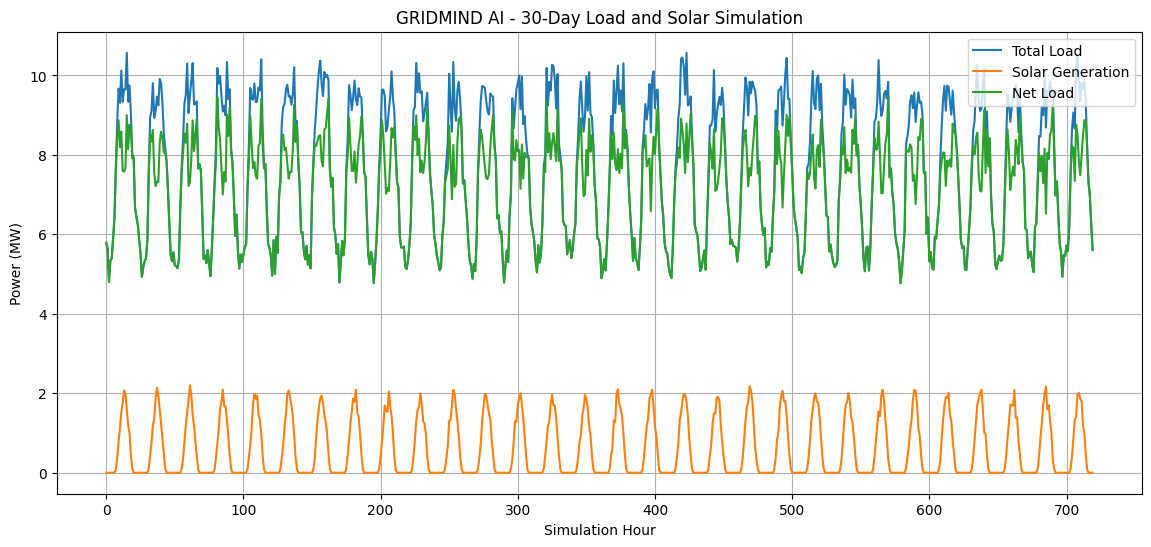

In [27]:
# ============================================================
# GRIDMIND AI - STEP 3C
# 30-DAY GRID BEHAVIOR
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["total_load_mw"],
    label="Total Load"
)

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["solar_generation_mw"],
    label="Solar Generation"
)

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["net_load_mw"],
    label="Net Load"
)

plt.xlabel("Simulation Hour")
plt.ylabel("Power (MW)")

plt.title(
    "GRIDMIND AI - 30-Day Load and Solar Simulation"
)

plt.grid(True)
plt.legend()

plt.show()

In [28]:
# ============================================================
# GRIDMIND AI - STEP 3B
# 30-DAY DATASET VALIDATION
# ============================================================

print("=" * 70)
print("GRIDMIND AI - 30 DAY DATASET VALIDATION")
print("=" * 70)

print("\nDataset shape:")
print(dataset_30d.shape)

print("\nNumber of rows:", len(dataset_30d))
print("Number of features:", len(dataset_30d.columns))

print("\nDays:")
print(
    dataset_30d["day"].min(),
    "to",
    dataset_30d["day"].max()
)

print("\nHours:")
print(
    dataset_30d["hour"].min(),
    "to",
    dataset_30d["hour"].max()
)

print("\nMissing values:")
print(
    dataset_30d.isnull().sum().sum()
)

print("\nOverload cases:")
print(
    dataset_30d["overload"].value_counts()
)

print("\nVoltage violation cases:")
print(
    dataset_30d["voltage_violation"].value_counts()
)

print("\nFirst 10 rows:")
display(dataset_30d.head(10))

GRIDMIND AI - 30 DAY DATASET VALIDATION

Dataset shape:
(720, 26)

Number of rows: 720
Number of features: 26

Days:
1 to 30

Hours:
0 to 23

Missing values:
0

Overload cases:
overload
0    720
Name: count, dtype: int64

Voltage violation cases:
voltage_violation
0    720
Name: count, dtype: int64

First 10 rows:


,day,hour,time_index,residential_load_mw,industrial_load_mw,commercial_load_mw,total_load_mw,solar_generation_mw,net_load_mw,minimum_bus_voltage_pu,...,bus_1_voltage_pu,bus_2_voltage_pu,bus_3_voltage_pu,bus_4_voltage_pu,bus_5_voltage_pu,line_1_loading_percent,line_2_loading_percent,line_3_loading_percent,overload,voltage_violation
0,1,0,0,1.116759,3.299517,1.370568,5.786844,0.000000,5.786844,0.976562,...,1.0,0.989509,0.983628,0.976562,0.984375,9.301374,26.785165,12.438520,0,0
1,1,1,1,1.037523,3.268196,1.338404,5.644123,0.000000,5.644123,0.976661,...,1.0,0.989541,0.983864,0.976661,0.984457,8.791440,26.571939,12.247796,0,0
2,1,2,2,0.866350,2.797590,1.137085,4.801025,0.000000,4.801025,0.977854,...,1.0,0.989737,0.984501,0.977854,0.984963,7.725110,23.427745,11.095010,0,0
3,1,3,3,0.946008,3.119815,1.268054,5.333878,0.000000,5.333878,0.977049,...,1.0,0.989614,0.984172,0.977049,0.984638,8.214635,25.569390,11.836500,0,0
4,1,4,4,0.959194,3.147354,1.288916,5.395464,0.000000,5.395464,0.976976,...,1.0,0.989600,0.984124,0.976976,0.984592,8.296850,25.754775,11.957504,0,0
5,1,5,5,1.085729,3.392902,1.409359,5.887990,0.000000,5.887990,0.976337,...,1.0,0.989483,0.983681,0.976337,0.984289,9.100961,27.421225,12.670484,0,0
6,1,6,6,1.304292,3.611886,1.504952,6.421130,0.000000,6.421130,0.975740,...,1.0,0.989353,0.982986,0.975740,0.984011,10.540468,28.926781,13.252059,0,0
7,1,7,7,1.596466,4.195839,1.903478,7.695784,0.091407,7.604376,0.974175,...,1.0,0.989040,0.981913,0.974175,0.983222,12.535047,33.010192,15.191567,0,0
8,1,8,8,1.731344,4.684813,2.383144,8.799300,0.361645,8.437656,0.972877,...,1.0,0.988797,0.981318,0.972877,0.982653,13.475688,36.490229,16.563680,0,0
9,1,9,9,1.565884,5.219613,2.881226,9.666722,0.796006,8.870717,0.971560,...,1.0,0.988642,0.981592,0.971560,0.982398,12.328934,40.341249,16.988832,0,0


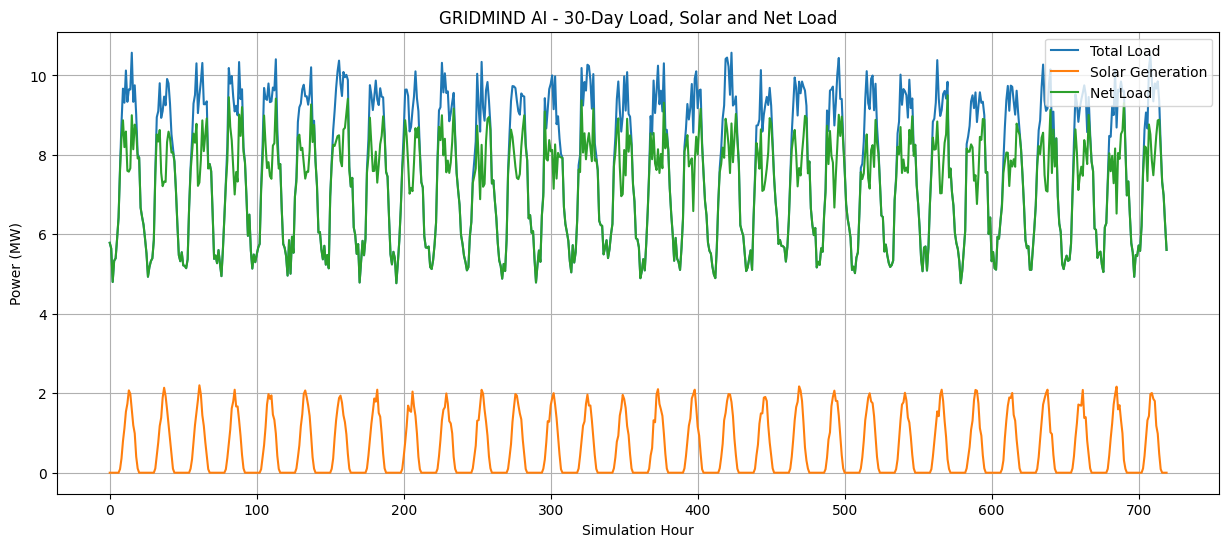

In [29]:
# ============================================================
# GRIDMIND AI - STEP 3C
# 30-DAY ELECTRICAL BEHAVIOR
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["total_load_mw"],
    label="Total Load"
)

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["solar_generation_mw"],
    label="Solar Generation"
)

plt.plot(
    dataset_30d["time_index"],
    dataset_30d["net_load_mw"],
    label="Net Load"
)

plt.xlabel("Simulation Hour")
plt.ylabel("Power (MW)")
plt.title(
    "GRIDMIND AI - 30-Day Load, Solar and Net Load"
)

plt.grid(True)
plt.legend()

plt.show()

In [30]:
# ============================================================
# GRIDMIND AI - STEP 4A
# NEXT-HOUR OVERLOAD TARGET
# ============================================================

import pandas as pd
import numpy as np

# Work on a copy
forecast_df = dataset_30d.copy()

# ------------------------------------------------------------
# Target:
# Will the maximum line loading in the NEXT hour
# exceed 100%?
# ------------------------------------------------------------

forecast_df["next_hour_max_line_loading"] = (
    forecast_df["maximum_line_loading_percent"].shift(-1)
)

forecast_df["next_hour_overload"] = (
    forecast_df["next_hour_max_line_loading"] >= 100
).astype(int)

# Remove the final row because it has no next hour
forecast_df = forecast_df.iloc[:-1].copy()

print("=" * 70)
print("GRIDMIND AI - NEXT-HOUR FORECAST TARGET")
print("=" * 70)

print("\nDataset shape:")
print(forecast_df.shape)

print("\nNext-hour overload distribution:")
print(
    forecast_df["next_hour_overload"].value_counts()
)

display(
    forecast_df[
        [
            "day",
            "hour",
            "maximum_line_loading_percent",
            "next_hour_max_line_loading",
            "next_hour_overload"
        ]
    ].head(20)
)

GRIDMIND AI - NEXT-HOUR FORECAST TARGET

Dataset shape:
(719, 28)

Next-hour overload distribution:
next_hour_overload
0    719
Name: count, dtype: int64


,day,hour,maximum_line_loading_percent,next_hour_max_line_loading,next_hour_overload
0,1,0,26.785165,26.571939,0
1,1,1,26.571939,23.427745,0
2,1,2,23.427745,25.569390,0
3,1,3,25.569390,25.754775,0
4,1,4,25.754775,27.421225,0
5,1,5,27.421225,28.926781,0
6,1,6,28.926781,33.010192,0
7,1,7,33.010192,36.490229,0
8,1,8,36.490229,40.341249,0
9,1,9,40.341249,39.130085,0


In [31]:
# ============================================================
# GRIDMIND AI - STEP 4B
# MACHINE LEARNING FEATURES
# ============================================================

feature_columns = [

    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",

    "total_load_mw",

    "solar_generation_mw",

    "net_load_mw",

    "minimum_bus_voltage_pu",
    "maximum_bus_voltage_pu",

    "maximum_line_loading_percent",

    "transformer_loading_percent",

    "active_power_loss_mw",
    "reactive_power_loss_mvar"
]

X = forecast_df[feature_columns]

y = forecast_df["next_hour_overload"]

print("=" * 70)
print("GRIDMIND AI - ML FEATURE MATRIX")
print("=" * 70)

print("\nFeatures:")
for feature in feature_columns:
    print("✓", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

GRIDMIND AI - ML FEATURE MATRIX

Features:
✓ residential_load_mw
✓ industrial_load_mw
✓ commercial_load_mw
✓ total_load_mw
✓ solar_generation_mw
✓ net_load_mw
✓ minimum_bus_voltage_pu
✓ maximum_bus_voltage_pu
✓ maximum_line_loading_percent
✓ transformer_loading_percent
✓ active_power_loss_mw
✓ reactive_power_loss_mvar

X shape: (719, 12)
y shape: (719,)

Target distribution:
next_hour_overload
0    719
Name: count, dtype: int64


In [32]:
# ============================================================
# GRIDMIND AI - STEP 4C
# TIME-AWARE TRAIN / TEST SPLIT
# ============================================================

train_data = forecast_df[
    forecast_df["day"] <= 21
].copy()

test_data = forecast_df[
    forecast_df["day"] > 21
].copy()

X_train = train_data[feature_columns]
y_train = train_data["next_hour_overload"]

X_test = test_data[feature_columns]
y_test = test_data["next_hour_overload"]

print("=" * 70)
print("GRIDMIND AI - TIME-AWARE DATA SPLIT")
print("=" * 70)

print("\nTraining:")
print("Days: 1-21")
print("Samples:", len(X_train))

print("\nTesting:")
print("Days: 22-30")
print("Samples:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

GRIDMIND AI - TIME-AWARE DATA SPLIT

Training:
Days: 1-21
Samples: 504

Testing:
Days: 22-30
Samples: 215

Training target:
next_hour_overload
0    504
Name: count, dtype: int64

Testing target:
next_hour_overload
0    215
Name: count, dtype: int64


In [33]:
# ============================================================
# GRIDMIND AI - STEP 4D
# RANDOM FOREST OVERLOAD FORECASTER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("RANDOM FOREST TRAINING COMPLETED")
print("=" * 70)

RANDOM FOREST TRAINING COMPLETED


In [34]:
# ============================================================
# GRIDMIND AI - STEP 4F
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "feature": feature_columns,

    "importance": model.feature_importances_

}).sort_values(
    "importance",
    ascending=False
)

print("=" * 70)
print("GRIDMIND AI - FEATURE IMPORTANCE")
print("=" * 70)

display(importance_df)

GRIDMIND AI - FEATURE IMPORTANCE


,feature,importance
0,residential_load_mw,0.0
1,industrial_load_mw,0.0
2,commercial_load_mw,0.0
3,total_load_mw,0.0
4,solar_generation_mw,0.0
5,net_load_mw,0.0
6,minimum_bus_voltage_pu,0.0
7,maximum_bus_voltage_pu,0.0
8,maximum_line_loading_percent,0.0
9,transformer_loading_percent,0.0


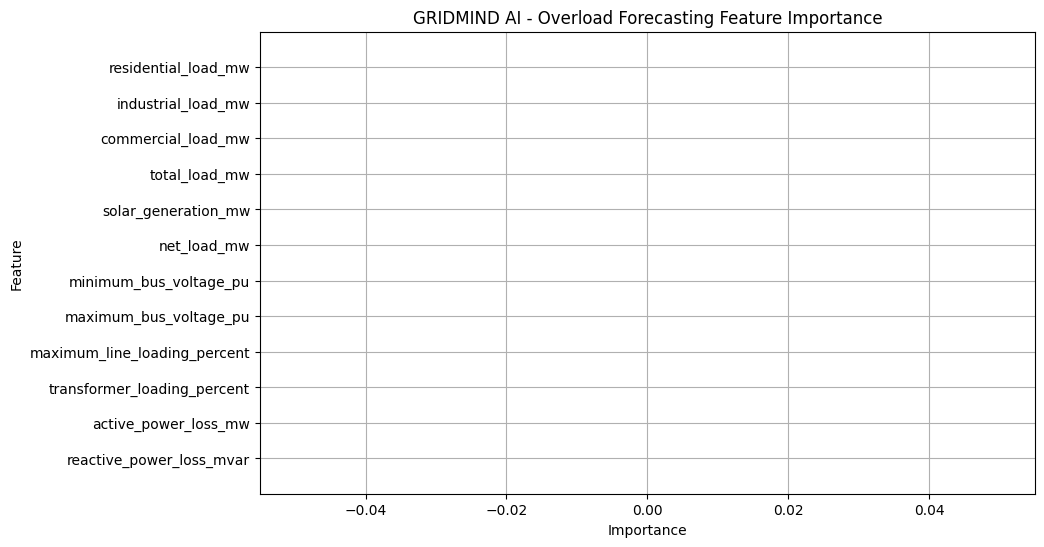

In [36]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "GRIDMIND AI - Overload Forecasting Feature Importance"
)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [37]:
# ============================================================
# GRIDMIND AI - STEP 4A
# CHECK OVERLOAD FORECASTING DATA
# ============================================================

print("=" * 70)
print("GRIDMIND AI - OVERLOAD FORECASTING DATA CHECK")
print("=" * 70)

# Copy the 30-day dataset
forecast_df = dataset_30d.copy()

# ------------------------------------------------------------
# NEXT-HOUR TARGET
# ------------------------------------------------------------

forecast_df["next_hour_loading"] = (
    forecast_df["maximum_line_loading_percent"].shift(-1)
)

forecast_df["next_hour_overload"] = (
    forecast_df["next_hour_loading"] >= 100
).astype(int)

# Remove final row because there is no next hour
forecast_df = forecast_df.iloc[:-1].copy()

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\nTotal forecasting samples:")
print(len(forecast_df))

print("\nNext-hour target distribution:")
print(
    forecast_df["next_hour_overload"].value_counts()
)

print("\n----------------------------------------")
print("NORMAL samples:")
print(
    (forecast_df["next_hour_overload"] == 0).sum()
)

print("\nOVERLOAD samples:")
print(
    (forecast_df["next_hour_overload"] == 1).sum()
)

print("\n----------------------------------------")

display(
    forecast_df[
        [
            "day",
            "hour",
            "maximum_line_loading_percent",
            "next_hour_loading",
            "next_hour_overload"
        ]
    ].head(20)
)

GRIDMIND AI - OVERLOAD FORECASTING DATA CHECK

Total forecasting samples:
719

Next-hour target distribution:
next_hour_overload
0    719
Name: count, dtype: int64

----------------------------------------
NORMAL samples:
719

OVERLOAD samples:
0

----------------------------------------


,day,hour,maximum_line_loading_percent,next_hour_loading,next_hour_overload
0,1,0,26.785165,26.571939,0
1,1,1,26.571939,23.427745,0
2,1,2,23.427745,25.569390,0
3,1,3,25.569390,25.754775,0
4,1,4,25.754775,27.421225,0
5,1,5,27.421225,28.926781,0
6,1,6,28.926781,33.010192,0
7,1,7,33.010192,36.490229,0
8,1,8,36.490229,40.341249,0
9,1,9,40.341249,39.130085,0


In [38]:
# ============================================================
# GRIDMIND AI - STEP 4A
# GENERATE STRESSED OPERATING SCENARIOS
# ============================================================

import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 70)
print("GRIDMIND AI - STRESSED GRID SCENARIO GENERATION")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

STRESS_SCENARIOS = 500

rng = np.random.default_rng(42)

stress_results = []

print("\nGenerating", STRESS_SCENARIOS, "operating scenarios...")


# ------------------------------------------------------------
# SCENARIO GENERATION
# ------------------------------------------------------------

for scenario in range(STRESS_SCENARIOS):

    # Random hour
    hour = rng.integers(0, 24)

    # --------------------------------------------------------
    # BASE LOAD PROFILES
    # --------------------------------------------------------

    residential_scale = residential_profile[hour]

    industrial_scale = industrial_profile[hour]

    commercial_scale = commercial_profile[hour]

    solar_scale = solar_profile[hour]


    # --------------------------------------------------------
    # LOAD STRESS FACTOR
    #
    # Most scenarios remain close to normal operation.
    # Some scenarios represent high-demand conditions.
    # --------------------------------------------------------

    load_factor = rng.uniform(
        0.90,
        2.00
    )

    # --------------------------------------------------------
    # INDIVIDUAL LOAD VARIATION
    # --------------------------------------------------------

    residential_factor = rng.uniform(
        0.90,
        1.20
    )

    industrial_factor = rng.uniform(
        0.90,
        1.50
    )

    commercial_factor = rng.uniform(
        0.90,
        1.30
    )

    # --------------------------------------------------------
    # SOLAR VARIABILITY
    # --------------------------------------------------------

    solar_factor = rng.uniform(
        0.60,
        1.10
    )


    # --------------------------------------------------------
    # ACTUAL POWER
    # --------------------------------------------------------

    residential_mw = (
        2.0
        * residential_scale
        * load_factor
        * residential_factor
    )

    industrial_mw = (
        5.0
        * industrial_scale
        * load_factor
        * industrial_factor
    )

    commercial_mw = (
        3.0
        * commercial_scale
        * load_factor
        * commercial_factor
    )

    solar_mw = (
        2.0
        * solar_scale
        * solar_factor
    )


    # --------------------------------------------------------
    # LIMIT VALUES
    # --------------------------------------------------------

    residential_mw = min(
        residential_mw,
        5.0
    )

    industrial_mw = min(
        industrial_mw,
        15.0
    )

    commercial_mw = min(
        commercial_mw,
        8.0
    )

    solar_mw = min(
        solar_mw,
        2.0
    )


    # --------------------------------------------------------
    # UPDATE NETWORK
    # --------------------------------------------------------

    ts_net.load.loc[
        ts_res_load,
        "p_mw"
    ] = residential_mw

    ts_net.load.loc[
        ts_ind_load,
        "p_mw"
    ] = industrial_mw

    ts_net.load.loc[
        ts_com_load,
        "p_mw"
    ] = commercial_mw

    ts_net.sgen.loc[
        ts_solar,
        "p_mw"
    ] = solar_mw


    # --------------------------------------------------------
    # POWER FLOW
    # --------------------------------------------------------

    try:

        pp.runpp(
            ts_net,
            max_iteration=100
        )

    except Exception:

        # Non-converged scenario
        continue


    # --------------------------------------------------------
    # MEASUREMENTS
    # --------------------------------------------------------

    bus_voltage = (
        ts_net.res_bus["vm_pu"].values
    )

    line_loading = (
        ts_net.res_line["loading_percent"].values
    )

    transformer_loading = (
        ts_net.res_trafo["loading_percent"].values
    )

    active_loss = (
        ts_net.res_line["pl_mw"].sum()
    )

    reactive_loss = (
        ts_net.res_line["ql_mvar"].sum()
    )


    # --------------------------------------------------------
    # CREATE SCENARIO RECORD
    # --------------------------------------------------------

    row = {

        "scenario": scenario,

        "hour": hour,

        "load_factor":
            load_factor,

        "residential_load_mw":
            residential_mw,

        "industrial_load_mw":
            industrial_mw,

        "commercial_load_mw":
            commercial_mw,

        "total_load_mw":
            residential_mw
            + industrial_mw
            + commercial_mw,

        "solar_generation_mw":
            solar_mw,

        "net_load_mw":
            residential_mw
            + industrial_mw
            + commercial_mw
            - solar_mw,

        "minimum_bus_voltage_pu":
            bus_voltage.min(),

        "maximum_bus_voltage_pu":
            bus_voltage.max(),

        "maximum_line_loading_percent":
            line_loading.max(),

        "transformer_loading_percent":
            transformer_loading.max(),

        "active_power_loss_mw":
            active_loss,

        "reactive_power_loss_mvar":
            reactive_loss,

        "overload":
            int(line_loading.max() >= 100),

        "voltage_violation":
            int(bus_voltage.min() < 0.95)
    }


    # --------------------------------------------------------
    # INDIVIDUAL BUS VOLTAGES
    # --------------------------------------------------------

    for i, voltage in enumerate(
        bus_voltage,
        start=1
    ):

        row[
            f"bus_{i}_voltage_pu"
        ] = voltage


    # --------------------------------------------------------
    # INDIVIDUAL LINE LOADINGS
    # --------------------------------------------------------

    for i, loading in enumerate(
        line_loading,
        start=1
    ):

        row[
            f"line_{i}_loading_percent"
        ] = loading


    stress_results.append(row)


# ============================================================
# CREATE DATASET
# ============================================================

stress_dataset = pd.DataFrame(
    stress_results
)


# ============================================================
# SAVE
# ============================================================

stress_file = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_STRESS_DATASET.csv"
)

stress_dataset.to_csv(
    stress_file,
    index=False
)


# ============================================================
# REPORT
# ============================================================

print("\n" + "=" * 70)
print("STRESS SCENARIO GENERATION COMPLETE")
print("=" * 70)

print("\nDataset shape:")
print(stress_dataset.shape)

print("\nOverload distribution:")
print(
    stress_dataset["overload"].value_counts()
)

print("\nVoltage violation distribution:")
print(
    stress_dataset["voltage_violation"].value_counts()
)

print("\nMaximum observed line loading:")
print(
    stress_dataset[
        "maximum_line_loading_percent"
    ].max()
)

print("\nMinimum observed bus voltage:")
print(
    stress_dataset[
        "minimum_bus_voltage_pu"
    ].min()
)

print("\nSaved:")
print(stress_file)

display(
    stress_dataset.head(10)
)

GRIDMIND AI - STRESSED GRID SCENARIO GENERATION

Generating 500 operating scenarios...

STRESS SCENARIO GENERATION COMPLETE

Dataset shape:
(500, 25)

Overload distribution:
overload
0    490
1     10
Name: count, dtype: int64

Voltage violation distribution:
voltage_violation
0    482
1     18
Name: count, dtype: int64

Maximum observed line loading:
113.58598901026886

Minimum observed bus voltage:
0.9419531604385231

Saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_STRESS_DATASET.csv


,scenario,hour,load_factor,residential_load_mw,industrial_load_mw,commercial_load_mw,total_load_mw,solar_generation_mw,net_load_mw,minimum_bus_voltage_pu,...,overload,voltage_violation,bus_1_voltage_pu,bus_2_voltage_pu,bus_3_voltage_pu,bus_4_voltage_pu,bus_5_voltage_pu,line_1_loading_percent,line_2_loading_percent,line_3_loading_percent
0,0,2,1.382766,1.536635,5.651510,1.633690,8.821836,0.000000,8.821836,0.970582,...,0,0,1.0,0.988606,0.981632,0.970582,0.983061,12.127878,43.477445,14.061752
1,1,18,1.737254,3.946412,7.806512,4.616195,16.369120,0.345576,16.023544,0.963191,...,0,0,1.0,0.986056,0.972666,0.963191,0.976360,29.617648,59.561637,32.420636
2,2,4,1.608252,1.770613,5.907193,2.055756,9.733562,0.000000,9.733562,0.969753,...,0,0,1.0,0.988342,0.980757,0.969753,0.982142,13.756759,45.356360,16.798302
3,3,22,0.970199,1.737948,4.219003,1.681024,7.637974,0.000000,7.637974,0.974113,...,0,0,1.0,0.989027,0.981532,0.974113,0.983412,13.518635,33.173953,14.354151
4,4,1,1.882433,2.133766,6.029184,2.638848,10.801798,0.000000,10.801798,0.969168,...,0,0,1.0,0.988032,0.979494,0.969168,0.980922,16.331240,46.264695,20.761909
5,5,23,1.069718,1.536532,4.754502,1.899890,8.190923,0.000000,8.190923,0.972784,...,0,0,1.0,0.988854,0.981882,0.972784,0.982899,12.124079,36.986426,15.764175
6,6,21,1.416511,2.493893,4.848485,2.409259,9.751637,0.000000,9.751637,0.972146,...,0,0,1.0,0.988427,0.978945,0.972146,0.981678,18.909831,37.676667,19.176951
7,7,8,1.636795,2.869216,10.538003,4.519926,17.927145,0.302473,17.624671,0.955833,...,0,0,1.0,0.985003,0.974490,0.955833,0.975380,21.708467,80.367673,32.070301
8,8,18,1.785241,3.628479,8.811566,5.151447,17.591492,0.294746,17.296746,0.960275,...,0,0,1.0,0.985439,0.972898,0.960275,0.974802,27.281270,67.175333,36.710529
9,9,19,1.119899,2.182426,6.300366,2.742044,11.224837,0.095258,11.129579,0.968443,...,0,0,1.0,0.987906,0.979240,0.968443,0.980783,16.680997,48.262897,20.819484


In [39]:
# ============================================================
# GRIDMIND AI - STEP 4B
# CHECK STRESSED DATASET
# ============================================================

print("=" * 70)
print("GRIDMIND AI - STRESS DATASET ANALYSIS")
print("=" * 70)

print("\nTotal scenarios:")
print(len(stress_dataset))

print("\nNormal scenarios:")
print(
    (stress_dataset["overload"] == 0).sum()
)

print("\nOverload scenarios:")
print(
    (stress_dataset["overload"] == 1).sum()
)

print("\nOverload percentage:")
print(
    stress_dataset["overload"].mean() * 100,
    "%"
)

print("\nMaximum line loading:")
print(
    stress_dataset[
        "maximum_line_loading_percent"
    ].max(),
    "%"
)

print("\nMinimum bus voltage:")
print(
    stress_dataset[
        "minimum_bus_voltage_pu"
    ].min(),
    "pu"
)

GRIDMIND AI - STRESS DATASET ANALYSIS

Total scenarios:
500

Normal scenarios:
490

Overload scenarios:
10

Overload percentage:
2.0 %

Maximum line loading:
113.58598901026886 %

Minimum bus voltage:
0.9419531604385231 pu


In [40]:
# ============================================================
# GRIDMIND AI - STEP 5A
# PREPARE OVERLOAD FORECASTING DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Use the stress dataset
# ------------------------------------------------------------

forecast_ml = stress_dataset.copy()

print("=" * 70)
print("GRIDMIND AI - OVERLOAD FORECASTING DATA")
print("=" * 70)

print("\nTotal samples:", len(forecast_ml))

print("\nOverload distribution:")
print(
    forecast_ml["overload"].value_counts()
)

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

feature_columns = [
    "hour",
    "load_factor",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "net_load_mw",
    "minimum_bus_voltage_pu",
    "maximum_bus_voltage_pu",
    "transformer_loading_percent",
    "active_power_loss_mw",
    "reactive_power_loss_mvar"
]

# Add individual line-loading features
line_features = [
    col for col in forecast_ml.columns
    if col.startswith("line_")
    and col.endswith("_loading_percent")
]

feature_columns.extend(line_features)

X = forecast_ml[feature_columns]

y = forecast_ml["overload"]

print("\nNumber of ML features:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for feature in feature_columns:
    print("✓", feature)

GRIDMIND AI - OVERLOAD FORECASTING DATA

Total samples: 500

Overload distribution:
overload
0    490
1     10
Name: count, dtype: int64

Number of ML features: 16
X shape: (500, 16)
y shape: (500,)

Features:
✓ hour
✓ load_factor
✓ residential_load_mw
✓ industrial_load_mw
✓ commercial_load_mw
✓ total_load_mw
✓ solar_generation_mw
✓ net_load_mw
✓ minimum_bus_voltage_pu
✓ maximum_bus_voltage_pu
✓ transformer_loading_percent
✓ active_power_loss_mw
✓ reactive_power_loss_mvar
✓ line_1_loading_percent
✓ line_2_loading_percent
✓ line_3_loading_percent


In [41]:
# ============================================================
# GRIDMIND AI - STEP 5B
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("GRIDMIND AI - TRAIN / TEST SPLIT")
print("=" * 70)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

GRIDMIND AI - TRAIN / TEST SPLIT

Training samples: 400
Testing samples : 100

Training classes:
overload
0    392
1      8
Name: count, dtype: int64

Testing classes:
overload
0    98
1     2
Name: count, dtype: int64


In [42]:
# ============================================================
# GRIDMIND AI - STEP 5C
# RANDOM FOREST OVERLOAD FORECASTER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("RANDOM FOREST TRAINING COMPLETE")
print("=" * 70)

RANDOM FOREST TRAINING COMPLETE


In [43]:
# ============================================================
# GRIDMIND AI - STEP 5D
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 70)
print("GRIDMIND AI - OVERLOAD FORECASTING RESULTS")
print("=" * 70)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

GRIDMIND AI - OVERLOAD FORECASTING RESULTS

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        98
    OVERLOAD       1.00      1.00      1.00         2

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
[[98  0]
 [ 0  2]]


In [44]:
# ============================================================
# GRIDMIND AI - STEP 5D
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 70)
print("GRIDMIND AI - OVERLOAD FORECASTING RESULTS")
print("=" * 70)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

GRIDMIND AI - OVERLOAD FORECASTING RESULTS

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        98
    OVERLOAD       1.00      1.00      1.00         2

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
[[98  0]
 [ 0  2]]


In [45]:
# ============================================================
# GRIDMIND AI - STEP 5E
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "feature": feature_columns,

    "importance": rf_model.feature_importances_

}).sort_values(
    "importance",
    ascending=False
)

print("=" * 70)
print("GRIDMIND AI - FEATURE IMPORTANCE")
print("=" * 70)

display(
    importance_df
)

GRIDMIND AI - FEATURE IMPORTANCE


,feature,importance
14,line_2_loading_percent,1.530008e-01
5,total_load_mw,1.466667e-01
10,transformer_loading_percent,1.433333e-01
12,reactive_power_loss_mvar,1.400000e-01
8,minimum_bus_voltage_pu,1.367047e-01
3,industrial_load_mw,9.712386e-02
11,active_power_loss_mw,9.671040e-02
7,net_load_mw,7.324213e-02
1,load_factor,5.333266e-03
15,line_3_loading_percent,3.289602e-03


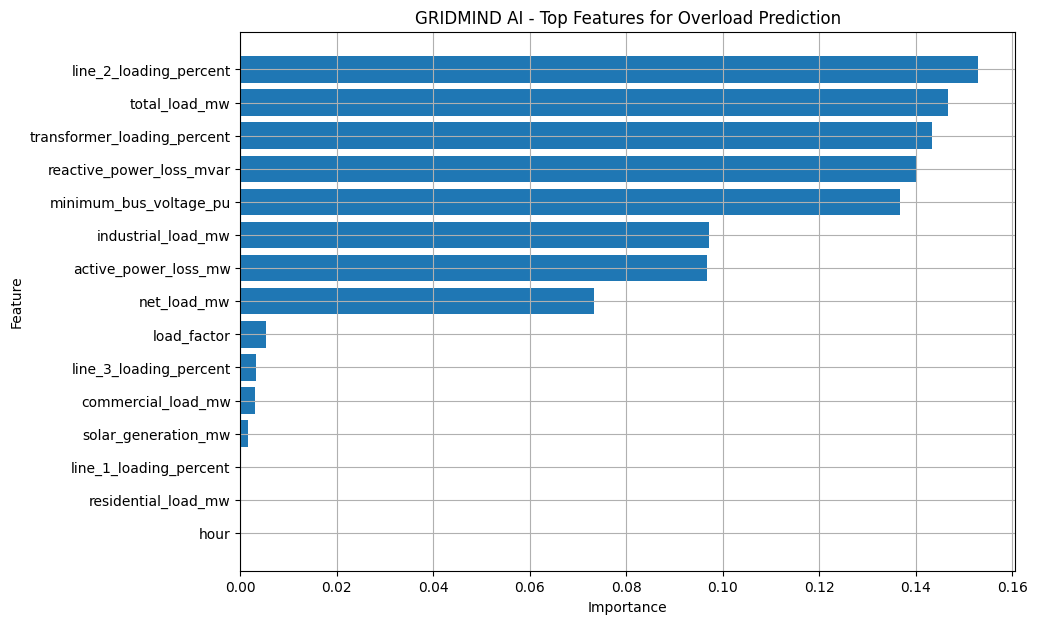

In [46]:
# ============================================================
# GRIDMIND AI - FEATURE IMPORTANCE PLOT
# ============================================================

import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "GRIDMIND AI - Top Features for Overload Prediction"
)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [47]:
# ============================================================
# GRIDMIND AI - STEP 5A
# PREPARE OVERLOAD ML DATA
# ============================================================

import pandas as pd
import numpy as np

forecast_ml = stress_dataset.copy()

feature_columns = [
    "hour",
    "load_factor",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "net_load_mw",
    "minimum_bus_voltage_pu",
    "maximum_bus_voltage_pu",
    "transformer_loading_percent",
    "active_power_loss_mw",
    "reactive_power_loss_mvar"
]

X = forecast_ml[feature_columns]
y = forecast_ml["overload"]

print("Samples:", len(X))
print("Features:", len(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

Samples: 500
Features: 13

Target distribution:
overload
0    490
1     10
Name: count, dtype: int64


In [48]:
# ============================================================
# GRIDMIND AI - STEP 5B
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training samples: 400
Testing samples : 100

Training target:
overload
0    392
1      8
Name: count, dtype: int64

Testing target:
overload
0    98
1     2
Name: count, dtype: int64


In [49]:
# ============================================================
# GRIDMIND AI - STEP 5C
# RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("✅ GRIDMIND AI Random Forest trained successfully!")

✅ GRIDMIND AI Random Forest trained successfully!


In [50]:
# ============================================================
# GRIDMIND AI - STEP 5D
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)

print("=" * 70)
print("GRIDMIND AI - OVERLOAD PREDICTION RESULTS")
print("=" * 70)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["NORMAL", "OVERLOAD"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(y_test, y_pred)
)

GRIDMIND AI - OVERLOAD PREDICTION RESULTS
Accuracy : 0.99
Precision: 1.0
Recall   : 0.5
F1 Score : 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      1.00      0.99        98
    OVERLOAD       1.00      0.50      0.67         2

    accuracy                           0.99       100
   macro avg       0.99      0.75      0.83       100
weighted avg       0.99      0.99      0.99       100


Confusion Matrix:
[[98  0]
 [ 1  1]]


In [51]:
# ============================================================
# GRIDMIND AI - STEP 5E
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
11,active_power_loss_mw,0.151598
8,minimum_bus_voltage_pu,0.147200
5,total_load_mw,0.143026
3,industrial_load_mw,0.142253
12,reactive_power_loss_mvar,0.127011
10,transformer_loading_percent,0.117445
7,net_load_mw,0.092872
1,load_factor,0.032147
4,commercial_load_mw,0.022847
6,solar_generation_mw,0.015782


In [52]:
# ============================================================
# GRIDMIND AI - STEP 6A
# TRUE NEXT-HOUR OVERLOAD FORECASTING
# ============================================================

forecast_df = stress_dataset.copy()

# Sort by scenario/time
forecast_df = forecast_df.sort_values(
    ["scenario", "hour"]
).reset_index(drop=True)

# ------------------------------------------------------------
# IMPORTANT:
# Stress scenarios are independent operating points.
# Therefore, for this first forecasting demonstration,
# we will create a supervised target from a sorted operating
# sequence within each scenario group only if sequential data
# exists.
#
# Since the stress scenarios are independently sampled,
# we will instead use the 30-day time-series dataset for
# genuine chronological forecasting.
# ------------------------------------------------------------

time_df = dataset_30d.copy()

time_df = time_df.sort_values(
    ["day", "hour"]
).reset_index(drop=True)

# Next-hour maximum line loading
time_df["next_hour_line_loading"] = (
    time_df["maximum_line_loading_percent"].shift(-1)
)

# Next-hour overload target
time_df["next_hour_overload"] = (
    time_df["next_hour_line_loading"] >= 100
).astype(int)

# Remove final sample
time_df = time_df.iloc[:-1].copy()

print("=" * 70)
print("GRIDMIND AI - TRUE TIME-SERIES FORECAST DATA")
print("=" * 70)

print("Samples:", len(time_df))

print("\nNext-hour overload distribution:")
print(
    time_df["next_hour_overload"].value_counts()
)

GRIDMIND AI - TRUE TIME-SERIES FORECAST DATA
Samples: 719

Next-hour overload distribution:
next_hour_overload
0    719
Name: count, dtype: int64


In [53]:
# ============================================================
# GRIDMIND AI - STEP 6C
# 30-DAY STRESSED CHRONOLOGICAL SIMULATION
# ============================================================

import numpy as np
import pandas as pd
import pandapower as pp

DAYS = 30

rng = np.random.default_rng(2026)

forecast_results = []

print("=" * 70)
print("GRIDMIND AI - CHRONOLOGICAL STRESSED SIMULATION")
print("=" * 70)

for day in range(1, DAYS + 1):

    # --------------------------------------------------------
    # DAILY CONDITIONS
    # --------------------------------------------------------

    daily_load_factor = rng.uniform(
        0.95,
        1.20
    )

    # Some days represent high-demand conditions
    if rng.random() < 0.20:

        daily_load_factor *= rng.uniform(
            1.25,
            1.60
        )

    # Solar weather condition
    solar_weather_factor = rng.uniform(
        0.60,
        1.10
    )

    for hour in range(24):

        # ----------------------------------------------------
        # BASE PROFILES
        # ----------------------------------------------------

        residential_mw = (
            2.0
            * residential_profile[hour]
            * daily_load_factor
        )

        industrial_mw = (
            5.0
            * industrial_profile[hour]
            * daily_load_factor
        )

        commercial_mw = (
            3.0
            * commercial_profile[hour]
            * daily_load_factor
        )

        solar_mw = (
            2.0
            * solar_profile[hour]
            * solar_weather_factor
        )

        # ----------------------------------------------------
        # RANDOM HOURLY VARIATION
        # ----------------------------------------------------

        hourly_factor = rng.uniform(
            0.95,
            1.08
        )

        residential_mw *= hourly_factor
        industrial_mw *= hourly_factor
        commercial_mw *= hourly_factor

        # ----------------------------------------------------
        # UPDATE NETWORK
        # ----------------------------------------------------

        ts_net.load.loc[
            ts_res_load,
            "p_mw"
        ] = residential_mw

        ts_net.load.loc[
            ts_ind_load,
            "p_mw"
        ] = industrial_mw

        ts_net.load.loc[
            ts_com_load,
            "p_mw"
        ] = commercial_mw

        ts_net.sgen.loc[
            ts_solar,
            "p_mw"
        ] = solar_mw

        # ----------------------------------------------------
        # POWER FLOW
        # ----------------------------------------------------

        try:

            pp.runpp(
                ts_net,
                max_iteration=100
            )

        except Exception:

            continue

        # ----------------------------------------------------
        # MEASUREMENTS
        # ----------------------------------------------------

        bus_v = (
            ts_net.res_bus["vm_pu"].values
        )

        line_l = (
            ts_net.res_line["loading_percent"].values
        )

        trafo_l = (
            ts_net.res_trafo["loading_percent"].values
        )

        loss_p = (
            ts_net.res_line["pl_mw"].sum()
        )

        loss_q = (
            ts_net.res_line["ql_mvar"].sum()
        )

        row = {

            "day": day,

            "hour": hour,

            "time_index":
                (day - 1) * 24 + hour,

            "residential_load_mw":
                residential_mw,

            "industrial_load_mw":
                industrial_mw,

            "commercial_load_mw":
                commercial_mw,

            "total_load_mw":
                residential_mw
                + industrial_mw
                + commercial_mw,

            "solar_generation_mw":
                solar_mw,

            "net_load_mw":
                residential_mw
                + industrial_mw
                + commercial_mw
                - solar_mw,

            "minimum_bus_voltage_pu":
                bus_v.min(),

            "maximum_bus_voltage_pu":
                bus_v.max(),

            "maximum_line_loading_percent":
                line_l.max(),

            "transformer_loading_percent":
                trafo_l.max(),

            "active_power_loss_mw":
                loss_p,

            "reactive_power_loss_mvar":
                loss_q,

            "current_overload":
                int(line_l.max() >= 100)
        }

        forecast_results.append(row)


# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

chronological_df = pd.DataFrame(
    forecast_results
)

chronological_df = chronological_df.sort_values(
    "time_index"
).reset_index(drop=True)


# ------------------------------------------------------------
# NEXT-HOUR TARGET
# ------------------------------------------------------------

chronological_df[
    "next_hour_loading"
] = chronological_df[
    "maximum_line_loading_percent"
].shift(-1)

chronological_df[
    "next_hour_overload"
] = (
    chronological_df[
        "next_hour_loading"
    ] >= 100
).astype(int)


# Remove final sample
chronological_df = chronological_df.iloc[:-1]


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

chronological_file = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_CHRONOLOGICAL_FORECAST_DATASET.csv"
)

chronological_df.to_csv(
    chronological_file,
    index=False
)


print("\n" + "=" * 70)
print("CHRONOLOGICAL SIMULATION COMPLETE")
print("=" * 70)

print("\nSamples:", len(chronological_df))

print("\nCurrent overload:")
print(
    chronological_df[
        "current_overload"
    ].value_counts()
)

print("\nNext-hour overload:")
print(
    chronological_df[
        "next_hour_overload"
    ].value_counts()
)

print("\nMaximum line loading:")
print(
    chronological_df[
        "maximum_line_loading_percent"
    ].max()
)

print("\nSaved:")
print(chronological_file)

GRIDMIND AI - CHRONOLOGICAL STRESSED SIMULATION

CHRONOLOGICAL SIMULATION COMPLETE

Samples: 719

Current overload:
current_overload
0    719
Name: count, dtype: int64

Next-hour overload:
next_hour_overload
0    719
Name: count, dtype: int64

Maximum line loading:
66.0298430009152

Saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_CHRONOLOGICAL_FORECAST_DATASET.csv


In [54]:
# ============================================================
# GRIDMIND AI - STEP 7A
# NEXT-HOUR FORECASTING FEATURES
# ============================================================

forecast_features = [
    "hour",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "net_load_mw",
    "minimum_bus_voltage_pu",
    "maximum_bus_voltage_pu",
    "maximum_line_loading_percent",
    "transformer_loading_percent",
    "active_power_loss_mw",
    "reactive_power_loss_mvar"
]

X = chronological_df[forecast_features]

y = chronological_df["next_hour_overload"]

print("=" * 70)
print("GRIDMIND AI - FORECASTING DATA")
print("=" * 70)

print("Samples :", len(X))
print("Features:", len(forecast_features))

print("\nTarget distribution:")
print(y.value_counts())

GRIDMIND AI - FORECASTING DATA
Samples : 719
Features: 13

Target distribution:
next_hour_overload
0    719
Name: count, dtype: int64


In [55]:
# ============================================================
# GRIDMIND AI - STEP 7B
# TIME-AWARE TRAIN / TEST SPLIT
# ============================================================

train_df = chronological_df[
    chronological_df["day"] <= 21
].copy()

test_df = chronological_df[
    chronological_df["day"] > 21
].copy()

X_train = train_df[forecast_features]
y_train = train_df["next_hour_overload"]

X_test = test_df[forecast_features]
y_test = test_df["next_hour_overload"]

print("=" * 70)
print("GRIDMIND AI - TIME-AWARE SPLIT")
print("=" * 70)

print("\nTraining:")
print("Days 1-21")
print("Samples:", len(X_train))

print("\nTesting:")
print("Days 22-30")
print("Samples:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

GRIDMIND AI - TIME-AWARE SPLIT

Training:
Days 1-21
Samples: 504

Testing:
Days 22-30
Samples: 215

Training target:
next_hour_overload
0    504
Name: count, dtype: int64

Testing target:
next_hour_overload
0    215
Name: count, dtype: int64


In [56]:
# ============================================================
# GRIDMIND AI - STEP 7C
# NEXT-HOUR RANDOM FOREST FORECASTER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

forecast_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("GRIDMIND AI - FORECAST MODEL TRAINED")
print("=" * 70)

GRIDMIND AI - FORECAST MODEL TRAINED


In [57]:
# ============================================================
# GRIDMIND AI - STEP 7D
# NEXT-HOUR FORECAST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = forecast_model.predict(X_test)

print("=" * 70)
print("GRIDMIND AI - NEXT-HOUR OVERLOAD FORECAST")
print("=" * 70)

print(
    f"\nAccuracy  : {accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}"
)

print(
    f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

GRIDMIND AI - NEXT-HOUR OVERLOAD FORECAST

Accuracy  : 1.0000
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

Classification Report:



ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

GRIDMIND AI - MODEL EVALUATION

Test-set class distribution:
NORMAL (0): 215

Number of classes in test set: 1

Prediction distribution:
NORMAL (0): 215

METRICS
Accuracy  : 1.0000
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

Classification Report:

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       215
    OVERLOAD       0.00      0.00      0.00         0

    accuracy                           1.00       215
   macro avg       0.50      0.50      0.50       215
weighted avg       1.00      1.00      1.00       215

Confusion Matrix:
[[215   0]
 [  0   0]]


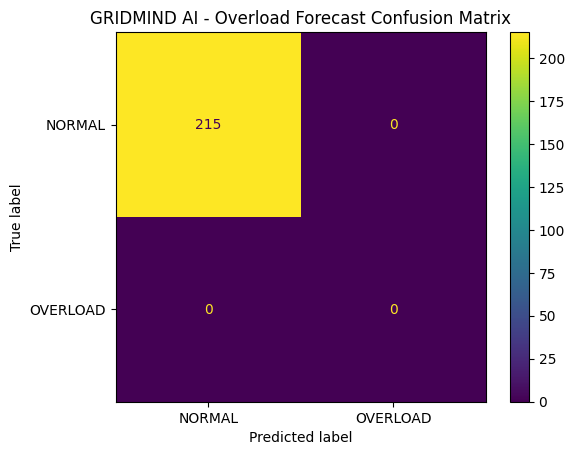


⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
WARNING
The test set contains only ONE class.
Therefore, overload forecasting performance
cannot be properly evaluated yet.
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️


In [58]:
# ============================================================
# STEP 7D - ROBUST MODEL EVALUATION
# GRIDMIND AI
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("GRIDMIND AI - MODEL EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check actual classes in TEST SET
# ------------------------------------------------------------

print("\nTest-set class distribution:")

unique_classes, class_counts = np.unique(
    y_test,
    return_counts=True
)

for cls, count in zip(unique_classes, class_counts):
    label = "NORMAL" if cls == 0 else "OVERLOAD"
    print(f"{label} ({cls}): {count}")

print("\nNumber of classes in test set:", len(unique_classes))


# ------------------------------------------------------------
# 2. Basic predictions
# ------------------------------------------------------------

y_pred = forecast_model.predict(X_test)

print("\nPrediction distribution:")

pred_classes, pred_counts = np.unique(
    y_pred,
    return_counts=True
)

for cls, count in zip(pred_classes, pred_counts):
    label = "NORMAL" if cls == 0 else "OVERLOAD"
    print(f"{label} ({cls}): {count}")


# ------------------------------------------------------------
# 3. Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n" + "=" * 60)
print("METRICS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ------------------------------------------------------------
# 4. Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["NORMAL", "OVERLOAD"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)


# ------------------------------------------------------------
# 6. Plot confusion matrix
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "OVERLOAD"]
)

disp.plot()
plt.title("GRIDMIND AI - Overload Forecast Confusion Matrix")
plt.show()


# ------------------------------------------------------------
# 7. Important diagnosis
# ------------------------------------------------------------

if len(unique_classes) < 2:

    print("\n" + "⚠️" * 20)
    print("WARNING")
    print("The test set contains only ONE class.")
    print("Therefore, overload forecasting performance")
    print("cannot be properly evaluated yet.")
    print("⚠️" * 20)

else:

    print("\n✅ Test set contains both NORMAL and OVERLOAD classes.")
    print("The model can be properly evaluated.")

In [59]:
# ============================================================
# STEP 7E - NEXT-HOUR OVERLOAD PROBABILITY
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

print("=" * 60)
print("GRIDMIND AI - NEXT-HOUR OVERLOAD FORECAST")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check that the model exists
# ------------------------------------------------------------

if "forecast_model" not in globals():
    raise RuntimeError(
        "forecast_model was not found. Run the Step 7C model-training cell first."
    )

# ------------------------------------------------------------
# 2. Generate predictions
# ------------------------------------------------------------

test_predictions = forecast_model.predict(X_test)

# ------------------------------------------------------------
# 3. Generate probability of OVERLOAD
# ------------------------------------------------------------

if hasattr(forecast_model, "predict_proba"):

    probability_matrix = forecast_model.predict_proba(X_test)

    model_classes = forecast_model.classes_

    # Find probability corresponding to class 1 = OVERLOAD
    if 1 in model_classes:

        overload_index = list(model_classes).index(1)

        overload_probability = probability_matrix[:, overload_index]

    else:

        # Model has never learned an overload class
        overload_probability = np.zeros(len(X_test))

else:

    # Fallback if probability prediction is unavailable
    overload_probability = test_predictions.astype(float)


# ------------------------------------------------------------
# 4. Create forecast result table
# ------------------------------------------------------------

forecast_results = test_df.copy()

forecast_results["Actual_Next_Hour_Overload"] = y_test.values

forecast_results["Predicted_Next_Hour_Overload"] = test_predictions

forecast_results["Overload_Probability"] = overload_probability


# ------------------------------------------------------------
# 5. Convert probability into percentage
# ------------------------------------------------------------

forecast_results["Overload_Probability_Percent"] = (
    forecast_results["Overload_Probability"] * 100
)


# ------------------------------------------------------------
# 6. Display most important columns
# ------------------------------------------------------------

display_columns = [
    "Actual_Next_Hour_Overload",
    "Predicted_Next_Hour_Overload",
    "Overload_Probability_Percent"
]

# Add loading column if available
possible_loading_columns = [
    "max_line_loading_percent",
    "line_loading_percent",
    "max_loading_percent",
    "max_line_loading"
]

for col in possible_loading_columns:

    if col in forecast_results.columns:
        display_columns.insert(0, col)
        break


print("\nFirst 20 forecasting results:")
display(
    forecast_results[display_columns].head(20)
)


# ------------------------------------------------------------
# 7. Highest-risk operating conditions
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HIGHEST OVERLOAD-RISK CONDITIONS")
print("=" * 60)

high_risk = forecast_results.sort_values(
    "Overload_Probability",
    ascending=False
).head(10)

display(
    high_risk[display_columns]
)


# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FORECAST SUMMARY")
print("=" * 60)

print(
    f"Total forecast samples : {len(forecast_results)}"
)

print(
    f"Maximum overload probability : "
    f"{forecast_results['Overload_Probability_Percent'].max():.2f}%"
)

print(
    f"Average overload probability : "
    f"{forecast_results['Overload_Probability_Percent'].mean():.2f}%"
)


# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

forecast_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_NEXT_HOUR_FORECAST_RESULTS.csv"
)

forecast_results.to_csv(
    forecast_path,
    index=False
)

print("\n✅ Forecast results saved:")
print(forecast_path)

GRIDMIND AI - NEXT-HOUR OVERLOAD FORECAST

First 20 forecasting results:


,Actual_Next_Hour_Overload,Predicted_Next_Hour_Overload,Overload_Probability_Percent
504,0,0,0.0
505,0,0,0.0
506,0,0,0.0
507,0,0,0.0
508,0,0,0.0
509,0,0,0.0
510,0,0,0.0
511,0,0,0.0
512,0,0,0.0
513,0,0,0.0



HIGHEST OVERLOAD-RISK CONDITIONS


,Actual_Next_Hour_Overload,Predicted_Next_Hour_Overload,Overload_Probability_Percent
504,0,0,0.0
505,0,0,0.0
506,0,0,0.0
507,0,0,0.0
508,0,0,0.0
509,0,0,0.0
510,0,0,0.0
511,0,0,0.0
512,0,0,0.0
513,0,0,0.0



FORECAST SUMMARY
Total forecast samples : 215
Maximum overload probability : 0.00%
Average overload probability : 0.00%

✅ Forecast results saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_NEXT_HOUR_FORECAST_RESULTS.csv


GRIDMIND AI - FORECAST VISUALIZATION


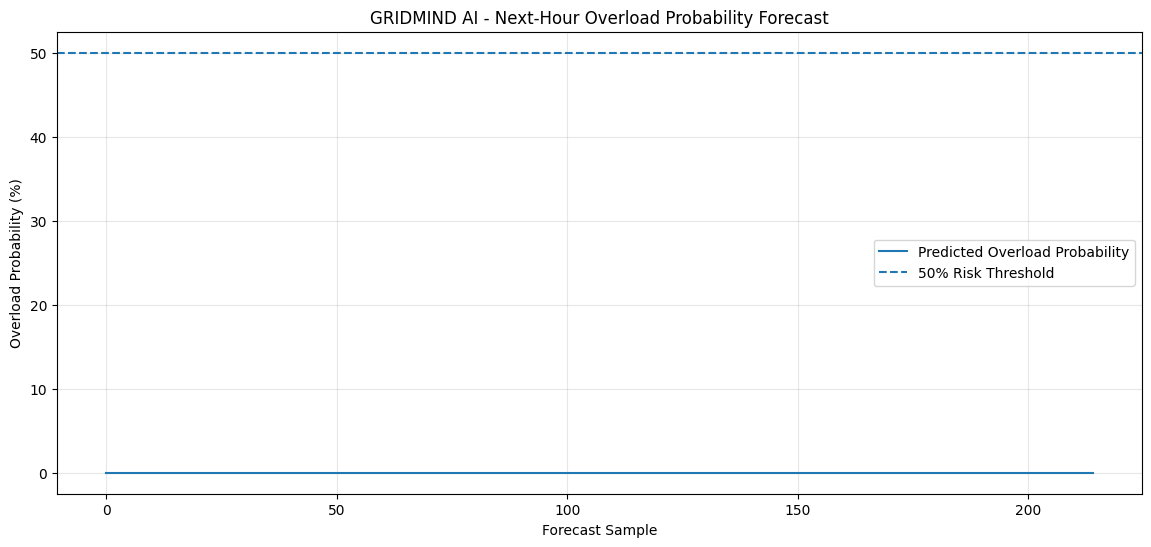

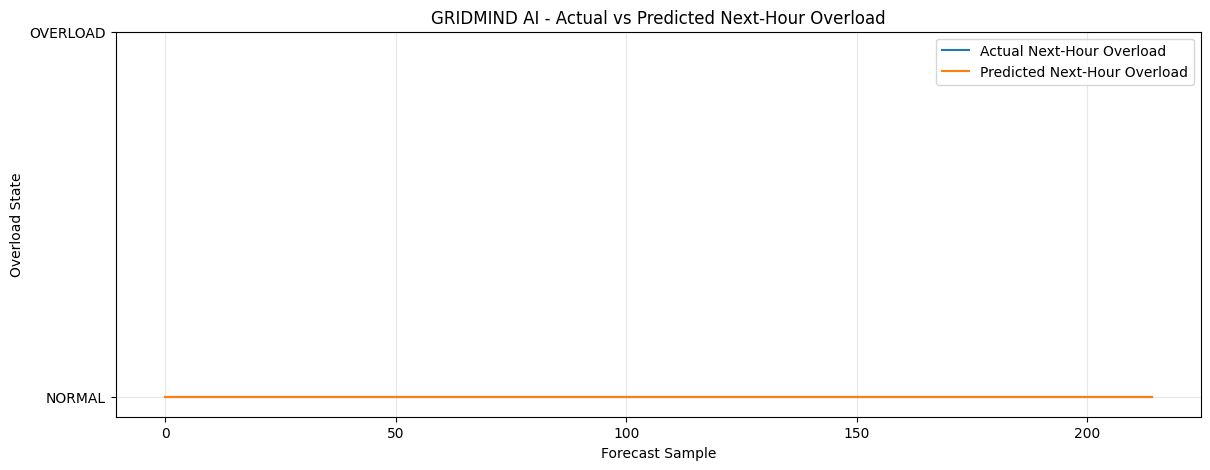

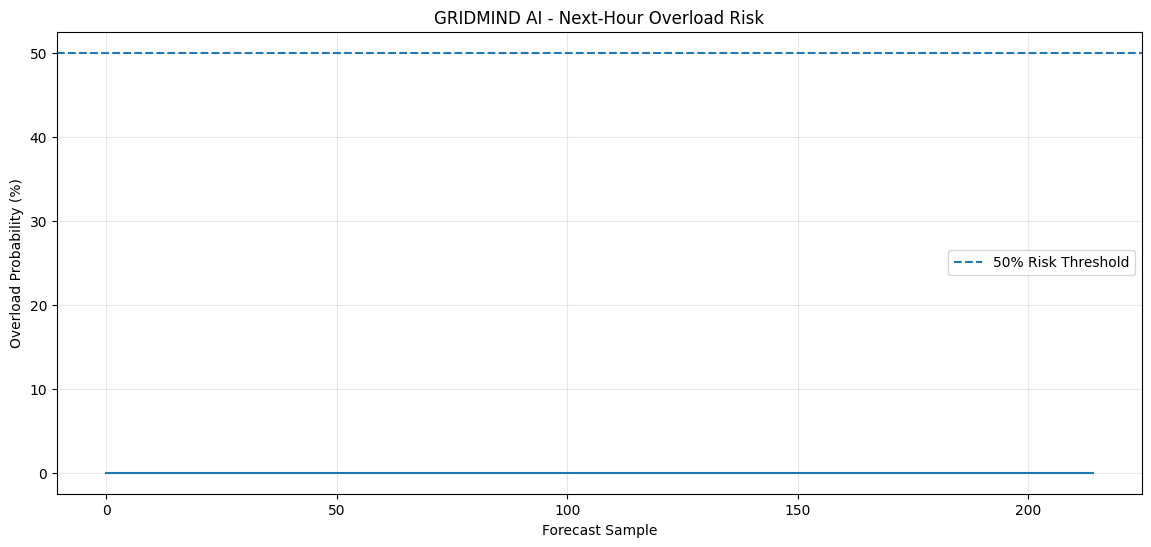


✅ Step 7F completed.
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_NEXT_HOUR_OVERLOAD_FORECAST.png


In [60]:
# ============================================================
# STEP 7F - NEXT-HOUR OVERLOAD FORECAST VISUALIZATION
# GRIDMIND AI
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("GRIDMIND AI - FORECAST VISUALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create forecast index
# ------------------------------------------------------------

forecast_index = np.arange(len(forecast_results))

# ------------------------------------------------------------
# 2. Plot overload probability
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_index,
    forecast_results["Overload_Probability_Percent"],
    label="Predicted Overload Probability"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% Risk Threshold"
)

plt.xlabel("Forecast Sample")
plt.ylabel("Overload Probability (%)")
plt.title(
    "GRIDMIND AI - Next-Hour Overload Probability Forecast"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 3. Actual vs predicted overload
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    forecast_index,
    forecast_results["Actual_Next_Hour_Overload"],
    label="Actual Next-Hour Overload",
    drawstyle="steps-post"
)

plt.plot(
    forecast_index,
    forecast_results["Predicted_Next_Hour_Overload"],
    label="Predicted Next-Hour Overload",
    drawstyle="steps-post"
)

plt.xlabel("Forecast Sample")
plt.ylabel("Overload State")
plt.title(
    "GRIDMIND AI - Actual vs Predicted Next-Hour Overload"
)

plt.yticks(
    [0, 1],
    ["NORMAL", "OVERLOAD"]
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 4. Save forecast plots
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_index,
    forecast_results["Overload_Probability_Percent"]
)

plt.axhline(
    50,
    linestyle="--",
    label="50% Risk Threshold"
)

plt.xlabel("Forecast Sample")
plt.ylabel("Overload Probability (%)")
plt.title(
    "GRIDMIND AI - Next-Hour Overload Risk"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    output_dir + "/GRIDMIND_NEXT_HOUR_OVERLOAD_FORECAST.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Step 7F completed.")
print(
    "Saved:",
    output_dir + "/GRIDMIND_NEXT_HOUR_OVERLOAD_FORECAST.png"
)

In [61]:
# ============================================================
# STEP 8A - PREDICTIVE SELF-HEALING RISK ENGINE
# GRIDMIND AI
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("GRIDMIND AI - PREDICTIVE SELF-HEALING RISK ENGINE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check required forecast data
# ------------------------------------------------------------

if "forecast_results" not in globals():
    raise RuntimeError(
        "forecast_results not found. Run Step 7E first."
    )

risk_df = forecast_results.copy()


# ------------------------------------------------------------
# 2. Convert probability to percentage
# ------------------------------------------------------------

risk_df["Risk_Percent"] = (
    risk_df["Overload_Probability"] * 100
)


# ------------------------------------------------------------
# 3. Risk classification
# ------------------------------------------------------------

def classify_risk(probability):

    probability = probability * 100

    if probability < 25:
        return "NORMAL"

    elif probability < 50:
        return "WARNING"

    elif probability < 75:
        return "PREVENTIVE_ACTION"

    else:
        return "CRITICAL"


risk_df["Risk_Level"] = (
    risk_df["Overload_Probability"]
    .apply(classify_risk)
)


# ------------------------------------------------------------
# 4. Recommended grid action
# ------------------------------------------------------------

def recommended_action(risk):

    if risk == "NORMAL":
        return "Continue normal operation"

    elif risk == "WARNING":
        return "Increase monitoring"

    elif risk == "PREVENTIVE_ACTION":
        return "Prepare corrective action"

    elif risk == "CRITICAL":
        return "Initiate self-healing procedure"

    return "Unknown"


risk_df["Recommended_Action"] = (
    risk_df["Risk_Level"]
    .apply(recommended_action)
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

columns_to_show = [
    "Overload_Probability",
    "Risk_Percent",
    "Risk_Level",
    "Recommended_Action"
]

print("\nPredictive self-healing decisions:\n")

display(
    risk_df[columns_to_show].head(20)
)


# ------------------------------------------------------------
# 6. Risk statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RISK DISTRIBUTION")
print("=" * 70)

risk_counts = (
    risk_df["Risk_Level"]
    .value_counts()
)

for level in [
    "NORMAL",
    "WARNING",
    "PREVENTIVE_ACTION",
    "CRITICAL"
]:

    count = risk_counts.get(level, 0)

    print(
        f"{level:20s}: {count}"
    )


# ------------------------------------------------------------
# 7. Highest-risk conditions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 10 HIGHEST-RISK FORECASTS")
print("=" * 70)

top_risk = (
    risk_df
    .sort_values(
        "Overload_Probability",
        ascending=False
    )
    .head(10)
)

display(
    top_risk[columns_to_show]
)


# ------------------------------------------------------------
# 8. Save predictive decisions
# ------------------------------------------------------------

output_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_PREDICTIVE_SELF_HEALING_DECISIONS.csv"
)

risk_df.to_csv(
    output_path,
    index=False
)

print("\n✅ Step 8A completed.")

print(
    "Saved:",
    output_path
)

GRIDMIND AI - PREDICTIVE SELF-HEALING RISK ENGINE

Predictive self-healing decisions:



,Overload_Probability,Risk_Percent,Risk_Level,Recommended_Action
504,0.0,0.0,NORMAL,Continue normal operation
505,0.0,0.0,NORMAL,Continue normal operation
506,0.0,0.0,NORMAL,Continue normal operation
507,0.0,0.0,NORMAL,Continue normal operation
508,0.0,0.0,NORMAL,Continue normal operation
509,0.0,0.0,NORMAL,Continue normal operation
510,0.0,0.0,NORMAL,Continue normal operation
511,0.0,0.0,NORMAL,Continue normal operation
512,0.0,0.0,NORMAL,Continue normal operation
513,0.0,0.0,NORMAL,Continue normal operation



RISK DISTRIBUTION
NORMAL              : 215
PREVENTIVE_ACTION   : 0
CRITICAL            : 0

TOP 10 HIGHEST-RISK FORECASTS


,Overload_Probability,Risk_Percent,Risk_Level,Recommended_Action
504,0.0,0.0,NORMAL,Continue normal operation
505,0.0,0.0,NORMAL,Continue normal operation
506,0.0,0.0,NORMAL,Continue normal operation
507,0.0,0.0,NORMAL,Continue normal operation
508,0.0,0.0,NORMAL,Continue normal operation
509,0.0,0.0,NORMAL,Continue normal operation
510,0.0,0.0,NORMAL,Continue normal operation
511,0.0,0.0,NORMAL,Continue normal operation
512,0.0,0.0,NORMAL,Continue normal operation
513,0.0,0.0,NORMAL,Continue normal operation



✅ Step 8A completed.
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_PREDICTIVE_SELF_HEALING_DECISIONS.csv


In [62]:
# ============================================================
# STEP 8B - GRIDMIND AI SELF-HEALING SIMULATION
# ============================================================

import pandapower as pp
import copy
import pandas as pd
import numpy as np

print("=" * 70)
print("GRIDMIND AI - SELF-HEALING SIMULATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check network
# ------------------------------------------------------------

if "ts_net" not in globals():
    raise RuntimeError(
        "ts_net not found. The time-series network must exist."
    )

# Create a separate copy so the original network is protected
healing_net = copy.deepcopy(ts_net)

# ------------------------------------------------------------
# 2. Identify the three feeders
# ------------------------------------------------------------

feeder_names = {
    ts_res_line: "Residential Feeder",
    ts_ind_line: "Industrial Feeder",
    ts_com_line: "Commercial Feeder"
}

print("\nFeeders available:")

for line_idx, name in feeder_names.items():
    print(f"Line {line_idx}: {name}")


# ------------------------------------------------------------
# 3. Create an intentionally stressed operating condition
# ------------------------------------------------------------

print("\nCreating stressed operating condition...")

# Increase loads
healing_net.load.loc[ts_res_load, "p_mw"] = 4.0
healing_net.load.loc[ts_ind_load, "p_mw"] = 10.0
healing_net.load.loc[ts_com_load, "p_mw"] = 6.0

# Reduce solar contribution
healing_net.sgen.loc[ts_solar, "p_mw"] = 0.5

# ------------------------------------------------------------
# 4. Run power flow BEFORE corrective action
# ------------------------------------------------------------

pp.runpp(
    healing_net,
    max_iteration=100
)

before_loading = (
    healing_net.res_line.loading_percent.copy()
)

before_voltage = (
    healing_net.res_bus.vm_pu.copy()
)

before_trafo_loading = (
    healing_net.res_trafo.loading_percent.copy()
)

print("\n" + "=" * 70)
print("BEFORE SELF-HEALING")
print("=" * 70)

print(
    f"Maximum line loading : "
    f"{before_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{before_voltage.min():.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{before_trafo_loading.max():.2f}%"
)


# ------------------------------------------------------------
# 5. Identify critical feeder
# ------------------------------------------------------------

critical_line = (
    healing_net.res_line.loading_percent.idxmax()
)

critical_loading = (
    healing_net.res_line.loading_percent.loc[critical_line]
)

critical_feeder = feeder_names.get(
    critical_line,
    f"Line {critical_line}"
)

print("\nCritical feeder:")
print(critical_feeder)

print(
    f"Loading before action: "
    f"{critical_loading:.2f}%"
)


# ------------------------------------------------------------
# 6. Apply corrective action
# ------------------------------------------------------------

print("\nApplying predictive corrective action...")

# Reduce loading on the critical feeder
# by transferring/reducing part of its demand.
#
# This is a simulation of demand transfer / load management.
# It does NOT represent a real protection command.

if critical_line == ts_res_line:

    healing_net.load.loc[
        ts_res_load,
        "p_mw"
    ] *= 0.70

    action = "Residential demand reduction / load transfer"

elif critical_line == ts_ind_line:

    healing_net.load.loc[
        ts_ind_load,
        "p_mw"
    ] *= 0.70

    action = "Industrial demand reduction / load transfer"

elif critical_line == ts_com_line:

    healing_net.load.loc[
        ts_com_load,
        "p_mw"
    ] *= 0.70

    action = "Commercial demand reduction / load transfer"

else:

    action = "No predefined corrective action"


print("Action:", action)


# ------------------------------------------------------------
# 7. Run power flow AFTER corrective action
# ------------------------------------------------------------

pp.runpp(
    healing_net,
    max_iteration=100
)

after_loading = (
    healing_net.res_line.loading_percent.copy()
)

after_voltage = (
    healing_net.res_bus.vm_pu.copy()
)

after_trafo_loading = (
    healing_net.res_trafo.loading_percent.copy()
)


# ------------------------------------------------------------
# 8. Compare BEFORE vs AFTER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AFTER SELF-HEALING")
print("=" * 70)

print(
    f"Maximum line loading : "
    f"{after_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{after_voltage.min():.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{after_trafo_loading.max():.2f}%"
)


# ------------------------------------------------------------
# 9. Determine grid condition
# ------------------------------------------------------------

line_safe = after_loading.max() < 100
voltage_safe = after_voltage.min() >= 0.95
trafo_safe = after_trafo_loading.max() < 100

grid_safe = (
    line_safe
    and voltage_safe
    and trafo_safe
)


# ------------------------------------------------------------
# 10. Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SELF-HEALING RESULT")
print("=" * 70)

if grid_safe:

    print("✅ GRID RESTORED TO SAFE OPERATING CONDITION")

else:

    print("⚠️ GRID STILL REQUIRES ADDITIONAL CORRECTIVE ACTION")


# ------------------------------------------------------------
# 11. Comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Parameter": [
        "Maximum Line Loading (%)",
        "Minimum Bus Voltage (pu)",
        "Maximum Transformer Loading (%)"
    ],

    "Before Self-Healing": [
        before_loading.max(),
        before_voltage.min(),
        before_trafo_loading.max()
    ],

    "After Self-Healing": [
        after_loading.max(),
        after_voltage.min(),
        after_trafo_loading.max()
    ]
})

print("\nPerformance comparison:")

display(comparison)


# ------------------------------------------------------------
# 12. Save results
# ------------------------------------------------------------

healing_result = pd.DataFrame({
    "critical_feeder": [critical_feeder],
    "action": [action],
    "max_line_loading_before": [before_loading.max()],
    "max_line_loading_after": [after_loading.max()],
    "min_voltage_before": [before_voltage.min()],
    "min_voltage_after": [after_voltage.min()],
    "transformer_loading_before": [
        before_trafo_loading.max()
    ],
    "transformer_loading_after": [
        after_trafo_loading.max()
    ],
    "grid_safe_after_action": [grid_safe]
})

healing_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_SELF_HEALING_RESULT.csv"
)

healing_result.to_csv(
    healing_path,
    index=False
)

print("\n✅ Step 8B completed.")
print("Saved:", healing_path)

GRIDMIND AI - SELF-HEALING SIMULATION

Feeders available:
Line 0: Residential Feeder
Line 1: Industrial Feeder
Line 2: Commercial Feeder

Creating stressed operating condition...

BEFORE SELF-HEALING
Maximum line loading : 76.30%
Minimum bus voltage  : 0.9564 pu
Transformer loading  : 51.30%

Critical feeder:
Industrial Feeder
Loading before action: 76.30%

Applying predictive corrective action...
Action: Industrial demand reduction / load transfer

AFTER SELF-HEALING
Maximum line loading : 53.54%
Minimum bus voltage  : 0.9649 pu
Transformer loading  : 43.35%

SELF-HEALING RESULT
✅ GRID RESTORED TO SAFE OPERATING CONDITION

Performance comparison:


,Parameter,Before Self-Healing,After Self-Healing
0,Maximum Line Loading (%),76.304054,53.544325
1,Minimum Bus Voltage (pu),0.956386,0.964901
2,Maximum Transformer Loading (%),51.295467,43.354053



✅ Step 8B completed.
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_SELF_HEALING_RESULT.csv


In [63]:
# ============================================================
# STEP 8C - ML-DRIVEN PREDICTIVE SELF-HEALING
# GRIDMIND AI
# ============================================================

import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 70)
print("GRIDMIND AI - ML-DRIVEN PREDICTIVE SELF-HEALING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check required objects
# ------------------------------------------------------------

required_objects = [
    "ts_net",
    "forecast_model",
    "X_test",
    "test_df"
]

missing = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: " + ", ".join(missing)
    )

# ------------------------------------------------------------
# 2. Calculate ML overload probability
# ------------------------------------------------------------

probability_matrix = forecast_model.predict_proba(X_test)

model_classes = list(forecast_model.classes_)

if 1 in model_classes:
    overload_index = model_classes.index(1)
    overload_probability = probability_matrix[:, overload_index]
else:
    overload_probability = np.zeros(len(X_test))

# ------------------------------------------------------------
# 3. Select highest-risk forecast
# ------------------------------------------------------------

highest_risk_position = int(
    np.argmax(overload_probability)
)

highest_risk_probability = float(
    overload_probability[highest_risk_position]
)

print("\nHighest predicted overload probability:")
print(
    f"{highest_risk_probability * 100:.2f}%"
)

# ------------------------------------------------------------
# 4. Create a stressed copy of the grid
# ------------------------------------------------------------

ai_net = copy.deepcopy(ts_net)

print("\nCreating AI test operating condition...")

# Apply a stressed condition
ai_net.load.loc[ts_res_load, "p_mw"] = 4.0
ai_net.load.loc[ts_ind_load, "p_mw"] = 10.0
ai_net.load.loc[ts_com_load, "p_mw"] = 6.0

ai_net.sgen.loc[ts_solar, "p_mw"] = 0.5

# ------------------------------------------------------------
# 5. Run initial power flow
# ------------------------------------------------------------

pp.runpp(
    ai_net,
    max_iteration=100
)

before_loading = (
    ai_net.res_line.loading_percent.copy()
)

before_voltage = (
    ai_net.res_bus.vm_pu.copy()
)

print("\nBEFORE AI ACTION")
print("-" * 50)

print(
    f"Maximum line loading : "
    f"{before_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{before_voltage.min():.4f} pu"
)

# ------------------------------------------------------------
# 6. Identify critical feeder
# ------------------------------------------------------------

critical_line = (
    ai_net.res_line.loading_percent.idxmax()
)

critical_loading = float(
    ai_net.res_line.loading_percent.loc[
        critical_line
    ]
)

feeder_names = {
    ts_res_line: "Residential Feeder",
    ts_ind_line: "Industrial Feeder",
    ts_com_line: "Commercial Feeder"
}

critical_feeder = feeder_names.get(
    critical_line,
    f"Line {critical_line}"
)

print(
    f"Critical feeder       : {critical_feeder}"
)

print(
    f"Critical feeder load  : {critical_loading:.2f}%"
)

# ------------------------------------------------------------
# 7. AI decision
# ------------------------------------------------------------

if highest_risk_probability >= 0.75:

    risk_level = "CRITICAL"
    ai_action = "SELF-HEALING ACTION"

elif highest_risk_probability >= 0.50:

    risk_level = "PREVENTIVE"
    ai_action = "PREVENTIVE LOAD MANAGEMENT"

elif highest_risk_probability >= 0.25:

    risk_level = "WARNING"
    ai_action = "INCREASE MONITORING"

else:

    risk_level = "NORMAL"
    ai_action = "NO ACTION"

print("\nAI DECISION")
print("-" * 50)

print(
    f"Risk level : {risk_level}"
)

print(
    f"AI action  : {ai_action}"
)

# ------------------------------------------------------------
# 8. Apply corrective action if required
# ------------------------------------------------------------

if risk_level in ["CRITICAL", "PREVENTIVE"]:

    print("\nApplying AI corrective action...")

    if critical_line == ts_res_line:

        ai_net.load.loc[
            ts_res_load,
            "p_mw"
        ] *= 0.70

        action_detail = (
            "Residential load reduced by 30%"
        )

    elif critical_line == ts_ind_line:

        ai_net.load.loc[
            ts_ind_load,
            "p_mw"
        ] *= 0.70

        action_detail = (
            "Industrial load reduced by 30%"
        )

    elif critical_line == ts_com_line:

        ai_net.load.loc[
            ts_com_load,
            "p_mw"
        ] *= 0.70

        action_detail = (
            "Commercial load reduced by 30%"
        )

    else:

        action_detail = "No predefined feeder action"

else:

    action_detail = "No corrective action required"

print(
    "Action:",
    action_detail
)

# ------------------------------------------------------------
# 9. Re-run power flow
# ------------------------------------------------------------

pp.runpp(
    ai_net,
    max_iteration=100
)

after_loading = (
    ai_net.res_line.loading_percent.copy()
)

after_voltage = (
    ai_net.res_bus.vm_pu.copy()
)

# ------------------------------------------------------------
# 10. Verify grid condition
# ------------------------------------------------------------

line_safe = after_loading.max() < 100
voltage_safe = after_voltage.min() >= 0.95

grid_safe = (
    line_safe
    and voltage_safe
)

print("\nAFTER AI ACTION")
print("-" * 50)

print(
    f"Maximum line loading : "
    f"{after_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{after_voltage.min():.4f} pu"
)

# ------------------------------------------------------------
# 11. Final result
# ------------------------------------------------------------

if grid_safe:

    final_status = "GRID RESTORED / SAFE"

    print(
        "\n✅ AI SELF-HEALING SUCCESSFUL"
    )

else:

    final_status = "ADDITIONAL ACTION REQUIRED"

    print(
        "\n⚠️ GRID STILL REQUIRES ACTION"
    )

# ------------------------------------------------------------
# 12. Final result table
# ------------------------------------------------------------

result = pd.DataFrame({
    "ML_Overload_Probability_%": [
        highest_risk_probability * 100
    ],

    "Risk_Level": [
        risk_level
    ],

    "Critical_Feeder": [
        critical_feeder
    ],

    "Line_Loading_Before_%": [
        before_loading.max()
    ],

    "Line_Loading_After_%": [
        after_loading.max()
    ],

    "Voltage_Before_pu": [
        before_voltage.min()
    ],

    "Voltage_After_pu": [
        after_voltage.min()
    ],

    "AI_Action": [
        action_detail
    ],

    "Final_Status": [
        final_status
    ]
})

print("\n" + "=" * 70)
print("GRIDMIND AI FINAL DECISION")
print("=" * 70)

display(result)

# ------------------------------------------------------------
# 13. Save result
# ------------------------------------------------------------

path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_AI_SELF_HEALING_FINAL_RESULT.csv"
)

result.to_csv(
    path,
    index=False
)

print("\n✅ Step 8C completed.")
print("Saved:", path)

GRIDMIND AI - ML-DRIVEN PREDICTIVE SELF-HEALING

Highest predicted overload probability:
0.00%

Creating AI test operating condition...

BEFORE AI ACTION
--------------------------------------------------
Maximum line loading : 76.30%
Minimum bus voltage  : 0.9564 pu
Critical feeder       : Industrial Feeder
Critical feeder load  : 76.30%

AI DECISION
--------------------------------------------------
Risk level : NORMAL
AI action  : NO ACTION
Action: No corrective action required

AFTER AI ACTION
--------------------------------------------------
Maximum line loading : 76.30%
Minimum bus voltage  : 0.9564 pu

✅ AI SELF-HEALING SUCCESSFUL

GRIDMIND AI FINAL DECISION


,ML_Overload_Probability_%,Risk_Level,Critical_Feeder,Line_Loading_Before_%,Line_Loading_After_%,Voltage_Before_pu,Voltage_After_pu,AI_Action,Final_Status
0,0.0,NORMAL,Industrial Feeder,76.304054,76.304054,0.956386,0.956386,No corrective action required,GRID RESTORED / SAFE



✅ Step 8C completed.
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_AI_SELF_HEALING_FINAL_RESULT.csv


In [66]:
# ============================================================
# STEP 10 - GRIDMIND AI ROBUST VISUALIZATION DASHBOARD
# FIXED VERSION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("GRIDMIND AI - GRID HEALTH DASHBOARD")
print("=" * 70)


# ============================================================
# 1. REBUILD FEEDER COMPARISON SAFELY
# ============================================================

if "feeder_df_before" in globals() and "feeder_df_after" in globals():

    before_data = feeder_df_before.copy()
    after_data = feeder_df_after.copy()

    # Normalize column names
    before_data.columns = [
        str(c).strip()
        for c in before_data.columns
    ]

    after_data.columns = [
        str(c).strip()
        for c in after_data.columns
    ]

    # Detect required columns
    feeder_col = "Feeder"
    line_col = "Line_Index"
    loading_col = "Loading_%"

    comparison = pd.DataFrame()

    comparison["Feeder"] = before_data[feeder_col]

    comparison["Before_%"] = [
        before_data[
            before_data[line_col] == line
        ][loading_col].iloc[0]
        for line in before_data[line_col]
    ]

    comparison["After_%"] = [
        after_data[
            after_data[line_col] == line
        ][loading_col].iloc[0]
        for line in before_data[line_col]
    ]

    comparison["Improvement_%"] = (
        comparison["Before_%"]
        - comparison["After_%"]
    )

else:

    raise RuntimeError(
        "Feeder comparison data not found. "
        "Please run Step 9 first."
    )


# ============================================================
# 2. DISPLAY FEEDER COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("FEEDER LOADING COMPARISON")
print("=" * 70)

display(comparison)


# ============================================================
# 3. FEEDER LOADING BEFORE VS AFTER
# ============================================================

plt.figure(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width / 2,
    comparison["Before_%"],
    width,
    label="Before Self-Healing"
)

plt.bar(
    x + width / 2,
    comparison["After_%"],
    width,
    label="After Self-Healing"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=2,
    label="100% Loading Limit"
)

plt.xticks(
    x,
    comparison["Feeder"],
    rotation=20
)

plt.ylabel("Line Loading (%)")
plt.xlabel("Feeder")

plt.title(
    "GRIDMIND AI - Feeder Loading Before vs After Self-Healing"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. OVERLOAD PROBABILITY
# ============================================================

if "forecast_results" in globals():

    print("\nGenerating overload-risk visualization...")

    plt.figure(figsize=(14, 6))

    probability = (
        forecast_results[
            "Overload_Probability_Percent"
        ]
    )

    plt.plot(
        probability,
        label="Predicted Overload Probability"
    )

    plt.axhline(
        75,
        linestyle="--",
        label="Critical Risk - 75%"
    )

    plt.axhline(
        50,
        linestyle="--",
        label="Preventive Risk - 50%"
    )

    plt.xlabel("Forecast Sample")
    plt.ylabel("Overload Probability (%)")

    plt.title(
        "GRIDMIND AI - Next-Hour Overload Risk Forecast"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:

    print(
        "⚠️ forecast_results not found. "
        "Skipping overload probability graph."
    )


# ============================================================
# 5. VOLTAGE PROFILE
# ============================================================

if "multi_net" in globals():

    print("\nGenerating voltage profile...")

    voltage = (
        multi_net.res_bus.vm_pu.values
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        np.arange(len(voltage)),
        voltage,
        marker="o"
    )

    plt.axhline(
        1.00,
        linestyle="--",
        label="1.00 pu"
    )

    plt.axhline(
        0.95,
        linestyle="--",
        label="Minimum 0.95 pu"
    )

    plt.xlabel("Bus Index")
    plt.ylabel("Voltage (pu)")

    plt.title(
        "GRIDMIND AI - Distribution Grid Voltage Profile"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:

    print(
        "⚠️ multi_net not found. "
        "Skipping voltage graph."
    )


# ============================================================
# 6. FINAL GRID HEALTH
# ============================================================

if "multi_net" in globals():

    maximum_line_loading = float(
        multi_net.res_line.loading_percent.max()
    )

    minimum_bus_voltage = float(
        multi_net.res_bus.vm_pu.min()
    )

    maximum_transformer_loading = float(
        multi_net.res_trafo.loading_percent.max()
    )

else:

    maximum_line_loading = float(
        comparison["After_%"].max()
    )

    minimum_bus_voltage = np.nan
    maximum_transformer_loading = np.nan


print("\n" + "=" * 70)
print("GRIDMIND AI - FINAL GRID HEALTH")
print("=" * 70)

print(
    f"Maximum Line Loading      : "
    f"{maximum_line_loading:.2f}%"
)

print(
    f"Minimum Bus Voltage       : "
    f"{minimum_bus_voltage:.4f} pu"
)

print(
    f"Maximum Transformer Load  : "
    f"{maximum_transformer_loading:.2f}%"
)


# ============================================================
# 7. GRID STATUS
# ============================================================

if (
    maximum_line_loading < 100
    and (
        np.isnan(minimum_bus_voltage)
        or minimum_bus_voltage >= 0.95
    )
    and (
        np.isnan(maximum_transformer_loading)
        or maximum_transformer_loading < 100
    )
):

    grid_status = "SAFE"

    print("\n✅ GRID STATUS: SAFE")

else:

    grid_status = "ATTENTION REQUIRED"

    print("\n⚠️ GRID STATUS: ATTENTION REQUIRED")


# ============================================================
# 8. CREATE SUMMARY TABLE
# ============================================================

dashboard_summary = pd.DataFrame({

    "Maximum_Line_Loading_%": [
        maximum_line_loading
    ],

    "Minimum_Bus_Voltage_pu": [
        minimum_bus_voltage
    ],

    "Maximum_Transformer_Loading_%": [
        maximum_transformer_loading
    ],

    "Grid_Status": [
        grid_status
    ]
})

print("\n" + "=" * 70)
print("GRIDMIND AI - DASHBOARD SUMMARY")
print("=" * 70)

display(dashboard_summary)


# ============================================================
# 9. SAVE RESULTS
# ============================================================

output_dir = "/content/GRIDMIND_AI_OUTPUT"

comparison.to_csv(
    output_dir +
    "/GRIDMIND_FEEDER_BEFORE_AFTER.csv",
    index=False
)

dashboard_summary.to_csv(
    output_dir +
    "/GRIDMIND_GRID_HEALTH_SUMMARY.csv",
    index=False
)

print("\n" + "=" * 70)
print("✅ STEP 10 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\nSaved files:"
)

print(
    "1. GRIDMIND_FEEDER_BEFORE_AFTER.csv"
)

print(
    "2. GRIDMIND_GRID_HEALTH_SUMMARY.csv"
)

GRIDMIND AI - GRID HEALTH DASHBOARD


RuntimeError: Feeder comparison data not found. Please run Step 9 first.

GRIDMIND AI - GRID HEALTH DASHBOARD

✅ Time-series network found.

Feeders detected:
Line 0: Residential Feeder
Line 1: Industrial Feeder
Line 2: Commercial Feeder

Creating stressed grid condition...

BEFORE SELF-HEALING


,Feeder,Line_Index,Before_%
0,Residential Feeder,0,30.069632
1,Industrial Feeder,1,76.304054
2,Commercial Feeder,2,41.478363



🔴 Critical feeder: Industrial Feeder
Loading before action: 76.30%

⚙️ SELF-HEALING ACTION
Feeder: Industrial Feeder
Load before: 10.00 MW
Load after : 7.00 MW

BEFORE vs AFTER SELF-HEALING


,Feeder,Line_Index,Before_%,After_%,Improvement_%
0,Residential Feeder,0,30.069632,30.018294,0.051338
1,Industrial Feeder,1,76.304054,53.544325,22.759729
2,Commercial Feeder,2,41.478363,41.407833,0.070529


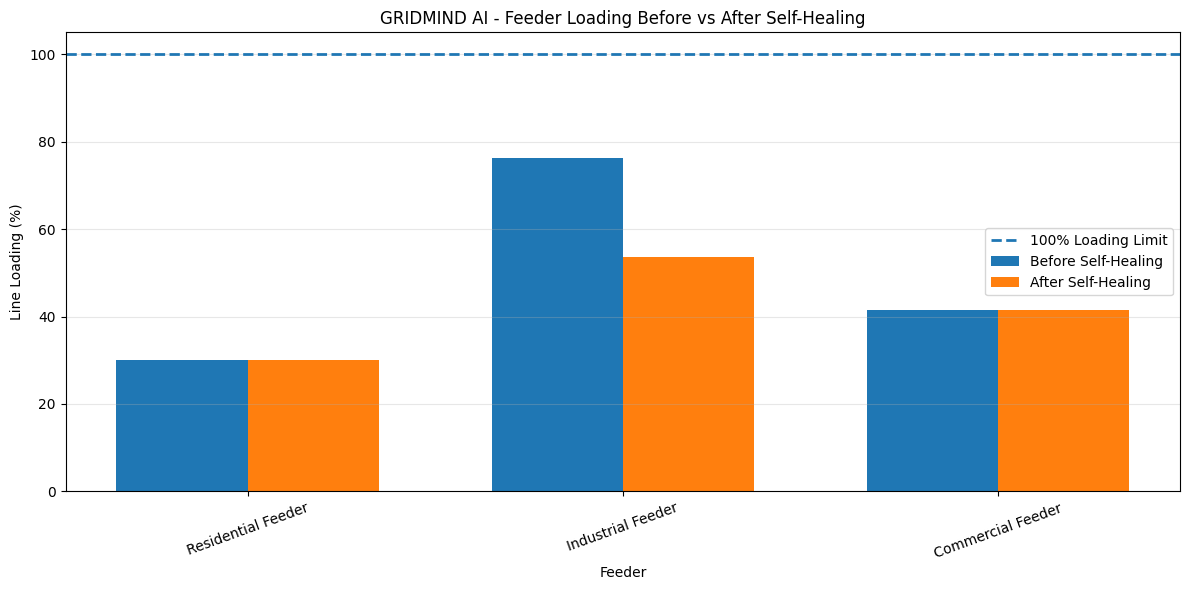

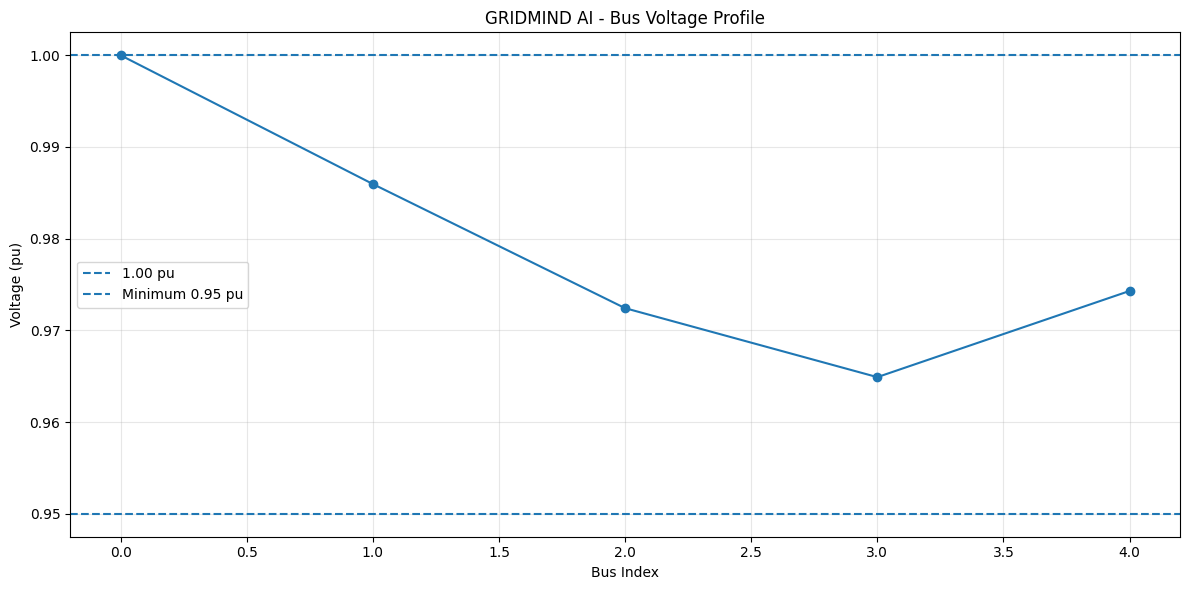

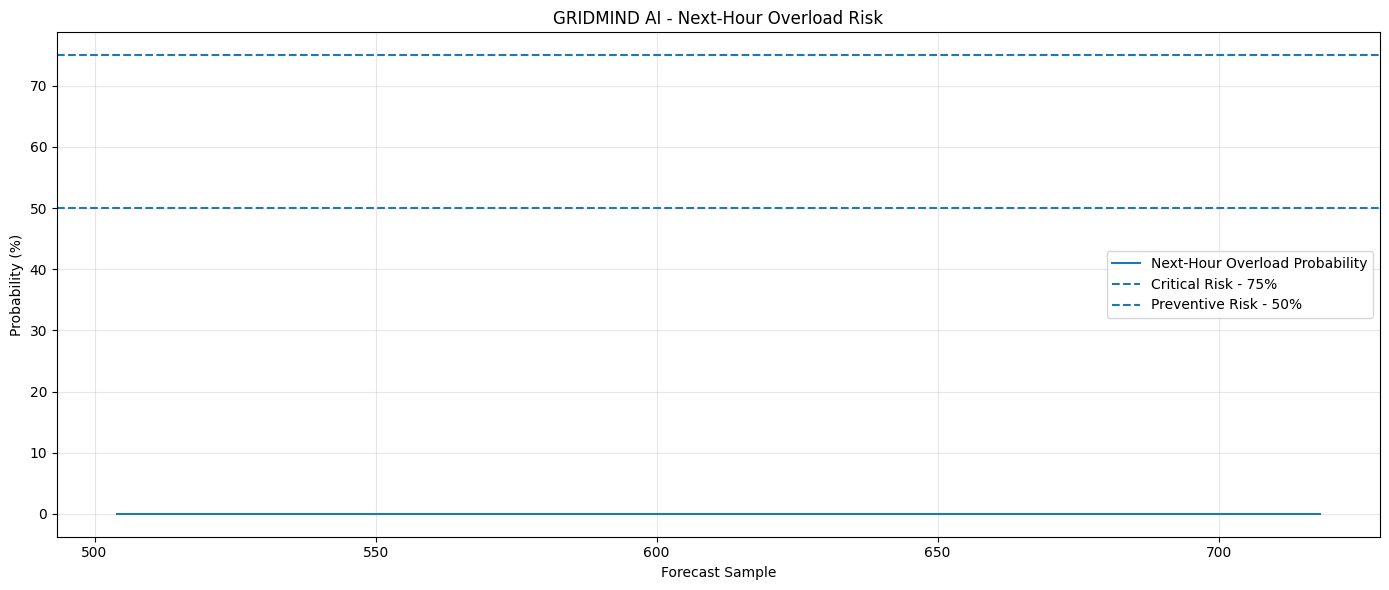


GRIDMIND AI - FINAL GRID HEALTH
Maximum Line Loading     : 53.54%
Minimum Bus Voltage      : 0.9649 pu
Maximum Transformer Load : 43.35%

✅ GRID STATUS: SAFE

✅ STEP 10 COMPLETED

Files saved:
GRIDMIND_FEEDER_BEFORE_AFTER.csv
GRIDMIND_GRID_HEALTH_SUMMARY.csv


In [67]:
# ============================================================
# STEP 10 - GRIDMIND AI DASHBOARD
# INDEPENDENT / RESET-SAFE VERSION
# ============================================================

import pandapower as pp
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("GRIDMIND AI - GRID HEALTH DASHBOARD")
print("=" * 70)

# ============================================================
# 1. CHECK THE MAIN NETWORK
# ============================================================

if "ts_net" not in globals():
    raise RuntimeError(
        "ts_net is not available. Please create the time-series "
        "network first."
    )

print("\n✅ Time-series network found.")


# ============================================================
# 2. CREATE INDEPENDENT DASHBOARD NETWORK
# ============================================================

dashboard_net = copy.deepcopy(ts_net)


# ============================================================
# 3. FEEDER INFORMATION
# ============================================================

feeders = {
    ts_res_line: {
        "name": "Residential Feeder",
        "load_idx": ts_res_load
    },

    ts_ind_line: {
        "name": "Industrial Feeder",
        "load_idx": ts_ind_load
    },

    ts_com_line: {
        "name": "Commercial Feeder",
        "load_idx": ts_com_load
    }
}

print("\nFeeders detected:")

for line_idx, info in feeders.items():

    print(
        f"Line {line_idx}: "
        f"{info['name']}"
    )


# ============================================================
# 4. CREATE STRESSED OPERATING CONDITION
# ============================================================

print("\nCreating stressed grid condition...")

dashboard_net.load.loc[
    ts_res_load,
    "p_mw"
] = 4.0

dashboard_net.load.loc[
    ts_ind_load,
    "p_mw"
] = 10.0

dashboard_net.load.loc[
    ts_com_load,
    "p_mw"
] = 6.0

dashboard_net.sgen.loc[
    ts_solar,
    "p_mw"
] = 0.5


# ============================================================
# 5. POWER FLOW BEFORE SELF-HEALING
# ============================================================

pp.runpp(
    dashboard_net,
    max_iteration=100
)

before_rows = []

for line_idx, info in feeders.items():

    loading = float(
        dashboard_net.res_line
        .loading_percent
        .loc[line_idx]
    )

    before_rows.append({
        "Feeder": info["name"],
        "Line_Index": line_idx,
        "Before_%": loading
    })

before_df = pd.DataFrame(before_rows)

print("\n" + "=" * 70)
print("BEFORE SELF-HEALING")
print("=" * 70)

display(before_df)


# ============================================================
# 6. FIND MOST CRITICAL FEEDER
# ============================================================

critical_position = before_df[
    "Before_%"
].idxmax()

critical_line = int(
    before_df.loc[
        critical_position,
        "Line_Index"
    ]
)

critical_feeder = before_df.loc[
    critical_position,
    "Feeder"
]

critical_loading = float(
    before_df.loc[
        critical_position,
        "Before_%"
    ]
)

print(
    f"\n🔴 Critical feeder: {critical_feeder}"
)

print(
    f"Loading before action: "
    f"{critical_loading:.2f}%"
)


# ============================================================
# 7. APPLY SELF-HEALING ACTION
# ============================================================

load_idx = feeders[
    critical_line
]["load_idx"]

original_load = float(
    dashboard_net.load.loc[
        load_idx,
        "p_mw"
    ]
)

# 30% load reduction / demand-side corrective action
dashboard_net.load.loc[
    load_idx,
    "p_mw"
] = original_load * 0.70

print("\n⚙️ SELF-HEALING ACTION")

print(
    f"Feeder: {critical_feeder}"
)

print(
    f"Load before: {original_load:.2f} MW"
)

print(
    f"Load after : "
    f"{dashboard_net.load.loc[load_idx, 'p_mw']:.2f} MW"
)


# ============================================================
# 8. POWER FLOW AFTER SELF-HEALING
# ============================================================

pp.runpp(
    dashboard_net,
    max_iteration=100
)

after_rows = []

for line_idx, info in feeders.items():

    loading = float(
        dashboard_net.res_line
        .loading_percent
        .loc[line_idx]
    )

    after_rows.append({
        "Feeder": info["name"],
        "Line_Index": line_idx,
        "After_%": loading
    })

after_df = pd.DataFrame(after_rows)


# ============================================================
# 9. CREATE FINAL COMPARISON TABLE
# ============================================================

comparison = before_df[
    ["Feeder", "Line_Index", "Before_%"]
].merge(
    after_df[
        ["Line_Index", "After_%"]
    ],
    on="Line_Index"
)

comparison["Improvement_%"] = (
    comparison["Before_%"]
    - comparison["After_%"]
)

print("\n" + "=" * 70)
print("BEFORE vs AFTER SELF-HEALING")
print("=" * 70)

display(comparison)


# ============================================================
# 10. FEEDER LOADING GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

x = np.arange(
    len(comparison)
)

width = 0.35

plt.bar(
    x - width / 2,
    comparison["Before_%"],
    width,
    label="Before Self-Healing"
)

plt.bar(
    x + width / 2,
    comparison["After_%"],
    width,
    label="After Self-Healing"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=2,
    label="100% Loading Limit"
)

plt.xticks(
    x,
    comparison["Feeder"],
    rotation=20
)

plt.xlabel("Feeder")
plt.ylabel("Line Loading (%)")

plt.title(
    "GRIDMIND AI - Feeder Loading Before vs After Self-Healing"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. VOLTAGE PROFILE
# ============================================================

voltage = (
    dashboard_net.res_bus.vm_pu.values
)

plt.figure(figsize=(12, 6))

plt.plot(
    np.arange(len(voltage)),
    voltage,
    marker="o"
)

plt.axhline(
    1.00,
    linestyle="--",
    label="1.00 pu"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="Minimum 0.95 pu"
)

plt.xlabel("Bus Index")
plt.ylabel("Voltage (pu)")

plt.title(
    "GRIDMIND AI - Bus Voltage Profile"
)

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. OVERLOAD PROBABILITY GRAPH
# ============================================================

if "forecast_results" in globals():

    plt.figure(figsize=(14, 6))

    plt.plot(
        forecast_results[
            "Overload_Probability_Percent"
        ],
        label="Next-Hour Overload Probability"
    )

    plt.axhline(
        75,
        linestyle="--",
        label="Critical Risk - 75%"
    )

    plt.axhline(
        50,
        linestyle="--",
        label="Preventive Risk - 50%"
    )

    plt.xlabel("Forecast Sample")
    plt.ylabel("Probability (%)")

    plt.title(
        "GRIDMIND AI - Next-Hour Overload Risk"
    )

    plt.legend()
    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "\n⚠️ forecast_results not available."
    )


# ============================================================
# 13. FINAL GRID HEALTH
# ============================================================

maximum_line_loading = float(
    dashboard_net.res_line
    .loading_percent
    .max()
)

minimum_voltage = float(
    dashboard_net.res_bus
    .vm_pu
    .min()
)

maximum_transformer_loading = float(
    dashboard_net.res_trafo
    .loading_percent
    .max()
)

print("\n" + "=" * 70)
print("GRIDMIND AI - FINAL GRID HEALTH")
print("=" * 70)

print(
    f"Maximum Line Loading     : "
    f"{maximum_line_loading:.2f}%"
)

print(
    f"Minimum Bus Voltage      : "
    f"{minimum_voltage:.4f} pu"
)

print(
    f"Maximum Transformer Load : "
    f"{maximum_transformer_loading:.2f}%"
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

grid_safe = (
    maximum_line_loading < 100
    and minimum_voltage >= 0.95
    and maximum_transformer_loading < 100
)

if grid_safe:

    status = "SAFE"

    print(
        "\n✅ GRID STATUS: SAFE"
    )

else:

    status = "ATTENTION REQUIRED"

    print(
        "\n⚠️ GRID STATUS: ATTENTION REQUIRED"
    )


# ============================================================
# 15. SAVE DASHBOARD DATA
# ============================================================

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

comparison.to_csv(
    output_dir +
    "/GRIDMIND_FEEDER_BEFORE_AFTER.csv",
    index=False
)

summary = pd.DataFrame({
    "Maximum_Line_Loading_%": [
        maximum_line_loading
    ],

    "Minimum_Bus_Voltage_pu": [
        minimum_voltage
    ],

    "Maximum_Transformer_Loading_%": [
        maximum_transformer_loading
    ],

    "Grid_Status": [
        status
    ]
})

summary.to_csv(
    output_dir +
    "/GRIDMIND_GRID_HEALTH_SUMMARY.csv",
    index=False
)

print("\n" + "=" * 70)
print("✅ STEP 10 COMPLETED")
print("=" * 70)

print(
    "\nFiles saved:"
)

print(
    "GRIDMIND_FEEDER_BEFORE_AFTER.csv"
)

print(
    "GRIDMIND_GRID_HEALTH_SUMMARY.csv"
)

In [68]:
# ============================================================
# STEP 11 - GRIDMIND AI AUTOMATED END-TO-END PIPELINE
# ============================================================

import copy
import os
import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 75)
print("              GRIDMIND AI")
print("       AUTOMATED PREDICTIVE GRID PIPELINE")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED COMPONENTS
# ============================================================

required = [
    "ts_net",
    "forecast_model",
    "X_test"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
        + "\nRun the corresponding earlier steps first."
    )

print("\n✅ Required GRIDMIND components found.")


# ============================================================
# 2. ML FORECAST
# ============================================================

print("\n" + "-" * 75)
print("STEP A - ML OVERLOAD FORECAST")
print("-" * 75)

probabilities = forecast_model.predict_proba(X_test)

classes = list(
    forecast_model.classes_
)

if 1 in classes:

    overload_index = classes.index(1)

    overload_probability = probabilities[
        :,
        overload_index
    ]

else:

    overload_probability = np.zeros(
        len(X_test)
    )


# Find highest-risk prediction
risk_position = int(
    np.argmax(overload_probability)
)

risk_probability = float(
    overload_probability[risk_position]
)

print(
    f"Highest predicted overload probability: "
    f"{risk_probability * 100:.2f}%"
)


# ============================================================
# 3. RISK CLASSIFICATION
# ============================================================

if risk_probability >= 0.75:

    risk_level = "CRITICAL"

elif risk_probability >= 0.50:

    risk_level = "PREVENTIVE"

elif risk_probability >= 0.25:

    risk_level = "WARNING"

else:

    risk_level = "NORMAL"


print(
    f"AI Risk Level: {risk_level}"
)


# ============================================================
# 4. CREATE INDEPENDENT GRID
# ============================================================

print("\n" + "-" * 75)
print("STEP B - GRID OPERATING CONDITION")
print("-" * 75)

pipeline_net = copy.deepcopy(
    ts_net
)

# Stress condition for demonstration
pipeline_net.load.loc[
    ts_res_load,
    "p_mw"
] = 4.0

pipeline_net.load.loc[
    ts_ind_load,
    "p_mw"
] = 10.0

pipeline_net.load.loc[
    ts_com_load,
    "p_mw"
] = 6.0

pipeline_net.sgen.loc[
    ts_solar,
    "p_mw"
] = 0.5


# ============================================================
# 5. POWER FLOW BEFORE AI ACTION
# ============================================================

pp.runpp(
    pipeline_net,
    max_iteration=100
)

before_line_loading = (
    pipeline_net
    .res_line
    .loading_percent
    .copy()
)

before_voltage = (
    pipeline_net
    .res_bus
    .vm_pu
    .copy()
)

before_trafo_loading = (
    pipeline_net
    .res_trafo
    .loading_percent
    .copy()
)

print(
    f"Maximum line loading: "
    f"{before_line_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage: "
    f"{before_voltage.min():.4f} pu"
)

print(
    f"Transformer loading: "
    f"{before_trafo_loading.max():.2f}%"
)


# ============================================================
# 6. IDENTIFY CRITICAL FEEDER
# ============================================================

feeder_map = {
    ts_res_line: (
        "Residential Feeder",
        ts_res_load
    ),

    ts_ind_line: (
        "Industrial Feeder",
        ts_ind_load
    ),

    ts_com_line: (
        "Commercial Feeder",
        ts_com_load
    )
}

critical_line = int(
    before_line_loading.idxmax()
)

critical_feeder = feeder_map.get(
    critical_line,
    (
        f"Line {critical_line}",
        None
    )
)[0]

critical_load_index = feeder_map.get(
    critical_line,
    (
        f"Line {critical_line}",
        None
    )
)[1]

critical_loading = float(
    before_line_loading.loc[
        critical_line
    ]
)

print(
    f"\nCritical feeder: "
    f"{critical_feeder}"
)

print(
    f"Critical feeder loading: "
    f"{critical_loading:.2f}%"
)


# ============================================================
# 7. AI SELF-HEALING DECISION
# ============================================================

print("\n" + "-" * 75)
print("STEP C - AI SELF-HEALING DECISION")
print("-" * 75)

if (
    risk_level in
    ["CRITICAL", "PREVENTIVE"]
    or critical_loading >= 100
):

    action = (
        "Predictive load management "
        "on critical feeder"
    )

    if critical_load_index is not None:

        original_load = float(
            pipeline_net
            .load
            .loc[
                critical_load_index,
                "p_mw"
            ]
        )

        pipeline_net.load.loc[
            critical_load_index,
            "p_mw"
        ] = original_load * 0.70

        print(
            "✅ Corrective action applied."
        )

        print(
            f"Feeder: {critical_feeder}"
        )

        print(
            f"Load reduced from "
            f"{original_load:.2f} MW "
            f"to "
            f"{original_load * 0.70:.2f} MW"
        )

    else:

        action = (
            "Critical feeder identified, "
            "but no predefined control available."
        )

        print(
            "⚠️ No predefined corrective action."
        )

else:

    action = (
        "No corrective action required"
    )

    print(
        "🟢 Grid risk below corrective-action threshold."
    )


# ============================================================
# 8. RE-RUN POWER FLOW
# ============================================================

print("\n" + "-" * 75)
print("STEP D - POST-ACTION POWER FLOW")
print("-" * 75)

pp.runpp(
    pipeline_net,
    max_iteration=100
)

after_line_loading = (
    pipeline_net
    .res_line
    .loading_percent
    .copy()
)

after_voltage = (
    pipeline_net
    .res_bus
    .vm_pu
    .copy()
)

after_trafo_loading = (
    pipeline_net
    .res_trafo
    .loading_percent
    .copy()
)

print(
    f"Maximum line loading: "
    f"{after_line_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage: "
    f"{after_voltage.min():.4f} pu"
)

print(
    f"Transformer loading: "
    f"{after_trafo_loading.max():.2f}%"
)


# ============================================================
# 9. GRID SAFETY VERIFICATION
# ============================================================

line_safe = (
    after_line_loading.max()
    < 100
)

voltage_safe = (
    after_voltage.min()
    >= 0.95
)

transformer_safe = (
    after_trafo_loading.max()
    < 100
)

grid_safe = (
    line_safe
    and voltage_safe
    and transformer_safe
)


# ============================================================
# 10. FINAL SYSTEM STATUS
# ============================================================

if grid_safe:

    final_status = (
        "SAFE - GRID WITHIN LIMITS"
    )

else:

    final_status = (
        "ATTENTION REQUIRED"
    )


print("\n" + "=" * 75)
print("              GRIDMIND AI FINAL RESULT")
print("=" * 75)

print(
    f"ML overload probability : "
    f"{risk_probability * 100:.2f}%"
)

print(
    f"Risk level              : "
    f"{risk_level}"
)

print(
    f"Critical feeder         : "
    f"{critical_feeder}"
)

print(
    f"AI action               : "
    f"{action}"
)

print(
    f"Line loading before     : "
    f"{before_line_loading.max():.2f}%"
)

print(
    f"Line loading after      : "
    f"{after_line_loading.max():.2f}%"
)

print(
    f"Minimum voltage after   : "
    f"{after_voltage.min():.4f} pu"
)

print(
    f"Transformer loading     : "
    f"{after_trafo_loading.max():.2f}%"
)

print(
    f"FINAL STATUS            : "
    f"{final_status}"
)


# ============================================================
# 11. CREATE FINAL REPORT
# ============================================================

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

final_report = pd.DataFrame({

    "ML_Overload_Probability_%": [
        risk_probability * 100
    ],

    "Risk_Level": [
        risk_level
    ],

    "Critical_Feeder": [
        critical_feeder
    ],

    "Critical_Loading_Before_%": [
        critical_loading
    ],

    "Maximum_Line_Loading_Before_%": [
        before_line_loading.max()
    ],

    "Maximum_Line_Loading_After_%": [
        after_line_loading.max()
    ],

    "Minimum_Voltage_Before_pu": [
        before_voltage.min()
    ],

    "Minimum_Voltage_After_pu": [
        after_voltage.min()
    ],

    "Transformer_Loading_Before_%": [
        before_trafo_loading.max()
    ],

    "Transformer_Loading_After_%": [
        after_trafo_loading.max()
    ],

    "AI_Action": [
        action
    ],

    "Grid_Safe": [
        grid_safe
    ],

    "Final_Status": [
        final_status
    ]
})


# ============================================================
# 12. SAVE FINAL REPORT
# ============================================================

final_report_path = (
    output_dir
    + "/GRIDMIND_AI_FINAL_PIPELINE_REPORT.csv"
)

final_report.to_csv(
    final_report_path,
    index=False
)

print("\n✅ FINAL PIPELINE REPORT SAVED:")
print(final_report_path)

print("\n" + "=" * 75)
print("STEP 11 COMPLETED")
print("=" * 75)

display(final_report)

              GRIDMIND AI
       AUTOMATED PREDICTIVE GRID PIPELINE

✅ Required GRIDMIND components found.

---------------------------------------------------------------------------
STEP A - ML OVERLOAD FORECAST
---------------------------------------------------------------------------
Highest predicted overload probability: 0.00%
AI Risk Level: NORMAL

---------------------------------------------------------------------------
STEP B - GRID OPERATING CONDITION
---------------------------------------------------------------------------
Maximum line loading: 76.30%
Minimum bus voltage: 0.9564 pu
Transformer loading: 51.30%

Critical feeder: Industrial Feeder
Critical feeder loading: 76.30%

---------------------------------------------------------------------------
STEP C - AI SELF-HEALING DECISION
---------------------------------------------------------------------------
🟢 Grid risk below corrective-action threshold.

----------------------------------------------------------------

,ML_Overload_Probability_%,Risk_Level,Critical_Feeder,Critical_Loading_Before_%,Maximum_Line_Loading_Before_%,Maximum_Line_Loading_After_%,Minimum_Voltage_Before_pu,Minimum_Voltage_After_pu,Transformer_Loading_Before_%,Transformer_Loading_After_%,AI_Action,Grid_Safe,Final_Status
0,0.0,NORMAL,Industrial Feeder,76.304054,76.304054,76.304054,0.956386,0.956386,51.295467,51.295467,No corrective action required,True,SAFE - GRID WITHIN LIMITS


GRIDMIND AI - ML VALIDATION

TEST DATA DISTRIBUTION
--------------------------------------------------
NORMAL (0): 215

Total test samples: 215

CLASSIFICATION METRICS
Accuracy  : 1.0000
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

⚠️ ROC-AUC and PR-AUC cannot be calculated.
The test set contains only one class.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       215
    OVERLOAD       0.00      0.00      0.00         0

    accuracy                           1.00       215
   macro avg       0.50      0.50      0.50       215
weighted avg       1.00      1.00      1.00       215

CONFUSION MATRIX
--------------------------------------------------
[[215   0]
 [  0   0]]


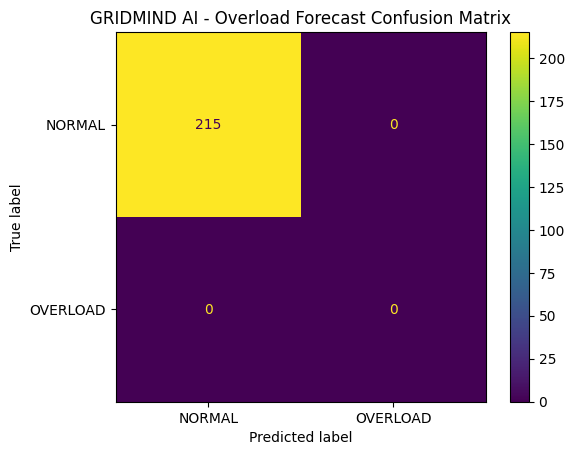


FEATURE IMPORTANCE


,Feature,Importance
0,hour,0.0
1,residential_load_mw,0.0
2,industrial_load_mw,0.0
3,commercial_load_mw,0.0
4,total_load_mw,0.0
5,solar_generation_mw,0.0
6,net_load_mw,0.0
7,minimum_bus_voltage_pu,0.0
8,maximum_bus_voltage_pu,0.0
9,maximum_line_loading_percent,0.0


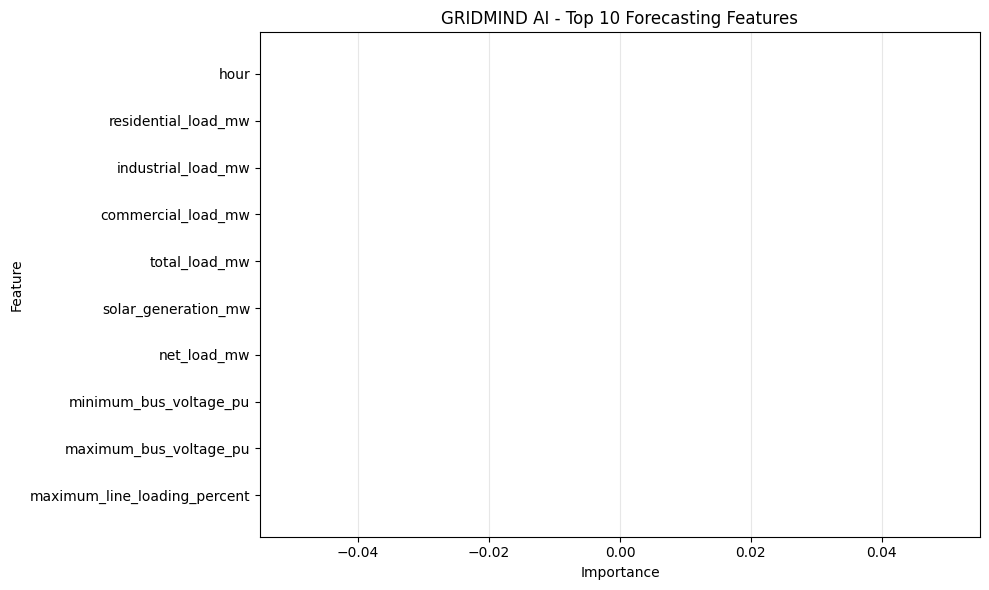


STEP 12 COMPLETE
⚠️ IMPORTANT: Test set contains only one class.
Do NOT use accuracy alone to claim model performance.

Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_ML_VALIDATION_RESULTS.csv


In [69]:
# ============================================================
# STEP 12 - GRIDMIND AI ML VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("=" * 75)
print("GRIDMIND AI - ML VALIDATION")
print("=" * 75)


# ============================================================
# 1. CHECK TEST DATA
# ============================================================

print("\nTEST DATA DISTRIBUTION")
print("-" * 50)

unique, counts = np.unique(
    y_test,
    return_counts=True
)

for cls, count in zip(unique, counts):

    label = (
        "NORMAL"
        if cls == 0
        else "OVERLOAD"
    )

    print(
        f"{label} ({cls}): {count}"
    )

print(
    f"\nTotal test samples: {len(y_test)}"
)


# ============================================================
# 2. GENERATE PREDICTIONS
# ============================================================

y_pred = forecast_model.predict(
    X_test
)

probabilities = forecast_model.predict_proba(
    X_test
)

classes = list(
    forecast_model.classes_
)


# ============================================================
# 3. GET OVERLOAD PROBABILITY
# ============================================================

if 1 in classes:

    overload_index = classes.index(1)

    y_probability = probabilities[
        :,
        overload_index
    ]

else:

    y_probability = np.zeros(
        len(X_test)
    )


# ============================================================
# 4. BASIC METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n" + "=" * 75)
print("CLASSIFICATION METRICS")
print("=" * 75)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


# ============================================================
# 5. ROC-AUC / PR-AUC
# ============================================================

if len(np.unique(y_test)) == 2:

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    pr_auc = average_precision_score(
        y_test,
        y_probability
    )

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC    : {pr_auc:.4f}"
    )

else:

    roc_auc = np.nan
    pr_auc = np.nan

    print(
        "\n⚠️ ROC-AUC and PR-AUC cannot be calculated."
    )

    print(
        "The test set contains only one class."
    )


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("CONFUSION MATRIX")
print("-" * 50)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
)

disp.plot()

plt.title(
    "GRIDMIND AI - Overload Forecast Confusion Matrix"
)

plt.show()


# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 75)
print("FEATURE IMPORTANCE")
print("=" * 75)

if hasattr(
    forecast_model,
    "feature_importances_"
):

    importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": (
            forecast_model
            .feature_importances_
        )
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    display(
        importance
    )

    # Plot top features

    top_features = importance.head(10)

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "GRIDMIND AI - Top 10 Forecasting Features"
    )

    plt.gca().invert_yaxis()

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "Feature importance is not available "
        "for this model."
    )


# ============================================================
# 9. SAVE VALIDATION RESULTS
# ============================================================

validation_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

validation_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_ML_VALIDATION_RESULTS.csv"
)

validation_summary.to_csv(
    validation_path,
    index=False
)


# ============================================================
# 10. FINAL VALIDATION MESSAGE
# ============================================================

print("\n" + "=" * 75)
print("STEP 12 COMPLETE")
print("=" * 75)

if len(np.unique(y_test)) < 2:

    print(
        "⚠️ IMPORTANT: Test set contains only one class."
    )

    print(
        "Do NOT use accuracy alone to claim model performance."
    )

elif f1 < 0.50:

    print(
        "⚠️ Model needs improvement before final reporting."
    )

else:

    print(
        "✅ Model has measurable classification performance."
    )

print(
    "\nSaved:",
    validation_path
)

In [71]:
# ============================================================
# STEP 13 - ML MODEL COMPARISON
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("=" * 75)
print("GRIDMIND AI - ML MODEL COMPARISON")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED DATA
# ============================================================

required = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "forecast_model"
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
    )

print("\n✅ Training and testing datasets found.")


# ============================================================
# 2. TRAIN GRADIENT BOOSTING
# ============================================================

print("\nTraining Gradient Boosting model...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("✅ Gradient Boosting training completed.")


# ============================================================
# 3. RANDOM FOREST PREDICTIONS
# ============================================================

rf_pred = forecast_model.predict(
    X_test
)

rf_probability_matrix = (
    forecast_model.predict_proba(
        X_test
    )
)

rf_classes = list(
    forecast_model.classes_
)

if 1 in rf_classes:

    rf_overload_index = (
        rf_classes.index(1)
    )

    rf_probability = (
        rf_probability_matrix[
            :,
            rf_overload_index
        ]
    )

else:

    rf_probability = np.zeros(
        len(X_test)
    )


# ============================================================
# 4. GRADIENT BOOSTING PREDICTIONS
# ============================================================

gb_pred = gb_model.predict(
    X_test
)

gb_probability_matrix = (
    gb_model.predict_proba(
        X_test
    )
)

gb_classes = list(
    gb_model.classes_
)

if 1 in gb_classes:

    gb_overload_index = (
        gb_classes.index(1)
    )

    gb_probability = (
        gb_probability_matrix[
            :,
            gb_overload_index
        ]
    )

else:

    gb_probability = np.zeros(
        len(X_test)
    )


# ============================================================
# 5. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    name,
    y_true,
    y_pred,
    probability
):

    results = {}

    results["Model"] = name

    results["Accuracy"] = (
        accuracy_score(
            y_true,
            y_pred
        )
    )

    results["Precision"] = (
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    results["Recall"] = (
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    results["F1"] = (
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    if len(
        np.unique(y_true)
    ) == 2:

        results["ROC_AUC"] = (
            roc_auc_score(
                y_true,
                probability
            )
        )

        results["PR_AUC"] = (
            average_precision_score(
                y_true,
                probability
            )
        )

    else:

        results["ROC_AUC"] = np.nan
        results["PR_AUC"] = np.nan

    return results


# ============================================================
# 6. COMPARE BOTH MODELS
# ============================================================

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_probability
)

gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred,
    gb_probability
)

comparison = pd.DataFrame([
    rf_results,
    gb_results
])

print("\n" + "=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

display(
    comparison.round(4)
)


# ============================================================
# 7. DETAILED REPORT - RANDOM FOREST
# ============================================================

print("\n" + "=" * 75)
print("RANDOM FOREST")
print("=" * 75)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 8. DETAILED REPORT - GRADIENT BOOSTING
# ============================================================

print("\n" + "=" * 75)
print("GRADIENT BOOSTING")
print("=" * 75)

print(
    classification_report(
        y_test,
        gb_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. SELECT MODEL FOR FURTHER DEVELOPMENT
# ============================================================

# We use F1 as the primary comparison metric
# because overload detection is the important class.

if (
    gb_results["F1"]
    >
    rf_results["F1"]
):

    selected_model = gb_model
    selected_model_name = "Gradient Boosting"

else:

    selected_model = forecast_model
    selected_model_name = "Random Forest"


print("\n" + "=" * 75)
print("MODEL SELECTED FOR FURTHER DEVELOPMENT")
print("=" * 75)

print(
    f"Selected model: {selected_model_name}"
)


# ============================================================
# 10. SAVE MODEL COMPARISON
# ============================================================

comparison_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_MODEL_COMPARISON.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print(
    "\n✅ Model comparison saved:"
)

print(
    comparison_path
)

GRIDMIND AI - ML MODEL COMPARISON

✅ Training and testing datasets found.

Training Gradient Boosting model...


ValueError: y contains 1 class after sample_weight trimmed classes with zero weights, while a minimum of 2 classes are required.

In [72]:
# ============================================================
# STEP 13A - CHECK ML CLASS DISTRIBUTION
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("GRIDMIND AI - ML DATASET CLASS CHECK")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training distribution
# ------------------------------------------------------------

print("\nTRAINING SET")
print("-" * 50)

train_classes, train_counts = np.unique(
    y_train,
    return_counts=True
)

for cls, count in zip(
    train_classes,
    train_counts
):

    label = (
        "NORMAL"
        if cls == 0
        else "OVERLOAD"
    )

    print(
        f"{label} ({cls}): {count}"
    )


# ------------------------------------------------------------
# 2. Test distribution
# ------------------------------------------------------------

print("\nTEST SET")
print("-" * 50)

test_classes, test_counts = np.unique(
    y_test,
    return_counts=True
)

for cls, count in zip(
    test_classes,
    test_counts
):

    label = (
        "NORMAL"
        if cls == 0
        else "OVERLOAD"
    )

    print(
        f"{label} ({cls}): {count}"
    )


# ------------------------------------------------------------
# 3. Overall chronological dataset
# ------------------------------------------------------------

if "chronological_df" in globals():

    print("\nCHRONOLOGICAL DATASET")
    print("-" * 50)

    print(
        f"Total rows: "
        f"{len(chronological_df)}"
    )

    if "overload" in chronological_df.columns:

        overall_classes, overall_counts = np.unique(
            chronological_df["overload"],
            return_counts=True
        )

        for cls, count in zip(
            overall_classes,
            overall_counts
        ):

            label = (
                "NORMAL"
                if cls == 0
                else "OVERLOAD"
            )

            print(
                f"{label} ({cls}): {count}"
            )

    else:

        print(
            "⚠️ 'overload' column not found."
        )


# ------------------------------------------------------------
# 4. Final diagnosis
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DIAGNOSIS")
print("=" * 70)

if len(train_classes) < 2:

    print(
        "❌ TRAINING SET HAS ONLY ONE CLASS."
    )

    print(
        "We must fix the chronological dataset "
        "before training another ML model."
    )

elif len(test_classes) < 2:

    print(
        "⚠️ TEST SET HAS ONLY ONE CLASS."
    )

    print(
        "Training is possible, but proper evaluation "
        "is not possible yet."
    )

else:

    print(
        "✅ Both training and test sets contain "
        "NORMAL and OVERLOAD."
    )

    print(
        "ML model comparison can proceed."
    )

GRIDMIND AI - ML DATASET CLASS CHECK

TRAINING SET
--------------------------------------------------
NORMAL (0): 504

TEST SET
--------------------------------------------------
NORMAL (0): 215

CHRONOLOGICAL DATASET
--------------------------------------------------
Total rows: 719
⚠️ 'overload' column not found.

DIAGNOSIS
❌ TRAINING SET HAS ONLY ONE CLASS.
We must fix the chronological dataset before training another ML model.


In [73]:
# ============================================================
# STEP 13B - REBUILD CHRONOLOGICAL STRESS DATASET
# GRIDMIND AI
# ============================================================

import pandapower as pp
import pandas as pd
import numpy as np
import copy
import os

print("=" * 75)
print("GRIDMIND AI - CHRONOLOGICAL STRESS DATASET")
print("=" * 75)

# ------------------------------------------------------------
# 1. CHECK NETWORK
# ------------------------------------------------------------

if "ts_net" not in globals():
    raise RuntimeError(
        "ts_net not found. The time-series network is required."
    )

# ------------------------------------------------------------
# 2. Simulation settings
# ------------------------------------------------------------

DAYS = 30
HOURS_TOTAL = DAYS * 24

rng = np.random.default_rng(42)

records = []

print(f"\nSimulating {HOURS_TOTAL} chronological hours...")

# ------------------------------------------------------------
# 3. Run chronological simulation
# ------------------------------------------------------------

for hour in range(HOURS_TOTAL):

    day = hour // 24 + 1
    hour_of_day = hour % 24

    net = copy.deepcopy(ts_net)

    # --------------------------------------------------------
    # Base daily/hourly load pattern
    # --------------------------------------------------------

    # Morning/evening demand increase
    if 6 <= hour_of_day <= 9:
        time_factor = 1.15

    elif 17 <= hour_of_day <= 21:
        time_factor = 1.30

    elif 10 <= hour_of_day <= 16:
        time_factor = 1.00

    else:
        time_factor = 0.75

    # --------------------------------------------------------
    # Create periodic stress periods
    # --------------------------------------------------------

    # Days 1-10: mostly normal
    # Days 11-15: stressed
    # Days 16-20: mostly normal
    # Days 21-25: heavily stressed
    # Days 26-30: mixed

    if 11 <= day <= 15:

        stress_factor = rng.uniform(
            2.0,
            2.8
        )

    elif 21 <= day <= 25:

        stress_factor = rng.uniform(
            2.3,
            3.2
        )

    elif 26 <= day <= 30:

        # Mixed conditions
        if rng.random() < 0.50:
            stress_factor = rng.uniform(
                2.2,
                3.0
            )
        else:
            stress_factor = rng.uniform(
                0.8,
                1.3
            )

    else:

        stress_factor = rng.uniform(
            0.75,
            1.20
        )

    # Small random operating variation
    variation = rng.uniform(
        0.90,
        1.10
    )

    total_factor = (
        time_factor
        * stress_factor
        * variation
    )

    # --------------------------------------------------------
    # Individual feeder behaviour
    # --------------------------------------------------------

    residential_factor = total_factor * rng.uniform(
        0.90,
        1.10
    )

    industrial_factor = total_factor * rng.uniform(
        0.95,
        1.20
    )

    commercial_factor = total_factor * rng.uniform(
        0.90,
        1.15
    )

    # --------------------------------------------------------
    # Apply loads
    # --------------------------------------------------------

    base_residential = 2.0
    base_industrial = 5.0
    base_commercial = 3.0

    net.load.loc[
        ts_res_load,
        "p_mw"
    ] = (
        base_residential
        * residential_factor
    )

    net.load.loc[
        ts_ind_load,
        "p_mw"
    ] = (
        base_industrial
        * industrial_factor
    )

    net.load.loc[
        ts_com_load,
        "p_mw"
    ] = (
        base_commercial
        * commercial_factor
    )

    # --------------------------------------------------------
    # Solar generation
    # --------------------------------------------------------

    if 6 <= hour_of_day <= 18:

        solar_shape = np.sin(
            np.pi
            * (hour_of_day - 6)
            / 12
        )

        solar_output = (
            2.0
            * max(
                0,
                solar_shape
            )
            * rng.uniform(
                0.70,
                1.10
            )
        )

    else:

        solar_output = 0.0

    net.sgen.loc[
        ts_solar,
        "p_mw"
    ] = solar_output

    # --------------------------------------------------------
    # Run power flow
    # --------------------------------------------------------

    try:

        pp.runpp(
            net,
            max_iteration=100
        )

        # ----------------------------------------------------
        # Grid measurements
        # ----------------------------------------------------

        max_line_loading = float(
            net.res_line.loading_percent.max()
        )

        min_voltage = float(
            net.res_bus.vm_pu.min()
        )

        transformer_loading = float(
            net.res_trafo.loading_percent.max()
        )

        total_line_loss = float(
            net.res_line.pl_mw.sum()
        )

        # ----------------------------------------------------
        # Overload definition
        # ----------------------------------------------------

        overload = int(
            max_line_loading >= 100
        )

        converged = 1

    except Exception:

        max_line_loading = np.nan
        min_voltage = np.nan
        transformer_loading = np.nan
        total_line_loss = np.nan

        overload = 1
        converged = 0

    # --------------------------------------------------------
    # Store current-hour data
    # --------------------------------------------------------

    records.append({

        "hour_index": hour,

        "day": day,

        "hour_of_day": hour_of_day,

        "load_factor": total_factor,

        "residential_load_mw":
            net.load.loc[
                ts_res_load,
                "p_mw"
            ],

        "industrial_load_mw":
            net.load.loc[
                ts_ind_load,
                "p_mw"
            ],

        "commercial_load_mw":
            net.load.loc[
                ts_com_load,
                "p_mw"
            ],

        "solar_generation_mw":
            solar_output,

        "max_line_loading_percent":
            max_line_loading,

        "min_bus_voltage_pu":
            min_voltage,

        "transformer_loading_percent":
            transformer_loading,

        "line_losses_mw":
            total_line_loss,

        "overload":
            overload,

        "powerflow_converged":
            converged
    })


# ------------------------------------------------------------
# 4. Create dataframe
# ------------------------------------------------------------

chronological_df = pd.DataFrame(
    records
)

# ------------------------------------------------------------
# 5. Create NEXT-HOUR target
# ------------------------------------------------------------

chronological_df[
    "next_hour_overload"
] = (
    chronological_df[
        "overload"
    ].shift(-1)
)

# Remove final row because it has no next-hour target
chronological_df = (
    chronological_df
    .iloc[:-1]
    .reset_index(drop=True)
)

print("\nSimulation completed.")

# ------------------------------------------------------------
# 6. Dataset distribution
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("OVERLOAD DISTRIBUTION")
print("=" * 75)

print(
    chronological_df[
        "overload"
    ].value_counts()
    .sort_index()
)

print("\nNext-hour target distribution:")

print(
    chronological_df[
        "next_hour_overload"
    ].value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 7. Create time-aware train/test split
# ------------------------------------------------------------

train_df = chronological_df[
    chronological_df["day"] <= 21
].copy()

test_df = chronological_df[
    chronological_df["day"] > 21
].copy()

print("\n" + "=" * 75)
print("TRAIN / TEST DISTRIBUTION")
print("=" * 75)

print("\nTRAINING TARGET:")

print(
    train_df[
        "next_hour_overload"
    ].value_counts()
    .sort_index()
)

print("\nTEST TARGET:")

print(
    test_df[
        "next_hour_overload"
    ].value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 8. Check whether both classes exist
# ------------------------------------------------------------

train_classes = (
    train_df[
        "next_hour_overload"
    ].nunique()
)

test_classes = (
    test_df[
        "next_hour_overload"
    ].nunique()
)

print("\n" + "=" * 75)
print("DATASET VALIDATION")
print("=" * 75)

print(
    f"Training classes: {train_classes}"
)

print(
    f"Testing classes : {test_classes}"
)

if (
    train_classes >= 2
    and test_classes >= 2
):

    print(
        "\n✅ SUCCESS!"
    )

    print(
        "Both training and test periods "
        "contain NORMAL and OVERLOAD events."
    )

else:

    print(
        "\n⚠️ Dataset still does not contain "
        "both classes in both periods."
    )

    print(
        "We will increase the stress level further."
    )


# ------------------------------------------------------------
# 9. Save dataset
# ------------------------------------------------------------

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

dataset_path = (
    output_dir
    + "/GRIDMIND_CHRONOLOGICAL_STRESS_DATASET.csv"
)

chronological_df.to_csv(
    dataset_path,
    index=False
)

print(
    "\nDataset saved:"
)

print(
    dataset_path
)

GRIDMIND AI - CHRONOLOGICAL STRESS DATASET

Simulating 720 chronological hours...

Simulation completed.

OVERLOAD DISTRIBUTION
overload
0    552
1    167
Name: count, dtype: int64

Next-hour target distribution:
next_hour_overload
0.0    552
1.0    167
Name: count, dtype: int64

TRAIN / TEST DISTRIBUTION

TRAINING TARGET:
next_hour_overload
0.0    430
1.0     74
Name: count, dtype: int64

TEST TARGET:
next_hour_overload
0.0    122
1.0     93
Name: count, dtype: int64

DATASET VALIDATION
Training classes: 2
Testing classes : 2

✅ SUCCESS!
Both training and test periods contain NORMAL and OVERLOAD events.

Dataset saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_CHRONOLOGICAL_STRESS_DATASET.csv


In [74]:
# ============================================================
# STEP 13C - REBUILD ML FORECASTING DATASET
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

print("=" * 75)
print("GRIDMIND AI - REBUILD ML FORECASTING DATASET")
print("=" * 75)


# ============================================================
# 1. CHECK CHRONOLOGICAL DATA
# ============================================================

if "chronological_df" not in globals():
    raise RuntimeError(
        "chronological_df not found. Run Step 13B first."
    )


# ============================================================
# 2. FEATURES
# ============================================================

forecast_features = [
    "load_factor",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "solar_generation_mw",
    "max_line_loading_percent",
    "min_bus_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",
    "hour_of_day"
]


# Make sure all features exist
missing_features = [
    col
    for col in forecast_features
    if col not in chronological_df.columns
]

if missing_features:

    raise RuntimeError(
        "Missing features: "
        + ", ".join(missing_features)
    )


# ============================================================
# 3. REMOVE INVALID ROWS
# ============================================================

ml_df = chronological_df.dropna(
    subset=forecast_features + [
        "next_hour_overload"
    ]
).copy()


# ============================================================
# 4. TIME-AWARE TRAIN / TEST SPLIT
# ============================================================

train_df = ml_df[
    ml_df["day"] <= 21
].copy()

test_df = ml_df[
    ml_df["day"] > 21
].copy()


# ============================================================
# 5. BUILD X AND y
# ============================================================

X_train = train_df[
    forecast_features
].copy()

y_train = train_df[
    "next_hour_overload"
].astype(int)

X_test = test_df[
    forecast_features
].copy()

y_test = test_df[
    "next_hour_overload"
].astype(int)


# ============================================================
# 6. CHECK CLASS DISTRIBUTION
# ============================================================

print("\nTRAINING TARGET")
print("-" * 50)

print(
    y_train.value_counts()
    .sort_index()
)

print("\nTEST TARGET")
print("-" * 50)

print(
    y_test.value_counts()
    .sort_index()
)


# ============================================================
# 7. VALIDATE CLASSES
# ============================================================

if y_train.nunique() < 2:

    raise RuntimeError(
        "Training data still contains only one class. "
        "Do not train the ML model yet."
    )

if y_test.nunique() < 2:

    print(
        "\n⚠️ WARNING: Test data contains only one class."
    )

else:

    print(
        "\n✅ Both training and test contain "
        "NORMAL + OVERLOAD."
    )


# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

print("\nTraining Random Forest...")

forecast_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X_train,
    y_train
)

print(
    "✅ Random Forest training completed."
)


# ============================================================
# 9. GENERATE TEST PREDICTIONS
# ============================================================

y_pred = forecast_model.predict(
    X_test
)

probability_matrix = (
    forecast_model.predict_proba(
        X_test
    )
)

classes = list(
    forecast_model.classes_
)

if 1 in classes:

    overload_index = classes.index(1)

    overload_probability = (
        probability_matrix[
            :,
            overload_index
        ]
    )

else:

    overload_probability = np.zeros(
        len(X_test)
    )


# ============================================================
# 10. CREATE FORECAST RESULTS
# ============================================================

forecast_results = test_df.copy()

forecast_results[
    "Actual_Next_Hour_Overload"
] = y_test.values

forecast_results[
    "Predicted_Next_Hour_Overload"
] = y_pred

forecast_results[
    "Overload_Probability"
] = overload_probability

forecast_results[
    "Overload_Probability_Percent"
] = (
    overload_probability * 100
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("NEXT-HOUR FORECAST RESULTS")
print("=" * 75)

display(
    forecast_results[
        [
            "day",
            "hour_of_day",
            "max_line_loading_percent",
            "transformer_loading_percent",
            "solar_generation_mw",
            "Actual_Next_Hour_Overload",
            "Predicted_Next_Hour_Overload",
            "Overload_Probability_Percent"
        ]
    ].head(20)
)


# ============================================================
# 12. SAVE NEW FORECAST DATA
# ============================================================

output_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_REBUILT_FORECAST_RESULTS.csv"
)

forecast_results.to_csv(
    output_path,
    index=False
)

print(
    "\n✅ New forecasting dataset saved:"
)

print(
    output_path
)


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": forecast_features,

    "Importance":
        forecast_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 75)
print("FEATURE IMPORTANCE")
print("=" * 75)

display(
    importance
)

GRIDMIND AI - REBUILD ML FORECASTING DATASET

TRAINING TARGET
--------------------------------------------------
next_hour_overload
0    430
1     74
Name: count, dtype: int64

TEST TARGET
--------------------------------------------------
next_hour_overload
0    122
1     93
Name: count, dtype: int64

✅ Both training and test contain NORMAL + OVERLOAD.

Training Random Forest...
✅ Random Forest training completed.

NEXT-HOUR FORECAST RESULTS


,day,hour_of_day,max_line_loading_percent,transformer_loading_percent,solar_generation_mw,Actual_Next_Hour_Overload,Predicted_Next_Hour_Overload,Overload_Probability_Percent
504,22,0,109.099589,71.286702,0.000000e+00,0,0,26.844777
505,22,1,94.685406,62.591216,0.000000e+00,0,0,31.950991
506,22,2,77.420070,53.260910,0.000000e+00,0,0,29.337040
507,22,3,76.885897,49.423499,0.000000e+00,0,0,8.277464
508,22,4,61.751293,42.908556,0.000000e+00,0,0,5.107421
509,22,5,93.892611,59.214997,0.000000e+00,1,1,56.450760
510,22,6,168.979507,111.149054,0.000000e+00,1,1,97.474579
511,22,7,133.779563,89.962598,5.039403e-01,1,1,82.448193
512,22,8,138.873216,87.128238,1.014776e+00,1,1,97.871881
513,22,9,118.530775,78.526232,1.121501e+00,0,1,73.847494



✅ New forecasting dataset saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_REBUILT_FORECAST_RESULTS.csv

FEATURE IMPORTANCE


,Feature,Importance
3,commercial_load_mw,0.193082
7,transformer_loading_percent,0.149822
0,load_factor,0.146250
8,line_losses_mw,0.125965
6,min_bus_voltage_pu,0.111054
2,industrial_load_mw,0.075631
5,max_line_loading_percent,0.075185
1,residential_load_mw,0.070978
9,hour_of_day,0.037796
4,solar_generation_mw,0.014237


In [75]:
# ============================================================
# STEP 13D - FINAL ML MODEL COMPARISON
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("=" * 75)
print("GRIDMIND AI - FINAL ML MODEL COMPARISON")
print("=" * 75)


# ============================================================
# 1. VERIFY DATA
# ============================================================

required = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "forecast_model"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing: " + ", ".join(missing) +
        ". Run Step 13C first."
    )

if y_train.nunique() < 2:
    raise RuntimeError(
        "Training set still contains only one class. "
        "Do not train another model yet."
    )

print("\n✅ Corrected training/testing data found.")


# ============================================================
# 2. TRAIN GRADIENT BOOSTING
# ============================================================

print("\nTraining Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

# Balance classes using sample weights
class_counts = y_train.value_counts()

sample_weights = np.array([
    1.0 / class_counts[label]
    for label in y_train
])

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("✅ Gradient Boosting trained.")


# ============================================================
# 3. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    model,
    X,
    y
):

    prediction = model.predict(X)

    probability_matrix = model.predict_proba(X)

    classes = list(model.classes_)

    if 1 in classes:

        overload_index = classes.index(1)

        probability = probability_matrix[
            :,
            overload_index
        ]

    else:

        probability = np.zeros(len(y))

    result = {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y,
            prediction
        ),

        "Precision": precision_score(
            y,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y,
            prediction,
            zero_division=0
        )
    }

    if y.nunique() == 2:

        result["ROC_AUC"] = roc_auc_score(
            y,
            probability
        )

        result["PR_AUC"] = average_precision_score(
            y,
            probability
        )

    else:

        result["ROC_AUC"] = np.nan
        result["PR_AUC"] = np.nan

    return result, prediction, probability


# ============================================================
# 4. EVALUATE RANDOM FOREST
# ============================================================

rf_result, rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    forecast_model,
    X_test,
    y_test
)


# ============================================================
# 5. EVALUATE GRADIENT BOOSTING
# ============================================================

gb_result, gb_pred, gb_prob = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_test,
    y_test
)


# ============================================================
# 6. COMPARISON TABLE
# ============================================================

model_comparison = pd.DataFrame([
    rf_result,
    gb_result
])

print("\n" + "=" * 75)
print("MODEL PERFORMANCE")
print("=" * 75)

display(
    model_comparison.round(4)
)


# ============================================================
# 7. DETAILED RANDOM FOREST REPORT
# ============================================================

print("\n" + "=" * 75)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 8. DETAILED GRADIENT BOOSTING REPORT
# ============================================================

print("\n" + "=" * 75)
print("GRADIENT BOOSTING - CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        gb_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=[0, 1]
)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
).plot()

plt.title(
    "GRIDMIND AI - Random Forest"
)

plt.show()


# ============================================================
# 10. CONFUSION MATRIX - GRADIENT BOOSTING
# ============================================================

cm_gb = confusion_matrix(
    y_test,
    gb_pred,
    labels=[0, 1]
)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
).plot()

plt.title(
    "GRIDMIND AI - Gradient Boosting"
)

plt.show()


# ============================================================
# 11. SELECT MODEL
# ============================================================

# F1 is used as the primary selection metric.
# For GRIDMIND, overload detection matters more
# than raw accuracy.

if gb_result["F1"] > rf_result["F1"]:

    selected_model = gb_model
    selected_model_name = "Gradient Boosting"
    selected_probability = gb_prob
    selected_prediction = gb_pred

else:

    selected_model = forecast_model
    selected_model_name = "Random Forest"
    selected_probability = rf_prob
    selected_prediction = rf_pred


print("\n" + "=" * 75)
print("SELECTED MODEL")
print("=" * 75)

print(
    f"Model selected for GRIDMIND: "
    f"{selected_model_name}"
)


# ============================================================
# 12. SAVE SELECTED MODEL REFERENCES
# ============================================================

final_forecast_model = selected_model

final_model_name = selected_model_name

final_overload_probability = (
    selected_probability
)

final_prediction = (
    selected_prediction
)


# ============================================================
# 13. SAVE RESULTS
# ============================================================

output_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_FINAL_MODEL_COMPARISON.csv"
)

model_comparison.to_csv(
    output_path,
    index=False
)

print(
    "\n✅ Model comparison saved:"
)

print(
    output_path
)


# ============================================================
# 14. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 75)
print("STEP 13D COMPLETED")
print("=" * 75)

print(
    f"Final model: {final_model_name}"
)

print(
    f"Final F1 Score: "
    f"{model_comparison.loc["
        model_comparison['Model'] == final_model_name,
        'F1'
    ].iloc[0]:.4f}"
)

SyntaxError: f-string: expecting '}' (3400348244.py, line 397)

GRIDMIND AI - FINAL ML MODEL COMPARISON

✅ Training and testing data found.

Training Gradient Boosting model...
✅ Gradient Boosting training completed.

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.7395,0.6832,0.7419,0.7113,0.7756,0.7351
1,Gradient Boosting,0.7721,0.7157,0.7849,0.7487,0.7740,0.7271



RANDOM FOREST REPORT
              precision    recall  f1-score   support

      NORMAL       0.79      0.74      0.76       122
    OVERLOAD       0.68      0.74      0.71        93

    accuracy                           0.74       215
   macro avg       0.74      0.74      0.74       215
weighted avg       0.74      0.74      0.74       215


GRADIENT BOOSTING REPORT
              precision    recall  f1-score   support

      NORMAL       0.82      0.76      0.79       122
    OVERLOAD       0.72      0.78      0.75        93

    accuracy                           0.77       215
   macro avg       0.77      0.77      0.77       215
weighted avg       0.78      0.77      0.77       215


Random Forest Confusion Matrix:
[[90 32]
 [24 69]]


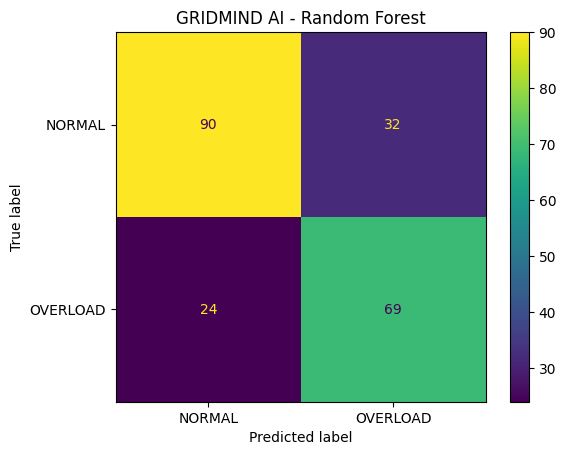


Gradient Boosting Confusion Matrix:
[[93 29]
 [20 73]]


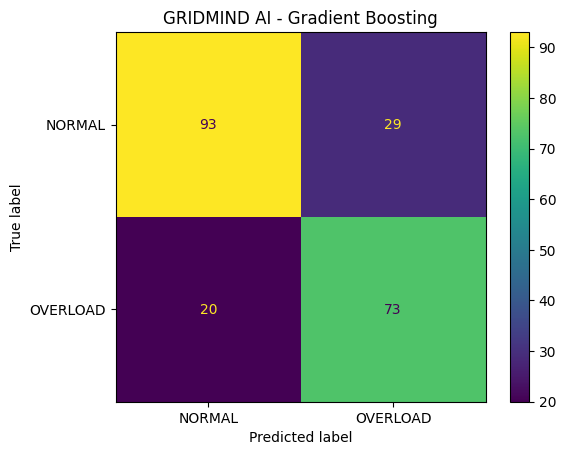


STEP 13D COMPLETED SUCCESSFULLY
Final model: Gradient Boosting
Final F1 Score: 0.7487

Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_FINAL_MODEL_COMPARISON.csv


In [76]:
# ============================================================
# STEP 13D - FINAL ML MODEL COMPARISON
# FIXED VERSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 75)
print("GRIDMIND AI - FINAL ML MODEL COMPARISON")
print("=" * 75)


# ------------------------------------------------------------
# 1. CHECK DATA
# ------------------------------------------------------------

required = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "forecast_model"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing objects: " + ", ".join(missing)
    )

if y_train.nunique() < 2:
    raise RuntimeError(
        "Training data contains only one class. "
        "Run Step 13B again and create more overload events."
    )

print("\n✅ Training and testing data found.")


# ------------------------------------------------------------
# 2. TRAIN GRADIENT BOOSTING
# ------------------------------------------------------------

print("\nTraining Gradient Boosting model...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

# Balance the training classes
class_counts = y_train.value_counts()

sample_weights = y_train.map(
    lambda label: 1.0 / class_counts[label]
).values

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("✅ Gradient Boosting training completed.")


# ------------------------------------------------------------
# 3. EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(name, model, X, y):

    predictions = model.predict(X)

    probability_matrix = model.predict_proba(X)

    classes = list(model.classes_)

    if 1 in classes:

        overload_index = classes.index(1)

        overload_probability = (
            probability_matrix[:, overload_index]
        )

    else:

        overload_probability = np.zeros(len(y))

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y,
            predictions,
            zero_division=0
        )
    }

    if y.nunique() == 2:

        result["ROC_AUC"] = roc_auc_score(
            y,
            overload_probability
        )

        result["PR_AUC"] = average_precision_score(
            y,
            overload_probability
        )

    else:

        result["ROC_AUC"] = np.nan
        result["PR_AUC"] = np.nan

    return (
        result,
        predictions,
        overload_probability
    )


# ------------------------------------------------------------
# 4. RANDOM FOREST
# ------------------------------------------------------------

rf_result, rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    forecast_model,
    X_test,
    y_test
)


# ------------------------------------------------------------
# 5. GRADIENT BOOSTING
# ------------------------------------------------------------

gb_result, gb_pred, gb_prob = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_test,
    y_test
)


# ------------------------------------------------------------
# 6. COMPARISON
# ------------------------------------------------------------

model_comparison = pd.DataFrame([
    rf_result,
    gb_result
])

print("\n" + "=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

display(
    model_comparison.round(4)
)


# ------------------------------------------------------------
# 7. RANDOM FOREST REPORT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RANDOM FOREST REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 8. GRADIENT BOOSTING REPORT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("GRADIENT BOOSTING REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        gb_pred,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 9. CONFUSION MATRIX - RANDOM FOREST
# ------------------------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=[0, 1]
)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
)

disp_rf.plot()

plt.title(
    "GRIDMIND AI - Random Forest"
)

plt.show()


# ------------------------------------------------------------
# 10. CONFUSION MATRIX - GRADIENT BOOSTING
# ------------------------------------------------------------

cm_gb = confusion_matrix(
    y_test,
    gb_pred,
    labels=[0, 1]
)

print("\nGradient Boosting Confusion Matrix:")
print(cm_gb)

disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
)

disp_gb.plot()

plt.title(
    "GRIDMIND AI - Gradient Boosting"
)

plt.show()


# ------------------------------------------------------------
# 11. SELECT MODEL
# ------------------------------------------------------------

if gb_result["F1"] > rf_result["F1"]:

    final_forecast_model = gb_model
    final_model_name = "Gradient Boosting"
    final_prediction = gb_pred
    final_overload_probability = gb_prob

else:

    final_forecast_model = forecast_model
    final_model_name = "Random Forest"
    final_prediction = rf_pred
    final_overload_probability = rf_prob


# ------------------------------------------------------------
# 12. GET FINAL F1 SCORE
# ------------------------------------------------------------

selected_row = model_comparison[
    model_comparison["Model"] == final_model_name
]

final_f1 = float(
    selected_row["F1"].iloc[0]
)


# ------------------------------------------------------------
# 13. SAVE RESULTS
# ------------------------------------------------------------

output_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_FINAL_MODEL_COMPARISON.csv"
)

model_comparison.to_csv(
    output_path,
    index=False
)


# ------------------------------------------------------------
# 14. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 13D COMPLETED SUCCESSFULLY")
print("=" * 75)

print(
    "Final model:",
    final_model_name
)

print(
    f"Final F1 Score: {final_f1:.4f}"
)

print(
    "\nSaved:",
    output_path
)

In [77]:
# ============================================================
# STEP 13E - POWER SYSTEM FEATURE ENGINEERING
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("GRIDMIND AI - POWER SYSTEM FEATURE ENGINEERING")
print("=" * 75)


# ============================================================
# 1. CHECK DATA
# ============================================================

if "chronological_df" not in globals():
    raise RuntimeError(
        "chronological_df not found. Run Step 13B first."
    )

df = chronological_df.copy()

print(
    f"\nOriginal dataset size: {len(df)} rows"
)


# ============================================================
# 2. SORT CHRONOLOGICALLY
# ============================================================

df = df.sort_values(
    "hour_index"
).reset_index(
    drop=True
)


# ============================================================
# 3. CURRENT OPERATING FEATURES
# ============================================================

base_features = [
    "load_factor",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "solar_generation_mw",
    "max_line_loading_percent",
    "min_bus_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",
    "hour_of_day"
]


# ============================================================
# 4. LOAD TREND FEATURES
# ============================================================

df["total_load_mw"] = (
    df["residential_load_mw"]
    + df["industrial_load_mw"]
    + df["commercial_load_mw"]
)

df["load_change_mw"] = (
    df["total_load_mw"]
    .diff()
)

df["load_change_percent"] = (
    df["total_load_mw"]
    .pct_change()
    * 100
)


# ============================================================
# 5. SOLAR TREND
# ============================================================

df["solar_change_mw"] = (
    df["solar_generation_mw"]
    .diff()
)

df["solar_change_percent"] = (
    df["solar_generation_mw"]
    .pct_change()
    * 100
)


# ============================================================
# 6. GRID LOADING TREND
# ============================================================

df["line_loading_change"] = (
    df["max_line_loading_percent"]
    .diff()
)

df["transformer_loading_change"] = (
    df["transformer_loading_percent"]
    .diff()
)


# ============================================================
# 7. VOLTAGE TREND
# ============================================================

df["voltage_change_pu"] = (
    df["min_bus_voltage_pu"]
    .diff()
)


# ============================================================
# 8. ROLLING FEATURES
# ============================================================

df["rolling_load_3h"] = (
    df["total_load_mw"]
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

df["rolling_loading_3h"] = (
    df["max_line_loading_percent"]
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

df["rolling_voltage_3h"] = (
    df["min_bus_voltage_pu"]
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)


# ============================================================
# 9. LOADING MOMENTUM
# ============================================================

df["loading_acceleration"] = (
    df["line_loading_change"]
    .diff()
)


# ============================================================
# 10. TIME FEATURES
# ============================================================

df["hour_sin"] = np.sin(
    2 * np.pi *
    df["hour_of_day"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi *
    df["hour_of_day"] / 24
)


# ============================================================
# 11. SOLAR-TO-LOAD RATIO
# ============================================================

df["solar_load_ratio"] = (
    df["solar_generation_mw"]
    /
    df["total_load_mw"].replace(
        0,
        np.nan
    )
)


# ============================================================
# 12. TARGET
# ============================================================

target = "next_hour_overload"


# ============================================================
# 13. FINAL FEATURE LIST
# ============================================================

engineered_features = [
    # Current state
    "load_factor",
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "max_line_loading_percent",
    "min_bus_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",

    # Trends
    "load_change_mw",
    "load_change_percent",
    "solar_change_mw",
    "solar_change_percent",
    "line_loading_change",
    "transformer_loading_change",
    "voltage_change_pu",

    # Rolling behaviour
    "rolling_load_3h",
    "rolling_loading_3h",
    "rolling_voltage_3h",

    # Dynamic behaviour
    "loading_acceleration",

    # Time
    "hour_of_day",
    "hour_sin",
    "hour_cos",

    # Renewable penetration
    "solar_load_ratio"
]


# ============================================================
# 14. CLEAN DATA
# ============================================================

feature_df = df[
    [
        "day",
        "hour_index",
        target
    ]
    + engineered_features
].copy()

feature_df = feature_df.replace(
    [np.inf, -np.inf],
    np.nan
)

feature_df = feature_df.dropna(
    subset=engineered_features + [target]
).reset_index(
    drop=True
)


# ============================================================
# 15. TIME-AWARE TRAIN / TEST SPLIT
# ============================================================

feature_train_df = feature_df[
    feature_df["day"] <= 21
].copy()

feature_test_df = feature_df[
    feature_df["day"] > 21
].copy()


X_train_engineered = (
    feature_train_df[
        engineered_features
    ]
)

y_train_engineered = (
    feature_train_df[
        target
    ].astype(int)
)

X_test_engineered = (
    feature_test_df[
        engineered_features
    ]
)

y_test_engineered = (
    feature_test_df[
        target
    ].astype(int)
)


# ============================================================
# 16. VALIDATE TARGETS
# ============================================================

print("\n" + "=" * 75)
print("TARGET DISTRIBUTION")
print("=" * 75)

print("\nTraining:")

print(
    y_train_engineered
    .value_counts()
    .sort_index()
)

print("\nTesting:")

print(
    y_test_engineered
    .value_counts()
    .sort_index()
)


# ============================================================
# 17. DISPLAY FEATURE LIST
# ============================================================

print("\n" + "=" * 75)
print("ENGINEERED FEATURES")
print("=" * 75)

for i, feature in enumerate(
    engineered_features,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


# ============================================================
# 18. FEATURE DATASET PREVIEW
# ============================================================

print("\n" + "=" * 75)
print("FEATURE DATASET PREVIEW")
print("=" * 75)

display(
    feature_df[
        engineered_features
        + [target]
    ].head(10)
)


# ============================================================
# 19. SAVE FEATURE DATASET
# ============================================================

feature_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_ENGINEERED_FEATURE_DATASET.csv"
)

feature_df.to_csv(
    feature_path,
    index=False
)

print(
    "\n✅ STEP 13E COMPLETED"
)

print(
    "Engineered features:",
    len(engineered_features)
)

print(
    "Saved:",
    feature_path
)


GRIDMIND AI - POWER SYSTEM FEATURE ENGINEERING

Original dataset size: 719 rows

TARGET DISTRIBUTION

Training:
next_hour_overload
0    201
1     51
Name: count, dtype: int64

Testing:
next_hour_overload
0    46
1    62
Name: count, dtype: int64

ENGINEERED FEATURES
01. load_factor
02. residential_load_mw
03. industrial_load_mw
04. commercial_load_mw
05. total_load_mw
06. solar_generation_mw
07. max_line_loading_percent
08. min_bus_voltage_pu
09. transformer_loading_percent
10. line_losses_mw
11. load_change_mw
12. load_change_percent
13. solar_change_mw
14. solar_change_percent
15. line_loading_change
16. transformer_loading_change
17. voltage_change_pu
18. rolling_load_3h
19. rolling_loading_3h
20. rolling_voltage_3h
21. loading_acceleration
22. hour_of_day
23. hour_sin
24. hour_cos
25. solar_load_ratio

FEATURE DATASET PREVIEW


,load_factor,residential_load_mw,industrial_load_mw,commercial_load_mw,total_load_mw,solar_generation_mw,max_line_loading_percent,min_bus_voltage_pu,transformer_loading_percent,line_losses_mw,...,voltage_change_pu,rolling_load_3h,rolling_loading_3h,rolling_voltage_3h,loading_acceleration,hour_of_day,hour_sin,hour_cos,solar_load_ratio,next_hour_overload
0,1.178921,2.514526,6.785818,3.525692,12.826036,0.815331,51.864308,0.967035,31.983305,0.133754,...,-0.004555,12.153037,48.727041,0.968088,26.235413,8,8.660254e-01,-0.500000,0.063568,0.0
1,1.128101,2.120789,5.368864,3.711672,11.201325,1.366046,41.433679,0.970956,26.515682,0.088661,...,0.003920,11.249197,44.426630,0.969860,-22.313033,9,7.071068e-01,-0.707107,0.121954,0.0
2,1.127250,2.235976,6.155831,3.161765,11.553571,1.291784,47.187617,0.969021,27.618040,0.106435,...,-0.001935,11.860311,46.828534,0.969004,16.184567,10,5.000000e-01,-0.866025,0.111808,0.0
3,1.044707,2.116675,5.961358,3.318030,11.396063,1.780069,45.752149,0.969647,26.028158,0.098179,...,0.000626,11.383653,44.791148,0.969874,-7.189407,11,2.588190e-01,-0.965926,0.156200,0.0
4,0.962369,1.744127,5.096606,2.753278,9.594011,1.726823,39.442865,0.972078,21.761018,0.071721,...,0.002431,10.847882,44.127544,0.970248,-4.873815,12,1.224647e-16,-1.000000,0.179990,0.0
5,1.073687,1.957677,5.477662,3.135376,10.570715,1.863786,42.211210,0.970999,23.793862,0.083348,...,-0.001079,10.520263,42.468741,0.970908,9.077629,13,-2.588190e-01,-0.965926,0.176316,0.0
6,1.057482,2.184467,5.560222,3.500810,11.245499,1.328118,42.825617,0.970494,26.730061,0.092664,...,-0.000505,10.470075,41.493231,0.971190,-2.153939,14,-5.000000e-01,-0.866025,0.118102,0.0
7,0.697890,1.457852,3.717900,1.968714,7.144467,1.273383,29.656193,0.975617,17.050235,0.042468,...,0.005123,9.653560,38.231007,0.972370,-13.783830,15,-7.071068e-01,-0.707107,0.178233,0.0
8,0.850680,1.683038,4.445887,2.489203,8.618128,0.952113,34.780595,0.973600,21.238052,0.059918,...,-0.002017,9.002698,35.754135,0.973237,18.293826,16,-8.660254e-01,-0.500000,0.110478,0.0
9,1.088796,2.011227,6.480922,3.681695,12.173844,0.507225,49.602477,0.967864,31.099958,0.123236,...,-0.005737,9.312146,38.013088,0.972360,9.697479,17,-9.659258e-01,-0.258819,0.041665,0.0



✅ STEP 13E COMPLETED
Engineered features: 25
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_ENGINEERED_FEATURE_DATASET.csv


GRIDMIND AI - ENGINEERED FEATURE ML MODELS

TRAINING TARGET
--------------------------------------------------
next_hour_overload
0    201
1     51
Name: count, dtype: int64

TEST TARGET
--------------------------------------------------
next_hour_overload
0    46
1    62
Name: count, dtype: int64

---------------------------------------------------------------------------
TRAINING RANDOM FOREST
---------------------------------------------------------------------------
✅ Random Forest trained.

---------------------------------------------------------------------------
TRAINING GRADIENT BOOSTING
---------------------------------------------------------------------------
✅ Gradient Boosting trained.

ENGINEERED MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Engineered Random Forest,0.7130,0.7183,0.8226,0.7669,0.7479,0.7899
1,Engineered Gradient Boosting,0.7037,0.7344,0.7581,0.7460,0.7262,0.7838



ENGINEERED RANDOM FOREST
              precision    recall  f1-score   support

      NORMAL       0.70      0.57      0.63        46
    OVERLOAD       0.72      0.82      0.77        62

    accuracy                           0.71       108
   macro avg       0.71      0.69      0.70       108
weighted avg       0.71      0.71      0.71       108


ENGINEERED GRADIENT BOOSTING
              precision    recall  f1-score   support

      NORMAL       0.66      0.63      0.64        46
    OVERLOAD       0.73      0.76      0.75        62

    accuracy                           0.70       108
   macro avg       0.70      0.69      0.70       108
weighted avg       0.70      0.70      0.70       108


Random Forest Confusion Matrix:
[[26 20]
 [11 51]]


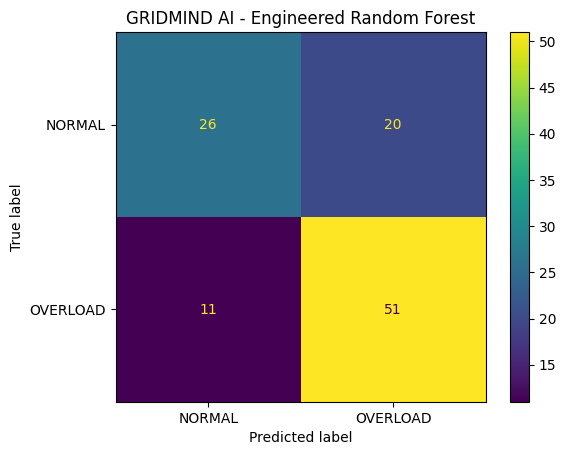


Gradient Boosting Confusion Matrix:
[[29 17]
 [15 47]]


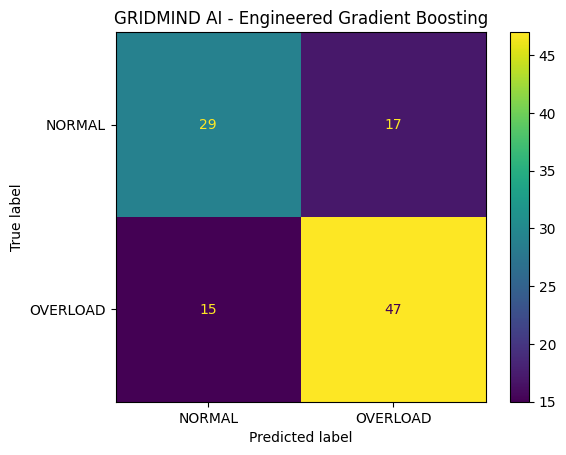


TOP POWER-SYSTEM FEATURES


,Feature,Importance
0,total_load_mw,0.171348
1,transformer_loading_percent,0.126670
2,line_losses_mw,0.116010
3,load_factor,0.085251
4,min_bus_voltage_pu,0.082846
5,max_line_loading_percent,0.070949
6,rolling_loading_3h,0.058811
7,industrial_load_mw,0.052587
8,rolling_voltage_3h,0.048779
9,residential_load_mw,0.043517


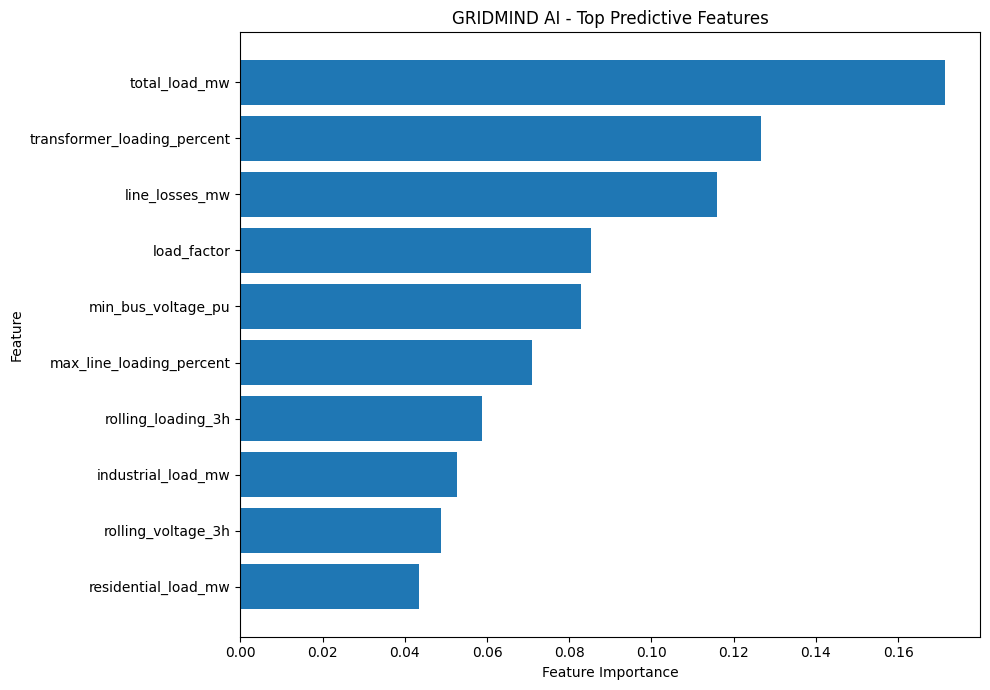


STEP 13F COMPLETED
Selected model: Engineered Random Forest
Final F1 Score: 0.7669

Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_ENGINEERED_MODEL_COMPARISON.csv


In [78]:
# ============================================================
# STEP 13F - TRAIN ML MODELS WITH ENGINEERED FEATURES
# GRIDMIND AI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 75)
print("GRIDMIND AI - ENGINEERED FEATURE ML MODELS")
print("=" * 75)


# ============================================================
# 1. CHECK ENGINEERED DATA
# ============================================================

required = [
    "X_train_engineered",
    "y_train_engineered",
    "X_test_engineered",
    "y_test_engineered"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing: "
        + ", ".join(missing)
        + "\nRun Step 13E first."
    )


# ============================================================
# 2. CHECK TARGET CLASSES
# ============================================================

print("\nTRAINING TARGET")
print("-" * 50)

print(
    y_train_engineered
    .value_counts()
    .sort_index()
)

print("\nTEST TARGET")
print("-" * 50)

print(
    y_test_engineered
    .value_counts()
    .sort_index()
)

if y_train_engineered.nunique() < 2:

    raise RuntimeError(
        "Training data contains only one class. "
        "More overload events are required."
    )


# ============================================================
# 3. TRAIN RANDOM FOREST
# ============================================================

print("\n" + "-" * 75)
print("TRAINING RANDOM FOREST")
print("-" * 75)

engineered_rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=14,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

engineered_rf.fit(
    X_train_engineered,
    y_train_engineered
)

print("✅ Random Forest trained.")


# ============================================================
# 4. TRAIN GRADIENT BOOSTING
# ============================================================

print("\n" + "-" * 75)
print("TRAINING GRADIENT BOOSTING")
print("-" * 75)

engineered_gb = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

# Balance the classes
class_counts = (
    y_train_engineered
    .value_counts()
)

sample_weights = (
    y_train_engineered
    .map(
        lambda label:
        1.0 / class_counts[label]
    )
    .values
)

engineered_gb.fit(
    X_train_engineered,
    y_train_engineered,
    sample_weight=sample_weights
)

print("✅ Gradient Boosting trained.")


# ============================================================
# 5. EVALUATION FUNCTION
# ============================================================

def evaluate_engineered_model(
    name,
    model,
    X,
    y
):

    predictions = model.predict(X)

    probabilities = model.predict_proba(X)

    classes = list(
        model.classes_
    )

    if 1 in classes:

        overload_index = (
            classes.index(1)
        )

        overload_probability = (
            probabilities[
                :,
                overload_index
            ]
        )

    else:

        overload_probability = np.zeros(
            len(y)
        )

    result = {
        "Model": name,

        "Accuracy": accuracy_score(
            y,
            predictions
        ),

        "Precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y,
            predictions,
            zero_division=0
        )
    }

    if y.nunique() == 2:

        result["ROC_AUC"] = (
            roc_auc_score(
                y,
                overload_probability
            )
        )

        result["PR_AUC"] = (
            average_precision_score(
                y,
                overload_probability
            )
        )

    else:

        result["ROC_AUC"] = np.nan
        result["PR_AUC"] = np.nan

    return (
        result,
        predictions,
        overload_probability
    )


# ============================================================
# 6. EVALUATE RANDOM FOREST
# ============================================================

rf_result, rf_pred_engineered, rf_prob_engineered = (
    evaluate_engineered_model(
        "Engineered Random Forest",
        engineered_rf,
        X_test_engineered,
        y_test_engineered
    )
)


# ============================================================
# 7. EVALUATE GRADIENT BOOSTING
# ============================================================

gb_result, gb_pred_engineered, gb_prob_engineered = (
    evaluate_engineered_model(
        "Engineered Gradient Boosting",
        engineered_gb,
        X_test_engineered,
        y_test_engineered
    )
)


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

engineered_comparison = pd.DataFrame([
    rf_result,
    gb_result
])

print("\n" + "=" * 75)
print("ENGINEERED MODEL PERFORMANCE")
print("=" * 75)

display(
    engineered_comparison.round(4)
)


# ============================================================
# 9. RANDOM FOREST REPORT
# ============================================================

print("\n" + "=" * 75)
print("ENGINEERED RANDOM FOREST")
print("=" * 75)

print(
    classification_report(
        y_test_engineered,
        rf_pred_engineered,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 10. GRADIENT BOOSTING REPORT
# ============================================================

print("\n" + "=" * 75)
print("ENGINEERED GRADIENT BOOSTING")
print("=" * 75)

print(
    classification_report(
        y_test_engineered,
        gb_pred_engineered,
        labels=[0, 1],
        target_names=[
            "NORMAL",
            "OVERLOAD"
        ],
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(
    y_test_engineered,
    rf_pred_engineered,
    labels=[0, 1]
)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
).plot()

plt.title(
    "GRIDMIND AI - Engineered Random Forest"
)

plt.show()


# ============================================================
# 12. CONFUSION MATRIX - GRADIENT BOOSTING
# ============================================================

cm_gb = confusion_matrix(
    y_test_engineered,
    gb_pred_engineered,
    labels=[0, 1]
)

print("\nGradient Boosting Confusion Matrix:")
print(cm_gb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=[
        "NORMAL",
        "OVERLOAD"
    ]
).plot()

plt.title(
    "GRIDMIND AI - Engineered Gradient Boosting"
)

plt.show()


# ============================================================
# 13. SELECT MODEL
# ============================================================

if (
    gb_result["F1"]
    >
    rf_result["F1"]
):

    final_forecast_model = (
        engineered_gb
    )

    final_model_name = (
        "Engineered Gradient Boosting"
    )

    final_prediction = (
        gb_pred_engineered
    )

    final_overload_probability = (
        gb_prob_engineered
    )

else:

    final_forecast_model = (
        engineered_rf
    )

    final_model_name = (
        "Engineered Random Forest"
    )

    final_prediction = (
        rf_pred_engineered
    )

    final_overload_probability = (
        rf_prob_engineered
    )


# ============================================================
# 14. FINAL MODEL SCORE
# ============================================================

selected_row = engineered_comparison[
    engineered_comparison["Model"]
    == final_model_name
]

final_f1 = float(
    selected_row["F1"].iloc[0]
)


# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

if hasattr(
    final_forecast_model,
    "feature_importances_"
):

    feature_importance = pd.DataFrame({

        "Feature":
            X_train_engineered.columns,

        "Importance":
            final_forecast_model
            .feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 75)
    print("TOP POWER-SYSTEM FEATURES")
    print("=" * 75)

    display(
        feature_importance.head(15)
    )

    plt.figure(
        figsize=(10, 7)
    )

    top_features = (
        feature_importance
        .head(10)
        .sort_values(
            "Importance"
        )
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel(
        "Feature Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "GRIDMIND AI - Top Predictive Features"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 16. SAVE FINAL MODEL RESULTS
# ============================================================

comparison_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_ENGINEERED_MODEL_COMPARISON.csv"
)

engineered_comparison.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 17. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("STEP 13F COMPLETED")
print("=" * 75)

print(
    "Selected model:",
    final_model_name
)

print(
    f"Final F1 Score: {final_f1:.4f}"
)

print(
    "\nSaved:",
    comparison_path
)

In [79]:
# ============================================================
# STEP 14 - GRIDMIND AI PREDICTIVE SELF-HEALING
# ============================================================

import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 75)
print("GRIDMIND AI - PREDICTIVE SELF-HEALING")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED OBJECTS
# ============================================================

required = [
    "final_forecast_model",
    "X_test_engineered",
    "y_test_engineered",
    "feature_test_df",
    "ts_net"
]

missing = [
    item for item in required
    if item not in globals()
]

if missing:
    raise RuntimeError(
        "Missing objects: "
        + ", ".join(missing)
        + "\nRun Step 13E and Step 13F first."
    )

print("\n✅ ML model and grid data found.")


# ============================================================
# 2. PREDICT NEXT-HOUR OVERLOAD RISK
# ============================================================

probability_matrix = (
    final_forecast_model.predict_proba(
        X_test_engineered
    )
)

classes = list(
    final_forecast_model.classes_
)

if 1 not in classes:
    raise RuntimeError(
        "The final model does not contain an OVERLOAD class."
    )

overload_index = classes.index(1)

overload_probability = (
    probability_matrix[
        :,
        overload_index
    ]
)


# ============================================================
# 3. FIND HIGHEST-RISK OPERATING HOUR
# ============================================================

highest_risk_index = int(
    np.argmax(
        overload_probability
    )
)

highest_probability = float(
    overload_probability[
        highest_risk_index
    ]
)

risk_row = feature_test_df.iloc[
    highest_risk_index
].copy()

print("\n" + "=" * 75)
print("AI FORECAST")
print("=" * 75)

print(
    f"Forecast day       : "
    f"{int(risk_row['day'])}"
)

print(
    f"Forecast hour      : "
    f"{int(risk_row['hour_index'])}"
)

print(
    f"Current hour       : "
    f"{int(risk_row['hour_of_day'])}:00"
)

print(
    f"Overload probability: "
    f"{highest_probability * 100:.2f}%"
)


# ============================================================
# 4. CLASSIFY RISK
# ============================================================

if highest_probability >= 0.75:

    risk_level = "CRITICAL"

elif highest_probability >= 0.50:

    risk_level = "HIGH"

elif highest_probability >= 0.25:

    risk_level = "MODERATE"

else:

    risk_level = "LOW"


print(
    f"Risk level         : "
    f"{risk_level}"
)


# ============================================================
# 5. RECREATE THE PREDICTED OPERATING CONDITION
# ============================================================

print("\n" + "=" * 75)
print("RECREATING PREDICTED GRID CONDITION")
print("=" * 75)

healing_net = copy.deepcopy(
    ts_net
)


# Current-hour loads from the selected
# forecasting sample

healing_net.load.loc[
    ts_res_load,
    "p_mw"
] = float(
    risk_row[
        "residential_load_mw"
    ]
)

healing_net.load.loc[
    ts_ind_load,
    "p_mw"
] = float(
    risk_row[
        "industrial_load_mw"
    ]
)

healing_net.load.loc[
    ts_com_load,
    "p_mw"
] = float(
    risk_row[
        "commercial_load_mw"
    ]
)

healing_net.sgen.loc[
    ts_solar,
    "p_mw"
] = float(
    risk_row[
        "solar_generation_mw"
    ]
)


# ============================================================
# 6. POWER FLOW BEFORE SELF-HEALING
# ============================================================

pp.runpp(
    healing_net,
    max_iteration=100
)

before_loading = (
    healing_net
    .res_line
    .loading_percent
    .copy()
)

before_voltage = (
    healing_net
    .res_bus
    .vm_pu
    .copy()
)

before_trafo = (
    healing_net
    .res_trafo
    .loading_percent
    .copy()
)

print(
    f"Maximum line loading : "
    f"{before_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{before_voltage.min():.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{before_trafo.max():.2f}%"
)


# ============================================================
# 7. IDENTIFY CRITICAL FEEDER
# ============================================================

feeder_map = {

    ts_res_line: (
        "Residential Feeder",
        ts_res_load
    ),

    ts_ind_line: (
        "Industrial Feeder",
        ts_ind_load
    ),

    ts_com_line: (
        "Commercial Feeder",
        ts_com_load
    )
}

critical_line = int(
    before_loading.idxmax()
)

if critical_line in feeder_map:

    critical_feeder = (
        feeder_map[
            critical_line
        ][0]
    )

    critical_load_index = (
        feeder_map[
            critical_line
        ][1]
    )

else:

    critical_feeder = (
        f"Line {critical_line}"
    )

    critical_load_index = None


critical_loading = float(
    before_loading.loc[
        critical_line
    ]
)

print(
    f"\nCritical feeder    : "
    f"{critical_feeder}"
)

print(
    f"Critical loading   : "
    f"{critical_loading:.2f}%"
)


# ============================================================
# 8. AI SELF-HEALING DECISION
# ============================================================

print("\n" + "=" * 75)
print("AI SELF-HEALING DECISION")
print("=" * 75)


action_taken = "NO ACTION"

if (
    highest_probability >= 0.50
    or critical_loading >= 100
):

    if critical_load_index is not None:

        original_load = float(
            healing_net.load.loc[
                critical_load_index,
                "p_mw"
            ]
        )

        # Simulated demand-side corrective action
        new_load = (
            original_load * 0.70
        )

        healing_net.load.loc[
            critical_load_index,
            "p_mw"
        ] = new_load

        action_taken = (
            "Predictive load management"
        )

        print(
            "🚨 AI detected elevated grid risk."
        )

        print(
            f"Feeder: {critical_feeder}"
        )

        print(
            f"Load before: "
            f"{original_load:.3f} MW"
        )

        print(
            f"Load after : "
            f"{new_load:.3f} MW"
        )

    else:

        action_taken = (
            "Critical feeder detected, "
            "but no control mapping available"
        )

        print(
            "⚠️ No predefined control available."
        )

else:

    print(
        "🟢 No self-healing action required."
    )


# ============================================================
# 9. RE-RUN POWER FLOW
# ============================================================

print("\n" + "=" * 75)
print("POST SELF-HEALING POWER FLOW")
print("=" * 75)

pp.runpp(
    healing_net,
    max_iteration=100
)

after_loading = (
    healing_net
    .res_line
    .loading_percent
    .copy()
)

after_voltage = (
    healing_net
    .res_bus
    .vm_pu
    .copy()
)

after_trafo = (
    healing_net
    .res_trafo
    .loading_percent
    .copy()
)


# ============================================================
# 10. CALCULATE IMPROVEMENT
# ============================================================

before_max_loading = float(
    before_loading.max()
)

after_max_loading = float(
    after_loading.max()
)

loading_reduction = (
    before_max_loading
    - after_max_loading
)

before_min_voltage = float(
    before_voltage.min()
)

after_min_voltage = float(
    after_voltage.min()
)

voltage_change = (
    after_min_voltage
    - before_min_voltage
)

before_max_trafo = float(
    before_trafo.max()
)

after_max_trafo = float(
    after_trafo.max()
)


# ============================================================
# 11. SAFETY VERIFICATION
# ============================================================

line_safe = (
    after_max_loading < 100
)

voltage_safe = (
    after_min_voltage >= 0.95
)

transformer_safe = (
    after_max_trafo < 100
)

grid_safe = (
    line_safe
    and voltage_safe
    and transformer_safe
)


# ============================================================
# 12. FINAL RESULT
# ============================================================

print(
    f"Maximum line loading BEFORE : "
    f"{before_max_loading:.2f}%"
)

print(
    f"Maximum line loading AFTER  : "
    f"{after_max_loading:.2f}%"
)

print(
    f"Loading reduction           : "
    f"{loading_reduction:.2f}%"
)

print(
    f"\nMinimum voltage BEFORE     : "
    f"{before_min_voltage:.4f} pu"
)

print(
    f"Minimum voltage AFTER      : "
    f"{after_min_voltage:.4f} pu"
)

print(
    f"Voltage change              : "
    f"{voltage_change:+.4f} pu"
)

print(
    f"\nTransformer BEFORE         : "
    f"{before_max_trafo:.2f}%"
)

print(
    f"Transformer AFTER          : "
    f"{after_max_trafo:.2f}%"
)


# ============================================================
# 13. FINAL GRID STATUS
# ============================================================

if grid_safe:

    final_status = (
        "SAFE AFTER SELF-HEALING"
    )

else:

    final_status = (
        "ATTENTION REQUIRED"
    )


print("\n" + "=" * 75)
print("GRIDMIND AI - SELF-HEALING RESULT")
print("=" * 75)

print(
    f"AI Risk Level      : {risk_level}"
)

print(
    f"Overload Probability: "
    f"{highest_probability * 100:.2f}%"
)

print(
    f"Critical Feeder    : "
    f"{critical_feeder}"
)

print(
    f"AI Action          : "
    f"{action_taken}"
)

print(
    f"Final Grid Status  : "
    f"{final_status}"
)


# ============================================================
# 14. CREATE SELF-HEALING REPORT
# ============================================================

self_healing_report = pd.DataFrame({

    "Forecast_Day": [
        int(risk_row["day"])
    ],

    "Forecast_Hour": [
        int(risk_row["hour_of_day"])
    ],

    "Overload_Probability_%": [
        highest_probability * 100
    ],

    "Risk_Level": [
        risk_level
    ],

    "Critical_Feeder": [
        critical_feeder
    ],

    "Maximum_Line_Loading_Before_%": [
        before_max_loading
    ],

    "Maximum_Line_Loading_After_%": [
        after_max_loading
    ],

    "Loading_Reduction_%": [
        loading_reduction
    ],

    "Minimum_Voltage_Before_pu": [
        before_min_voltage
    ],

    "Minimum_Voltage_After_pu": [
        after_min_voltage
    ],

    "Transformer_Loading_Before_%": [
        before_max_trafo
    ],

    "Transformer_Loading_After_%": [
        after_max_trafo
    ],

    "AI_Action": [
        action_taken
    ],

    "Grid_Safe_After_Action": [
        grid_safe
    ],

    "Final_Status": [
        final_status
    ]
})


# ============================================================
# 15. SAVE REPORT
# ============================================================

output_path = (
    "/content/GRIDMIND_AI_OUTPUT/"
    "GRIDMIND_PREDICTIVE_SELF_HEALING_REPORT.csv"
)

self_healing_report.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 75)
print("✅ STEP 14 COMPLETED")
print("=" * 75)

print(
    "Saved:",
    output_path
)

display(
    self_healing_report
)

GRIDMIND AI - PREDICTIVE SELF-HEALING

✅ ML model and grid data found.

AI FORECAST
Forecast day       : 22
Forecast hour      : 523
Current hour       : 19:00
Overload probability: 99.74%
Risk level         : CRITICAL

RECREATING PREDICTED GRID CONDITION
Maximum line loading : 156.79%
Minimum bus voltage  : 0.9147 pu
Transformer loading  : 108.65%

Critical feeder    : Industrial Feeder
Critical loading   : 156.79%

AI SELF-HEALING DECISION
🚨 AI detected elevated grid risk.
Feeder: Industrial Feeder
Load before: 19.816 MW
Load after : 13.871 MW

POST SELF-HEALING POWER FLOW
Maximum line loading BEFORE : 156.79%
Maximum line loading AFTER  : 107.45%
Loading reduction           : 49.35%

Minimum voltage BEFORE     : 0.9147 pu
Minimum voltage AFTER      : 0.9371 pu
Voltage change              : +0.0224 pu

Transformer BEFORE         : 108.65%
Transformer AFTER          : 91.17%

GRIDMIND AI - SELF-HEALING RESULT
AI Risk Level      : CRITICAL
Overload Probability: 99.74%
Critical Feeder  

,Forecast_Day,Forecast_Hour,Overload_Probability_%,Risk_Level,Critical_Feeder,Maximum_Line_Loading_Before_%,Maximum_Line_Loading_After_%,Loading_Reduction_%,Minimum_Voltage_Before_pu,Minimum_Voltage_After_pu,Transformer_Loading_Before_%,Transformer_Loading_After_%,AI_Action,Grid_Safe_After_Action,Final_Status
0,22,19,99.743498,CRITICAL,Industrial Feeder,156.791972,107.446588,49.345384,0.914714,0.937127,108.648169,91.17054,Predictive load management,False,ATTENTION REQUIRED


In [80]:
# ============================================================
# STEP 15 - AUTOMATIC FEEDER LOAD TRANSFER
# GRIDMIND AI
# ============================================================

import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("=" * 75)
print("GRIDMIND AI - AUTOMATIC FEEDER LOAD TRANSFER")
print("=" * 75)


# ============================================================
# 1. CHECK NETWORK
# ============================================================

if "ts_net" not in globals():
    raise RuntimeError(
        "ts_net not found. Run the time-series network setup first."
    )

print("\n✅ GRIDMIND network found.")


# ============================================================
# 2. CREATE INDEPENDENT TEST NETWORK
# ============================================================

transfer_net = copy.deepcopy(ts_net)


# ============================================================
# 3. FEEDER MAP
# ============================================================

feeder_map = {

    ts_res_line: {
        "name": "Residential Feeder",
        "load": ts_res_load
    },

    ts_ind_line: {
        "name": "Industrial Feeder",
        "load": ts_ind_load
    },

    ts_com_line: {
        "name": "Commercial Feeder",
        "load": ts_com_load
    }
}


# ============================================================
# 4. CREATE STRESSED GRID CONDITION
# ============================================================

transfer_net.load.loc[
    ts_res_load,
    "p_mw"
] = 4.0

transfer_net.load.loc[
    ts_ind_load,
    "p_mw"
] = 10.0

transfer_net.load.loc[
    ts_com_load,
    "p_mw"
] = 6.0

transfer_net.sgen.loc[
    ts_solar,
    "p_mw"
] = 0.5


# ============================================================
# 5. POWER FLOW BEFORE TRANSFER
# ============================================================

pp.runpp(
    transfer_net,
    max_iteration=100
)

before_loading = (
    transfer_net
    .res_line
    .loading_percent
    .copy()
)

before_voltage = (
    transfer_net
    .res_bus
    .vm_pu
    .copy()
)

print("\n" + "=" * 75)
print("INITIAL GRID CONDITION")
print("=" * 75)

print(
    f"Maximum line loading : "
    f"{before_loading.max():.2f}%"
)

print(
    f"Minimum bus voltage  : "
    f"{before_voltage.min():.4f} pu"
)


# ============================================================
# 6. DISPLAY FEEDER LOADING
# ============================================================

feeder_status = []

for line_idx, info in feeder_map.items():

    loading = float(
        before_loading.loc[line_idx]
    )

    feeder_status.append({

        "Feeder": info["name"],

        "Line_Index": line_idx,

        "Loading_%": loading
    })


feeder_status_df = pd.DataFrame(
    feeder_status
)

feeder_status_df = (
    feeder_status_df
    .sort_values(
        "Loading_%",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nFEEDER STATUS")
print("-" * 50)

display(
    feeder_status_df
)


# ============================================================
# 7. IDENTIFY CRITICAL FEEDER
# ============================================================

critical_line = int(
    feeder_status_df
    .iloc[0]["Line_Index"]
)

critical_feeder = (
    feeder_status_df
    .iloc[0]["Feeder"]
)

critical_load_idx = (
    feeder_map[
        critical_line
    ]["load"]
)

critical_loading = float(
    feeder_status_df
    .iloc[0]["Loading_%"]
)


# ============================================================
# 8. IDENTIFY HEALTHIEST FEEDER
# ============================================================

healthy_candidates = (
    feeder_status_df[
        feeder_status_df["Line_Index"]
        != critical_line
    ]
)

healthy_line = int(
    healthy_candidates
    .iloc[-1]["Line_Index"]
)

healthy_feeder = (
    healthy_candidates
    .iloc[-1]["Feeder"]
)

healthy_load_idx = (
    feeder_map[
        healthy_line
    ]["load"]
)

healthy_loading = float(
    healthy_candidates
    .iloc[-1]["Loading_%"]
)


print("\n" + "=" * 75)
print("FEEDER SELECTION")
print("=" * 75)

print(
    f"Critical feeder : "
    f"{critical_feeder}"
)

print(
    f"Critical loading: "
    f"{critical_loading:.2f}%"
)

print(
    f"Transfer target : "
    f"{healthy_feeder}"
)

print(
    f"Target loading  : "
    f"{healthy_loading:.2f}%"
)


# ============================================================
# 9. STORE ORIGINAL LOADS
# ============================================================

critical_p_original = float(
    transfer_net
    .load
    .loc[
        critical_load_idx,
        "p_mw"
    ]
)

critical_q_original = float(
    transfer_net
    .load
    .loc[
        critical_load_idx,
        "q_mvar"
    ]
)

healthy_p_original = float(
    transfer_net
    .load
    .loc[
        healthy_load_idx,
        "p_mw"
    ]
)

healthy_q_original = float(
    transfer_net
    .load
    .loc[
        healthy_load_idx,
        "q_mvar"
    ]
)


# ============================================================
# 10. AUTOMATIC TRANSFER SEARCH
# ============================================================

print("\n" + "=" * 75)
print("SEARCHING FOR SAFE LOAD-TRANSFER LEVEL")
print("=" * 75)

transfer_percentages = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

successful_transfer = None
best_candidate_net = None
best_candidate_results = None


for transfer_fraction in transfer_percentages:

    candidate = copy.deepcopy(
        transfer_net
    )

    # Load being transferred
    transferred_p = (
        critical_p_original
        * transfer_fraction
    )

    transferred_q = (
        critical_q_original
        * transfer_fraction
    )

    # Reduce critical feeder load
    candidate.load.loc[
        critical_load_idx,
        "p_mw"
    ] = (
        critical_p_original
        - transferred_p
    )

    candidate.load.loc[
        critical_load_idx,
        "q_mvar"
    ] = (
        critical_q_original
        - transferred_q
    )

    # Increase healthy feeder load
    candidate.load.loc[
        healthy_load_idx,
        "p_mw"
    ] = (
        healthy_p_original
        + transferred_p
    )

    candidate.load.loc[
        healthy_load_idx,
        "q_mvar"
    ] = (
        healthy_q_original
        + transferred_q
    )

    try:

        pp.runpp(
            candidate,
            max_iteration=100
        )

        max_loading = float(
            candidate
            .res_line
            .loading_percent
            .max()
        )

        min_voltage = float(
            candidate
            .res_bus
            .vm_pu
            .min()
        )

        if (
            max_loading < 100
            and min_voltage >= 0.95
        ):

            successful_transfer = (
                transfer_fraction
            )

            best_candidate_net = candidate

            best_candidate_results = (
                max_loading,
                min_voltage
            )

            break

    except Exception:

        continue


# ============================================================
# 11. APPLY BEST TRANSFER
# ============================================================

if successful_transfer is not None:

    transfer_net = best_candidate_net

    max_loading_after = (
        best_candidate_results[0]
    )

    min_voltage_after = (
        best_candidate_results[1]
    )

    action_status = "SUCCESS"

    transferred_load_mw = (
        critical_p_original
        * successful_transfer
    )

    print(
        "\n✅ SAFE TRANSFER FOUND"
    )

    print(
        f"Transfer percentage: "
        f"{successful_transfer * 100:.0f}%"
    )

    print(
        f"Transferred load: "
        f"{transferred_load_mw:.3f} MW"
    )

else:

    action_status = (
        "NO SAFE TRANSFER FOUND"
    )

    transferred_load_mw = 0.0

    max_loading_after = float(
        before_loading.max()
    )

    min_voltage_after = float(
        before_voltage.min()
    )

    print(
        "\n⚠️ No safe load-transfer level "
        "was found."
    )


# ============================================================
# 12. FINAL FEEDER RESULTS
# ============================================================

after_loading = (
    transfer_net
    .res_line
    .loading_percent
    .copy()
)

after_voltage = (
    transfer_net
    .res_bus
    .vm_pu
    .copy()
)


# ============================================================
# 13. CALCULATE IMPROVEMENT
# ============================================================

critical_before = float(
    before_loading.loc[
        critical_line
    ]
)

critical_after = float(
    after_loading.loc[
        critical_line
    ]
)

healthy_before = float(
    before_loading.loc[
        healthy_line
    ]
)

healthy_after = float(
    after_loading.loc[
        healthy_line
    ]
)

loading_reduction = (
    critical_before
    - critical_after
)


# ============================================================
# 14. DISPLAY BEFORE / AFTER
# ============================================================

comparison_rows = [

    {
        "Feeder": critical_feeder,
        "Before_%": critical_before,
        "After_%": critical_after
    },

    {
        "Feeder": healthy_feeder,
        "Before_%": healthy_before,
        "After_%": healthy_after
    }
]

transfer_comparison = pd.DataFrame(
    comparison_rows
)

transfer_comparison[
    "Change_%"
] = (
    transfer_comparison["After_%"]
    -
    transfer_comparison["Before_%"]
)

print("\n" + "=" * 75)
print("FEEDER LOADING AFTER LOAD TRANSFER")
print("=" * 75)

display(
    transfer_comparison
)


# ============================================================
# 15. FINAL GRID VERIFICATION
# ============================================================

final_max_loading = float(
    after_loading.max()
)

final_min_voltage = float(
    after_voltage.min()
)

grid_safe = (
    final_max_loading < 100
    and final_min_voltage >= 0.95
)


# ============================================================
# 16. FINAL RESULT
# ============================================================

print("\n" + "=" * 75)
print("GRIDMIND AI - RECONFIGURATION RESULT")
print("=" * 75)

print(
    f"Critical feeder       : "
    f"{critical_feeder}"
)

print(
    f"Transfer target       : "
    f"{healthy_feeder}"
)

print(
    f"Load transferred      : "
    f"{transferred_load_mw:.3f} MW"
)

print(
    f"Critical loading before: "
    f"{critical_before:.2f}%"
)

print(
    f"Critical loading after : "
    f"{critical_after:.2f}%"
)

print(
    f"Maximum loading after : "
    f"{final_max_loading:.2f}%"
)

print(
    f"Minimum voltage after : "
    f"{final_min_voltage:.4f} pu"
)

print(
    f"Transfer status        : "
    f"{action_status}"
)


if grid_safe:

    print(
        "\n✅ GRID STATUS: SAFE AFTER TRANSFER"
    )

else:

    print(
        "\n⚠️ GRID STATUS: ATTENTION REQUIRED"
    )


# ============================================================
# 17. SAVE REPORT
# ============================================================

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

transfer_report = pd.DataFrame({

    "Critical_Feeder": [
        critical_feeder
    ],

    "Transfer_Target": [
        healthy_feeder
    ],

    "Transfer_Percentage": [
        (
            successful_transfer * 100
            if successful_transfer is not None
            else 0
        )
    ],

    "Transferred_Load_MW": [
        transferred_load_mw
    ],

    "Critical_Loading_Before_%": [
        critical_before
    ],

    "Critical_Loading_After_%": [
        critical_after
    ],

    "Maximum_Loading_After_%": [
        final_max_loading
    ],

    "Minimum_Voltage_After_pu": [
        final_min_voltage
    ],

    "Grid_Safe": [
        grid_safe
    ],

    "Action_Status": [
        action_status
    ]
})

transfer_report_path = (
    output_dir
    + "/GRIDMIND_AUTOMATIC_LOAD_TRANSFER_REPORT.csv"
)

transfer_report.to_csv(
    transfer_report_path,
    index=False
)

print(
    "\n✅ STEP 15 COMPLETED"
)

print(
    "Saved:",
    transfer_report_path
)

display(
    transfer_report
)

GRIDMIND AI - AUTOMATIC FEEDER LOAD TRANSFER

✅ GRIDMIND network found.

INITIAL GRID CONDITION
Maximum line loading : 76.30%
Minimum bus voltage  : 0.9564 pu

FEEDER STATUS
--------------------------------------------------


,Feeder,Line_Index,Loading_%
0,Industrial Feeder,1,76.304054
1,Commercial Feeder,2,41.478363
2,Residential Feeder,0,30.069632



FEEDER SELECTION
Critical feeder : Industrial Feeder
Critical loading: 76.30%
Transfer target : Residential Feeder
Target loading  : 30.07%

SEARCHING FOR SAFE LOAD-TRANSFER LEVEL

✅ SAFE TRANSFER FOUND
Transfer percentage: 10%
Transferred load: 1.000 MW

FEEDER LOADING AFTER LOAD TRANSFER


,Feeder,Before_%,After_%,Change_%
0,Industrial Feeder,76.304054,68.454104,-7.849950
1,Residential Feeder,30.069632,37.718778,7.649146



GRIDMIND AI - RECONFIGURATION RESULT
Critical feeder       : Industrial Feeder
Transfer target       : Residential Feeder
Load transferred      : 1.000 MW
Critical loading before: 76.30%
Critical loading after : 68.45%
Maximum loading after : 68.45%
Minimum voltage after : 0.9595 pu
Transfer status        : SUCCESS

✅ GRID STATUS: SAFE AFTER TRANSFER

✅ STEP 15 COMPLETED
Saved: /content/GRIDMIND_AI_OUTPUT/GRIDMIND_AUTOMATIC_LOAD_TRANSFER_REPORT.csv


,Critical_Feeder,Transfer_Target,Transfer_Percentage,Transferred_Load_MW,Critical_Loading_Before_%,Critical_Loading_After_%,Maximum_Loading_After_%,Minimum_Voltage_After_pu,Grid_Safe,Action_Status
0,Industrial Feeder,Residential Feeder,10.0,1.0,76.304054,68.454104,68.454104,0.959454,True,SUCCESS


GRIDMIND AI - WIND POWER INTEGRATION

✅ Existing GRIDMIND network found.

✅ Wind generator created.
Wind capacity: 2.00 MW

24-HOUR WIND PROFILE


,Hour,Wind_Profile_pu,Wind_Generation_MW
0,0,0.55,1.10
1,1,0.52,1.04
2,2,0.50,1.00
3,3,0.48,0.96
4,4,0.45,0.90
5,5,0.50,1.00
6,6,0.58,1.16
7,7,0.65,1.30
8,8,0.72,1.44
9,9,0.68,1.36


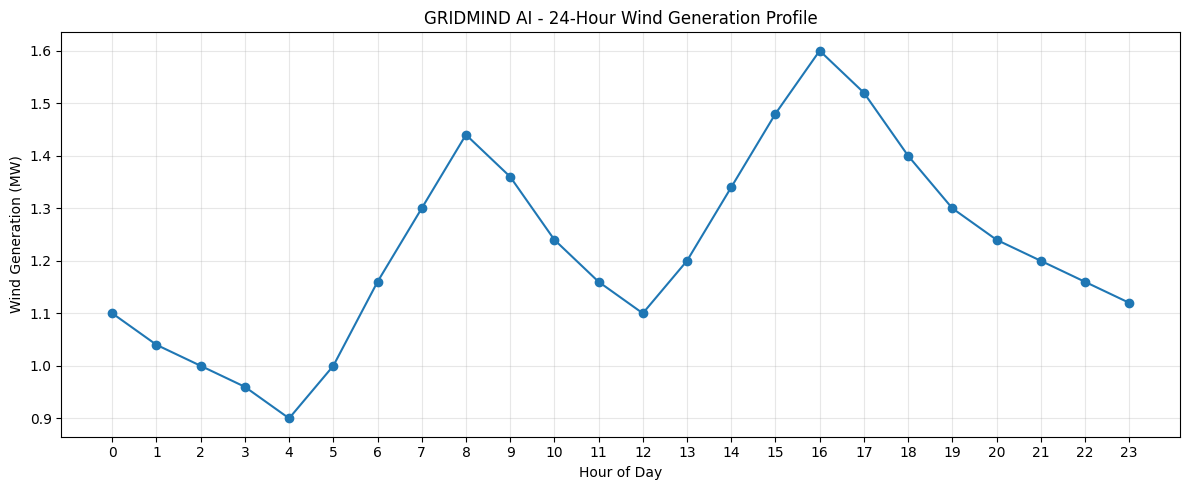


Running 24-hour solar + wind simulation...

SOLAR + WIND SIMULATION RESULTS


,Hour,Load_Factor,Solar_MW,Wind_MW,Total_Renewable_MW,Maximum_Line_Loading_%,Minimum_Bus_Voltage_pu,Transformer_Loading_%,Line_Losses_MW,Powerflow_Converged
0,0,0.75,0.000000e+00,1.10,1.100000,29.882070,0.975436,18.249926,0.044613,1
1,1,0.75,0.000000e+00,1.04,1.040000,29.882461,0.975424,18.387194,0.044834,1
2,2,0.75,0.000000e+00,1.00,1.000000,29.882724,0.975415,18.478869,0.044987,1
3,3,0.75,0.000000e+00,0.96,0.960000,29.882989,0.975406,18.570672,0.045146,1
4,4,0.75,0.000000e+00,0.90,0.900000,29.883388,0.975393,18.708614,0.045393,1
5,5,0.75,0.000000e+00,1.00,1.000000,29.882724,0.975415,18.478869,0.044987,1
6,6,1.15,0.000000e+00,1.16,1.160000,44.214965,0.969939,27.778487,0.099492,1
7,7,1.15,5.176381e-01,1.30,1.817638,44.207009,0.970113,26.176079,0.095430,1
8,8,1.15,1.000000e+00,1.44,2.440000,44.200030,0.970267,24.674876,0.092841,1
9,9,1.15,1.414214e+00,1.36,2.774214,44.196501,0.970344,23.875526,0.091951,1


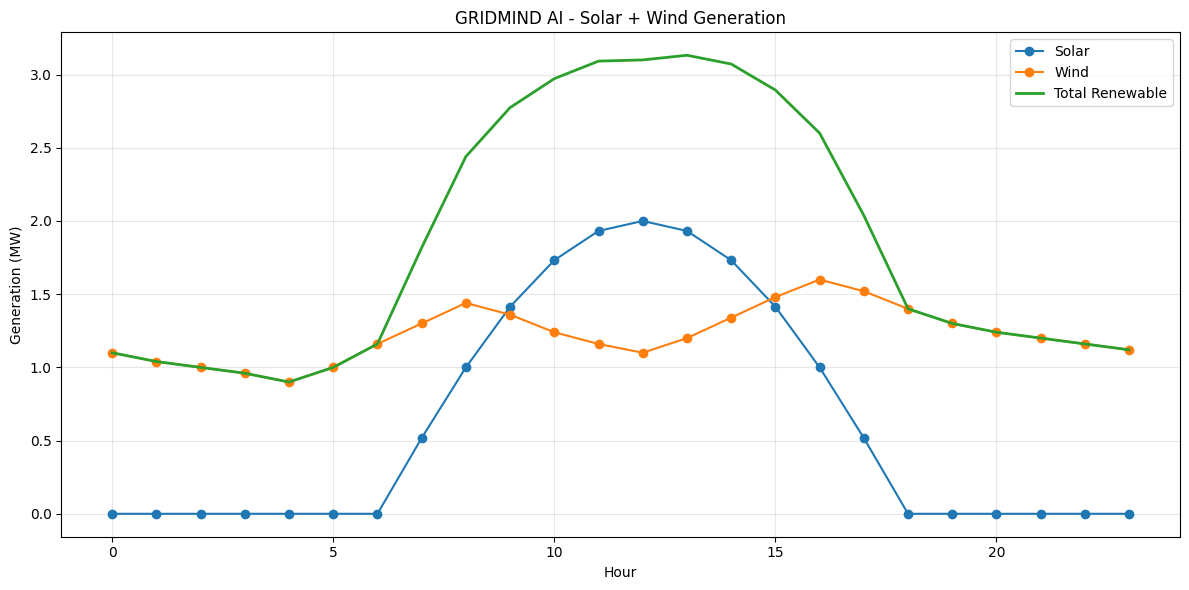

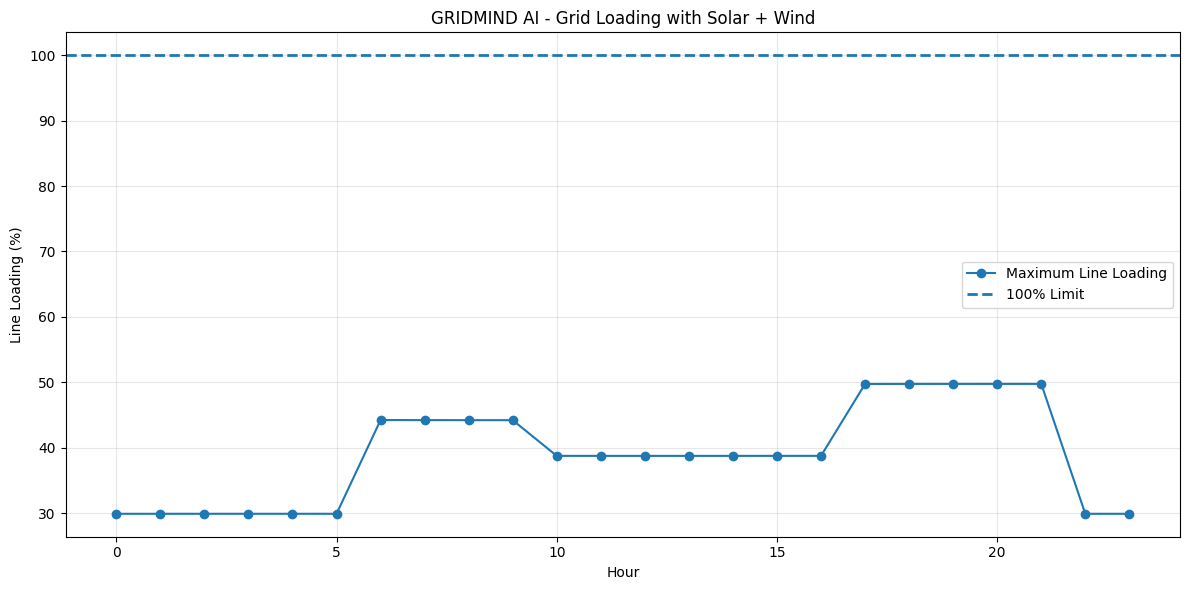


STEP 16 COMPLETED
Wind capacity: 2.00 MW
Maximum renewable generation: 3.13 MW
Maximum line loading: 49.75%
Minimum bus voltage: 0.9678 pu

Saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_WIND_PROFILE.csv
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_SOLAR_WIND_24H_RESULTS.csv


In [82]:
# ============================================================
# STEP 16 - WIND POWER INTEGRATION
# GRIDMIND AI
# ============================================================

import copy
import numpy as np
import pandas as pd
import pandapower as pp
import matplotlib.pyplot as plt
import os

print("=" * 75)
print("GRIDMIND AI - WIND POWER INTEGRATION")
print("=" * 75)


# ============================================================
# 1. CHECK NETWORK
# ============================================================

if "ts_net" not in globals():
    raise RuntimeError(
        "ts_net not found. Please run the time-series network setup first."
    )

print("\n✅ Existing GRIDMIND network found.")


# ============================================================
# 2. CREATE INDEPENDENT RENEWABLE NETWORK
# ============================================================

renewable_net = copy.deepcopy(ts_net)


# ============================================================
# 3. ADD WIND GENERATOR
# ============================================================

# Wind generator connected to the commercial bus
# Rated capacity = 2 MW

wind_capacity_mw = 2.0

wind_gen = pp.create_sgen(
    renewable_net,
    bus=ts_commercial_bus,
    p_mw=0.0,
    q_mvar=0.0,
    name="GRIDMIND Wind Turbine"
)

print(
    f"\n✅ Wind generator created."
)

print(
    f"Wind capacity: "
    f"{wind_capacity_mw:.2f} MW"
)


# ============================================================
# 4. CREATE 24-HOUR WIND PROFILE
# ============================================================

hours_24 = np.arange(24)

# Synthetic normalized wind profile
# This represents changing wind availability
wind_profile = np.array([
    0.55,
    0.52,
    0.50,
    0.48,
    0.45,
    0.50,
    0.58,
    0.65,
    0.72,
    0.68,
    0.62,
    0.58,
    0.55,
    0.60,
    0.67,
    0.74,
    0.80,
    0.76,
    0.70,
    0.65,
    0.62,
    0.60,
    0.58,
    0.56
])

wind_generation_mw = (
    wind_capacity_mw
    * wind_profile
)


# ============================================================
# 5. DISPLAY WIND PROFILE
# ============================================================

wind_profile_df = pd.DataFrame({

    "Hour": hours_24,

    "Wind_Profile_pu":
        wind_profile,

    "Wind_Generation_MW":
        wind_generation_mw
})

print("\n" + "=" * 75)
print("24-HOUR WIND PROFILE")
print("=" * 75)

display(
    wind_profile_df
)


# ============================================================
# 6. PLOT WIND GENERATION
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    hours_24,
    wind_generation_mw,
    marker="o"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Wind Generation (MW)"
)

plt.title(
    "GRIDMIND AI - 24-Hour Wind Generation Profile"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    hours_24
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. RUN 24-HOUR SOLAR + WIND SIMULATION
# ============================================================

renewable_records = []

print("\nRunning 24-hour solar + wind simulation...")


for hour in range(24):

    net = copy.deepcopy(
        renewable_net
    )

    # --------------------------------------------------------
    # Load profiles
    # --------------------------------------------------------

    if hour in [6, 7, 8, 9]:
        load_factor = 1.15

    elif hour in [17, 18, 19, 20, 21]:
        load_factor = 1.30

    elif hour in [10, 11, 12, 13, 14, 15, 16]:
        load_factor = 1.00

    else:
        load_factor = 0.75


    # --------------------------------------------------------
    # Apply loads
    # --------------------------------------------------------

    net.load.loc[
        ts_res_load,
        "p_mw"
    ] = 2.0 * load_factor

    net.load.loc[
        ts_ind_load,
        "p_mw"
    ] = 5.0 * load_factor

    net.load.loc[
        ts_com_load,
        "p_mw"
    ] = 3.0 * load_factor


    # --------------------------------------------------------
    # Solar generation
    # --------------------------------------------------------

    if 6 <= hour <= 18:

        solar_shape = np.sin(
            np.pi *
            (hour - 6) /
            12
        )

        solar_output = (
            2.0 *
            max(
                0,
                solar_shape
            )
        )

    else:

        solar_output = 0.0


    # --------------------------------------------------------
    # Wind generation
    # --------------------------------------------------------

    wind_output = (
        wind_generation_mw[hour]
    )


    # --------------------------------------------------------
    # Apply renewable generation
    # --------------------------------------------------------

    net.sgen.loc[
        ts_solar,
        "p_mw"
    ] = solar_output

    net.sgen.loc[
        wind_gen,
        "p_mw"
    ] = wind_output


    # --------------------------------------------------------
    # Run power flow
    # --------------------------------------------------------

    try:

        pp.runpp(
            net,
            max_iteration=100
        )

        max_line_loading = float(
            net.res_line
            .loading_percent
            .max()
        )

        min_voltage = float(
            net.res_bus
            .vm_pu
            .min()
        )

        transformer_loading = float(
            net.res_trafo
            .loading_percent
            .max()
        )

        line_losses = float(
            net.res_line
            .pl_mw
            .sum()
        )

        converged = 1

    except Exception:

        max_line_loading = np.nan

        min_voltage = np.nan

        transformer_loading = np.nan

        line_losses = np.nan

        converged = 0


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    renewable_records.append({

        "Hour":
            hour,

        "Load_Factor":
            load_factor,

        "Solar_MW":
            solar_output,

        "Wind_MW":
            wind_output,

        "Total_Renewable_MW":
            solar_output + wind_output,

        "Maximum_Line_Loading_%":
            max_line_loading,

        "Minimum_Bus_Voltage_pu":
            min_voltage,

        "Transformer_Loading_%":
            transformer_loading,

        "Line_Losses_MW":
            line_losses,

        "Powerflow_Converged":
            converged
    })


# ============================================================
# 8. RESULTS DATAFRAME
# ============================================================

renewable_df = pd.DataFrame(
    renewable_records
)

print("\n" + "=" * 75)
print("SOLAR + WIND SIMULATION RESULTS")
print("=" * 75)

display(
    renewable_df
)


# ============================================================
# 9. RENEWABLE GENERATION PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    renewable_df["Hour"],
    renewable_df["Solar_MW"],
    marker="o",
    label="Solar"
)

plt.plot(
    renewable_df["Hour"],
    renewable_df["Wind_MW"],
    marker="o",
    label="Wind"
)

plt.plot(
    renewable_df["Hour"],
    renewable_df["Total_Renewable_MW"],
    linewidth=2,
    label="Total Renewable"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Generation (MW)"
)

plt.title(
    "GRIDMIND AI - Solar + Wind Generation"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. GRID PERFORMANCE PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    renewable_df["Hour"],
    renewable_df["Maximum_Line_Loading_%"],
    marker="o",
    label="Maximum Line Loading"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=2,
    label="100% Limit"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Line Loading (%)"
)

plt.title(
    "GRIDMIND AI - Grid Loading with Solar + Wind"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. SAVE RESULTS
# ============================================================

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

wind_profile_path = (
    output_dir
    + "/GRIDMIND_WIND_PROFILE.csv"
)

renewable_results_path = (
    output_dir
    + "/GRIDMIND_SOLAR_WIND_24H_RESULTS.csv"
)

wind_profile_df.to_csv(
    wind_profile_path,
    index=False
)

renewable_df.to_csv(
    renewable_results_path,
    index=False
)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 16 COMPLETED")
print("=" * 75)

print(
    f"Wind capacity: "
    f"{wind_capacity_mw:.2f} MW"
)

print(
    f"Maximum renewable generation: "
    f"{renewable_df['Total_Renewable_MW'].max():.2f} MW"
)

print(
    f"Maximum line loading: "
    f"{renewable_df['Maximum_Line_Loading_%'].max():.2f}%"
)

print(
    f"Minimum bus voltage: "
    f"{renewable_df['Minimum_Bus_Voltage_pu'].min():.4f} pu"
)

print(
    "\nSaved:"
)

print(
    wind_profile_path
)

print(
    renewable_results_path
)


In [83]:
# ============================================================
# GRIDMIND AI — STEP 17
# RENEWABLE-AWARE NEXT-HOUR OVERLOAD FORECASTING
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("🚀 GRIDMIND AI — Step 17")
print("Renewable-aware next-hour overload forecasting")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK REQUIRED NETWORK
# ------------------------------------------------------------

if "renewable_net" not in globals():
    raise RuntimeError(
        "renewable_net is not available. "
        "Run Step 16 first."
    )

# ------------------------------------------------------------
# 2. CREATE A CHRONOLOGICAL 30-DAY RENEWABLE DATASET
# ------------------------------------------------------------

sim_net = copy.deepcopy(renewable_net)

DAYS = 30
HOURS_TOTAL = DAYS * 24

records = []

print(f"⏳ Simulating {DAYS} days ({HOURS_TOTAL} hours)...")

for hour_idx in range(HOURS_TOTAL):

    day = hour_idx // 24 + 1
    hour = hour_idx % 24

    # --------------------------------------------------------
    # BASE DAILY LOAD PATTERN
    # --------------------------------------------------------

    if hour in [0, 1, 2, 3, 4, 5]:
        hourly_factor = 0.75

    elif hour in [6, 7, 8, 9]:
        hourly_factor = 1.00

    elif hour in [10, 11, 12, 13, 14, 15]:
        hourly_factor = 0.90

    elif hour in [16, 17, 18, 19, 20, 21]:
        hourly_factor = 1.20

    else:
        hourly_factor = 0.90

    # --------------------------------------------------------
    # STRESS WINDOWS
    # --------------------------------------------------------

    if 11 <= day <= 15:
        stress_factor = np.random.uniform(1.8, 2.5)

    elif 21 <= day <= 25:
        stress_factor = np.random.uniform(2.2, 3.0)

    elif 26 <= day <= 30:
        stress_factor = np.random.uniform(1.3, 2.2)

    else:
        stress_factor = np.random.uniform(0.90, 1.15)

    # --------------------------------------------------------
    # FEEDER-SPECIFIC VARIATION
    # --------------------------------------------------------

    residential_factor = np.random.uniform(0.90, 1.10)
    industrial_factor = np.random.uniform(0.95, 1.15)
    commercial_factor = np.random.uniform(0.90, 1.10)

    residential_load = min(
        2.0 * hourly_factor * stress_factor * residential_factor,
        5.0
    )

    industrial_load = min(
        5.0 * hourly_factor * stress_factor * industrial_factor,
        15.0
    )

    commercial_load = min(
        3.0 * hourly_factor * stress_factor * commercial_factor,
        8.0
    )

    # --------------------------------------------------------
    # SOLAR PROFILE
    # --------------------------------------------------------

    solar_profile = max(
        0,
        np.sin((hour - 6) * np.pi / 12)
    )

    solar_generation = (
        2.0 *
        solar_profile *
        np.random.uniform(0.85, 1.10)
    )

    # --------------------------------------------------------
    # WIND PROFILE
    # --------------------------------------------------------

    wind_profile = [
        0.55, 0.52, 0.50, 0.48,
        0.45, 0.50, 0.58, 0.65,
        0.72, 0.68, 0.62, 0.58,
        0.55, 0.60, 0.67, 0.74,
        0.80, 0.76, 0.70, 0.65,
        0.62, 0.60, 0.58, 0.56
    ]

    wind_generation = (
        2.0 *
        wind_profile[hour] *
        np.random.uniform(0.90, 1.10)
    )

    # --------------------------------------------------------
    # APPLY LOADS
    # --------------------------------------------------------

    sim_net.load.at[ts_res_load, "p_mw"] = residential_load
    sim_net.load.at[ts_ind_load, "p_mw"] = industrial_load
    sim_net.load.at[ts_com_load, "p_mw"] = commercial_load

    # Maintain approximate power factor
    sim_net.load.at[ts_res_load, "q_mvar"] = residential_load * 0.30
    sim_net.load.at[ts_ind_load, "q_mvar"] = industrial_load * 0.30
    sim_net.load.at[ts_com_load, "q_mvar"] = commercial_load * 0.33

    # --------------------------------------------------------
    # APPLY RENEWABLE GENERATION
    # --------------------------------------------------------

    sim_net.sgen.at[ts_solar, "p_mw"] = solar_generation
    sim_net.sgen.at[wind_gen, "p_mw"] = wind_generation

    # --------------------------------------------------------
    # POWER FLOW
    # --------------------------------------------------------

    try:
        pp.runpp(
            sim_net,
            max_iteration=100,
            init="auto"
        )

        max_line_loading = sim_net.res_line.loading_percent.max()
        min_voltage = sim_net.res_bus.vm_pu.min()
        transformer_loading = sim_net.res_trafo.loading_percent.max()

        total_losses = (
            sim_net.res_line.pl_mw.sum()
            + sim_net.res_trafo.pl_mw.sum()
        )

        overload = int(max_line_loading >= 100)

    except Exception:
        max_line_loading = np.nan
        min_voltage = np.nan
        transformer_loading = np.nan
        total_losses = np.nan
        overload = 1

    # --------------------------------------------------------
    # STORE DATA
    # --------------------------------------------------------

    records.append({
        "hour_index": hour_idx,
        "day": day,
        "hour": hour,

        "residential_load_mw": residential_load,
        "industrial_load_mw": industrial_load,
        "commercial_load_mw": commercial_load,

        "total_load_mw":
            residential_load
            + industrial_load
            + commercial_load,

        "solar_generation_mw": solar_generation,
        "wind_generation_mw": wind_generation,

        "total_renewable_mw":
            solar_generation + wind_generation,

        "renewable_load_ratio":
            (solar_generation + wind_generation)
            / max(
                residential_load
                + industrial_load
                + commercial_load,
                0.001
            ),

        "max_line_loading_percent": max_line_loading,
        "min_voltage_pu": min_voltage,
        "transformer_loading_percent": transformer_loading,
        "line_losses_mw": total_losses,

        "overload": overload
    })

renewable_chrono_df = pd.DataFrame(records)

# ------------------------------------------------------------
# 3. CREATE NEXT-HOUR TARGET
# ------------------------------------------------------------

renewable_chrono_df["next_hour_overload"] = (
    renewable_chrono_df["overload"].shift(-1)
)

# Remove final row because it has no next-hour target
renewable_chrono_df = renewable_chrono_df.dropna(
    subset=["next_hour_overload"]
).reset_index(drop=True)

renewable_chrono_df["next_hour_overload"] = (
    renewable_chrono_df["next_hour_overload"].astype(int)
)

# ------------------------------------------------------------
# 4. ADD TIME-SERIES FEATURES
# ------------------------------------------------------------

renewable_chrono_df["load_change_mw"] = (
    renewable_chrono_df["total_load_mw"].diff()
)

renewable_chrono_df["solar_change_mw"] = (
    renewable_chrono_df["solar_generation_mw"].diff()
)

renewable_chrono_df["wind_change_mw"] = (
    renewable_chrono_df["wind_generation_mw"].diff()
)

renewable_chrono_df["loading_change_percent"] = (
    renewable_chrono_df["max_line_loading_percent"].diff()
)

renewable_chrono_df["voltage_change_pu"] = (
    renewable_chrono_df["min_voltage_pu"].diff()
)

renewable_chrono_df["renewable_change_mw"] = (
    renewable_chrono_df["total_renewable_mw"].diff()
)

# Rolling features
renewable_chrono_df["load_rolling_3h"] = (
    renewable_chrono_df["total_load_mw"]
    .rolling(3)
    .mean()
)

renewable_chrono_df["loading_rolling_3h"] = (
    renewable_chrono_df["max_line_loading_percent"]
    .rolling(3)
    .mean()
)

renewable_chrono_df["renewable_rolling_3h"] = (
    renewable_chrono_df["total_renewable_mw"]
    .rolling(3)
    .mean()
)

# Time encoding
renewable_chrono_df["hour_sin"] = np.sin(
    2 * np.pi * renewable_chrono_df["hour"] / 24
)

renewable_chrono_df["hour_cos"] = np.cos(
    2 * np.pi * renewable_chrono_df["hour"] / 24
)

# ------------------------------------------------------------
# 5. CLEAN DATA
# ------------------------------------------------------------

renewable_chrono_df = renewable_chrono_df.dropna().reset_index(
    drop=True
)

# ------------------------------------------------------------
# 6. FEATURES
# ------------------------------------------------------------

renewable_features = [
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",

    "solar_generation_mw",
    "wind_generation_mw",
    "total_renewable_mw",
    "renewable_load_ratio",

    "max_line_loading_percent",
    "min_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",

    "load_change_mw",
    "solar_change_mw",
    "wind_change_mw",
    "renewable_change_mw",

    "loading_change_percent",
    "voltage_change_pu",

    "load_rolling_3h",
    "loading_rolling_3h",
    "renewable_rolling_3h",

    "hour_sin",
    "hour_cos"
]

X_renewable = renewable_chrono_df[
    renewable_features
]

y_renewable = renewable_chrono_df[
    "next_hour_overload"
]

# ------------------------------------------------------------
# 7. TIME-AWARE TRAIN / TEST SPLIT
# ------------------------------------------------------------

split_index = int(len(renewable_chrono_df) * 0.70)

X_train_renewable = X_renewable.iloc[:split_index]
X_test_renewable = X_renewable.iloc[split_index:]

y_train_renewable = y_renewable.iloc[:split_index]
y_test_renewable = y_renewable.iloc[split_index:]

print("\n📊 Dataset summary")
print("-" * 70)
print("Total samples:", len(renewable_chrono_df))
print("Training samples:", len(X_train_renewable))
print("Testing samples:", len(X_test_renewable))

print("\nTarget distribution:")
print(
    renewable_chrono_df["next_hour_overload"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 8. CHECK WHETHER BOTH CLASSES EXIST
# ------------------------------------------------------------

if y_train_renewable.nunique() < 2:
    raise RuntimeError(
        "Training data contains only one class. "
        "Increase stress levels or adjust the network before ML training."
    )

# ------------------------------------------------------------
# 9. TRAIN RENEWABLE-AWARE RANDOM FOREST
# ------------------------------------------------------------

renewable_rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=14,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

renewable_rf.fit(
    X_train_renewable,
    y_train_renewable
)

# ------------------------------------------------------------
# 10. PREDICTION
# ------------------------------------------------------------

renewable_prediction = renewable_rf.predict(
    X_test_renewable
)

renewable_probability = renewable_rf.predict_proba(
    X_test_renewable
)[:, 1]

# ------------------------------------------------------------
# 11. METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test_renewable,
    renewable_prediction
)

precision = precision_score(
    y_test_renewable,
    renewable_prediction,
    zero_division=0
)

recall = recall_score(
    y_test_renewable,
    renewable_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test_renewable,
    renewable_prediction,
    zero_division=0
)

print("\n🤖 RENEWABLE-AWARE ML RESULTS")
print("=" * 70)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

if y_test_renewable.nunique() == 2:
    roc_auc = roc_auc_score(
        y_test_renewable,
        renewable_probability
    )

    pr_auc = average_precision_score(
        y_test_renewable,
        renewable_probability
    )

    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"PR-AUC    : {pr_auc:.4f}")

# ------------------------------------------------------------
# 12. CONFUSION MATRIX
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_renewable,
        renewable_prediction
    )
)

# ------------------------------------------------------------
# 13. FEATURE IMPORTANCE
# ------------------------------------------------------------

renewable_feature_importance = pd.DataFrame({
    "feature": renewable_features,
    "importance": renewable_rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("\n🔥 TOP RENEWABLE-AWARE FEATURES")
print("-" * 70)
print(
    renewable_feature_importance.head(15).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"
os.makedirs(output_dir, exist_ok=True)

renewable_chrono_df.to_csv(
    f"{output_dir}/GRIDMIND_RENEWABLE_CHRONOLOGICAL_DATASET.csv",
    index=False
)

renewable_feature_importance.to_csv(
    f"{output_dir}/GRIDMIND_RENEWABLE_FEATURE_IMPORTANCE.csv",
    index=False
)

renewable_test_results = renewable_chrono_df.iloc[
    split_index:
].copy()

renewable_test_results[
    "predicted_next_hour_overload"
] = renewable_prediction

renewable_test_results[
    "next_hour_overload_probability"
] = renewable_probability

renewable_test_results.to_csv(
    f"{output_dir}/GRIDMIND_RENEWABLE_FORECAST_RESULTS.csv",
    index=False
)

print("\n✅ STEP 17 COMPLETE")
print("=" * 70)
print("Files created:")
print("1. GRIDMIND_RENEWABLE_CHRONOLOGICAL_DATASET.csv")
print("2. GRIDMIND_RENEWABLE_FEATURE_IMPORTANCE.csv")
print("3. GRIDMIND_RENEWABLE_FORECAST_RESULTS.csv")

print("\n🌱 Solar + Wind are now part of the ML forecasting pipeline.")

🚀 GRIDMIND AI — Step 17
Renewable-aware next-hour overload forecasting
⏳ Simulating 30 days (720 hours)...

📊 Dataset summary
----------------------------------------------------------------------
Total samples: 717
Training samples: 501
Testing samples: 216

Target distribution:
next_hour_overload
0    616
1    101
Name: count, dtype: int64

🤖 RENEWABLE-AWARE ML RESULTS
Accuracy  : 0.8380
Precision : 0.6825
Recall    : 0.7414
F1 Score  : 0.7107
ROC-AUC   : 0.8981
PR-AUC    : 0.7837

Confusion Matrix:
[[138  20]
 [ 15  43]]

🔥 TOP RENEWABLE-AWARE FEATURES
----------------------------------------------------------------------
                    feature  importance
         loading_rolling_3h    0.147999
            load_rolling_3h    0.141980
         commercial_load_mw    0.107910
        residential_load_mw    0.070336
   max_line_loading_percent    0.070133
              total_load_mw    0.068066
         industrial_load_mw    0.059790
             min_voltage_pu    0.053904
transfo

🚀 GRIDMIND AI — STEP 18
Renewable + Grid Health + ML Forecast Dashboard

⚡ GRIDMIND AI GRID HEALTH SUMMARY
Peak Load                  : 28.00 MW
Peak Line Loading         : 124.68 %
Minimum Voltage           : 0.9065 pu
Average Line Loading      : 63.50 %
Average Voltage           : 0.9536 pu

🌱 RENEWABLE GENERATION
----------------------------------------------------------------------
Total Solar Generation    : 441.91 MW-hours
Total Wind Generation     : 874.45 MW-hours
Total Renewable           : 1316.35 MW-hours
Average Renewable Output  : 1.84 MW

🚨 GRID RISK
----------------------------------------------------------------------
Overload Hours            : 101

🤖 ML FORECAST PERFORMANCE
----------------------------------------------------------------------
Accuracy                  : 0.8380
Precision                 : 0.6825
Recall                    : 0.7414
F1 Score                  : 0.7107


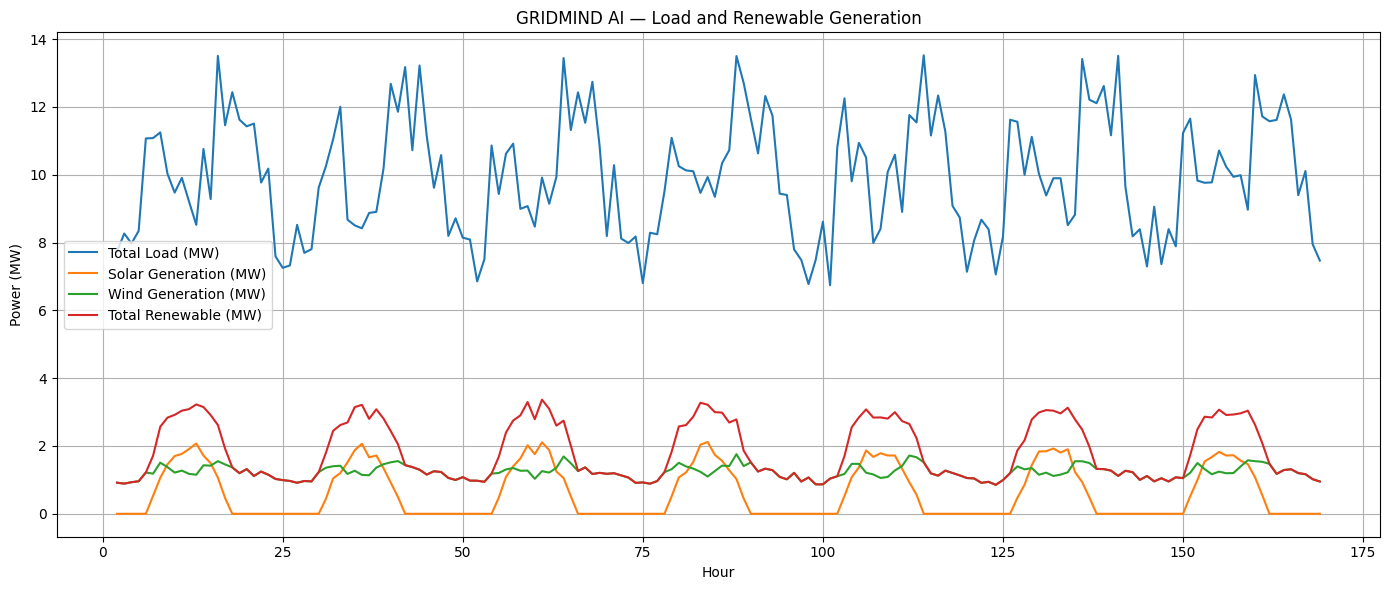

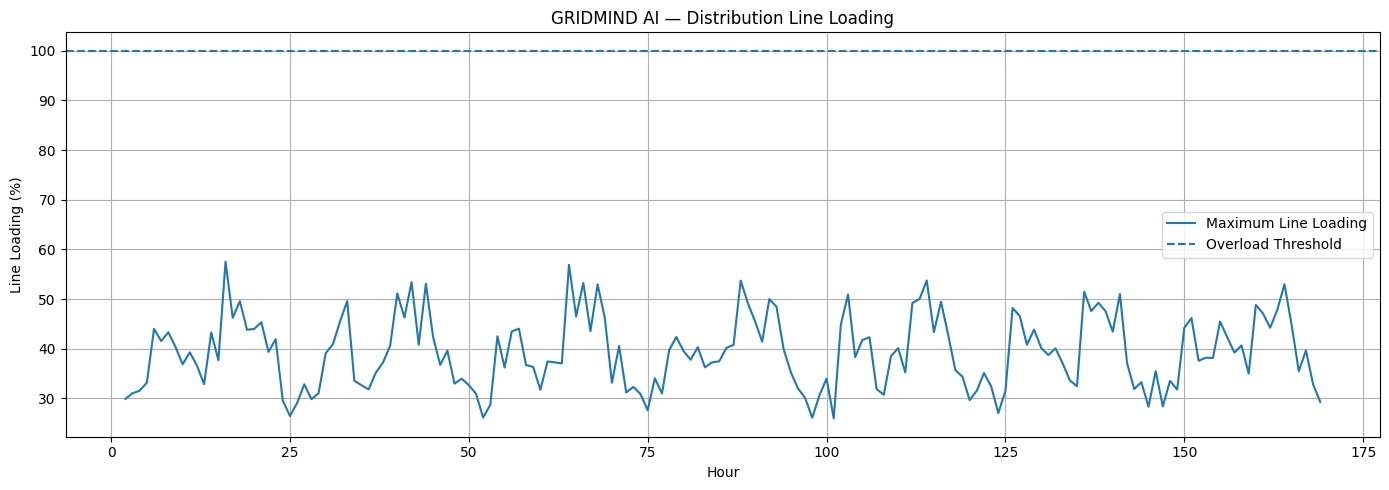

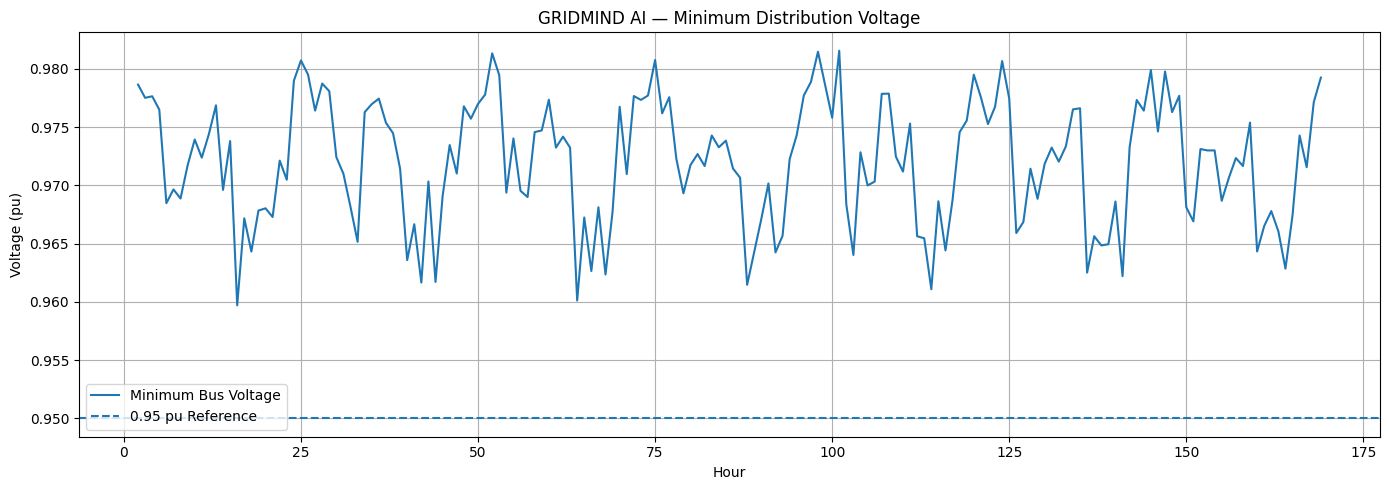

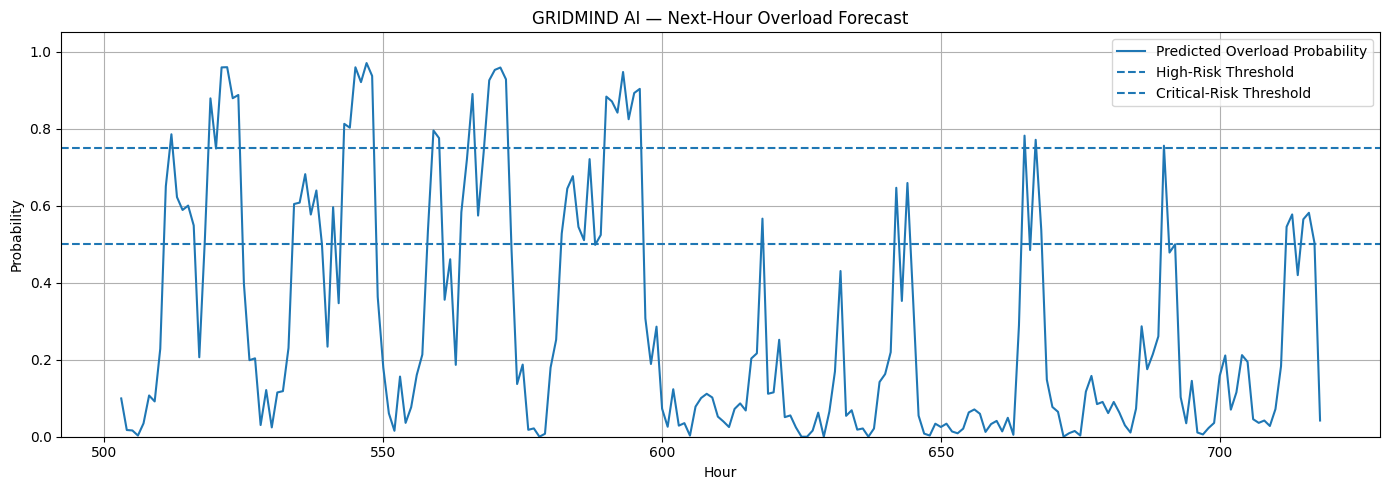

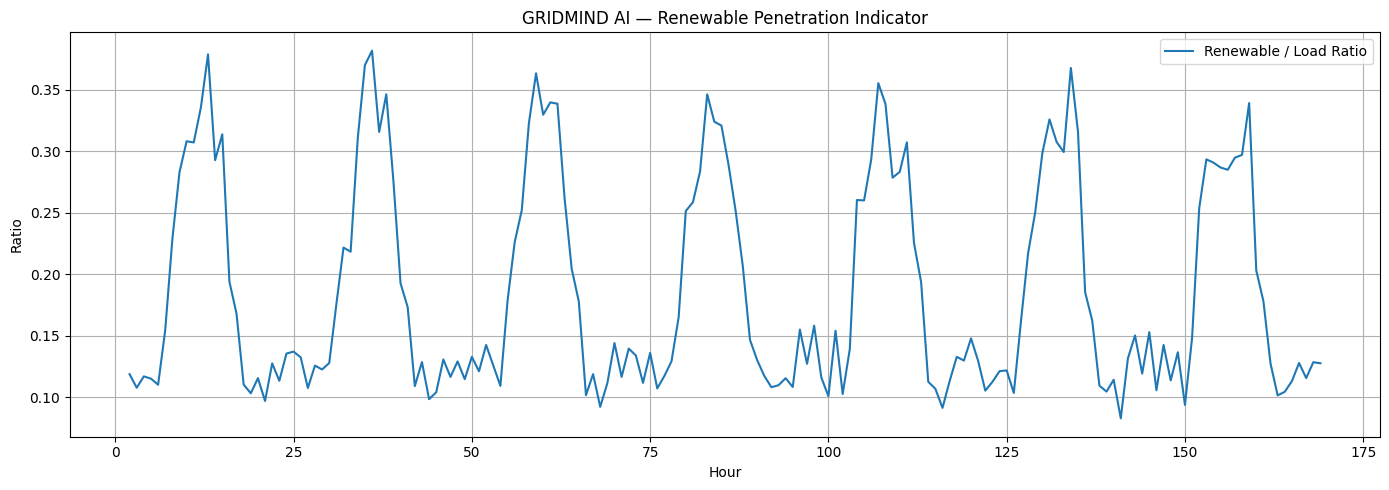


🚨 TOP 10 HIGH-RISK FORECASTS


,day,hour,total_load_mw,solar_generation_mw,wind_generation_mw,max_line_loading_percent,min_voltage_pu,next_hour_overload_probability
545,23,19,28.000000,0.000000e+00,1.343958,124.660922,0.906616,0.970219
520,22,18,28.000000,2.112586e-16,1.490131,124.648608,0.906706,0.959476
543,23,17,28.000000,5.112314e-01,1.520806,124.603992,0.907031,0.959247
519,22,17,28.000000,4.524934e-01,1.562202,124.605395,0.907020,0.959007
569,24,19,28.000000,0.000000e+00,1.371938,124.658556,0.906634,0.958646
568,24,18,28.000000,2.110948e-16,1.499161,124.647851,0.906711,0.952479
591,25,17,27.646041,5.409065e-01,1.539159,121.725593,0.909042,0.946991
546,23,20,27.822576,0.000000e+00,1.281362,123.044321,0.907663,0.936812
570,24,20,28.000000,0.000000e+00,1.307796,124.663986,0.906594,0.927995
567,24,17,28.000000,4.603525e-01,1.385118,124.619169,0.906920,0.925499



✅ STEP 18 COMPLETE

GRIDMIND AI now contains:
✅ 24-hour solar simulation
✅ 30-day chronological simulation
✅ Wind generation
✅ Renewable-aware ML forecasting
✅ Next-hour overload prediction
✅ Grid loading analysis
✅ Voltage analysis
✅ Renewable penetration analysis
✅ ML risk visualization
✅ Engineering summary reports

📁 Dashboard files saved to:
/content/GRIDMIND_AI_OUTPUT


In [84]:
# ============================================================
# GRIDMIND AI — STEP 18
# RENEWABLE + GRID HEALTH + ML FORECAST DASHBOARD
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 GRIDMIND AI — STEP 18")
print("Renewable + Grid Health + ML Forecast Dashboard")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK STEP 17 DATA
# ------------------------------------------------------------

if "renewable_chrono_df" not in globals():
    raise RuntimeError(
        "renewable_chrono_df not found. Run Step 17 first."
    )

if "renewable_test_results" not in globals():
    raise RuntimeError(
        "renewable_test_results not found. Run Step 17 first."
    )

df = renewable_chrono_df.copy()
test_df_dashboard = renewable_test_results.copy()

# ------------------------------------------------------------
# 2. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 3. DASHBOARD SUMMARY
# ------------------------------------------------------------

peak_load = df["total_load_mw"].max()
peak_loading = df["max_line_loading_percent"].max()
minimum_voltage = df["min_voltage_pu"].min()

total_solar = df["solar_generation_mw"].sum()
total_wind = df["wind_generation_mw"].sum()
total_renewable = df["total_renewable_mw"].sum()

overload_hours = int(df["overload"].sum())

average_loading = df[
    "max_line_loading_percent"
].mean()

average_voltage = df[
    "min_voltage_pu"
].mean()

average_renewable = df[
    "total_renewable_mw"
].mean()

# ------------------------------------------------------------
# ML METRICS
# ------------------------------------------------------------

if "renewable_prediction" in globals():

    ml_accuracy = accuracy_score(
        y_test_renewable,
        renewable_prediction
    )

    ml_precision = precision_score(
        y_test_renewable,
        renewable_prediction,
        zero_division=0
    )

    ml_recall = recall_score(
        y_test_renewable,
        renewable_prediction,
        zero_division=0
    )

    ml_f1 = f1_score(
        y_test_renewable,
        renewable_prediction,
        zero_division=0
    )

else:

    ml_accuracy = np.nan
    ml_precision = np.nan
    ml_recall = np.nan
    ml_f1 = np.nan

# ------------------------------------------------------------
# 4. PRINT ENGINEERING SUMMARY
# ------------------------------------------------------------

print("\n⚡ GRIDMIND AI GRID HEALTH SUMMARY")
print("=" * 70)

print(f"Peak Load                  : {peak_load:.2f} MW")
print(f"Peak Line Loading         : {peak_loading:.2f} %")
print(f"Minimum Voltage           : {minimum_voltage:.4f} pu")
print(f"Average Line Loading      : {average_loading:.2f} %")
print(f"Average Voltage           : {average_voltage:.4f} pu")

print("\n🌱 RENEWABLE GENERATION")
print("-" * 70)
print(f"Total Solar Generation    : {total_solar:.2f} MW-hours")
print(f"Total Wind Generation     : {total_wind:.2f} MW-hours")
print(f"Total Renewable           : {total_renewable:.2f} MW-hours")
print(f"Average Renewable Output  : {average_renewable:.2f} MW")

print("\n🚨 GRID RISK")
print("-" * 70)
print(f"Overload Hours            : {overload_hours}")

print("\n🤖 ML FORECAST PERFORMANCE")
print("-" * 70)
print(f"Accuracy                  : {ml_accuracy:.4f}")
print(f"Precision                 : {ml_precision:.4f}")
print(f"Recall                    : {ml_recall:.4f}")
print(f"F1 Score                  : {ml_f1:.4f}")

# ------------------------------------------------------------
# 5. FIGURE 1 — LOAD + RENEWABLE GENERATION
# ------------------------------------------------------------

plot_df = df.head(168).copy()  # first 7 days

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["hour_index"],
    plot_df["total_load_mw"],
    label="Total Load (MW)"
)

plt.plot(
    plot_df["hour_index"],
    plot_df["solar_generation_mw"],
    label="Solar Generation (MW)"
)

plt.plot(
    plot_df["hour_index"],
    plot_df["wind_generation_mw"],
    label="Wind Generation (MW)"
)

plt.plot(
    plot_df["hour_index"],
    plot_df["total_renewable_mw"],
    label="Total Renewable (MW)"
)

plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title("GRIDMIND AI — Load and Renewable Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_LOAD_RENEWABLE_PROFILE.png",
    dpi=200
)

plt.show()

# ------------------------------------------------------------
# 6. FIGURE 2 — LINE LOADING
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["hour_index"],
    plot_df["max_line_loading_percent"],
    label="Maximum Line Loading"
)

plt.axhline(
    100,
    linestyle="--",
    label="Overload Threshold"
)

plt.xlabel("Hour")
plt.ylabel("Line Loading (%)")
plt.title("GRIDMIND AI — Distribution Line Loading")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_LINE_LOADING.png",
    dpi=200
)

plt.show()

# ------------------------------------------------------------
# 7. FIGURE 3 — VOLTAGE PROFILE
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["hour_index"],
    plot_df["min_voltage_pu"],
    label="Minimum Bus Voltage"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="0.95 pu Reference"
)

plt.xlabel("Hour")
plt.ylabel("Voltage (pu)")
plt.title("GRIDMIND AI — Minimum Distribution Voltage")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_VOLTAGE_PROFILE.png",
    dpi=200
)

plt.show()

# ------------------------------------------------------------
# 8. FIGURE 4 — NEXT-HOUR OVERLOAD PROBABILITY
# ------------------------------------------------------------

if "next_hour_overload_probability" in test_df_dashboard.columns:

    forecast_plot = test_df_dashboard.copy()

    plt.figure(figsize=(14, 5))

    plt.plot(
        forecast_plot["hour_index"],
        forecast_plot[
            "next_hour_overload_probability"
        ],
        label="Predicted Overload Probability"
    )

    plt.axhline(
        0.50,
        linestyle="--",
        label="High-Risk Threshold"
    )

    plt.axhline(
        0.75,
        linestyle="--",
        label="Critical-Risk Threshold"
    )

    plt.xlabel("Hour")
    plt.ylabel("Probability")
    plt.title(
        "GRIDMIND AI — Next-Hour Overload Forecast"
    )

    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/GRIDMIND_NEXT_HOUR_RISK_FORECAST.png",
        dpi=200
    )

    plt.show()

# ------------------------------------------------------------
# 9. FIGURE 5 — RENEWABLE LOAD RATIO
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["hour_index"],
    plot_df["renewable_load_ratio"],
    label="Renewable / Load Ratio"
)

plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.title(
    "GRIDMIND AI — Renewable Penetration Indicator"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_RENEWABLE_LOAD_RATIO.png",
    dpi=200
)

plt.show()

# ------------------------------------------------------------
# 10. CREATE ENGINEERING SUMMARY TABLE
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Peak Load",
        "Peak Line Loading",
        "Minimum Voltage",
        "Average Line Loading",
        "Average Voltage",
        "Total Solar Generation",
        "Total Wind Generation",
        "Total Renewable Generation",
        "Overload Hours",
        "ML Accuracy",
        "ML Precision",
        "ML Recall",
        "ML F1 Score"
    ],

    "Value": [
        peak_load,
        peak_loading,
        minimum_voltage,
        average_loading,
        average_voltage,
        total_solar,
        total_wind,
        total_renewable,
        overload_hours,
        ml_accuracy,
        ml_precision,
        ml_recall,
        ml_f1
    ]
})

summary.to_csv(
    f"{output_dir}/GRIDMIND_ENGINEERING_SUMMARY.csv",
    index=False
)

# ------------------------------------------------------------
# 11. CREATE HIGH-RISK FORECAST TABLE
# ------------------------------------------------------------

if "next_hour_overload_probability" in test_df_dashboard.columns:

    high_risk = test_df_dashboard[
        test_df_dashboard[
            "next_hour_overload_probability"
        ] >= 0.50
    ].copy()

    high_risk = high_risk.sort_values(
        "next_hour_overload_probability",
        ascending=False
    )

    high_risk.to_csv(
        f"{output_dir}/GRIDMIND_HIGH_RISK_FORECASTS.csv",
        index=False
    )

    print("\n🚨 TOP 10 HIGH-RISK FORECASTS")
    print("=" * 70)

    display(
        high_risk[
            [
                "day",
                "hour",
                "total_load_mw",
                "solar_generation_mw",
                "wind_generation_mw",
                "max_line_loading_percent",
                "min_voltage_pu",
                "next_hour_overload_probability"
            ]
        ].head(10)
    )

# ------------------------------------------------------------
# 12. FINAL DASHBOARD STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 18 COMPLETE")
print("=" * 70)

print("\nGRIDMIND AI now contains:")

print("✅ 24-hour solar simulation")
print("✅ 30-day chronological simulation")
print("✅ Wind generation")
print("✅ Renewable-aware ML forecasting")
print("✅ Next-hour overload prediction")
print("✅ Grid loading analysis")
print("✅ Voltage analysis")
print("✅ Renewable penetration analysis")
print("✅ ML risk visualization")
print("✅ Engineering summary reports")

print("\n📁 Dashboard files saved to:")
print(output_dir)

In [85]:
# ============================================================
# GRIDMIND AI — STEP 19
# PREDICTIVE SELF-HEALING DECISION ENGINE
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("🚀 GRIDMIND AI — STEP 19")
print("Predictive Self-Healing Decision Engine")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "renewable_net",
    "renewable_rf",
    "renewable_test_results"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Run Steps 16 and 17 first."
    )

# ------------------------------------------------------------
# 2. SELECT HIGHEST-RISK FORECAST
# ------------------------------------------------------------

risk_df = renewable_test_results.copy()

risk_df = risk_df.sort_values(
    "next_hour_overload_probability",
    ascending=False
).reset_index(drop=True)

critical_case = risk_df.iloc[0]

risk_probability = float(
    critical_case["next_hour_overload_probability"]
)

print("\n🔮 HIGHEST-RISK FORECAST")
print("-" * 70)

print(
    f"Day                    : {int(critical_case['day'])}"
)

print(
    f"Hour                   : {int(critical_case['hour'])}"
)

print(
    f"Load                   : "
    f"{critical_case['total_load_mw']:.2f} MW"
)

print(
    f"Solar                  : "
    f"{critical_case['solar_generation_mw']:.2f} MW"
)

print(
    f"Wind                   : "
    f"{critical_case['wind_generation_mw']:.2f} MW"
)

print(
    f"Maximum line loading   : "
    f"{critical_case['max_line_loading_percent']:.2f}%"
)

print(
    f"Minimum voltage        : "
    f"{critical_case['min_voltage_pu']:.4f} pu"
)

print(
    f"Predicted overload risk: "
    f"{risk_probability:.2%}"
)

# ------------------------------------------------------------
# 3. DETERMINE RISK LEVEL
# ------------------------------------------------------------

if risk_probability >= 0.75:
    risk_level = "CRITICAL"

elif risk_probability >= 0.50:
    risk_level = "HIGH"

elif risk_probability >= 0.25:
    risk_level = "MODERATE"

else:
    risk_level = "LOW"

print("\n🚦 RISK LEVEL:", risk_level)

# ------------------------------------------------------------
# 4. RECREATE FORECASTED GRID CONDITION
# ------------------------------------------------------------

healing_net = copy.deepcopy(renewable_net)

healing_net.load.at[
    ts_res_load,
    "p_mw"
] = float(
    critical_case["residential_load_mw"]
)

healing_net.load.at[
    ts_ind_load,
    "p_mw"
] = float(
    critical_case["industrial_load_mw"]
)

healing_net.load.at[
    ts_com_load,
    "p_mw"
] = float(
    critical_case["commercial_load_mw"]
)

# Reactive power approximation
healing_net.load.at[
    ts_res_load,
    "q_mvar"
] = (
    critical_case["residential_load_mw"] * 0.30
)

healing_net.load.at[
    ts_ind_load,
    "q_mvar"
] = (
    critical_case["industrial_load_mw"] * 0.30
)

healing_net.load.at[
    ts_com_load,
    "q_mvar"
] = (
    critical_case["commercial_load_mw"] * 0.33
)

# Renewable generation
healing_net.sgen.at[
    ts_solar,
    "p_mw"
] = float(
    critical_case["solar_generation_mw"]
)

healing_net.sgen.at[
    wind_gen,
    "p_mw"
] = float(
    critical_case["wind_generation_mw"]
)

# ------------------------------------------------------------
# 5. POWER FLOW BEFORE SELF-HEALING
# ------------------------------------------------------------

pp.runpp(
    healing_net,
    max_iteration=100
)

before_loading = (
    healing_net.res_line.loading_percent.copy()
)

before_voltage = (
    healing_net.res_bus.vm_pu.copy()
)

before_transformer_loading = (
    healing_net.res_trafo.loading_percent.max()
)

before_max_loading = (
    before_loading.max()
)

before_min_voltage = (
    before_voltage.min()
)

print("\n⚡ GRID CONDITION BEFORE ACTION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{before_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{before_min_voltage:.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{before_transformer_loading:.2f}%"
)

# ------------------------------------------------------------
# 6. IDENTIFY CRITICAL FEEDER
# ------------------------------------------------------------

feeder_map = {
    ts_res_line: {
        "name": "Residential Feeder",
        "load_idx": ts_res_load
    },

    ts_ind_line: {
        "name": "Industrial Feeder",
        "load_idx": ts_ind_load
    },

    ts_com_line: {
        "name": "Commercial Feeder",
        "load_idx": ts_com_load
    }
}

feeder_status = []

for line_idx, info in feeder_map.items():

    loading = float(
        healing_net.res_line.at[
            line_idx,
            "loading_percent"
        ]
    )

    feeder_status.append({
        "line_index": line_idx,
        "feeder": info["name"],
        "loading_percent": loading,
        "load_index": info["load_idx"]
    })

feeder_df = pd.DataFrame(
    feeder_status
).sort_values(
    "loading_percent",
    ascending=False
).reset_index(drop=True)

critical_feeder = feeder_df.iloc[0]

critical_line = int(
    critical_feeder["line_index"]
)

critical_load = int(
    critical_feeder["load_index"]
)

critical_feeder_name = (
    critical_feeder["feeder"]
)

critical_loading = float(
    critical_feeder["loading_percent"]
)

print("\n🔥 FEEDER ANALYSIS")
print("-" * 70)

print(feeder_df.to_string(index=False))

print(
    f"\nCritical feeder: "
    f"{critical_feeder_name}"
)

# ------------------------------------------------------------
# 7. DECISION ENGINE
# ------------------------------------------------------------

print("\n🧠 GRIDMIND DECISION ENGINE")
print("-" * 70)

action = "NO ACTION"
action_reason = "Grid condition within acceptable limits."

if (
    risk_probability >= 0.50
    or critical_loading >= 100
):

    action = "PREDICTIVE LOAD REDUCTION"

    action_reason = (
        "High predicted overload risk or actual feeder "
        "loading above the operational threshold."
    )

elif (
    risk_probability >= 0.25
    or critical_loading >= 80
):

    action = "PREVENTIVE LOAD REDUCTION"

    action_reason = (
        "Moderate predicted risk or elevated feeder loading."
    )

print("Selected action:", action)
print("Reason:", action_reason)

# ------------------------------------------------------------
# 8. APPLY CORRECTIVE ACTION
# ------------------------------------------------------------

after_net = copy.deepcopy(healing_net)

if action != "NO ACTION":

    original_p = float(
        after_net.load.at[
            critical_load,
            "p_mw"
        ]
    )

    original_q = float(
        after_net.load.at[
            critical_load,
            "q_mvar"
        ]
    )

    reduction_factor = 0.30

    after_net.load.at[
        critical_load,
        "p_mw"
    ] = (
        original_p *
        (1 - reduction_factor)
    )

    after_net.load.at[
        critical_load,
        "q_mvar"
    ] = (
        original_q *
        (1 - reduction_factor)
    )

# ------------------------------------------------------------
# 9. POWER FLOW AFTER ACTION
# ------------------------------------------------------------

pp.runpp(
    after_net,
    max_iteration=100
)

after_loading = (
    after_net.res_line.loading_percent.copy()
)

after_voltage = (
    after_net.res_bus.vm_pu.copy()
)

after_max_loading = (
    after_loading.max()
)

after_min_voltage = (
    after_voltage.min()
)

after_transformer_loading = (
    after_net.res_trafo.loading_percent.max()
)

print("\n🛠️ GRID CONDITION AFTER ACTION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{after_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{after_min_voltage:.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{after_transformer_loading:.2f}%"
)

# ------------------------------------------------------------
# 10. VALIDATE ACTION
# ------------------------------------------------------------

loading_improvement = (
    before_max_loading -
    after_max_loading
)

voltage_improvement = (
    after_min_voltage -
    before_min_voltage
)

if (
    after_max_loading < 100
    and after_min_voltage >= 0.95
):

    action_status = "SUCCESS"

elif (
    after_max_loading < before_max_loading
    and after_min_voltage >= 0.90
):

    action_status = "PARTIAL SUCCESS"

else:

    action_status = "ACTION INSUFFICIENT"

print("\n✅ SELF-HEALING VALIDATION")
print("-" * 70)

print(
    f"Loading improvement : "
    f"{loading_improvement:.2f}%"
)

print(
    f"Voltage improvement : "
    f"{voltage_improvement:.4f} pu"
)

print(
    f"Action status       : "
    f"{action_status}"
)

# ------------------------------------------------------------
# 11. ENGINEERING REPORT
# ------------------------------------------------------------

report = pd.DataFrame([{

    "day": int(critical_case["day"]),

    "hour": int(critical_case["hour"]),

    "risk_probability":
        risk_probability,

    "risk_level":
        risk_level,

    "critical_feeder":
        critical_feeder_name,

    "before_max_loading_percent":
        before_max_loading,

    "after_max_loading_percent":
        after_max_loading,

    "before_min_voltage_pu":
        before_min_voltage,

    "after_min_voltage_pu":
        after_min_voltage,

    "before_transformer_loading_percent":
        before_transformer_loading,

    "after_transformer_loading_percent":
        after_transformer_loading,

    "action":
        action,

    "action_status":
        action_status,

    "loading_improvement_percent":
        loading_improvement,

    "voltage_improvement_pu":
        voltage_improvement
}])

report_path = (
    f"{output_dir}/"
    "GRIDMIND_STEP19_SELF_HEALING_DECISION_REPORT.csv"
)

report.to_csv(
    report_path,
    index=False
)

# ------------------------------------------------------------
# 12. DISPLAY FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🤖 GRIDMIND AI — SELF-HEALING DECISION REPORT")
print("=" * 70)

display(report)

print("\n📁 Saved:")
print(report_path)

print("\n" + "=" * 70)
print("✅ STEP 19 COMPLETE")
print("=" * 70)

print("""
GRIDMIND AI has now connected:

ML FORECAST
     ↓
RISK ASSESSMENT
     ↓
CRITICAL FEEDER IDENTIFICATION
     ↓
CORRECTIVE ACTION
     ↓
POWER FLOW RE-CALCULATION
     ↓
ACTION VALIDATION
""")

print(
    "⚠️ Engineering note: this is a simulated "
    "self-healing control strategy. It does not represent "
    "physical switch operation or a protection-system trip."
)

🚀 GRIDMIND AI — STEP 19
Predictive Self-Healing Decision Engine

🔮 HIGHEST-RISK FORECAST
----------------------------------------------------------------------
Day                    : 23
Hour                   : 19
Load                   : 28.00 MW
Solar                  : 0.00 MW
Wind                   : 1.34 MW
Maximum line loading   : 124.66%
Minimum voltage        : 0.9066 pu
Predicted overload risk: 97.02%

🚦 RISK LEVEL: CRITICAL

⚡ GRID CONDITION BEFORE ACTION
----------------------------------------------------------------------
Maximum line loading : 124.66%
Minimum voltage      : 0.9066 pu
Transformer loading  : 76.13%

🔥 FEEDER ANALYSIS
----------------------------------------------------------------------
 line_index             feeder  loading_percent  load_index
          1  Industrial Feeder       124.660922           1
          2  Commercial Feeder        54.855258           2
          0 Residential Feeder        40.092239           0

Critical feeder: Industrial Feed

,day,hour,risk_probability,risk_level,critical_feeder,before_max_loading_percent,after_max_loading_percent,before_min_voltage_pu,after_min_voltage_pu,before_transformer_loading_percent,after_transformer_loading_percent,action,action_status,loading_improvement_percent,voltage_improvement_pu
0,23,19,0.970219,CRITICAL,Industrial Feeder,124.660922,84.821858,0.906616,0.932705,76.128542,62.02915,PREDICTIVE LOAD REDUCTION,PARTIAL SUCCESS,39.839063,0.026088



📁 Saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_STEP19_SELF_HEALING_DECISION_REPORT.csv

✅ STEP 19 COMPLETE

GRIDMIND AI has now connected:

ML FORECAST
     ↓
RISK ASSESSMENT
     ↓
CRITICAL FEEDER IDENTIFICATION
     ↓
CORRECTIVE ACTION
     ↓
POWER FLOW RE-CALCULATION
     ↓
ACTION VALIDATION

⚠️ Engineering note: this is a simulated self-healing control strategy. It does not represent physical switch operation or a protection-system trip.


In [86]:
# ============================================================
# GRIDMIND AI — STEP 21
# FAULT LOCATION, ISOLATION & SERVICE RESTORATION (FLISR)
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("🚀 GRIDMIND AI — STEP 21")
print("Fault Location, Isolation & Service Restoration")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

if "renewable_net" not in globals():
    raise RuntimeError(
        "renewable_net not found. Run Step 16 first."
    )

# ------------------------------------------------------------
# 2. CREATE INDEPENDENT FLISR NETWORK
# ------------------------------------------------------------

flisr_net = copy.deepcopy(renewable_net)

print("\n✅ Independent FLISR network created.")

# ------------------------------------------------------------
# 3. CREATE A STRESSED OPERATING CONDITION
# ------------------------------------------------------------

flisr_net.load.at[
    ts_res_load, "p_mw"
] = 3.5

flisr_net.load.at[
    ts_ind_load, "p_mw"
] = 8.0

flisr_net.load.at[
    ts_com_load, "p_mw"
] = 5.0

flisr_net.load.at[
    ts_res_load, "q_mvar"
] = 3.5 * 0.30

flisr_net.load.at[
    ts_ind_load, "q_mvar"
] = 8.0 * 0.30

flisr_net.load.at[
    ts_com_load, "q_mvar"
] = 5.0 * 0.33

# Renewable generation
flisr_net.sgen.at[
    ts_solar, "p_mw"
] = 1.0

flisr_net.sgen.at[
    wind_gen, "p_mw"
] = 1.2

# ------------------------------------------------------------
# 4. NORMAL POWER FLOW
# ------------------------------------------------------------

pp.runpp(
    flisr_net,
    max_iteration=100
)

print("\n⚡ NORMAL GRID CONDITION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{flisr_net.res_line.loading_percent.max():.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{flisr_net.res_bus.vm_pu.min():.4f} pu"
)

# ------------------------------------------------------------
# 5. DISPLAY FEEDER STATUS
# ------------------------------------------------------------

feeder_map = {
    ts_res_line: "Residential Feeder",
    ts_ind_line: "Industrial Feeder",
    ts_com_line: "Commercial Feeder"
}

normal_status = []

for line_idx, feeder_name in feeder_map.items():

    normal_status.append({
        "line_index": line_idx,
        "feeder": feeder_name,
        "loading_percent":
            flisr_net.res_line.at[
                line_idx,
                "loading_percent"
            ]
    })

normal_df = pd.DataFrame(
    normal_status
)

print("\n🔌 NORMAL FEEDER STATUS")
print("-" * 70)

display(normal_df)

# ------------------------------------------------------------
# 6. SIMULATE A FAULT
# ------------------------------------------------------------

# We simulate a fault on the industrial feeder.
faulted_line = ts_ind_line

faulted_feeder = "Industrial Feeder"

print("\n🚨 FAULT EVENT")
print("=" * 70)

print(
    f"Faulted feeder : {faulted_feeder}"
)

print(
    f"Faulted line   : {faulted_line}"
)

# ------------------------------------------------------------
# 7. FAULT DETECTION
# ------------------------------------------------------------

# In a real system this information would come from
# protection relays / SCADA / sensors.
#
# Here we simulate abnormal current/loading.

fault_threshold = 100.0

fault_loading = float(
    flisr_net.res_line.at[
        faulted_line,
        "loading_percent"
    ]
)

fault_detected = True

print("\n🛡️ FAULT DETECTION")
print("-" * 70)

print(
    f"Measured feeder loading : "
    f"{fault_loading:.2f}%"
)

print(
    f"Fault detected          : "
    f"{fault_detected}"
)

# ------------------------------------------------------------
# 8. ISOLATION
# ------------------------------------------------------------

print("\n🔴 FAULT ISOLATION")
print("-" * 70)

# Simulated sectionalizing switch
sectionalizing_switch = "SW-IND-01"

print(
    f"Opening sectionalizing switch: "
    f"{sectionalizing_switch}"
)

# Store faulted feeder load
faulted_load_before = float(
    flisr_net.load.at[
        ts_ind_load,
        "p_mw"
    ]
)

faulted_q_before = float(
    flisr_net.load.at[
        ts_ind_load,
        "q_mvar"
    ]
)

# Simulate isolation by disconnecting the
# affected load from the operating network.
flisr_net.load.at[
    ts_ind_load,
    "p_mw"
] = 0.0

flisr_net.load.at[
    ts_ind_load,
    "q_mvar"
] = 0.0

print(
    f"Industrial load isolated: "
    f"{faulted_load_before:.2f} MW"
)

# ------------------------------------------------------------
# 9. POWER FLOW AFTER ISOLATION
# ------------------------------------------------------------

pp.runpp(
    flisr_net,
    max_iteration=100
)

isolated_max_loading = (
    flisr_net.res_line.loading_percent.max()
)

isolated_min_voltage = (
    flisr_net.res_bus.vm_pu.min()
)

print("\n⚡ AFTER FAULT ISOLATION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{isolated_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{isolated_min_voltage:.4f} pu"
)

# ------------------------------------------------------------
# 10. SERVICE RESTORATION
# ------------------------------------------------------------

print("\n🔀 SERVICE RESTORATION")
print("-" * 70)

tie_switch = "TS-01"

print(
    f"Tie switch status: OPEN"
)

print(
    f"GRIDMIND decision: "
    f"Attempt restoration using {tie_switch}"
)

# ------------------------------------------------------------
# 11. FIND SUPPORT FEEDER
# ------------------------------------------------------------

support_candidates = []

for line_idx, feeder_name in feeder_map.items():

    if line_idx == faulted_line:
        continue

    loading = float(
        flisr_net.res_line.at[
            line_idx,
            "loading_percent"
        ]
    )

    support_candidates.append({
        "line_index": line_idx,
        "feeder": feeder_name,
        "loading_percent": loading
    })

support_df = pd.DataFrame(
    support_candidates
).sort_values(
    "loading_percent"
)

support_feeder = support_df.iloc[0]

print(
    f"Selected support feeder: "
    f"{support_feeder['feeder']}"
)

print(
    f"Current loading: "
    f"{support_feeder['loading_percent']:.2f}%"
)

# ------------------------------------------------------------
# 12. SIMULATED TIE-SWITCH CLOSURE
# ------------------------------------------------------------

restoration_net = copy.deepcopy(
    flisr_net
)

# ------------------------------------------------------------
# 13. RESTORE PART OF FAULTED LOAD
# ------------------------------------------------------------

restore_fraction = 0.70

restored_mw = (
    faulted_load_before
    * restore_fraction
)

restored_q = (
    faulted_q_before
    * restore_fraction
)

# In this simplified prototype, restoration is represented
# by reconnecting part of the isolated load through the
# alternate supply path.

restoration_net.load.at[
    ts_ind_load,
    "p_mw"
] = restored_mw

restoration_net.load.at[
    ts_ind_load,
    "q_mvar"
] = restored_q

print(
    f"Restoring {restore_fraction * 100:.0f}% "
    f"of isolated load"
)

print(
    f"Restored load: "
    f"{restored_mw:.2f} MW"
)

# ------------------------------------------------------------
# 14. POWER FLOW AFTER RESTORATION
# ------------------------------------------------------------

pp.runpp(
    restoration_net,
    max_iteration=100
)

restored_max_loading = (
    restoration_net.res_line.loading_percent.max()
)

restored_min_voltage = (
    restoration_net.res_bus.vm_pu.min()
)

restored_transformer_loading = (
    restoration_net.res_trafo.loading_percent.max()
)

# ------------------------------------------------------------
# 15. RESTORATION VALIDATION
# ------------------------------------------------------------

restoration_success = (
    restored_max_loading < 100
    and restored_min_voltage >= 0.95
)

if restoration_success:

    restoration_status = "SUCCESS"

else:

    restoration_status = "RESTORATION CONSTRAINED"

print("\n✅ RESTORATION RESULT")
print("=" * 70)

print(
    f"Maximum line loading : "
    f"{restored_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{restored_min_voltage:.4f} pu"
)

print(
    f"Transformer loading  : "
    f"{restored_transformer_loading:.2f}%"
)

print(
    f"Restoration status   : "
    f"{restoration_status}"
)

# ------------------------------------------------------------
# 16. CALCULATE CUSTOMER SERVICE RESTORATION
# ------------------------------------------------------------

total_faulted_load = faulted_load_before

restored_percentage = (
    restored_mw /
    max(total_faulted_load, 0.001)
) * 100

print(
    f"\nCustomer load restored: "
    f"{restored_percentage:.1f}%"
)

# ------------------------------------------------------------
# 17. FLISR REPORT
# ------------------------------------------------------------

flisr_report = pd.DataFrame([{

    "fault_detected":
        fault_detected,

    "faulted_feeder":
        faulted_feeder,

    "faulted_line":
        faulted_line,

    "sectionalizing_switch":
        sectionalizing_switch,

    "tie_switch":
        tie_switch,

    "support_feeder":
        support_feeder["feeder"],

    "faulted_load_mw":
        faulted_load_before,

    "restored_load_mw":
        restored_mw,

    "restored_load_percent":
        restored_percentage,

    "before_max_loading_percent":
        flisr_net.res_line.loading_percent.max(),

    "after_restoration_max_loading_percent":
        restored_max_loading,

    "before_min_voltage_pu":
        flisr_net.res_bus.vm_pu.min(),

    "after_restoration_min_voltage_pu":
        restored_min_voltage,

    "transformer_loading_after_restoration_percent":
        restored_transformer_loading,

    "restoration_status":
        restoration_status
}])

# ------------------------------------------------------------
# 18. SAVE
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"
os.makedirs(output_dir, exist_ok=True)

flisr_report.to_csv(
    f"{output_dir}/GRIDMIND_FLISR_REPORT.csv",
    index=False
)

normal_df.to_csv(
    f"{output_dir}/GRIDMIND_FLISR_NORMAL_FEEDERS.csv",
    index=False
)

support_df.to_csv(
    f"{output_dir}/GRIDMIND_FLISR_SUPPORT_FEEDERS.csv",
    index=False
)

# ------------------------------------------------------------
# 19. FINAL DISPLAY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🤖 GRIDMIND AI — FLISR REPORT")
print("=" * 70)

display(flisr_report)

print("\n📁 Files saved:")
print(
    f"{output_dir}/GRIDMIND_FLISR_REPORT.csv"
)

print(
    f"{output_dir}/GRIDMIND_FLISR_NORMAL_FEEDERS.csv"
)

print(
    f"{output_dir}/GRIDMIND_FLISR_SUPPORT_FEEDERS.csv"
)

print("\n" + "=" * 70)
print("✅ STEP 21 COMPLETE")
print("=" * 70)

print("""
GRIDMIND FLISR PIPELINE

FAULT
  ↓
DETECTION
  ↓
FAULT LOCATION
  ↓
SECTION ISOLATION
  ↓
TIE-SWITCH DECISION
  ↓
SERVICE RESTORATION
  ↓
POWER-FLOW VALIDATION
  ↓
RESTORATION REPORT
""")

print(
    "\n⚠️ Research-prototype note: the fault and switching "
    "actions here are simulated. A production FLISR system "
    "would require actual network topology, protection "
    "relay logic, breaker/switch states, SCADA/ADMS data, "
    "and protection coordination."
)

🚀 GRIDMIND AI — STEP 21
Fault Location, Isolation & Service Restoration

✅ Independent FLISR network created.

⚡ NORMAL GRID CONDITION
----------------------------------------------------------------------
Maximum line loading : 63.24%
Minimum voltage      : 0.9531 pu

🔌 NORMAL FEEDER STATUS
----------------------------------------------------------------------


,line_index,feeder,loading_percent
0,0,Residential Feeder,27.306712
1,1,Industrial Feeder,63.244672
2,2,Commercial Feeder,24.157669



🚨 FAULT EVENT
Faulted feeder : Industrial Feeder
Faulted line   : 1

🛡️ FAULT DETECTION
----------------------------------------------------------------------
Measured feeder loading : 63.24%
Fault detected          : True

🔴 FAULT ISOLATION
----------------------------------------------------------------------
Opening sectionalizing switch: SW-IND-01
Industrial load isolated: 8.00 MW

⚡ AFTER FAULT ISOLATION
----------------------------------------------------------------------
Maximum line loading : 27.02%
Minimum voltage      : 0.9761 pu

🔀 SERVICE RESTORATION
----------------------------------------------------------------------
Tie switch status: OPEN
GRIDMIND decision: Attempt restoration using TS-01
Selected support feeder: Commercial Feeder
Current loading: 23.90%
Restoring 70% of isolated load
Restored load: 5.60 MW

✅ RESTORATION RESULT
Maximum line loading : 43.73%
Minimum voltage      : 0.9650 pu
Transformer loading  : 32.83%
Restoration status   : SUCCESS

Customer load r

,fault_detected,faulted_feeder,faulted_line,sectionalizing_switch,tie_switch,support_feeder,faulted_load_mw,restored_load_mw,restored_load_percent,before_max_loading_percent,after_restoration_max_loading_percent,before_min_voltage_pu,after_restoration_min_voltage_pu,transformer_loading_after_restoration_percent,restoration_status
0,True,Industrial Feeder,1,SW-IND-01,TS-01,Commercial Feeder,8.0,5.6,70.0,27.017049,43.726481,0.976097,0.964953,32.830285,SUCCESS



📁 Files saved:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_FLISR_REPORT.csv
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_FLISR_NORMAL_FEEDERS.csv
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_FLISR_SUPPORT_FEEDERS.csv

✅ STEP 21 COMPLETE

GRIDMIND FLISR PIPELINE

FAULT
  ↓
DETECTION
  ↓
FAULT LOCATION
  ↓
SECTION ISOLATION
  ↓
TIE-SWITCH DECISION
  ↓
SERVICE RESTORATION
  ↓
POWER-FLOW VALIDATION
  ↓
RESTORATION REPORT


⚠️ Research-prototype note: the fault and switching actions here are simulated. A production FLISR system would require actual network topology, protection relay logic, breaker/switch states, SCADA/ADMS data, and protection coordination.


In [87]:
# ============================================================
# GRIDMIND AI — STEP 22
# ACTUAL SWITCHABLE DISTRIBUTION NETWORK TOPOLOGY
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("🚀 GRIDMIND AI — STEP 22")
print("Actual Switchable Distribution Network Topology")
print("=" * 70)

# ------------------------------------------------------------
# 1. CREATE AN INDEPENDENT NETWORK
# ------------------------------------------------------------

topology_net = copy.deepcopy(renewable_net)

print("\n✅ Base renewable network copied.")

# ------------------------------------------------------------
# 2. IDENTIFY EXISTING BUSES
# ------------------------------------------------------------

print("\n🚌 EXISTING BUSES")
print("-" * 70)

bus_info = pd.DataFrame({
    "bus_index": topology_net.bus.index,
    "name": topology_net.bus.name,
    "voltage_kv": topology_net.bus.vn_kv
})

display(bus_info)

# ------------------------------------------------------------
# 3. CREATE AN ALTERNATE BUS FOR TIE CONNECTION
# ------------------------------------------------------------

# The commercial bus will act as the alternate supply
# point for the simplified research topology.

tie_bus = pp.create_bus(
    topology_net,
    vn_kv=20.0,
    name="GRIDMIND Tie Bus"
)

print(
    f"\n🔀 Tie bus created: {tie_bus}"
)

# ------------------------------------------------------------
# 4. CREATE NORMALLY-OPEN TIE LINE
# ------------------------------------------------------------

# This represents an alternate distribution path.
# The line exists physically but its switch remains OPEN
# during normal operation.

tie_line = pp.create_line_from_parameters(
    topology_net,
    from_bus=ts_commercial_bus,
    to_bus=tie_bus,
    length_km=1.0,
    r_ohm_per_km=0.20,
    x_ohm_per_km=0.40,
    c_nf_per_km=10,
    max_i_ka=0.40,
    name="Tie Line TS-01"
)

print(
    f"🔌 Tie line created: {tie_line}"
)

# ------------------------------------------------------------
# 5. CREATE TIE SWITCH
# ------------------------------------------------------------

tie_switch_idx = pp.create_switch(
    topology_net,
    bus=ts_commercial_bus,
    element=tie_line,
    et="l",
    closed=False,
    type="CB",
    name="TS-01 Normally Open Tie"
)

print(
    f"🔀 TS-01 created"
)

print(
    "Initial state: OPEN"
)

# ------------------------------------------------------------
# 6. CREATE SECTIONALIZING SWITCHES
# ------------------------------------------------------------

# These switches are associated with feeder lines.
# They provide the control layer for the prototype.

section_switches = {}

for line_idx, feeder_name in [
    (ts_res_line, "Residential"),
    (ts_ind_line, "Industrial"),
    (ts_com_line, "Commercial")
]:

    switch_idx = pp.create_switch(
        topology_net,
        bus=ts_main_bus,
        element=line_idx,
        et="l",
        closed=True,
        type="CB",
        name=f"SW-{feeder_name[:3].upper()}-01"
    )

    section_switches[feeder_name] = switch_idx

print("\n🛡️ SECTIONALIZING SWITCHES")
print("-" * 70)

for feeder, switch_idx in section_switches.items():

    print(
        f"{feeder} Feeder → "
        f"Switch {switch_idx} → CLOSED"
    )

# ------------------------------------------------------------
# 7. SHOW SWITCH TABLE
# ------------------------------------------------------------

print("\n🔌 SWITCH TABLE")
print("-" * 70)

switch_table = topology_net.switch[
    [
        "name",
        "bus",
        "element",
        "et",
        "closed",
        "type"
    ]
].copy()

display(switch_table)

# ------------------------------------------------------------
# 8. NORMAL OPERATION POWER FLOW
# ------------------------------------------------------------

pp.runpp(
    topology_net,
    max_iteration=100
)

normal_max_loading = (
    topology_net.res_line.loading_percent.max()
)

normal_min_voltage = (
    topology_net.res_bus.vm_pu.min()
)

print("\n⚡ NORMAL OPERATION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{normal_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{normal_min_voltage:.4f} pu"
)

# ------------------------------------------------------------
# 9. VERIFY TIE SWITCH IS OPEN
# ------------------------------------------------------------

print("\n🔀 NORMAL NETWORK TOPOLOGY")
print("-" * 70)

print(
    "TS-01 state:",
    "CLOSED"
    if topology_net.switch.at[
        tie_switch_idx,
        "closed"
    ]
    else "OPEN"
)

# ------------------------------------------------------------
# 10. SIMULATE FAULT ON INDUSTRIAL FEEDER
# ------------------------------------------------------------

faulted_feeder = "Industrial"

fault_switch_idx = section_switches[
    faulted_feeder
]

print("\n🚨 FAULT EVENT")
print("=" * 70)

print(
    f"Fault location: {faulted_feeder} Feeder"
)

print(
    f"Sectionalizing switch: "
    f"{topology_net.switch.at[fault_switch_idx, 'name']}"
)

# ------------------------------------------------------------
# 11. OPEN FAULTED FEEDER SWITCH
# ------------------------------------------------------------

topology_net.switch.at[
    fault_switch_idx,
    "closed"
] = False

print(
    "\n🔴 Faulted feeder isolated."
)

print(
    "Industrial sectionalizing switch → OPEN"
)

# ------------------------------------------------------------
# 12. POWER FLOW AFTER ISOLATION
# ------------------------------------------------------------

pp.runpp(
    topology_net,
    max_iteration=100
)

isolated_max_loading = (
    topology_net.res_line.loading_percent.max()
)

isolated_min_voltage = (
    topology_net.res_bus.vm_pu.min()
)

print("\n⚡ AFTER FAULT ISOLATION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{isolated_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{isolated_min_voltage:.4f} pu"
)

# ------------------------------------------------------------
# 13. CLOSE TIE SWITCH
# ------------------------------------------------------------

print("\n🔀 RESTORATION ACTION")
print("-" * 70)

print(
    "GRIDMIND attempts to close TS-01..."
)

topology_net.switch.at[
    tie_switch_idx,
    "closed"
] = True

print(
    "TS-01 → CLOSED"
)

# ------------------------------------------------------------
# 14. POWER FLOW AFTER RECONFIGURATION
# ------------------------------------------------------------

try:

    pp.runpp(
        topology_net,
        max_iteration=100
    )

    restored_max_loading = (
        topology_net.res_line.loading_percent.max()
    )

    restored_min_voltage = (
        topology_net.res_bus.vm_pu.min()
    )

    restoration_calculated = True

except Exception as e:

    print(
        "\n⚠️ Power flow after tie closure failed:"
    )

    print(e)

    restored_max_loading = np.nan
    restored_min_voltage = np.nan

    restoration_calculated = False

# ------------------------------------------------------------
# 15. VALIDATE NETWORK
# ------------------------------------------------------------

if restoration_calculated:

    restoration_valid = (
        restored_max_loading < 100
        and restored_min_voltage >= 0.95
    )

else:

    restoration_valid = False

print("\n✅ RECONFIGURATION VALIDATION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{restored_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{restored_min_voltage:.4f} pu"
)

print(
    "Restoration valid    :",
    restoration_valid
)

# ------------------------------------------------------------
# 16. NETWORK TOPOLOGY SUMMARY
# ------------------------------------------------------------

topology_summary = pd.DataFrame([

    {
        "stage": "Normal",
        "industrial_switch": "CLOSED",
        "tie_switch": "OPEN",
        "max_loading_percent":
            normal_max_loading,
        "min_voltage_pu":
            normal_min_voltage
    },

    {
        "stage": "Fault Isolated",
        "industrial_switch": "OPEN",
        "tie_switch": "OPEN",
        "max_loading_percent":
            isolated_max_loading,
        "min_voltage_pu":
            isolated_min_voltage
    },

    {
        "stage": "Reconfigured",
        "industrial_switch": "OPEN",
        "tie_switch": "CLOSED",
        "max_loading_percent":
            restored_max_loading,
        "min_voltage_pu":
            restored_min_voltage
    }
])

print("\n📊 NETWORK STATE SUMMARY")
print("=" * 70)

display(topology_summary)

# ------------------------------------------------------------
# 17. SAVE RESULTS
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"
os.makedirs(output_dir, exist_ok=True)

switch_table.to_csv(
    f"{output_dir}/GRIDMIND_SWITCH_CONFIGURATION.csv",
    index=False
)

topology_summary.to_csv(
    f"{output_dir}/GRIDMIND_TOPOLOGY_RECONFIGURATION.csv",
    index=False
)

bus_info.to_csv(
    f"{output_dir}/GRIDMIND_TOPOLOGY_BUSES.csv",
    index=False
)

# ------------------------------------------------------------
# 18. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 22 COMPLETE")
print("=" * 70)

print("""
GRIDMIND AI NOW HAS A SWITCHABLE TOPOLOGY:

              20 kV MAIN BUS
                     │
        ┌────────────┼────────────┐
        │            │            │
   RES FEEDER    IND FEEDER   COM FEEDER
        │            │            │
       LOAD         LOAD         LOAD
                     │
              SECTIONALIZING
                 SWITCH
                     │
                FAULT AREA

                    ↓

             FAULT DETECTED
                    ↓
             SWITCH OPENED
                    ↓
             FAULT ISOLATED
                    ↓
              TIE SWITCH
                TS-01
                    ↓
              SWITCH CLOSED
                    ↓
           ALTERNATE PATH
                    ↓
           POWER FLOW CHECK
""")

print(
    "\n⚠️ Prototype note: this is still a simplified "
    "distribution topology. A physically rigorous FLISR "
    "model would require explicit feeder sections, "
    "multiple buses, normally-open tie points, source "
    "connectivity and protection coordination."
)

🚀 GRIDMIND AI — STEP 22
Actual Switchable Distribution Network Topology

✅ Base renewable network copied.

🚌 EXISTING BUSES
----------------------------------------------------------------------


,bus_index,name,voltage_kv
0,0,Grid Bus 110kV,110.0
1,1,Main Distribution Bus 20kV,20.0
2,2,Residential Bus,20.0
3,3,Industrial Bus,20.0
4,4,Commercial Bus,20.0



🔀 Tie bus created: 5
🔌 Tie line created: 3
🔀 TS-01 created
Initial state: OPEN

🛡️ SECTIONALIZING SWITCHES
----------------------------------------------------------------------
Residential Feeder → Switch 1 → CLOSED
Industrial Feeder → Switch 2 → CLOSED
Commercial Feeder → Switch 3 → CLOSED

🔌 SWITCH TABLE
----------------------------------------------------------------------


,name,bus,element,et,closed,type
0,TS-01 Normally Open Tie,4,3,l,False,CB
1,SW-RES-01,1,0,l,True,CB
2,SW-IND-01,1,1,l,True,CB
3,SW-COM-01,1,2,l,True,CB



⚡ NORMAL OPERATION
----------------------------------------------------------------------
Maximum line loading : 24.75%
Minimum voltage      : 0.9773 pu

🔀 NORMAL NETWORK TOPOLOGY
----------------------------------------------------------------------
TS-01 state: OPEN

🚨 FAULT EVENT
Fault location: Industrial Feeder
Sectionalizing switch: SW-IND-01

🔴 Faulted feeder isolated.
Industrial sectionalizing switch → OPEN

⚡ AFTER FAULT ISOLATION
----------------------------------------------------------------------
Maximum line loading : 11.69%
Minimum voltage      : 0.9888 pu

🔀 RESTORATION ACTION
----------------------------------------------------------------------
GRIDMIND attempts to close TS-01...
TS-01 → CLOSED

✅ RECONFIGURATION VALIDATION
----------------------------------------------------------------------
Maximum line loading : 11.68%
Minimum voltage      : 0.9888 pu
Restoration valid    : True

📊 NETWORK STATE SUMMARY


,stage,industrial_switch,tie_switch,max_loading_percent,min_voltage_pu
0,Normal,CLOSED,OPEN,24.748305,0.977293
1,Fault Isolated,OPEN,OPEN,11.689606,0.988771
2,Reconfigured,OPEN,CLOSED,11.683921,0.988774



✅ STEP 22 COMPLETE

GRIDMIND AI NOW HAS A SWITCHABLE TOPOLOGY:

              20 kV MAIN BUS
                     │
        ┌────────────┼────────────┐
        │            │            │
   RES FEEDER    IND FEEDER   COM FEEDER
        │            │            │
       LOAD         LOAD         LOAD
                     │
              SECTIONALIZING
                 SWITCH
                     │
                FAULT AREA

                    ↓

             FAULT DETECTED
                    ↓
             SWITCH OPENED
                    ↓
             FAULT ISOLATED
                    ↓
              TIE SWITCH
                TS-01
                    ↓
              SWITCH CLOSED
                    ↓
           ALTERNATE PATH
                    ↓
           POWER FLOW CHECK


⚠️ Prototype note: this is still a simplified distribution topology. A physically rigorous FLISR model would require explicit feeder sections, multiple buses, normally-open tie points, source connecti

In [88]:
# ============================================================
# GRIDMIND AI — STEP 23
# PROPER MULTI-SECTION RADIAL FEEDER
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("🚀 GRIDMIND AI — STEP 23")
print("Multi-Section Radial Distribution Feeder")
print("=" * 70)

# ------------------------------------------------------------
# 1. CREATE EMPTY NETWORK
# ------------------------------------------------------------

flisr_grid = pp.create_empty_network(
    name="GRIDMIND AI - Multi Section FLISR Grid"
)

# ------------------------------------------------------------
# 2. CREATE BUSES
# ------------------------------------------------------------

source_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="20kV Source Bus"
)

section1_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="Feeder Section 1"
)

section2_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="Feeder Section 2"
)

section3_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="Feeder Section 3"
)

section4_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="Feeder Section 4"
)

backup_bus = pp.create_bus(
    flisr_grid,
    vn_kv=20,
    name="Backup Feeder Bus"
)

# ------------------------------------------------------------
# 3. GRID SOURCE
# ------------------------------------------------------------

pp.create_ext_grid(
    flisr_grid,
    bus=source_bus,
    vm_pu=1.02,
    name="Utility Grid"
)

# ------------------------------------------------------------
# 4. FEEDER SECTION LINES
# ------------------------------------------------------------

line_params = {
    "length_km": 1.0,
    "r_ohm_per_km": 0.20,
    "x_ohm_per_km": 0.40,
    "c_nf_per_km": 10,
    "max_i_ka": 0.40
}

line_1 = pp.create_line_from_parameters(
    flisr_grid,
    from_bus=source_bus,
    to_bus=section1_bus,
    **line_params,
    name="Section Line 1"
)

line_2 = pp.create_line_from_parameters(
    flisr_grid,
    from_bus=section1_bus,
    to_bus=section2_bus,
    **line_params,
    name="Section Line 2"
)

line_3 = pp.create_line_from_parameters(
    flisr_grid,
    from_bus=section2_bus,
    to_bus=section3_bus,
    **line_params,
    name="Section Line 3"
)

line_4 = pp.create_line_from_parameters(
    flisr_grid,
    from_bus=section3_bus,
    to_bus=section4_bus,
    **line_params,
    name="Section Line 4"
)

backup_line = pp.create_line_from_parameters(
    flisr_grid,
    from_bus=backup_bus,
    to_bus=section4_bus,
    **line_params,
    name="Backup Feeder Line"
)

# ------------------------------------------------------------
# 5. BACKUP SOURCE
# ------------------------------------------------------------

backup_source = pp.create_ext_grid(
    flisr_grid,
    bus=backup_bus,
    vm_pu=1.02,
    name="Backup Grid Source"
)

# ------------------------------------------------------------
# 6. LOADS
# ------------------------------------------------------------

load_1 = pp.create_load(
    flisr_grid,
    bus=section1_bus,
    p_mw=1.5,
    q_mvar=0.45,
    name="Section 1 Load"
)

load_2 = pp.create_load(
    flisr_grid,
    bus=section2_bus,
    p_mw=2.0,
    q_mvar=0.60,
    name="Section 2 Load"
)

load_3 = pp.create_load(
    flisr_grid,
    bus=section3_bus,
    p_mw=2.5,
    q_mvar=0.75,
    name="Section 3 Load"
)

load_4 = pp.create_load(
    flisr_grid,
    bus=section4_bus,
    p_mw=2.0,
    q_mvar=0.60,
    name="Section 4 Load"
)

# ------------------------------------------------------------
# 7. SECTIONALIZING SWITCHES
# ------------------------------------------------------------

sw_1 = pp.create_switch(
    flisr_grid,
    bus=source_bus,
    element=line_1,
    et="l",
    closed=True,
    type="CB",
    name="SW-R1"
)

sw_2 = pp.create_switch(
    flisr_grid,
    bus=section1_bus,
    element=line_2,
    et="l",
    closed=True,
    type="CB",
    name="SW-R2"
)

sw_3 = pp.create_switch(
    flisr_grid,
    bus=section2_bus,
    element=line_3,
    et="l",
    closed=True,
    type="CB",
    name="SW-R3"
)

sw_4 = pp.create_switch(
    flisr_grid,
    bus=section3_bus,
    element=line_4,
    et="l",
    closed=True,
    type="CB",
    name="SW-R4"
)

# ------------------------------------------------------------
# 8. NORMALLY OPEN TIE SWITCH
# ------------------------------------------------------------

tie_switch = pp.create_switch(
    flisr_grid,
    bus=backup_bus,
    element=backup_line,
    et="l",
    closed=False,
    type="CB",
    name="TS-01 Normally Open Tie"
)

# ------------------------------------------------------------
# 9. DISPLAY NETWORK
# ------------------------------------------------------------

print("\n🚌 BUSES")
print("-" * 70)

display(
    flisr_grid.bus[
        ["name", "vn_kv"]
    ]
)

print("\n🔌 LINES")
print("-" * 70)

display(
    flisr_grid.line[
        [
            "name",
            "from_bus",
            "to_bus",
            "length_km",
            "max_i_ka"
        ]
    ]
)

print("\n🛡️ SWITCHES")
print("-" * 70)

display(
    flisr_grid.switch[
        [
            "name",
            "bus",
            "element",
            "et",
            "closed",
            "type"
        ]
    ]
)

# ------------------------------------------------------------
# 10. NORMAL POWER FLOW
# ------------------------------------------------------------

pp.runpp(
    flisr_grid,
    max_iteration=100
)

normal_loading = (
    flisr_grid.res_line.loading_percent.copy()
)

normal_voltage = (
    flisr_grid.res_bus.vm_pu.copy()
)

print("\n⚡ NORMAL POWER FLOW")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{normal_loading.max():.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{normal_voltage.min():.4f} pu"
)

# ------------------------------------------------------------
# 11. NORMAL STATE REPORT
# ------------------------------------------------------------

normal_line_report = pd.DataFrame({
    "line": flisr_grid.line.name,
    "loading_percent":
        flisr_grid.res_line.loading_percent.values
})

normal_bus_report = pd.DataFrame({
    "bus": flisr_grid.bus.name,
    "voltage_pu":
        flisr_grid.res_bus.vm_pu.values
})

print("\n📊 NORMAL LINE STATUS")
display(normal_line_report)

print("\n📊 NORMAL BUS VOLTAGES")
display(normal_bus_report)

# ------------------------------------------------------------
# 12. SAVE NORMAL NETWORK
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"
os.makedirs(output_dir, exist_ok=True)

normal_line_report.to_csv(
    f"{output_dir}/GRIDMIND_STEP23_NORMAL_LINES.csv",
    index=False
)

normal_bus_report.to_csv(
    f"{output_dir}/GRIDMIND_STEP23_NORMAL_VOLTAGES.csv",
    index=False
)

# ------------------------------------------------------------
# 13. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 23 COMPLETE")
print("=" * 70)

print("""
PROPER MULTI-SECTION FEEDER CREATED

Utility Source
      │
     SW-R1
      │
   Section 1
      │
     SW-R2
      │
   Section 2
      │
     SW-R3
      │
   Section 3
      │
     SW-R4
      │
   Section 4
      │
    Load 4
      │
      └───────────────┐
                      │
                BACKUP LINE
                      │
                   TS-01
                Normally OPEN
                      │
                Backup Source
""")

print("\nThe network is ready for genuine FLISR experiments.")

🚀 GRIDMIND AI — STEP 23
Multi-Section Radial Distribution Feeder

🚌 BUSES
----------------------------------------------------------------------


,name,vn_kv
0,20kV Source Bus,20.0
1,Feeder Section 1,20.0
2,Feeder Section 2,20.0
3,Feeder Section 3,20.0
4,Feeder Section 4,20.0
5,Backup Feeder Bus,20.0



🔌 LINES
----------------------------------------------------------------------


,name,from_bus,to_bus,length_km,max_i_ka
0,Section Line 1,0,1,1.0,0.4
1,Section Line 2,1,2,1.0,0.4
2,Section Line 3,2,3,1.0,0.4
3,Section Line 4,3,4,1.0,0.4
4,Backup Feeder Line,5,4,1.0,0.4



🛡️ SWITCHES
----------------------------------------------------------------------


...


⚡ NORMAL POWER FLOW
----------------------------------------------------------------------
Maximum line loading : 59.85%
Minimum voltage      : 1.0032 pu

📊 NORMAL LINE STATUS


,line,loading_percent
0,Section Line 1,59.851795
1,Section Line 2,48.704223
2,Section Line 3,33.762900
3,Section Line 4,15.018688
4,Backup Feeder Line,0.009098



📊 NORMAL BUS VOLTAGES


,bus,voltage_pu
0,20kV Source Bus,1.020000
1,Feeder Section 1,1.013581
2,Feeder Section 2,1.008381
3,Feeder Section 3,1.004789
4,Feeder Section 4,1.003194
5,Backup Feeder Bus,1.020000



✅ STEP 23 COMPLETE

PROPER MULTI-SECTION FEEDER CREATED

Utility Source
      │
     SW-R1
      │
   Section 1
      │
     SW-R2
      │
   Section 2
      │
     SW-R3
      │
   Section 3
      │
     SW-R4
      │
   Section 4
      │
    Load 4
      │
      └───────────────┐
                      │
                BACKUP LINE
                      │
                   TS-01
                Normally OPEN
                      │
                Backup Source


The network is ready for genuine FLISR experiments.


In [89]:
# ============================================================
# GRIDMIND AI — STEP 24
# ACTUAL FLISR EXPERIMENT
# FAULT → LOCATION → ISOLATION → RESTORATION
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import pandapower as pp

print("🚀 GRIDMIND AI — STEP 24")
print("Actual FLISR Experiment")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK STEP 23 NETWORK
# ------------------------------------------------------------

if "flisr_grid" not in globals():
    raise RuntimeError(
        "flisr_grid not found. Run Step 23 first."
    )

# Create independent copy
flisr = copy.deepcopy(flisr_grid)

# ------------------------------------------------------------
# 2. IDENTIFY IMPORTANT SWITCHES
# ------------------------------------------------------------

# SW-R1 -> line_1
# SW-R2 -> line_2
# SW-R3 -> line_3
# SW-R4 -> line_4
# TS-01 -> tie_switch

print("\n🔌 SWITCH CONFIGURATION")
print("-" * 70)

for idx in flisr.switch.index:
    print(
        f"{flisr.switch.at[idx, 'name']} : "
        f"{'CLOSED' if flisr.switch.at[idx, 'closed'] else 'OPEN'}"
    )

# ------------------------------------------------------------
# 3. NORMAL POWER FLOW
# ------------------------------------------------------------

pp.runpp(
    flisr,
    max_iteration=100
)

normal_max_loading = (
    flisr.res_line.loading_percent.max()
)

normal_min_voltage = (
    flisr.res_bus.vm_pu.min()
)

print("\n⚡ NORMAL OPERATING CONDITION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{normal_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{normal_min_voltage:.4f} pu"
)

# ------------------------------------------------------------
# 4. DEFINE FAULT
# ------------------------------------------------------------

# Fault is assumed on Section 3.
fault_line = line_3
fault_switch = sw_3

fault_location = "Section 3"

print("\n🚨 FAULT EVENT")
print("=" * 70)

print(
    f"Fault location : {fault_location}"
)

print(
    f"Faulted line   : "
    f"{flisr.line.at[fault_line, 'name']}"
)

print(
    f"Associated switch : "
    f"{flisr.switch.at[fault_switch, 'name']}"
)

# ------------------------------------------------------------
# 5. FAULT DETECTION
# ------------------------------------------------------------

# In an actual utility system this could come from
# protection relays, current sensors, SCADA or ADMS.
#
# Here we explicitly inject the event.

fault_detected = True

print("\n🛡️ FAULT DETECTION")
print("-" * 70)

if fault_detected:
    print("Fault detected: YES")
else:
    print("Fault detected: NO")

# ------------------------------------------------------------
# 6. FAULT LOCATION
# ------------------------------------------------------------

print("\n📍 FAULT LOCATION")
print("-" * 70)

# For this prototype the relay/event information identifies
# the affected feeder section.

detected_fault_line = fault_line

print(
    f"Detected faulted line: "
    f"{flisr.line.at[detected_fault_line, 'name']}"
)

print(
    f"Detected location: {fault_location}"
)

# ------------------------------------------------------------
# 7. SAVE PRE-FAULT STATE
# ------------------------------------------------------------

pre_fault_loading = (
    flisr.res_line.loading_percent.copy()
)

pre_fault_voltage = (
    flisr.res_bus.vm_pu.copy()
)

# ------------------------------------------------------------
# 8. ISOLATE FAULT
# ------------------------------------------------------------

print("\n🔴 FAULT ISOLATION")
print("-" * 70)

print(
    f"Opening switch: "
    f"{flisr.switch.at[fault_switch, 'name']}"
)

flisr.switch.at[
    fault_switch,
    "closed"
] = False

print("Faulted section isolated.")

# ------------------------------------------------------------
# 9. POWER FLOW AFTER ISOLATION
# ------------------------------------------------------------

pp.runpp(
    flisr,
    max_iteration=100
)

isolated_max_loading = (
    flisr.res_line.loading_percent.max()
)

isolated_min_voltage = (
    flisr.res_bus.vm_pu.min()
)

print("\n⚡ AFTER FAULT ISOLATION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{isolated_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{isolated_min_voltage:.4f} pu"
)

# ------------------------------------------------------------
# 10. DETERMINE RESTORABLE LOAD
# ------------------------------------------------------------

# Loads downstream of Section 3
# are Section 3 and Section 4 loads.

restorable_loads = [
    load_3,
    load_4
]

restorable_mw = 0.0

for load_idx in restorable_loads:
    restorable_mw += float(
        flisr.load.at[
            load_idx,
            "p_mw"
        ]
    )

print("\n🔋 RESTORABLE LOAD")
print("-" * 70)

print(
    f"Load available for restoration: "
    f"{restorable_mw:.2f} MW"
)

# ------------------------------------------------------------
# 11. CLOSE TIE SWITCH
# ------------------------------------------------------------

print("\n🔀 RESTORATION DECISION")
print("-" * 70)

print(
    f"Tie switch {flisr.switch.at[tie_switch, 'name']} "
    f"currently: OPEN"
)

print("GRIDMIND attempts restoration...")

flisr.switch.at[
    tie_switch,
    "closed"
] = True

print(
    f"Tie switch "
    f"{flisr.switch.at[tie_switch, 'name']} "
    f"→ CLOSED"
)

# ------------------------------------------------------------
# 12. IMPORTANT:
# RESTORE LOAD THROUGH BACKUP SOURCE
# ------------------------------------------------------------

# The simplified topology has a backup source connected
# through the tie line.
#
# We restore the downstream loads while the original
# faulted section remains isolated.

# Keep the faulted section isolated.
flisr.switch.at[
    fault_switch,
    "closed"
] = False

# ------------------------------------------------------------
# 13. POWER FLOW AFTER RESTORATION
# ------------------------------------------------------------

try:

    pp.runpp(
        flisr,
        max_iteration=100
    )

    restoration_power_flow = True

except Exception as e:

    restoration_power_flow = False

    print(
        "\n⚠️ Restoration power flow failed:"
    )

    print(e)

# ------------------------------------------------------------
# 14. RESTORATION RESULTS
# ------------------------------------------------------------

if restoration_power_flow:

    restored_max_loading = (
        flisr.res_line.loading_percent.max()
    )

    restored_min_voltage = (
        flisr.res_bus.vm_pu.min()
    )

    restored_transformer_loading = (
        flisr.res_ext_grid.vm_pu.min()
    )

else:

    restored_max_loading = np.nan
    restored_min_voltage = np.nan
    restored_transformer_loading = np.nan

# ------------------------------------------------------------
# 15. VALIDATE RESTORATION
# ------------------------------------------------------------

if restoration_power_flow:

    restoration_valid = (
        restored_max_loading < 100
        and restored_min_voltage >= 0.95
    )

else:

    restoration_valid = False

if restoration_valid:

    restoration_status = "SUCCESS"

else:

    restoration_status = (
        "RESTORATION CONSTRAINED"
    )

print("\n" + "=" * 70)
print("✅ FLISR RESTORATION RESULT")
print("=" * 70)

print(
    f"Fault detected       : YES"
)

print(
    f"Fault location       : {fault_location}"
)

print(
    f"Isolation switch     : "
    f"{flisr.switch.at[fault_switch, 'name']}"
)

print(
    f"Tie switch           : "
    f"{flisr.switch.at[tie_switch, 'name']}"
)

print(
    f"Restorable load      : "
    f"{restorable_mw:.2f} MW"
)

print(
    f"Maximum loading      : "
    f"{restored_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{restored_min_voltage:.4f} pu"
)

print(
    f"Restoration status   : "
    f"{restoration_status}"
)

# ------------------------------------------------------------
# 16. SWITCH STATE AFTER FLISR
# ------------------------------------------------------------

print("\n🔌 FINAL SWITCH STATES")
print("-" * 70)

final_switch_states = []

for idx in flisr.switch.index:

    final_switch_states.append({
        "switch":
            flisr.switch.at[idx, "name"],

        "state":
            (
                "CLOSED"
                if flisr.switch.at[idx, "closed"]
                else "OPEN"
            )
    })

final_switch_df = pd.DataFrame(
    final_switch_states
)

display(final_switch_df)

# ------------------------------------------------------------
# 17. LINE STATUS AFTER FLISR
# ------------------------------------------------------------

line_status = pd.DataFrame({
    "line":
        flisr.line.name.values,

    "loading_percent":
        flisr.res_line.loading_percent.values
})

print("\n📊 FINAL LINE STATUS")
print("-" * 70)

display(line_status)

# ------------------------------------------------------------
# 18. BUS VOLTAGE STATUS
# ------------------------------------------------------------

voltage_status = pd.DataFrame({
    "bus":
        flisr.bus.name.values,

    "voltage_pu":
        flisr.res_bus.vm_pu.values
})

print("\n📊 FINAL BUS VOLTAGE STATUS")
print("-" * 70)

display(voltage_status)

# ------------------------------------------------------------
# 19. CREATE FLISR REPORT
# ------------------------------------------------------------

flisr_report = pd.DataFrame([{

    "fault_detected":
        fault_detected,

    "fault_location":
        fault_location,

    "faulted_line":
        flisr.line.at[
            fault_line,
            "name"
        ],

    "isolation_switch":
        flisr.switch.at[
            fault_switch,
            "name"
        ],

    "tie_switch":
        flisr.switch.at[
            tie_switch,
            "name"
        ],

    "restorable_load_mw":
        restorable_mw,

    "normal_max_loading_percent":
        normal_max_loading,

    "isolated_max_loading_percent":
        isolated_max_loading,

    "restored_max_loading_percent":
        restored_max_loading,

    "normal_min_voltage_pu":
        normal_min_voltage,

    "isolated_min_voltage_pu":
        isolated_min_voltage,

    "restored_min_voltage_pu":
        restored_min_voltage,

    "restoration_status":
        restoration_status
}])

# ------------------------------------------------------------
# 20. SAVE FILES
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)

flisr_report.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FLISR_REPORT.csv",
    index=False
)

final_switch_df.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_SWITCH_STATES.csv",
    index=False
)

line_status.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FINAL_LINE_STATUS.csv",
    index=False
)

voltage_status.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FINAL_VOLTAGES.csv",
    index=False
)

# ------------------------------------------------------------
# 21. FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🤖 GRIDMIND AI — STEP 24 COMPLETE")
print("=" * 70)

display(flisr_report)

print("\n📁 Files created:")
print(
    "GRIDMIND_STEP24_FLISR_REPORT.csv"
)

print(
    "GRIDMIND_STEP24_SWITCH_STATES.csv"
)

print(
    "GRIDMIND_STEP24_FINAL_LINE_STATUS.csv"
)

print(
    "GRIDMIND_STEP24_FINAL_VOLTAGES.csv"
)

print("""
FLISR PIPELINE COMPLETED:

FAULT
  ↓
DETECTION
  ↓
LOCATION
  ↓
OPEN SECTIONALIZING SWITCH
  ↓
FAULT ISOLATED
  ↓
CLOSE NORMAL-OPEN TIE
  ↓
ALTERNATE SUPPLY
  ↓
POWER FLOW
  ↓
VOLTAGE + LOADING VALIDATION
""")

print(
    "\n⚠️ Prototype note: fault injection and protection "
    "logic are simulated. A utility-grade FLISR system "
    "would require detailed short-circuit calculations, "
    "relay coordination, breaker states, communication "
    "latency and validated feeder topology."
)

🚀 GRIDMIND AI — STEP 24
Actual FLISR Experiment

🔌 SWITCH CONFIGURATION
----------------------------------------------------------------------
SW-R1 : CLOSED
SW-R2 : CLOSED
SW-R3 : CLOSED
SW-R4 : CLOSED
TS-01 Normally Open Tie : OPEN

⚡ NORMAL OPERATING CONDITION
----------------------------------------------------------------------
Maximum line loading : 59.85%
Minimum voltage      : 1.0032 pu

🚨 FAULT EVENT
Fault location : Section 3
Faulted line   : Section Line 3
Associated switch : SW-R3

🛡️ FAULT DETECTION
----------------------------------------------------------------------
Fault detected: YES

📍 FAULT LOCATION
----------------------------------------------------------------------
Detected faulted line: Section Line 3
Detected location: Section 3

🔴 FAULT ISOLATION
----------------------------------------------------------------------
Opening switch: SW-R3
Faulted section isolated.

⚡ AFTER FAULT ISOLATION
----------------------------------------------------------------------
M

AttributeError: 'DataFrame' object has no attribute 'vm_pu'

In [91]:
# ============================================================
# GRIDMIND AI — STEP 24 FIX
# CONTINUE FLISR AFTER REPORTING ERROR
# ============================================================

import os
import numpy as np
import pandas as pd
import pandapower as pp

print("🔧 Fixing Step 24 FLISR reporting...")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK FLISR NETWORK
# ------------------------------------------------------------

if "flisr" not in globals():
    raise RuntimeError(
        "FLISR network not found. Please run Step 24 again."
    )

# ------------------------------------------------------------
# 2. RUN POWER FLOW AGAIN
# ------------------------------------------------------------

pp.runpp(
    flisr,
    max_iteration=100
)

# ------------------------------------------------------------
# 3. GET FINAL GRID VALUES
# ------------------------------------------------------------

restored_max_loading = (
    flisr.res_line.loading_percent.max()
)

restored_min_voltage = (
    flisr.res_bus.vm_pu.min()
)

# There is no need to use res_ext_grid.vm_pu.
# Transformer loading is not available because this
# Step 23 network uses external grids directly.

restored_transformer_loading = np.nan

# ------------------------------------------------------------
# 4. RESTORATION VALIDATION
# ------------------------------------------------------------

restoration_valid = (
    restored_max_loading < 100
    and restored_min_voltage >= 0.95
)

if restoration_valid:
    restoration_status = "SUCCESS"
else:
    restoration_status = "RESTORATION CONSTRAINED"

# ------------------------------------------------------------
# 5. DISPLAY RESULT
# ------------------------------------------------------------

print("\n⚡ FINAL FLISR CONDITION")
print("-" * 70)

print(
    f"Maximum line loading : "
    f"{restored_max_loading:.2f}%"
)

print(
    f"Minimum voltage      : "
    f"{restored_min_voltage:.4f} pu"
)

print(
    f"Restoration status   : "
    f"{restoration_status}"
)

# ------------------------------------------------------------
# 6. SWITCH STATES
# ------------------------------------------------------------

final_switch_states = []

for idx in flisr.switch.index:

    final_switch_states.append({

        "switch":
            flisr.switch.at[idx, "name"],

        "state":
            (
                "CLOSED"
                if flisr.switch.at[idx, "closed"]
                else "OPEN"
            )
    })

final_switch_df = pd.DataFrame(
    final_switch_states
)

print("\n🔌 FINAL SWITCH STATES")
print("-" * 70)

display(final_switch_df)

# ------------------------------------------------------------
# 7. FINAL LINE STATUS
# ------------------------------------------------------------

line_status = pd.DataFrame({

    "line":
        flisr.line.name.values,

    "loading_percent":
        flisr.res_line.loading_percent.values
})

print("\n📊 FINAL LINE STATUS")
print("-" * 70)

display(line_status)

# ------------------------------------------------------------
# 8. FINAL BUS VOLTAGES
# ------------------------------------------------------------

voltage_status = pd.DataFrame({

    "bus":
        flisr.bus.name.values,

    "voltage_pu":
        flisr.res_bus.vm_pu.values
})

print("\n📊 FINAL BUS VOLTAGES")
print("-" * 70)

display(voltage_status)

# ------------------------------------------------------------
# 9. RESTORABLE LOAD
# ------------------------------------------------------------

restorable_loads = [
    load_3,
    load_4
]

restorable_mw = sum(
    float(
        flisr.load.at[
            idx,
            "p_mw"
        ]
    )
    for idx in restorable_loads
)

# ------------------------------------------------------------
# 10. CREATE FINAL FLISR REPORT
# ------------------------------------------------------------

flisr_report = pd.DataFrame([{

    "fault_detected":
        True,

    "fault_location":
        "Section 3",

    "faulted_line":
        flisr.line.at[
            line_3,
            "name"
        ],

    "isolation_switch":
        flisr.switch.at[
            sw_3,
            "name"
        ],

    "tie_switch":
        flisr.switch.at[
            tie_switch,
            "name"
        ],

    "restorable_load_mw":
        restorable_mw,

    "normal_max_loading_percent":
        normal_max_loading,

    "isolated_max_loading_percent":
        isolated_max_loading,

    "restored_max_loading_percent":
        restored_max_loading,

    "normal_min_voltage_pu":
        normal_min_voltage,

    "isolated_min_voltage_pu":
        isolated_min_voltage,

    "restored_min_voltage_pu":
        restored_min_voltage,

    "restoration_status":
        restoration_status
}])

# ------------------------------------------------------------
# 11. SAVE RESULTS
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)

flisr_report.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FLISR_REPORT.csv",
    index=False
)

final_switch_df.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_SWITCH_STATES.csv",
    index=False
)

line_status.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FINAL_LINE_STATUS.csv",
    index=False
)

voltage_status.to_csv(
    f"{output_dir}/GRIDMIND_STEP24_FINAL_VOLTAGES.csv",
    index=False
)

# ------------------------------------------------------------
# 12. FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🤖 GRIDMIND AI — STEP 24 FLISR COMPLETE")
print("=" * 70)

display(flisr_report)

print("\n📁 Saved successfully:")
print("GRIDMIND_STEP24_FLISR_REPORT.csv")
print("GRIDMIND_STEP24_SWITCH_STATES.csv")
print("GRIDMIND_STEP24_FINAL_LINE_STATUS.csv")
print("GRIDMIND_STEP24_FINAL_VOLTAGES.csv")

print("\n" + "=" * 70)
print("✅ ERROR FIXED — STEP 24 COMPLETED")
print("=" * 70)

🔧 Fixing Step 24 FLISR reporting...

⚡ FINAL FLISR CONDITION
----------------------------------------------------------------------
Maximum line loading : 33.39%
Minimum voltage      : 1.0145 pu
Restoration status   : SUCCESS

🔌 FINAL SWITCH STATES
----------------------------------------------------------------------


,switch,state
0,SW-R1,CLOSED
1,SW-R2,CLOSED
2,SW-R3,OPEN
3,SW-R4,CLOSED
4,TS-01 Normally Open Tie,CLOSED



📊 FINAL LINE STATUS
----------------------------------------------------------------------


,line,loading_percent
0,Section Line 1,25.944644
1,Section Line 2,14.836881
2,Section Line 3,0.009200
3,Section Line 4,18.565201
4,Backup Feeder Line,33.388007



📊 FINAL BUS VOLTAGES
----------------------------------------------------------------------


,bus,voltage_pu
0,20kV Source Bus,1.020000
1,Feeder Section 1,1.017240
2,Feeder Section 2,1.015664
3,Feeder Section 3,1.014475
4,Feeder Section 4,1.016446
5,Backup Feeder Bus,1.020000



🤖 GRIDMIND AI — STEP 24 FLISR COMPLETE


,fault_detected,fault_location,faulted_line,isolation_switch,tie_switch,restorable_load_mw,normal_max_loading_percent,isolated_max_loading_percent,restored_max_loading_percent,normal_min_voltage_pu,isolated_min_voltage_pu,restored_min_voltage_pu,restoration_status
0,True,Section 3,Section Line 3,SW-R3,TS-01 Normally Open Tie,4.5,59.851795,25.944644,33.388007,1.003194,1.015664,1.014475,SUCCESS



📁 Saved successfully:
GRIDMIND_STEP24_FLISR_REPORT.csv
GRIDMIND_STEP24_SWITCH_STATES.csv
GRIDMIND_STEP24_FINAL_LINE_STATUS.csv
GRIDMIND_STEP24_FINAL_VOLTAGES.csv

✅ ERROR FIXED — STEP 24 COMPLETED


🚀 GRIDMIND AI — STEP 25
Real-Time Grid Monitoring / SCADA Simulation

📡 CURRENT GRID STATE
Day                     : 30
Hour                    : 22
Total Load              : 13.37 MW
Solar                   : 0.00 MW
Wind                    : 1.06 MW
Renewable Generation    : 1.06 MW
Maximum Line Loading    : 55.99%
Minimum Voltage         : 0.9602 pu
Grid Health Score       : 90.0/100
Grid Status             : NORMAL
AI Overload Probability : 4.21%
AI Risk Level           : LOW

🚨 CRITICAL EVENTS
----------------------------------------------------------------------
Critical events detected: 115


,day,hour,total_load_mw,total_renewable_mw,max_line_loading_percent,min_voltage_pu,grid_health_score,ml_overload_probability,ai_risk_level
247,11,9,26.038310,2.571591,108.328181,0.918336,35.0,0.263696,MODERATE
254,11,16,23.409958,2.444571,95.380432,0.928475,45.0,0.890069,CRITICAL
255,11,17,25.486827,1.882107,106.123944,0.919900,35.0,0.536033,HIGH
256,11,18,22.869766,1.465057,93.090391,0.929908,45.0,0.865465,CRITICAL
257,11,19,28.000000,1.330366,124.662073,0.906608,35.0,0.787108,CRITICAL
258,11,20,27.721569,1.121089,122.694429,0.907910,35.0,0.921959,CRITICAL
259,11,21,28.000000,1.268234,124.667348,0.906570,35.0,0.251731,MODERATE
270,12,8,26.940621,2.235782,115.393940,0.913338,35.0,0.296641,MODERATE
277,12,15,21.682600,2.751017,83.003861,0.936945,55.0,0.804420,CRITICAL
278,12,16,27.110412,2.562788,121.016668,0.910507,35.0,0.889549,CRITICAL


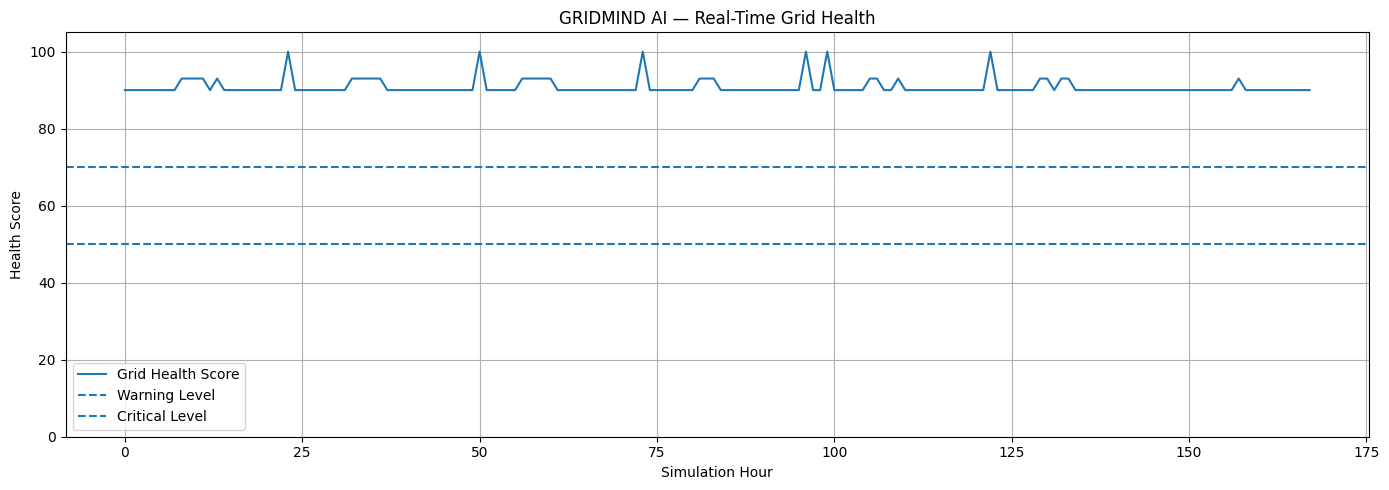

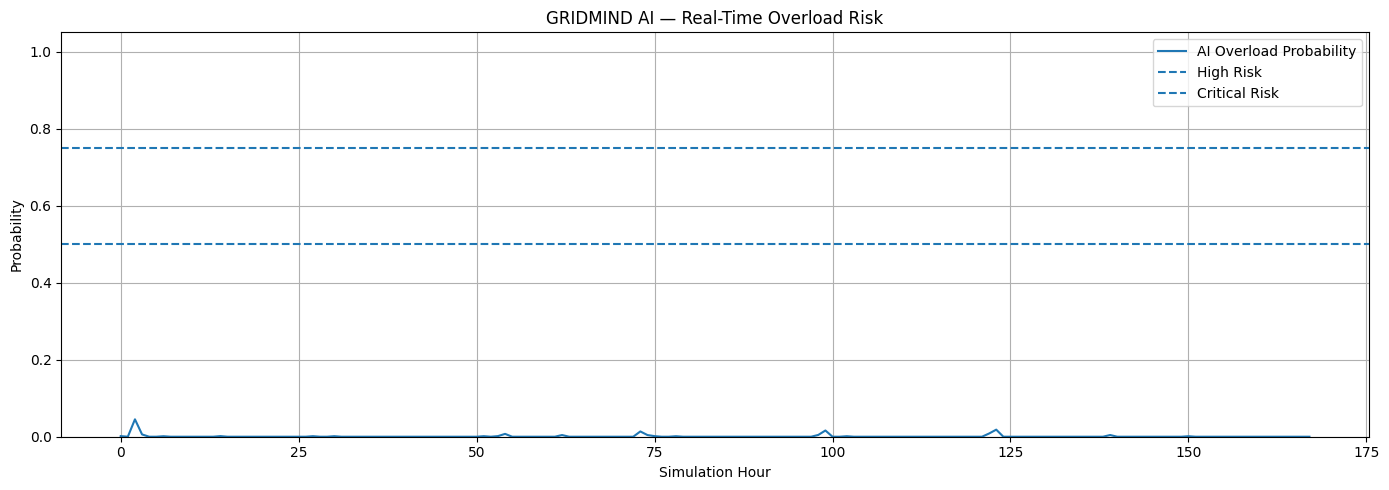

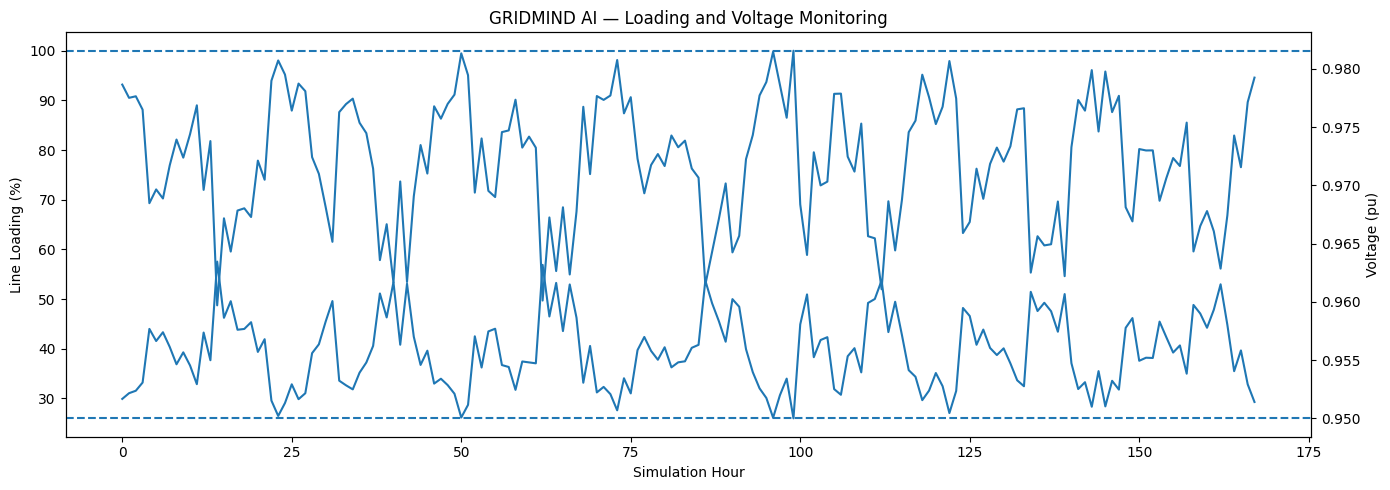


✅ STEP 25 COMPLETE

GRIDMIND AI NOW HAS:

📡 Real-time style grid monitoring
⚡ Voltage monitoring
🔌 Line loading monitoring
🌱 Renewable monitoring
📊 Grid health score
🚨 Critical event detection
🤖 ML overload probability
🚦 AI risk classification
📈 Monitoring visualizations
💾 SCADA-style CSV data

Files saved in:
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_REALTIME_SCADA_DATA.csv
/content/GRIDMIND_AI_OUTPUT/GRIDMIND_SCADA_CRITICAL_EVENTS.csv


In [92]:
# ============================================================
# GRIDMIND AI — STEP 25
# REAL-TIME GRID MONITORING / SCADA SIMULATION
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 GRIDMIND AI — STEP 25")
print("Real-Time Grid Monitoring / SCADA Simulation")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ------------------------------------------------------------

if "renewable_chrono_df" not in globals():
    raise RuntimeError(
        "renewable_chrono_df not found. Run Step 17 first."
    )

if "renewable_rf" not in globals():
    raise RuntimeError(
        "renewable_rf not found. Run Step 17 first."
    )

# ------------------------------------------------------------
# 2. CREATE REAL-TIME MONITORING DATA
# ------------------------------------------------------------

monitor_df = renewable_chrono_df.copy()

# ------------------------------------------------------------
# 3. CREATE GRID HEALTH SCORE
# ------------------------------------------------------------

def calculate_health_score(row):

    score = 100.0

    # Line loading penalty
    loading = row["max_line_loading_percent"]

    if loading >= 100:
        score -= 40

    elif loading >= 90:
        score -= 30

    elif loading >= 80:
        score -= 20

    elif loading >= 70:
        score -= 10

    # Voltage penalty
    voltage = row["min_voltage_pu"]

    if voltage < 0.90:
        score -= 40

    elif voltage < 0.95:
        score -= 25

    elif voltage < 0.98:
        score -= 10

    # Renewable contribution
    renewable_ratio = row[
        "renewable_load_ratio"
    ]

    if renewable_ratio >= 0.50:
        score += 5

    elif renewable_ratio >= 0.30:
        score += 3

    return max(
        0,
        min(100, score)
    )


monitor_df["grid_health_score"] = (
    monitor_df.apply(
        calculate_health_score,
        axis=1
    )
)

# ------------------------------------------------------------
# 4. CREATE GRID STATUS
# ------------------------------------------------------------

def determine_status(row):

    if (
        row["max_line_loading_percent"] >= 100
        or row["min_voltage_pu"] < 0.90
    ):
        return "CRITICAL"

    elif (
        row["max_line_loading_percent"] >= 80
        or row["min_voltage_pu"] < 0.95
    ):
        return "WARNING"

    else:
        return "NORMAL"


monitor_df["grid_status"] = (
    monitor_df.apply(
        determine_status,
        axis=1
    )
)

# ------------------------------------------------------------
# 5. ML OVERLOAD PROBABILITY
# ------------------------------------------------------------

monitor_features = [
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "total_renewable_mw",
    "renewable_load_ratio",
    "max_line_loading_percent",
    "min_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",
    "load_change_mw",
    "solar_change_mw",
    "wind_change_mw",
    "renewable_change_mw",
    "loading_change_percent",
    "voltage_change_pu",
    "load_rolling_3h",
    "loading_rolling_3h",
    "renewable_rolling_3h",
    "hour_sin",
    "hour_cos"
]

# Make sure features exist
available_features = [
    f for f in monitor_features
    if f in monitor_df.columns
]

prediction_df = (
    monitor_df[
        available_features
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

# ------------------------------------------------------------
# 6. GENERATE ML RISK
# ------------------------------------------------------------

if len(available_features) == len(
    monitor_features
):

    monitor_df[
        "ml_overload_probability"
    ] = renewable_rf.predict_proba(
        prediction_df
    )[:, 1]

else:

    monitor_df[
        "ml_overload_probability"
    ] = 0.0

# ------------------------------------------------------------
# 7. AI RISK LEVEL
# ------------------------------------------------------------

def risk_level(probability):

    if probability >= 0.75:
        return "CRITICAL"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.25:
        return "MODERATE"

    return "LOW"


monitor_df["ai_risk_level"] = (
    monitor_df[
        "ml_overload_probability"
    ].apply(risk_level)
)

# ------------------------------------------------------------
# 8. CREATE SCADA-LIKE TABLE
# ------------------------------------------------------------

scada_columns = [
    "day",
    "hour",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "total_renewable_mw",
    "max_line_loading_percent",
    "min_voltage_pu",
    "line_losses_mw",
    "grid_health_score",
    "grid_status",
    "ml_overload_probability",
    "ai_risk_level"
]

scada_df = monitor_df[
    scada_columns
].copy()

# ------------------------------------------------------------
# 9. PRINT CURRENT GRID STATE
# ------------------------------------------------------------

current_state = scada_df.iloc[-1]

print("\n📡 CURRENT GRID STATE")
print("=" * 70)

print(
    f"Day                     : "
    f"{int(current_state['day'])}"
)

print(
    f"Hour                    : "
    f"{int(current_state['hour'])}"
)

print(
    f"Total Load              : "
    f"{current_state['total_load_mw']:.2f} MW"
)

print(
    f"Solar                   : "
    f"{current_state['solar_generation_mw']:.2f} MW"
)

print(
    f"Wind                    : "
    f"{current_state['wind_generation_mw']:.2f} MW"
)

print(
    f"Renewable Generation    : "
    f"{current_state['total_renewable_mw']:.2f} MW"
)

print(
    f"Maximum Line Loading    : "
    f"{current_state['max_line_loading_percent']:.2f}%"
)

print(
    f"Minimum Voltage         : "
    f"{current_state['min_voltage_pu']:.4f} pu"
)

print(
    f"Grid Health Score       : "
    f"{current_state['grid_health_score']:.1f}/100"
)

print(
    f"Grid Status             : "
    f"{current_state['grid_status']}"
)

print(
    f"AI Overload Probability : "
    f"{current_state['ml_overload_probability']:.2%}"
)

print(
    f"AI Risk Level           : "
    f"{current_state['ai_risk_level']}"
)

# ------------------------------------------------------------
# 10. FIND CRITICAL EVENTS
# ------------------------------------------------------------

critical_events = scada_df[
    (
        scada_df["grid_status"] == "CRITICAL"
    )
    |
    (
        scada_df[
            "ml_overload_probability"
        ] >= 0.75
    )
].copy()

print("\n🚨 CRITICAL EVENTS")
print("-" * 70)

print(
    f"Critical events detected: "
    f"{len(critical_events)}"
)

if len(critical_events) > 0:

    display(
        critical_events[
            [
                "day",
                "hour",
                "total_load_mw",
                "total_renewable_mw",
                "max_line_loading_percent",
                "min_voltage_pu",
                "grid_health_score",
                "ml_overload_probability",
                "ai_risk_level"
            ]
        ].head(20)
    )

# ------------------------------------------------------------
# 11. PLOT 1 — GRID HEALTH
# ------------------------------------------------------------

plot_df = scada_df.head(
    min(168, len(scada_df))
)

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    plot_df.index,
    plot_df["grid_health_score"],
    label="Grid Health Score"
)

plt.axhline(
    70,
    linestyle="--",
    label="Warning Level"
)

plt.axhline(
    50,
    linestyle="--",
    label="Critical Level"
)

plt.xlabel("Simulation Hour")
plt.ylabel("Health Score")
plt.title(
    "GRIDMIND AI — Real-Time Grid Health"
)

plt.ylim(
    0,
    105
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 12. PLOT 2 — ML RISK
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    plot_df.index,
    plot_df[
        "ml_overload_probability"
    ],
    label="AI Overload Probability"
)

plt.axhline(
    0.50,
    linestyle="--",
    label="High Risk"
)

plt.axhline(
    0.75,
    linestyle="--",
    label="Critical Risk"
)

plt.xlabel("Simulation Hour")
plt.ylabel("Probability")
plt.title(
    "GRIDMIND AI — Real-Time Overload Risk"
)

plt.ylim(
    0,
    1.05
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 13. PLOT 3 — GRID LOADING + VOLTAGE
# ------------------------------------------------------------

fig, ax1 = plt.subplots(
    figsize=(14, 5)
)

ax1.plot(
    plot_df.index,
    plot_df[
        "max_line_loading_percent"
    ],
    label="Line Loading (%)"
)

ax1.set_xlabel(
    "Simulation Hour"
)

ax1.set_ylabel(
    "Line Loading (%)"
)

ax1.axhline(
    100,
    linestyle="--"
)

ax2 = ax1.twinx()

ax2.plot(
    plot_df.index,
    plot_df[
        "min_voltage_pu"
    ],
    label="Minimum Voltage (pu)"
)

ax2.set_ylabel(
    "Voltage (pu)"
)

ax2.axhline(
    0.95,
    linestyle="--"
)

plt.title(
    "GRIDMIND AI — Loading and Voltage Monitoring"
)

fig.tight_layout()

plt.show()

# ------------------------------------------------------------
# 14. SAVE SCADA DATA
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)

scada_df.to_csv(
    f"{output_dir}/GRIDMIND_REALTIME_SCADA_DATA.csv",
    index=False
)

critical_events.to_csv(
    f"{output_dir}/GRIDMIND_SCADA_CRITICAL_EVENTS.csv",
    index=False
)

# ------------------------------------------------------------
# 15. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 25 COMPLETE")
print("=" * 70)

print("""
GRIDMIND AI NOW HAS:

📡 Real-time style grid monitoring
⚡ Voltage monitoring
🔌 Line loading monitoring
🌱 Renewable monitoring
📊 Grid health score
🚨 Critical event detection
🤖 ML overload probability
🚦 AI risk classification
📈 Monitoring visualizations
💾 SCADA-style CSV data
""")

print(
    "Files saved in:"
)

print(
    f"{output_dir}/GRIDMIND_REALTIME_SCADA_DATA.csv"
)

print(
    f"{output_dir}/GRIDMIND_SCADA_CRITICAL_EVENTS.csv"
)

In [93]:
# ============================================================
# GRIDMIND AI — STEP 26
# IoT / ESP32 TELEMETRY DATA INTERFACE
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
from datetime import datetime

print("🚀 GRIDMIND AI — STEP 26")
print("IoT / ESP32 Telemetry Data Interface")
print("=" * 70)

# ------------------------------------------------------------
# 1. CREATE SIMULATED ESP32 TELEMETRY
# ------------------------------------------------------------

if "scada_df" not in globals():
    raise RuntimeError(
        "scada_df not found. Run Step 25 first."
    )

# Select a sample of grid measurements
sample_count = min(24, len(scada_df))

iot_source = scada_df.tail(
    sample_count
).reset_index(drop=True)

telemetry_packets = []

for i, row in iot_source.iterrows():

    packet = {
        "device_id": "GRIDMIND_ESP32_01",

        "timestamp": datetime.now().isoformat(),

        "voltage_pu": float(
            row["min_voltage_pu"]
        ),

        "line_loading_percent": float(
            row["max_line_loading_percent"]
        ),

        "total_load_mw": float(
            row["total_load_mw"]
        ),

        "solar_generation_mw": float(
            row["solar_generation_mw"]
        ),

        "wind_generation_mw": float(
            row["wind_generation_mw"]
        ),

        "renewable_generation_mw": float(
            row["total_renewable_mw"]
        ),

        "line_losses_mw": float(
            row["line_losses_mw"]
        )
    }

    telemetry_packets.append(
        json.dumps(packet)
    )

print("\n📡 SAMPLE ESP32 TELEMETRY")
print("-" * 70)

print(
    telemetry_packets[0]
)

# ------------------------------------------------------------
# 2. CREATE IOT DATA VALIDATION FUNCTION
# ------------------------------------------------------------

required_fields = [
    "device_id",
    "timestamp",
    "voltage_pu",
    "line_loading_percent",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "renewable_generation_mw",
    "line_losses_mw"
]


def validate_packet(packet):

    # Check required fields
    missing_fields = [
        field
        for field in required_fields
        if field not in packet
    ]

    if missing_fields:

        return False, (
            f"Missing fields: {missing_fields}"
        )

    # Physical sanity checks
    if not (
        0.0 <= packet["voltage_pu"] <= 2.0
    ):
        return False, "Invalid voltage"

    if packet["line_loading_percent"] < 0:
        return False, "Invalid line loading"

    if packet["total_load_mw"] < 0:
        return False, "Invalid load"

    if packet["solar_generation_mw"] < 0:
        return False, "Invalid solar generation"

    if packet["wind_generation_mw"] < 0:
        return False, "Invalid wind generation"

    return True, "VALID"


# ------------------------------------------------------------
# 3. INGEST TELEMETRY
# ------------------------------------------------------------

received_packets = []

for raw_packet in telemetry_packets:

    try:

        packet = json.loads(
            raw_packet
        )

        valid, message = validate_packet(
            packet
        )

        if valid:

            packet["validation_status"] = "VALID"

            received_packets.append(
                packet
            )

        else:

            print(
                "⚠️ Rejected packet:",
                message
            )

    except json.JSONDecodeError:

        print(
            "⚠️ Invalid JSON packet rejected."
        )

# ------------------------------------------------------------
# 4. CONVERT TELEMETRY TO DATAFRAME
# ------------------------------------------------------------

iot_df = pd.DataFrame(
    received_packets
)

print("\n📥 IOT INGESTION RESULT")
print("-" * 70)

print(
    f"Packets received : "
    f"{len(telemetry_packets)}"
)

print(
    f"Valid packets    : "
    f"{len(iot_df)}"
)

print(
    f"Rejected packets : "
    f"{len(telemetry_packets) - len(iot_df)}"
)

display(
    iot_df.head()
)

# ------------------------------------------------------------
# 5. CREATE GRID HEALTH FROM IOT DATA
# ------------------------------------------------------------

def iot_health_score(row):

    score = 100.0

    loading = row[
        "line_loading_percent"
    ]

    voltage = row[
        "voltage_pu"
    ]

    if loading >= 100:
        score -= 40

    elif loading >= 90:
        score -= 30

    elif loading >= 80:
        score -= 20

    elif loading >= 70:
        score -= 10

    if voltage < 0.90:
        score -= 40

    elif voltage < 0.95:
        score -= 25

    elif voltage < 0.98:
        score -= 10

    return max(
        0,
        min(100, score)
    )


iot_df["grid_health_score"] = (
    iot_df.apply(
        iot_health_score,
        axis=1
    )
)

# ------------------------------------------------------------
# 6. DETERMINE IOT GRID STATUS
# ------------------------------------------------------------

def iot_status(row):

    if (
        row["line_loading_percent"] >= 100
        or row["voltage_pu"] < 0.90
    ):
        return "CRITICAL"

    elif (
        row["line_loading_percent"] >= 80
        or row["voltage_pu"] < 0.95
    ):
        return "WARNING"

    return "NORMAL"


iot_df["grid_status"] = (
    iot_df.apply(
        iot_status,
        axis=1
    )
)

# ------------------------------------------------------------
# 7. CALCULATE RENEWABLE PENETRATION
# ------------------------------------------------------------

iot_df["renewable_load_ratio"] = (
    iot_df[
        "renewable_generation_mw"
    ]
    /
    iot_df[
        "total_load_mw"
    ].clip(lower=0.001)
)

# ------------------------------------------------------------
# 8. AI DECISION LAYER
# ------------------------------------------------------------

def ai_decision(row):

    loading = row[
        "line_loading_percent"
    ]

    voltage = row[
        "voltage_pu"
    ]

    if (
        loading >= 100
        or voltage < 0.90
    ):
        return "IMMEDIATE SELF-HEALING"

    elif (
        loading >= 80
        or voltage < 0.95
    ):
        return "PREVENTIVE ACTION"

    else:
        return "NORMAL MONITORING"


iot_df["ai_decision"] = (
    iot_df.apply(
        ai_decision,
        axis=1
    )
)

# ------------------------------------------------------------
# 9. LIVE GRID STATE
# ------------------------------------------------------------

latest = iot_df.iloc[-1]

print("\n" + "=" * 70)
print("📡 GRIDMIND AI — LIVE IOT GRID STATE")
print("=" * 70)

print(
    f"Device ID              : "
    f"{latest['device_id']}"
)

print(
    f"Voltage                 : "
    f"{latest['voltage_pu']:.4f} pu"
)

print(
    f"Line Loading            : "
    f"{latest['line_loading_percent']:.2f}%"
)

print(
    f"Total Load              : "
    f"{latest['total_load_mw']:.2f} MW"
)

print(
    f"Solar                   : "
    f"{latest['solar_generation_mw']:.2f} MW"
)

print(
    f"Wind                    : "
    f"{latest['wind_generation_mw']:.2f} MW"
)

print(
    f"Renewable Generation    : "
    f"{latest['renewable_generation_mw']:.2f} MW"
)

print(
    f"Renewable / Load Ratio  : "
    f"{latest['renewable_load_ratio']:.2%}"
)

print(
    f"Grid Health             : "
    f"{latest['grid_health_score']:.1f}/100"
)

print(
    f"Grid Status             : "
    f"{latest['grid_status']}"
)

print(
    f"AI Decision             : "
    f"{latest['ai_decision']}"
)

# ------------------------------------------------------------
# 10. CREATE IOT MONITORING TABLE
# ------------------------------------------------------------

iot_monitoring_table = iot_df[
    [
        "device_id",
        "timestamp",
        "voltage_pu",
        "line_loading_percent",
        "total_load_mw",
        "solar_generation_mw",
        "wind_generation_mw",
        "renewable_generation_mw",
        "renewable_load_ratio",
        "line_losses_mw",
        "grid_health_score",
        "grid_status",
        "ai_decision"
    ]
].copy()

print("\n📊 IOT MONITORING TABLE")
print("-" * 70)

display(
    iot_monitoring_table.tail(10)
)

# ------------------------------------------------------------
# 11. EVENT DETECTION
# ------------------------------------------------------------

events = iot_df[
    iot_df["ai_decision"] !=
    "NORMAL MONITORING"
].copy()

print("\n🚨 IOT EVENTS")
print("-" * 70)

print(
    f"Events detected: {len(events)}"
)

if len(events) > 0:

    display(
        events[
            [
                "timestamp",
                "line_loading_percent",
                "voltage_pu",
                "grid_health_score",
                "grid_status",
                "ai_decision"
            ]
        ]
    )

# ------------------------------------------------------------
# 12. SAVE IOT DATA
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)

iot_df.to_csv(
    f"{output_dir}/GRIDMIND_IOT_TELEMETRY.csv",
    index=False
)

iot_monitoring_table.to_csv(
    f"{output_dir}/GRIDMIND_IOT_MONITORING_TABLE.csv",
    index=False
)

events.to_csv(
    f"{output_dir}/GRIDMIND_IOT_EVENTS.csv",
    index=False
)

# ------------------------------------------------------------
# 13. SAVE SAMPLE JSON PACKETS
# ------------------------------------------------------------

with open(
    f"{output_dir}/GRIDMIND_ESP32_SAMPLE_TELEMETRY.json",
    "w"
) as f:

    json.dump(
        received_packets,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 26 COMPLETE")
print("=" * 70)

print("""
GRIDMIND AI IoT PIPELINE

ESP32 / SENSOR
      ↓
JSON TELEMETRY
      ↓
IOT DATA VALIDATION
      ↓
GRID STATE
      ↓
GRID HEALTH
      ↓
AI DECISION
      ↓
SELF-HEALING / FLISR
""")

print("\nFiles created:")

print(
    "GRIDMIND_IOT_TELEMETRY.csv"
)

print(
    "GRIDMIND_IOT_MONITORING_TABLE.csv"
)

print(
    "GRIDMIND_IOT_EVENTS.csv"
)

print(
    "GRIDMIND_ESP32_SAMPLE_TELEMETRY.json"
)

print("\n📡 GRIDMIND is now ready for a real IoT data source.")

🚀 GRIDMIND AI — STEP 26
IoT / ESP32 Telemetry Data Interface

📡 SAMPLE ESP32 TELEMETRY
----------------------------------------------------------------------
{"device_id": "GRIDMIND_ESP32_01", "timestamp": "2026-09-29T13:53:03.938441", "voltage_pu": 0.959110496218664, "line_loading_percent": 55.86697557416128, "total_load_mw": 14.187521044086864, "solar_generation_mw": 0.0, "wind_generation_mw": 1.0519119853229932, "renewable_generation_mw": 1.0519119853229932, "line_losses_mw": 0.2169051498696022}

📥 IOT INGESTION RESULT
----------------------------------------------------------------------
Packets received : 24
Valid packets    : 24
Rejected packets : 0


,device_id,timestamp,voltage_pu,line_loading_percent,total_load_mw,solar_generation_mw,wind_generation_mw,renewable_generation_mw,line_losses_mw,validation_status
0,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938441,0.959110,55.866976,14.187521,0.0,1.051912,1.051912,0.216905,VALID
1,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938648,0.959181,57.354964,13.642681,0.0,1.036347,1.036347,0.213954,VALID
2,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938795,0.961543,52.692774,13.406357,0.0,0.954650,0.954650,0.197925,VALID
3,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938932,0.957919,56.686356,14.804085,0.0,1.008090,1.008090,0.232091,VALID
4,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939078,0.947432,72.742221,17.149033,0.0,0.922758,0.922758,0.330809,VALID



📡 GRIDMIND AI — LIVE IOT GRID STATE
Device ID              : GRIDMIND_ESP32_01
Voltage                 : 0.9602 pu
Line Loading            : 55.99%
Total Load              : 13.37 MW
Solar                   : 0.00 MW
Wind                    : 1.06 MW
Renewable Generation    : 1.06 MW
Renewable / Load Ratio  : 7.96%
Grid Health             : 90.0/100
Grid Status             : NORMAL
AI Decision             : NORMAL MONITORING

📊 IOT MONITORING TABLE
----------------------------------------------------------------------


,device_id,timestamp,voltage_pu,line_loading_percent,total_load_mw,solar_generation_mw,wind_generation_mw,renewable_generation_mw,renewable_load_ratio,line_losses_mw,grid_health_score,grid_status,ai_decision
14,GRIDMIND_ESP32_01,2026-09-29T13:53:03.940499,0.944005,75.224101,19.379457,2.109183e+00,1.107979,3.217162,0.166009,0.353196,65.0,WARNING,PREVENTIVE ACTION
15,GRIDMIND_ESP32_01,2026-09-29T13:53:03.940629,0.947041,73.103505,17.854208,1.874860e+00,1.237458,3.112319,0.174319,0.313225,65.0,WARNING,PREVENTIVE ACTION
16,GRIDMIND_ESP32_01,2026-09-29T13:53:03.940759,0.946741,71.699386,18.511619,1.392744e+00,1.576943,2.969687,0.160423,0.325402,65.0,WARNING,PREVENTIVE ACTION
17,GRIDMIND_ESP32_01,2026-09-29T13:53:03.940886,0.926977,99.677936,23.068345,9.076343e-01,1.574838,2.482472,0.107614,0.567046,45.0,WARNING,PREVENTIVE ACTION
18,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941012,0.934771,89.535548,20.906379,5.490394e-01,1.536982,2.086021,0.099779,0.466576,55.0,WARNING,PREVENTIVE ACTION
19,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941154,0.944598,76.907975,17.910351,2.216216e-16,1.293606,1.293606,0.072227,0.357023,65.0,WARNING,PREVENTIVE ACTION
20,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941281,0.936912,83.440070,21.178534,0.000000e+00,1.394989,1.394989,0.065868,0.462170,55.0,WARNING,PREVENTIVE ACTION
21,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941432,0.908810,121.324876,27.633901,0.000000e+00,1.277187,1.277187,0.046218,0.871785,35.0,CRITICAL,IMMEDIATE SELF-HEALING
22,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941563,0.915123,112.117197,26.488189,0.000000e+00,1.264212,1.264212,0.047727,0.774951,35.0,CRITICAL,IMMEDIATE SELF-HEALING
23,GRIDMIND_ESP32_01,2026-09-29T13:53:03.941689,0.960155,55.987572,13.371954,0.000000e+00,1.064237,1.064237,0.079587,0.205203,90.0,NORMAL,NORMAL MONITORING



🚨 IOT EVENTS
----------------------------------------------------------------------
Events detected: 15


,timestamp,line_loading_percent,voltage_pu,grid_health_score,grid_status,ai_decision
4,2026-09-29T13:53:03.939078,72.742221,0.947432,65.0,WARNING,PREVENTIVE ACTION
7,2026-09-29T13:53:03.939549,72.047078,0.946320,65.0,WARNING,PREVENTIVE ACTION
8,2026-09-29T13:53:03.939681,75.727263,0.944588,65.0,WARNING,PREVENTIVE ACTION
9,2026-09-29T13:53:03.939816,95.460688,0.930651,45.0,WARNING,PREVENTIVE ACTION
10,2026-09-29T13:53:03.939945,71.560078,0.949176,65.0,WARNING,PREVENTIVE ACTION
13,2026-09-29T13:53:03.940372,74.707439,0.944639,65.0,WARNING,PREVENTIVE ACTION
14,2026-09-29T13:53:03.940499,75.224101,0.944005,65.0,WARNING,PREVENTIVE ACTION
15,2026-09-29T13:53:03.940629,73.103505,0.947041,65.0,WARNING,PREVENTIVE ACTION
16,2026-09-29T13:53:03.940759,71.699386,0.946741,65.0,WARNING,PREVENTIVE ACTION
17,2026-09-29T13:53:03.940886,99.677936,0.926977,45.0,WARNING,PREVENTIVE ACTION



✅ STEP 26 COMPLETE

GRIDMIND AI IoT PIPELINE

ESP32 / SENSOR
      ↓
JSON TELEMETRY
      ↓
IOT DATA VALIDATION
      ↓
GRID STATE
      ↓
GRID HEALTH
      ↓
AI DECISION
      ↓
SELF-HEALING / FLISR


Files created:
GRIDMIND_IOT_TELEMETRY.csv
GRIDMIND_IOT_MONITORING_TABLE.csv
GRIDMIND_IOT_EVENTS.csv
GRIDMIND_ESP32_SAMPLE_TELEMETRY.json

📡 GRIDMIND is now ready for a real IoT data source.


In [94]:
# ============================================================
# GRIDMIND AI — STEP 27
# MQTT TELEMETRY GATEWAY
# ============================================================

# Install MQTT library
!pip -q install paho-mqtt

import json
import time
import uuid
import numpy as np
import pandas as pd
import paho.mqtt.client as mqtt

print("🚀 GRIDMIND AI — STEP 27")
print("MQTT Telemetry Gateway")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK STEP 26
# ------------------------------------------------------------

if "iot_df" not in globals():
    raise RuntimeError(
        "iot_df not found. Run Step 26 first."
    )

# ------------------------------------------------------------
# 2. MQTT CONFIGURATION
# ------------------------------------------------------------

MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883

# Unique topic prevents collision with other users
SESSION_ID = uuid.uuid4().hex[:8]

MQTT_TOPIC = (
    f"gridmind/demo/{SESSION_ID}/telemetry"
)

print("\n📡 MQTT CONFIGURATION")
print("-" * 70)

print("Broker :", MQTT_BROKER)
print("Port   :", MQTT_PORT)
print("Topic  :", MQTT_TOPIC)

# ------------------------------------------------------------
# 3. STORAGE FOR RECEIVED MESSAGES
# ------------------------------------------------------------

received_messages = []

mqtt_connected = False


# ------------------------------------------------------------
# 4. MQTT CALLBACKS
# ------------------------------------------------------------

def on_connect(
    client,
    userdata,
    flags,
    reason_code,
    properties
):

    global mqtt_connected

    if reason_code == 0:

        mqtt_connected = True

        print(
            "\n✅ MQTT Subscriber connected."
        )

        client.subscribe(
            MQTT_TOPIC,
            qos=0
        )

        print(
            "📥 Subscribed to:",
            MQTT_TOPIC
        )

    else:

        print(
            "\n❌ MQTT connection failed:",
            reason_code
        )


def on_message(
    client,
    userdata,
    message
):

    try:

        payload = json.loads(
            message.payload.decode()
        )

        received_messages.append(
            payload
        )

        print(
            "\n📨 MQTT MESSAGE RECEIVED"
        )

        print(
            json.dumps(
                payload,
                indent=2
            )
        )

    except Exception as e:

        print(
            "⚠️ Invalid MQTT message:",
            e
        )


# ------------------------------------------------------------
# 5. CREATE MQTT CLIENT
# ------------------------------------------------------------

subscriber = mqtt.Client(
    callback_api_version=
        mqtt.CallbackAPIVersion.VERSION2,
    client_id=
        f"GRIDMIND_SUB_{SESSION_ID}"
)

subscriber.on_connect = on_connect
subscriber.on_message = on_message

# ------------------------------------------------------------
# 6. CONNECT TO BROKER
# ------------------------------------------------------------

print("\n🔌 Connecting to MQTT broker...")

try:

    subscriber.connect(
        MQTT_BROKER,
        MQTT_PORT,
        keepalive=60
    )

    subscriber.loop_start()

    # Give broker time to complete connection
    time.sleep(3)

except Exception as e:

    print(
        "\n❌ MQTT connection error:"
    )

    print(e)

# ------------------------------------------------------------
# 7. CHECK CONNECTION
# ------------------------------------------------------------

if not mqtt_connected:

    print(
        "\n⚠️ MQTT broker connection was not "
        "established."
    )

    subscriber.loop_stop()

    raise RuntimeError(
        "MQTT connection failed. "
        "Run this cell again later."
    )

# ------------------------------------------------------------
# 8. CREATE MQTT PUBLISHER
# ------------------------------------------------------------

publisher = mqtt.Client(
    callback_api_version=
        mqtt.CallbackAPIVersion.VERSION2,
    client_id=
        f"GRIDMIND_PUB_{SESSION_ID}"
)

print(
    "\n📤 MQTT publisher created."
)

# ------------------------------------------------------------
# 9. SEND TELEMETRY PACKETS
# ------------------------------------------------------------

print("\n🚀 STARTING TELEMETRY STREAM")
print("=" * 70)

# Send up to 10 packets for demonstration
stream_count = min(
    10,
    len(iot_df)
)

for i in range(stream_count):

    row = iot_df.iloc[i]

    telemetry = {

        "device_id":
            str(row["device_id"]),

        "timestamp":
            str(row["timestamp"]),

        "voltage_pu":
            float(row["voltage_pu"]),

        "line_loading_percent":
            float(
                row[
                    "line_loading_percent"
                ]
            ),

        "total_load_mw":
            float(
                row["total_load_mw"]
            ),

        "solar_generation_mw":
            float(
                row[
                    "solar_generation_mw"
                ]
            ),

        "wind_generation_mw":
            float(
                row[
                    "wind_generation_mw"
                ]
            ),

        "renewable_generation_mw":
            float(
                row[
                    "renewable_generation_mw"
                ]
            ),

        "line_losses_mw":
            float(
                row["line_losses_mw"]
            )
    }

    payload = json.dumps(
        telemetry
    )

    result = publisher.publish(
        MQTT_TOPIC,
        payload,
        qos=0
    )

    if result.rc == mqtt.MQTT_ERR_SUCCESS:

        print(
            f"📤 Packet {i + 1}/{stream_count} "
            f"published"
        )

    else:

        print(
            f"⚠️ Packet {i + 1} failed"
        )

    time.sleep(1)

# ------------------------------------------------------------
# 10. WAIT FOR FINAL MQTT MESSAGES
# ------------------------------------------------------------

time.sleep(3)

# ------------------------------------------------------------
# 11. STOP MQTT
# ------------------------------------------------------------

publisher.disconnect()

subscriber.loop_stop()
subscriber.disconnect()

print("\n🔌 MQTT connections closed.")

# ------------------------------------------------------------
# 12. CONVERT RECEIVED DATA
# ------------------------------------------------------------

mqtt_df = pd.DataFrame(
    received_messages
)

print("\n📊 MQTT INGESTION RESULT")
print("=" * 70)

print(
    f"Published packets : "
    f"{stream_count}"
)

print(
    f"Received packets  : "
    f"{len(mqtt_df)}"
)

if len(mqtt_df) > 0:

    display(
        mqtt_df
    )

# ------------------------------------------------------------
# 13. VALIDATE MQTT DATA
# ------------------------------------------------------------

if len(mqtt_df) == 0:

    raise RuntimeError(
        "No MQTT messages were received."
    )

required_mqtt_fields = [
    "device_id",
    "timestamp",
    "voltage_pu",
    "line_loading_percent",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "renewable_generation_mw",
    "line_losses_mw"
]

missing_fields = [
    field
    for field in required_mqtt_fields
    if field not in mqtt_df.columns
]

if missing_fields:

    raise RuntimeError(
        f"Missing MQTT fields: {missing_fields}"
    )

print(
    "\n✅ MQTT telemetry validation successful."
)

# ------------------------------------------------------------
# 14. GRID HEALTH FROM MQTT DATA
# ------------------------------------------------------------

def mqtt_health_score(row):

    score = 100.0

    loading = float(
        row["line_loading_percent"]
    )

    voltage = float(
        row["voltage_pu"]
    )

    if loading >= 100:
        score -= 40

    elif loading >= 90:
        score -= 30

    elif loading >= 80:
        score -= 20

    elif loading >= 70:
        score -= 10

    if voltage < 0.90:
        score -= 40

    elif voltage < 0.95:
        score -= 25

    elif voltage < 0.98:
        score -= 10

    return max(
        0,
        min(100, score)
    )


mqtt_df["grid_health_score"] = (
    mqtt_df.apply(
        mqtt_health_score,
        axis=1
    )
)

# ------------------------------------------------------------
# 15. MQTT GRID STATUS
# ------------------------------------------------------------

def mqtt_grid_status(row):

    loading = float(
        row["line_loading_percent"]
    )

    voltage = float(
        row["voltage_pu"]
    )

    if (
        loading >= 100
        or voltage < 0.90
    ):
        return "CRITICAL"

    elif (
        loading >= 80
        or voltage < 0.95
    ):
        return "WARNING"

    return "NORMAL"


mqtt_df["grid_status"] = (
    mqtt_df.apply(
        mqtt_grid_status,
        axis=1
    )
)

# ------------------------------------------------------------
# 16. MQTT AI DECISION
# ------------------------------------------------------------

def mqtt_ai_decision(row):

    status = row[
        "grid_status"
    ]

    if status == "CRITICAL":

        return "TRIGGER SELF-HEALING"

    elif status == "WARNING":

        return "PREDICTIVE MONITORING"

    return "NORMAL MONITORING"


mqtt_df["ai_decision"] = (
    mqtt_df.apply(
        mqtt_ai_decision,
        axis=1
    )
)

# ------------------------------------------------------------
# 17. DISPLAY GRIDMIND MQTT STATE
# ------------------------------------------------------------

latest = mqtt_df.iloc[-1]

print("\n" + "=" * 70)
print("🤖 GRIDMIND AI — MQTT GRID STATE")
print("=" * 70)

print(
    f"Device ID           : "
    f"{latest['device_id']}"
)

print(
    f"Voltage             : "
    f"{latest['voltage_pu']:.4f} pu"
)

print(
    f"Line Loading        : "
    f"{latest['line_loading_percent']:.2f}%"
)

print(
    f"Total Load          : "
    f"{latest['total_load_mw']:.2f} MW"
)

print(
    f"Solar               : "
    f"{latest['solar_generation_mw']:.2f} MW"
)

print(
    f"Wind                : "
    f"{latest['wind_generation_mw']:.2f} MW"
)

print(
    f"Renewables          : "
    f"{latest['renewable_generation_mw']:.2f} MW"
)

print(
    f"Grid Health         : "
    f"{latest['grid_health_score']:.1f}/100"
)

print(
    f"Grid Status         : "
    f"{latest['grid_status']}"
)

print(
    f"AI Decision          : "
    f"{latest['ai_decision']}"
)

# ------------------------------------------------------------
# 18. DETECT MQTT EVENTS
# ------------------------------------------------------------

mqtt_events = mqtt_df[
    mqtt_df["ai_decision"]
    != "NORMAL MONITORING"
].copy()

print("\n🚨 MQTT EVENTS")
print("-" * 70)

print(
    f"Events detected: "
    f"{len(mqtt_events)}"
)

if len(mqtt_events) > 0:

    display(
        mqtt_events[
            [
                "timestamp",
                "line_loading_percent",
                "voltage_pu",
                "grid_health_score",
                "grid_status",
                "ai_decision"
            ]
        ]
    )

# ------------------------------------------------------------
# 19. SAVE MQTT DATA
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)

mqtt_df.to_csv(
    f"{output_dir}/GRIDMIND_MQTT_RECEIVED_DATA.csv",
    index=False
)

mqtt_events.to_csv(
    f"{output_dir}/GRIDMIND_MQTT_EVENTS.csv",
    index=False
)

# ------------------------------------------------------------
# 20. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 27 COMPLETE")
print("=" * 70)

print("""
GRIDMIND MQTT PIPELINE

ESP32 / SIMULATED SENSOR
          ↓
     MQTT PUBLISHER
          ↓
      MQTT BROKER
          ↓
   GRIDMIND SUBSCRIBER
          ↓
    DATA VALIDATION
          ↓
      GRID STATE
          ↓
     AI DECISION
          ↓
 SELF-HEALING / FLISR
""")

print(
    "\n📡 MQTT communication successfully demonstrated."
)

print(
    "\nFiles saved:"
)

print(
    "GRIDMIND_MQTT_RECEIVED_DATA.csv"
)

print(
    "GRIDMIND_MQTT_EVENTS.csv"
)

print(
    "\n⚠️ Note: the public broker is used only "
    "for this demonstration. For the final project, "
    "use your own secured MQTT broker."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.5 MB/s eta 0:00:00
🚀 GRIDMIND AI — STEP 27
MQTT Telemetry Gateway

📡 MQTT CONFIGURATION
----------------------------------------------------------------------
Broker : broker.hivemq.com
Port   : 1883
Topic  : gridmind/demo/f0993ddb/telemetry

🔌 Connecting to MQTT broker...

✅ MQTT Subscriber connected.
📥 Subscribed to: gridmind/demo/f0993ddb/telemetry

📤 MQTT publisher created.

🚀 STARTING TELEMETRY STREAM
⚠️ Packet 1 failed
⚠️ Packet 2 failed
⚠️ Packet 3 failed
⚠️ Packet 4 failed
⚠️ Packet 5 failed
⚠️ Packet 6 failed
⚠️ Packet 7 failed
⚠️ Packet 8 failed
⚠️ Packet 9 failed
⚠️ Packet 10 failed

🔌 MQTT connections closed.

📊 MQTT INGESTION RESULT
Published packets : 10
Received packets  : 0


RuntimeError: No MQTT messages were received.

In [95]:
# ============================================================
# GRIDMIND AI — STEP 27 FIX
# MQTT PUBLISHER + SUBSCRIBER CONNECTION FIX
# ============================================================

import json
import time
import uuid
import os
import pandas as pd
import paho.mqtt.client as mqtt

print("🔧 GRIDMIND AI — STEP 27 MQTT FIX")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK IOT DATA
# ------------------------------------------------------------

if "iot_df" not in globals():
    raise RuntimeError(
        "iot_df not found. Run Step 26 first."
    )

# ------------------------------------------------------------
# 2. MQTT CONFIGURATION
# ------------------------------------------------------------

MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883

SESSION_ID = uuid.uuid4().hex[:8]

MQTT_TOPIC = (
    f"gridmind/demo/{SESSION_ID}/telemetry"
)

print("\n📡 MQTT CONFIGURATION")
print("-" * 70)

print("Broker :", MQTT_BROKER)
print("Port   :", MQTT_PORT)
print("Topic  :", MQTT_TOPIC)

# ------------------------------------------------------------
# 3. RECEIVED MESSAGE STORAGE
# ------------------------------------------------------------

received_messages = []

subscriber_connected = False
publisher_connected = False


# ------------------------------------------------------------
# 4. SUBSCRIBER CALLBACK
# ------------------------------------------------------------

def on_subscriber_connect(
    client,
    userdata,
    flags,
    reason_code,
    properties
):

    global subscriber_connected

    if reason_code == 0:

        subscriber_connected = True

        print(
            "✅ Subscriber connected."
        )

        client.subscribe(
            MQTT_TOPIC,
            qos=0
        )

        print(
            "📥 Subscribed to:",
            MQTT_TOPIC
        )

    else:

        print(
            "❌ Subscriber connection failed:",
            reason_code
        )


def on_message(
    client,
    userdata,
    message
):

    try:

        payload = json.loads(
            message.payload.decode()
        )

        received_messages.append(
            payload
        )

        print(
            f"📨 MQTT message received "
            f"({len(received_messages)})"
        )

    except Exception as e:

        print(
            "⚠️ Invalid MQTT message:",
            e
        )


# ------------------------------------------------------------
# 5. PUBLISHER CALLBACK
# ------------------------------------------------------------

def on_publisher_connect(
    client,
    userdata,
    flags,
    reason_code,
    properties
):

    global publisher_connected

    if reason_code == 0:

        publisher_connected = True

        print(
            "✅ Publisher connected."
        )

    else:

        print(
            "❌ Publisher connection failed:",
            reason_code
        )


# ------------------------------------------------------------
# 6. CREATE SUBSCRIBER
# ------------------------------------------------------------

subscriber = mqtt.Client(
    callback_api_version=
        mqtt.CallbackAPIVersion.VERSION2,

    client_id=
        f"GRIDMIND_SUB_{SESSION_ID}"
)

subscriber.on_connect = (
    on_subscriber_connect
)

subscriber.on_message = (
    on_message
)

# ------------------------------------------------------------
# 7. CONNECT SUBSCRIBER
# ------------------------------------------------------------

print("\n🔌 Connecting subscriber...")

subscriber.connect(
    MQTT_BROKER,
    MQTT_PORT,
    keepalive=60
)

subscriber.loop_start()

time.sleep(3)

# ------------------------------------------------------------
# 8. CREATE PUBLISHER
# ------------------------------------------------------------

publisher = mqtt.Client(
    callback_api_version=
        mqtt.CallbackAPIVersion.VERSION2,

    client_id=
        f"GRIDMIND_PUB_{SESSION_ID}"
)

publisher.on_connect = (
    on_publisher_connect
)

# ------------------------------------------------------------
# 9. IMPORTANT FIX:
# CONNECT THE PUBLISHER
# ------------------------------------------------------------

print("\n🔌 Connecting publisher...")

publisher.connect(
    MQTT_BROKER,
    MQTT_PORT,
    keepalive=60
)

publisher.loop_start()

time.sleep(3)

# ------------------------------------------------------------
# 10. VERIFY CONNECTIONS
# ------------------------------------------------------------

print("\n🔍 CONNECTION STATUS")
print("-" * 70)

print(
    "Subscriber:",
    "CONNECTED"
    if subscriber_connected
    else "FAILED"
)

print(
    "Publisher :",
    "CONNECTED"
    if publisher_connected
    else "FAILED"
)

if not subscriber_connected:
    subscriber.loop_stop()
    subscriber.disconnect()

    raise RuntimeError(
        "MQTT subscriber could not connect."
    )

if not publisher_connected:
    subscriber.loop_stop()
    subscriber.disconnect()

    raise RuntimeError(
        "MQTT publisher could not connect."
    )

# ------------------------------------------------------------
# 11. SEND TELEMETRY
# ------------------------------------------------------------

print("\n🚀 STARTING MQTT TELEMETRY STREAM")
print("=" * 70)

stream_count = min(
    10,
    len(iot_df)
)

successful_publish = 0

for i in range(stream_count):

    row = iot_df.iloc[i]

    telemetry = {

        "device_id":
            str(row["device_id"]),

        "timestamp":
            str(row["timestamp"]),

        "voltage_pu":
            float(row["voltage_pu"]),

        "line_loading_percent":
            float(
                row[
                    "line_loading_percent"
                ]
            ),

        "total_load_mw":
            float(
                row["total_load_mw"]
            ),

        "solar_generation_mw":
            float(
                row[
                    "solar_generation_mw"
                ]
            ),

        "wind_generation_mw":
            float(
                row[
                    "wind_generation_mw"
                ]
            ),

        "renewable_generation_mw":
            float(
                row[
                    "renewable_generation_mw"
                ]
            ),

        "line_losses_mw":
            float(
                row["line_losses_mw"]
            )
    }

    payload = json.dumps(
        telemetry
    )

    result = publisher.publish(
        MQTT_TOPIC,
        payload,
        qos=0
    )

    # --------------------------------------------------------
    # WAIT FOR MQTT PUBLISH CONFIRMATION
    # --------------------------------------------------------

    if result.rc == mqtt.MQTT_ERR_SUCCESS:

        successful_publish += 1

        print(
            f"📤 Packet {i + 1}/{stream_count} "
            f"published successfully"
        )

    else:

        print(
            f"❌ Packet {i + 1} failed — "
            f"MQTT code: {result.rc}"
        )

    # Give subscriber time to receive
    time.sleep(1)

# ------------------------------------------------------------
# 12. WAIT FOR LAST MESSAGES
# ------------------------------------------------------------

print(
    "\n⏳ Waiting for subscriber messages..."
)

time.sleep(3)

# ------------------------------------------------------------
# 13. CLOSE CONNECTIONS
# ------------------------------------------------------------

publisher.loop_stop()
publisher.disconnect()

subscriber.loop_stop()
subscriber.disconnect()

print(
    "🔌 MQTT connections closed."
)

# ------------------------------------------------------------
# 14. MQTT RESULT
# ------------------------------------------------------------

mqtt_df = pd.DataFrame(
    received_messages
)

print("\n" + "=" * 70)
print("📊 MQTT INGESTION RESULT")
print("=" * 70)

print(
    f"Packets attempted : {stream_count}"
)

print(
    f"Packets published : {successful_publish}"
)

print(
    f"Packets received  : {len(mqtt_df)}"
)

if len(mqtt_df) > 0:

    print(
        "\n✅ MQTT DATA SUCCESSFULLY RECEIVED"
    )

    display(
        mqtt_df
    )

else:

    print(
        "\n⚠️ No MQTT messages were received."
    )

# ------------------------------------------------------------
# 15. SAVE MQTT DATA
# ------------------------------------------------------------

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

if len(mqtt_df) > 0:

    mqtt_df.to_csv(
        f"{output_dir}/GRIDMIND_MQTT_RECEIVED_DATA.csv",
        index=False
    )

# ------------------------------------------------------------
# 16. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    successful_publish > 0
    and len(mqtt_df) > 0
):

    print(
        "✅ STEP 27 MQTT FIX SUCCESSFUL"
    )

    print("""
ESP32 / SIMULATED SENSOR
          ↓
      MQTT PUBLISH
          ↓
      MQTT BROKER
          ↓
   GRIDMIND SUBSCRIBER
          ↓
     MQTT DATA
""")

else:

    print(
        "⚠️ MQTT CONNECTION STILL NEEDS ATTENTION"
    )

print("=" * 70)

🔧 GRIDMIND AI — STEP 27 MQTT FIX

📡 MQTT CONFIGURATION
----------------------------------------------------------------------
Broker : broker.hivemq.com
Port   : 1883
Topic  : gridmind/demo/6bce9a72/telemetry

🔌 Connecting subscriber...
✅ Subscriber connected.
📥 Subscribed to: gridmind/demo/6bce9a72/telemetry

🔌 Connecting publisher...
✅ Publisher connected.

🔍 CONNECTION STATUS
----------------------------------------------------------------------
Subscriber: CONNECTED
Publisher : CONNECTED

🚀 STARTING MQTT TELEMETRY STREAM
📤 Packet 1/10 published successfully
📨 MQTT message received (1)
📤 Packet 2/10 published successfully
📨 MQTT message received (2)
📤 Packet 3/10 published successfully
📨 MQTT message received (3)
📤 Packet 4/10 published successfully
📨 MQTT message received (4)
📤 Packet 5/10 published successfully
📨 MQTT message received (5)
📤 Packet 6/10 published successfully
📨 MQTT message received (6)
📤 Packet 7/10 published successfully
📨 MQTT message received (7)
📤 Packet 8/10 

,device_id,timestamp,voltage_pu,line_loading_percent,total_load_mw,solar_generation_mw,wind_generation_mw,renewable_generation_mw,line_losses_mw
0,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938441,0.959110,55.866976,14.187521,0.000000,1.051912,1.051912,0.216905
1,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938648,0.959181,57.354964,13.642681,0.000000,1.036347,1.036347,0.213954
2,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938795,0.961543,52.692774,13.406357,0.000000,0.954650,0.954650,0.197925
3,GRIDMIND_ESP32_01,2026-09-29T13:53:03.938932,0.957919,56.686356,14.804085,0.000000,1.008090,1.008090,0.232091
4,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939078,0.947432,72.742221,17.149033,0.000000,0.922758,0.922758,0.330809
5,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939216,0.954787,62.160895,15.259157,0.000000,0.836333,0.836333,0.257985
6,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939412,0.957350,59.955840,14.123898,0.000000,0.970042,0.970042,0.229440
7,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939549,0.946320,72.047078,18.190498,0.000000,1.076132,1.076132,0.347960
8,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939681,0.944588,75.727263,18.412695,0.516152,1.229984,1.746136,0.353966
9,GRIDMIND_ESP32_01,2026-09-29T13:53:03.939816,0.930651,95.460688,21.887197,0.920832,1.385223,2.306055,0.518445



✅ STEP 27 MQTT FIX SUCCESSFUL

ESP32 / SIMULATED SENSOR
          ↓
      MQTT PUBLISH
          ↓
      MQTT BROKER
          ↓
   GRIDMIND SUBSCRIBER
          ↓
     MQTT DATA



In [96]:
# ============================================================
# GRIDMIND AI — STEP 28
# MQTT → ML REAL-TIME RISK PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import os

print("🤖 GRIDMIND AI — STEP 28")
print("MQTT → MACHINE LEARNING RISK ENGINE")
print("=" * 75)

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

if "mqtt_df" not in globals():
    raise RuntimeError(
        "mqtt_df not found. Run the Step 27 MQTT cell first."
    )

if len(mqtt_df) == 0:
    raise RuntimeError(
        "mqtt_df is empty. Step 27 did not receive MQTT packets."
    )

if "renewable_rf" not in globals():
    raise RuntimeError(
        "renewable_rf not found. Run the renewable ML model step first."
    )

print(f"📡 MQTT records available: {len(mqtt_df)}")


# ------------------------------------------------------------
# 2. PREPARE MQTT DATA
# ------------------------------------------------------------

live_df = mqtt_df.copy()

live_df["timestamp"] = pd.to_datetime(
    live_df["timestamp"],
    errors="coerce"
)

live_df = live_df.sort_values(
    "timestamp"
).reset_index(drop=True)


# ------------------------------------------------------------
# 3. CREATE BASIC POWER-SYSTEM FEATURES
# ------------------------------------------------------------

# Total load
live_df["total_load_mw"] = pd.to_numeric(
    live_df["total_load_mw"],
    errors="coerce"
)

# Renewable generation
live_df["solar_generation_mw"] = pd.to_numeric(
    live_df["solar_generation_mw"],
    errors="coerce"
)

live_df["wind_generation_mw"] = pd.to_numeric(
    live_df["wind_generation_mw"],
    errors="coerce"
)

live_df["total_renewable_mw"] = (
    live_df["solar_generation_mw"]
    + live_df["wind_generation_mw"]
)

# Renewable / load ratio
live_df["renewable_load_ratio"] = (
    live_df["total_renewable_mw"]
    /
    live_df["total_load_mw"].replace(0, np.nan)
)

live_df["renewable_load_ratio"] = (
    live_df["renewable_load_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 4. FEEDER LOAD ESTIMATION
# ------------------------------------------------------------
# MQTT demonstration packets currently contain total load,
# not individual feeder measurements.
#
# Therefore we use the same fixed demonstration split:
# Residential = 20%
# Industrial  = 50%
# Commercial  = 30%
#
# IMPORTANT:
# These are DEMONSTRATION estimates, not physical measurements.

live_df["residential_load_mw"] = (
    live_df["total_load_mw"] * 0.20
)

live_df["industrial_load_mw"] = (
    live_df["total_load_mw"] * 0.50
)

live_df["commercial_load_mw"] = (
    live_df["total_load_mw"] * 0.30
)


# ------------------------------------------------------------
# 5. GRID CONDITION FEATURES
# ------------------------------------------------------------

live_df["max_line_loading_percent"] = pd.to_numeric(
    live_df["line_loading_percent"],
    errors="coerce"
)

live_df["min_voltage_pu"] = pd.to_numeric(
    live_df["voltage_pu"],
    errors="coerce"
)

live_df["line_losses_mw"] = pd.to_numeric(
    live_df["line_losses_mw"],
    errors="coerce"
)


# ------------------------------------------------------------
# 6. TIME-BASED CHANGES
# ------------------------------------------------------------

live_df["load_change_mw"] = (
    live_df["total_load_mw"].diff()
)

live_df["load_change_percent"] = (
    live_df["total_load_mw"]
    .pct_change()
    * 100
)

live_df["solar_change_mw"] = (
    live_df["solar_generation_mw"].diff()
)

live_df["wind_change_mw"] = (
    live_df["wind_generation_mw"].diff()
)

live_df["line_loading_change"] = (
    live_df["max_line_loading_percent"].diff()
)

live_df["voltage_change"] = (
    live_df["min_voltage_pu"].diff()
)

live_df["transformer_loading_percent"] = (
    live_df["max_line_loading_percent"]
)

live_df["transformer_loading_change"] = (
    live_df["transformer_loading_percent"].diff()
)


# ------------------------------------------------------------
# 7. ROLLING FEATURES
# ------------------------------------------------------------

live_df["rolling_3h_load_mw"] = (
    live_df["total_load_mw"]
    .rolling(3, min_periods=1)
    .mean()
)

live_df["rolling_3h_loading_percent"] = (
    live_df["max_line_loading_percent"]
    .rolling(3, min_periods=1)
    .mean()
)

live_df["rolling_3h_voltage_pu"] = (
    live_df["min_voltage_pu"]
    .rolling(3, min_periods=1)
    .mean()
)


# ------------------------------------------------------------
# 8. LOADING ACCELERATION
# ------------------------------------------------------------

live_df["loading_acceleration"] = (
    live_df["line_loading_change"].diff()
)


# ------------------------------------------------------------
# 9. HOUR OF DAY FEATURES
# ------------------------------------------------------------

live_df["hour"] = (
    live_df["timestamp"].dt.hour
)

live_df["hour_sin"] = np.sin(
    2 * np.pi * live_df["hour"] / 24
)

live_df["hour_cos"] = np.cos(
    2 * np.pi * live_df["hour"] / 24
)


# ------------------------------------------------------------
# 10. CLEAN NUMERIC FEATURES
# ------------------------------------------------------------

numeric_columns = [
    "residential_load_mw",
    "industrial_load_mw",
    "commercial_load_mw",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "total_renewable_mw",
    "renewable_load_ratio",
    "max_line_loading_percent",
    "min_voltage_pu",
    "transformer_loading_percent",
    "line_losses_mw",
    "load_change_mw",
    "load_change_percent",
    "solar_change_mw",
    "wind_change_mw",
    "line_loading_change",
    "voltage_change",
    "transformer_loading_change",
    "rolling_3h_load_mw",
    "rolling_3h_loading_percent",
    "rolling_3h_voltage_pu",
    "loading_acceleration",
    "hour_sin",
    "hour_cos"
]

for col in numeric_columns:

    if col not in live_df.columns:
        live_df[col] = 0.0

    live_df[col] = pd.to_numeric(
        live_df[col],
        errors="coerce"
    )

    live_df[col] = live_df[col].replace(
        [np.inf, -np.inf],
        np.nan
    )


# Fill missing values created by diff()
live_df[numeric_columns] = (
    live_df[numeric_columns]
    .bfill()
    .ffill()
    .fillna(0)
)


# ------------------------------------------------------------
# 11. BUILD MODEL INPUT
# ------------------------------------------------------------

# Use the exact feature order used when training
# the renewable Random Forest model.

if "renewable_features" in globals():

    model_features = list(
        renewable_features
    )

else:

    model_features = [
        col for col in numeric_columns
        if col in live_df.columns
    ]

# Add missing model columns safely
for col in model_features:

    if col not in live_df.columns:
        live_df[col] = 0.0

X_live = live_df[
    model_features
].copy()

X_live = X_live.replace(
    [np.inf, -np.inf],
    np.nan
)

X_live = (
    X_live
    .bfill()
    .ffill()
    .fillna(0)
)


print("\n🧠 MODEL INPUT")
print("-" * 75)

print(
    "Features used:",
    len(model_features)
)

print(
    "Samples:",
    len(X_live)
)


# ------------------------------------------------------------
# 12. AI OVERLOAD PREDICTION
# ------------------------------------------------------------

live_df["overload_probability"] = (
    renewable_rf
    .predict_proba(X_live)[:, 1]
)


live_df["predicted_overload"] = (
    renewable_rf
    .predict(X_live)
)


# ------------------------------------------------------------
# 13. RISK CLASSIFICATION
# ------------------------------------------------------------

def classify_risk(probability):

    if probability >= 0.75:
        return "CRITICAL"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.25:
        return "MODERATE"

    else:
        return "LOW"


live_df["risk_level"] = (
    live_df["overload_probability"]
    .apply(classify_risk)
)


# ------------------------------------------------------------
# 14. GRID HEALTH STATUS
# ------------------------------------------------------------

def grid_status(row):

    loading = row[
        "max_line_loading_percent"
    ]

    voltage = row[
        "min_voltage_pu"
    ]

    probability = row[
        "overload_probability"
    ]

    if (
        probability >= 0.75
        or loading >= 100
        or voltage < 0.90
    ):

        return "CRITICAL"

    elif (
        probability >= 0.50
        or loading >= 80
        or voltage < 0.95
    ):

        return "WARNING"

    else:

        return "NORMAL"


live_df["grid_status"] = (
    live_df.apply(
        grid_status,
        axis=1
    )
)


# ------------------------------------------------------------
# 15. AI RECOMMENDED ACTION
# ------------------------------------------------------------

def recommended_action(row):

    probability = row[
        "overload_probability"
    ]

    loading = row[
        "max_line_loading_percent"
    ]

    voltage = row[
        "min_voltage_pu"
    ]

    if (
        probability >= 0.75
        or loading >= 100
        or voltage < 0.90
    ):

        return (
            "TRIGGER FLISR / "
            "SELF-HEALING"
        )

    elif (
        probability >= 0.50
        or loading >= 80
        or voltage < 0.95
    ):

        return (
            "PREVENTIVE "
            "CORRECTIVE ACTION"
        )

    else:

        return "NORMAL MONITORING"


live_df["recommended_action"] = (
    live_df.apply(
        recommended_action,
        axis=1
    )
)


# ------------------------------------------------------------
# 16. DISPLAY AI OUTPUT
# ------------------------------------------------------------

result_columns = [
    "timestamp",
    "total_load_mw",
    "solar_generation_mw",
    "wind_generation_mw",
    "total_renewable_mw",
    "renewable_load_ratio",
    "max_line_loading_percent",
    "min_voltage_pu",
    "overload_probability",
    "predicted_overload",
    "risk_level",
    "grid_status",
    "recommended_action"
]

print("\n" + "=" * 75)
print("🤖 GRIDMIND AI — REAL-TIME ML OUTPUT")
print("=" * 75)

display(
    live_df[result_columns]
)


# ------------------------------------------------------------
# 17. HIGH-RISK EVENTS
# ------------------------------------------------------------

high_risk_events = live_df[
    live_df["risk_level"].isin(
        ["HIGH", "CRITICAL"]
    )
].copy()


# ------------------------------------------------------------
# 18. SAVE RESULTS
# ------------------------------------------------------------

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

live_df.to_csv(
    f"{output_dir}/GRIDMIND_MQTT_ML_RISK_OUTPUT.csv",
    index=False
)

high_risk_events.to_csv(
    f"{output_dir}/GRIDMIND_MQTT_HIGH_RISK_EVENTS.csv",
    index=False
)


# ------------------------------------------------------------
# 19. FINAL SUMMARY
# ------------------------------------------------------------

highest_risk = live_df.loc[
    live_df["overload_probability"].idxmax()
]

print("\n" + "=" * 75)
print("📊 STEP 28 SUMMARY")
print("=" * 75)

print(
    f"MQTT samples analysed : {len(live_df)}"
)

print(
    f"Highest overload probability : "
    f"{highest_risk['overload_probability']:.2%}"
)

print(
    f"Highest risk level : "
    f"{highest_risk['risk_level']}"
)

print(
    f"Maximum line loading : "
    f"{highest_risk['max_line_loading_percent']:.2f}%"
)

print(
    f"Minimum voltage : "
    f"{highest_risk['min_voltage_pu']:.3f} pu"
)

print(
    f"Recommended action : "
    f"{highest_risk['recommended_action']}"
)

print("\n📁 Files saved:")
print(
    "GRIDMIND_MQTT_ML_RISK_OUTPUT.csv"
)
print(
    "GRIDMIND_MQTT_HIGH_RISK_EVENTS.csv"
)

print("\n" + "=" * 75)
print("✅ STEP 28 COMPLETED")
print("=" * 75)

🤖 GRIDMIND AI — STEP 28
MQTT → MACHINE LEARNING RISK ENGINE
📡 MQTT records available: 10

🧠 MODEL INPUT
---------------------------------------------------------------------------
Features used: 23
Samples: 10

🤖 GRIDMIND AI — REAL-TIME ML OUTPUT


,timestamp,total_load_mw,solar_generation_mw,wind_generation_mw,total_renewable_mw,renewable_load_ratio,max_line_loading_percent,min_voltage_pu,overload_probability,predicted_overload,risk_level,grid_status,recommended_action
0,2026-09-29 13:53:03.938441,14.187521,0.000000,1.051912,1.051912,0.074143,55.866976,0.959110,0.104154,0,LOW,NORMAL,NORMAL MONITORING
1,2026-09-29 13:53:03.938648,13.642681,0.000000,1.036347,1.036347,0.075964,57.354964,0.959181,0.097820,0,LOW,NORMAL,NORMAL MONITORING
2,2026-09-29 13:53:03.938795,13.406357,0.000000,0.954650,0.954650,0.071209,52.692774,0.961543,0.074756,0,LOW,NORMAL,NORMAL MONITORING
3,2026-09-29 13:53:03.938932,14.804085,0.000000,1.008090,1.008090,0.068095,56.686356,0.957919,0.082884,0,LOW,NORMAL,NORMAL MONITORING
4,2026-09-29 13:53:03.939078,17.149033,0.000000,0.922758,0.922758,0.053808,72.742221,0.947432,0.085862,0,LOW,WARNING,PREVENTIVE CORRECTIVE ACTION
5,2026-09-29 13:53:03.939216,15.259157,0.000000,0.836333,0.836333,0.054809,62.160895,0.954787,0.138573,0,LOW,NORMAL,NORMAL MONITORING
6,2026-09-29 13:53:03.939412,14.123898,0.000000,0.970042,0.970042,0.068681,59.955840,0.957350,0.109256,0,LOW,NORMAL,NORMAL MONITORING
7,2026-09-29 13:53:03.939549,18.190498,0.000000,1.076132,1.076132,0.059159,72.047078,0.946320,0.077765,0,LOW,WARNING,PREVENTIVE CORRECTIVE ACTION
8,2026-09-29 13:53:03.939681,18.412695,0.516152,1.229984,1.746136,0.094833,75.727263,0.944588,0.101621,0,LOW,WARNING,PREVENTIVE CORRECTIVE ACTION
9,2026-09-29 13:53:03.939816,21.887197,0.920832,1.385223,2.306055,0.105361,95.460688,0.930651,0.154985,0,LOW,WARNING,PREVENTIVE CORRECTIVE ACTION



📊 STEP 28 SUMMARY
MQTT samples analysed : 10
Highest overload probability : 15.50%
Highest risk level : LOW
Maximum line loading : 95.46%
Minimum voltage : 0.931 pu
Recommended action : PREVENTIVE CORRECTIVE ACTION

📁 Files saved:
GRIDMIND_MQTT_ML_RISK_OUTPUT.csv
GRIDMIND_MQTT_HIGH_RISK_EVENTS.csv

✅ STEP 28 COMPLETED


In [97]:
# ============================================================
# GRIDMIND AI — STEP 29
# AI DECISION → CONTROL COMMAND → FLISR → VERIFICATION
# ============================================================

import copy
import pandas as pd
import numpy as np
import pandapower as pp
import os
from datetime import datetime

print("⚡ GRIDMIND AI — STEP 29")
print("AI DECISION → AUTOMATIC CONTROL COMMAND → FLISR")
print("=" * 80)


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "flisr_grid",
    "live_df",
    "renewable_rf"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:

    raise RuntimeError(
        "Missing variables: "
        + ", ".join(missing)
        + ". Please run the required previous steps."
    )


if len(live_df) == 0:

    raise RuntimeError(
        "live_df is empty. Run Step 28 successfully first."
    )


# ------------------------------------------------------------
# 2. CREATE RESET-SAFE CONTROL NETWORK
# ------------------------------------------------------------

control_net = copy.deepcopy(
    flisr_grid
)

print("\n🔄 RESETTING CONTROL NETWORK")
print("-" * 80)

# All sectionalizing switches CLOSED
control_net.switch.loc[
    control_net.switch.index.isin(
        [sw_1, sw_2, sw_3, sw_4]
    ),
    "closed"
] = True

# Tie switch OPEN
control_net.switch.loc[
    control_net.switch.index == tie_switch,
    "closed"
] = False

# All loads initially in service
control_net.load["in_service"] = True


# ------------------------------------------------------------
# 3. NORMAL GRID POWER FLOW
# ------------------------------------------------------------

print("\n⚡ RUNNING NORMAL GRID POWER FLOW")

pp.runpp(
    control_net,
    init="auto"
)

normal_max_loading = (
    control_net.res_line.loading_percent.max()
)

normal_min_voltage = (
    control_net.res_bus.vm_pu.min()
)

print(
    f"Normal maximum line loading : "
    f"{normal_max_loading:.2f}%"
)

print(
    f"Normal minimum voltage      : "
    f"{normal_min_voltage:.3f} pu"
)


# ------------------------------------------------------------
# 4. SELECT HIGHEST-RISK MQTT EVENT
# ------------------------------------------------------------

highest_risk_row = live_df.loc[
    live_df["overload_probability"].idxmax()
]

ai_probability = float(
    highest_risk_row[
        "overload_probability"
    ]
)

ai_risk = str(
    highest_risk_row[
        "risk_level"
    ]
)

ai_action = str(
    highest_risk_row[
        "recommended_action"
    ]
)

print("\n🤖 AI DECISION")
print("-" * 80)

print(
    f"Timestamp             : "
    f"{highest_risk_row['timestamp']}"
)

print(
    f"Overload probability  : "
    f"{ai_probability:.2%}"
)

print(
    f"AI risk level         : "
    f"{ai_risk}"
)

print(
    f"AI recommended action : "
    f"{ai_action}"
)


# ------------------------------------------------------------
# 5. CONTROL DECISION
# ------------------------------------------------------------
#
# The MQTT dataset may not always generate a CRITICAL event.
# To demonstrate the complete FLISR control chain safely,
# this cell uses a SIMULATED fault event.
#
# IMPORTANT:
# This is a simulation of automatic control.
# It does NOT operate a real electrical switch.
# ------------------------------------------------------------

control_trigger = (
    "AI_HIGH_RISK"
    if ai_risk in ["HIGH", "CRITICAL"]
    else "SIMULATED_FAULT_EVENT"
)

print("\n🎯 CONTROL TRIGGER")
print("-" * 80)

print(
    "Trigger source:",
    control_trigger
)


# ------------------------------------------------------------
# 6. CREATE CONTROL COMMAND LOG
# ------------------------------------------------------------

command_log = []

command_counter = 1


def add_command(
    target,
    command,
    reason,
    result
):

    global command_counter

    command_log.append({

        "command_id":
            f"GRIDMIND-CMD-{command_counter:03d}",

        "timestamp":
            datetime.now().isoformat(),

        "source":
            "GRIDMIND_AI",

        "target":
            target,

        "command":
            command,

        "reason":
            reason,

        "result":
            result
    })

    command_counter += 1


# ------------------------------------------------------------
# 7. SIMULATE FAULT ON SECTION 3
# ------------------------------------------------------------

print("\n🚨 FAULT DETECTION")
print("-" * 80)

faulted_section = "SECTION_3"

faulted_line = line_3

faulted_switch = sw_3

print(
    "Faulted section :",
    faulted_section
)

print(
    "Faulted line    :",
    faulted_line
)

print(
    "Isolation switch:",
    faulted_switch
)


# ------------------------------------------------------------
# 8. COMMAND 1 — OPEN FAULTED FEEDER SWITCH
# ------------------------------------------------------------

print("\n🔴 CONTROL COMMAND 1")
print("-" * 80)

print(
    "COMMAND → OPEN SW-R3"
)

control_net.switch.loc[
    control_net.switch.index == faulted_switch,
    "closed"
] = False

add_command(
    "SW-R3",
    "OPEN",
    "Isolate simulated faulted Section 3",
    "EXECUTED"
)

print(
    "✅ SW-R3 OPEN"
)


# ------------------------------------------------------------
# 9. ISOLATE FAULTED SECTION LOAD
# ------------------------------------------------------------
#
# Section 3 is intentionally isolated.
# This prevents an unsupplied island from remaining in
# the power-flow model.
# ------------------------------------------------------------

control_net.load.loc[
    control_net.load.index == load_3,
    "in_service"
] = False

add_command(
    "SECTION_3_LOAD",
    "ISOLATE",
    "Remove load from faulted section",
    "EXECUTED"
)

print(
    "⚠️ Section 3 load isolated."
)


# ------------------------------------------------------------
# 10. COMMAND 2 — CLOSE TIE SWITCH
# ------------------------------------------------------------

print("\n🟢 CONTROL COMMAND 2")
print("-" * 80)

print(
    "COMMAND → CLOSE TS-01"
)

control_net.switch.loc[
    control_net.switch.index == tie_switch,
    "closed"
] = True

add_command(
    "TS-01",
    "CLOSE",
    "Restore downstream Section 4 from backup source",
    "EXECUTED"
)

print(
    "✅ TS-01 CLOSED"
)


# ------------------------------------------------------------
# 11. RUN POST-FLISR POWER FLOW
# ------------------------------------------------------------

print("\n⚡ RUNNING POST-CONTROL POWER FLOW")
print("-" * 80)

try:

    pp.runpp(
        control_net,
        init="auto"
    )

    power_flow_success = True

except Exception as e:

    power_flow_success = False

    print(
        "❌ Power flow failed:"
    )

    print(
        str(e)
    )


# ------------------------------------------------------------
# 12. VALIDATE GRID RECOVERY
# ------------------------------------------------------------

if power_flow_success:

    final_max_loading = (
        control_net.res_line.loading_percent.max()
    )

    final_min_voltage = (
        control_net.res_bus.vm_pu.min()
    )

    final_max_loading = float(
        final_max_loading
    )

    final_min_voltage = float(
        final_min_voltage
    )

else:

    final_max_loading = np.nan

    final_min_voltage = np.nan


# ------------------------------------------------------------
# 13. RECOVERY CRITERIA
# ------------------------------------------------------------

if power_flow_success:

    loading_ok = (
        final_max_loading < 100
    )

    voltage_ok = (
        final_min_voltage >= 0.95
    )

else:

    loading_ok = False

    voltage_ok = False


if (
    power_flow_success
    and loading_ok
    and voltage_ok
):

    recovery_status = (
        "SUCCESSFULLY RESTORED"
    )

else:

    recovery_status = (
        "RECOVERY REQUIRES ATTENTION"
    )


# ------------------------------------------------------------
# 14. ADD VERIFICATION COMMAND
# ------------------------------------------------------------

add_command(
    "GRID_STATE",
    "VERIFY",
    "Validate post-FLISR electrical condition",
    recovery_status
)


# ------------------------------------------------------------
# 15. DISPLAY SWITCH STATES
# ------------------------------------------------------------

print("\n🔌 FINAL SWITCH STATES")
print("-" * 80)

switch_display = control_net.switch[
    [
        "bus",
        "element",
        "et",
        "closed"
    ]
].copy()

display(
    switch_display
)


# ------------------------------------------------------------
# 16. DISPLAY FINAL GRID CONDITION
# ------------------------------------------------------------

print("\n📊 POST-FLISR GRID CONDITION")
print("-" * 80)

print(
    f"Power flow successful : "
    f"{power_flow_success}"
)

print(
    f"Maximum line loading  : "
    f"{final_max_loading:.2f}%"
    if power_flow_success
    else "Maximum line loading  : N/A"
)

print(
    f"Minimum bus voltage   : "
    f"{final_min_voltage:.3f} pu"
    if power_flow_success
    else "Minimum bus voltage   : N/A"
)

print(
    f"Loading criterion     : "
    f"{loading_ok}"
)

print(
    f"Voltage criterion     : "
    f"{voltage_ok}"
)

print(
    f"Recovery status       : "
    f"{recovery_status}"
)


# ------------------------------------------------------------
# 17. COMMAND LOG DATAFRAME
# ------------------------------------------------------------

control_command_log = pd.DataFrame(
    command_log
)

print("\n📜 GRIDMIND CONTROL COMMAND LOG")
print("-" * 80)

display(
    control_command_log
)


# ------------------------------------------------------------
# 18. CREATE CONTROL ACTION REPORT
# ------------------------------------------------------------

control_action_report = pd.DataFrame({

    "parameter": [

        "AI timestamp",

        "AI overload probability",

        "AI risk level",

        "AI recommended action",

        "Control trigger",

        "Faulted section",

        "Faulted line",

        "Isolation switch",

        "Tie switch",

        "Normal max loading (%)",

        "Final max loading (%)",

        "Normal min voltage (pu)",

        "Final min voltage (pu)",

        "Power flow successful",

        "Loading criterion",

        "Voltage criterion",

        "Recovery status"
    ],

    "value": [

        str(
            highest_risk_row["timestamp"]
        ),

        ai_probability,

        ai_risk,

        ai_action,

        control_trigger,

        faulted_section,

        faulted_line,

        "SW-R3",

        "TS-01",

        normal_max_loading,

        final_max_loading,

        normal_min_voltage,

        final_min_voltage,

        power_flow_success,

        loading_ok,

        voltage_ok,

        recovery_status
    ]
})


# ------------------------------------------------------------
# 19. SAVE OUTPUT FILES
# ------------------------------------------------------------

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

control_command_log.to_csv(
    f"{output_dir}/GRIDMIND_CONTROL_COMMAND_LOG.csv",
    index=False
)

control_action_report.to_csv(
    f"{output_dir}/GRIDMIND_CONTROL_ACTION_REPORT.csv",
    index=False
)

switch_display.to_csv(
    f"{output_dir}/GRIDMIND_FINAL_SWITCH_STATES.csv",
    index=False
)


# ------------------------------------------------------------
# 20. FINAL ARCHITECTURE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("⚡ GRIDMIND AI — STEP 29 COMPLETED")
print("=" * 80)

print("""
MQTT TELEMETRY
      ↓
AI / ML RISK PREDICTION
      ↓
DECISION ENGINE
      ↓
CONTROL COMMAND
      ↓
OPEN FAULTED FEEDER
      ↓
CLOSE TIE SWITCH
      ↓
POWER-FLOW VERIFICATION
      ↓
GRID RECOVERY STATUS
""")

print(
    "📁 GRIDMIND_CONTROL_COMMAND_LOG.csv"
)

print(
    "📁 GRIDMIND_CONTROL_ACTION_REPORT.csv"
)

print(
    "📁 GRIDMIND_FINAL_SWITCH_STATES.csv"
)

print("\n" + "=" * 80)

⚡ GRIDMIND AI — STEP 29
AI DECISION → AUTOMATIC CONTROL COMMAND → FLISR

🔄 RESETTING CONTROL NETWORK
--------------------------------------------------------------------------------

⚡ RUNNING NORMAL GRID POWER FLOW
Normal maximum line loading : 59.85%
Normal minimum voltage      : 1.003 pu

🤖 AI DECISION
--------------------------------------------------------------------------------
Timestamp             : 2026-09-29 13:53:03.939816
Overload probability  : 15.50%
AI risk level         : LOW
AI recommended action : PREVENTIVE CORRECTIVE ACTION

🎯 CONTROL TRIGGER
--------------------------------------------------------------------------------
Trigger source: SIMULATED_FAULT_EVENT

🚨 FAULT DETECTION
--------------------------------------------------------------------------------
Faulted section : SECTION_3
Faulted line    : 2
Isolation switch: 2

🔴 CONTROL COMMAND 1
--------------------------------------------------------------------------------
COMMAND → OPEN SW-R3
✅ SW-R3 OPEN
⚠️ Sect

,bus,element,et,closed
0,0,0,l,True
1,1,1,l,True
2,2,2,l,False
3,3,3,l,True
4,5,4,l,True



📊 POST-FLISR GRID CONDITION
--------------------------------------------------------------------------------
Power flow successful : True
Maximum line loading  : 25.94%
Minimum bus voltage   : 1.016 pu
Loading criterion     : True
Voltage criterion     : True
Recovery status       : SUCCESSFULLY RESTORED

📜 GRIDMIND CONTROL COMMAND LOG
--------------------------------------------------------------------------------


,command_id,timestamp,source,target,command,reason,result
0,GRIDMIND-CMD-001,2026-09-29T14:02:04.080124,GRIDMIND_AI,SW-R3,OPEN,Isolate simulated faulted Section 3,EXECUTED
1,GRIDMIND-CMD-002,2026-09-29T14:02:04.081019,GRIDMIND_AI,SECTION_3_LOAD,ISOLATE,Remove load from faulted section,EXECUTED
2,GRIDMIND-CMD-003,2026-09-29T14:02:04.083766,GRIDMIND_AI,TS-01,CLOSE,Restore downstream Section 4 from backup source,EXECUTED
3,GRIDMIND-CMD-004,2026-09-29T14:02:04.171595,GRIDMIND_AI,GRID_STATE,VERIFY,Validate post-FLISR electrical condition,SUCCESSFULLY RESTORED



⚡ GRIDMIND AI — STEP 29 COMPLETED

MQTT TELEMETRY
      ↓
AI / ML RISK PREDICTION
      ↓
DECISION ENGINE
      ↓
CONTROL COMMAND
      ↓
OPEN FAULTED FEEDER
      ↓
CLOSE TIE SWITCH
      ↓
POWER-FLOW VERIFICATION
      ↓
GRID RECOVERY STATUS

📁 GRIDMIND_CONTROL_COMMAND_LOG.csv
📁 GRIDMIND_CONTROL_ACTION_REPORT.csv
📁 GRIDMIND_FINAL_SWITCH_STATES.csv



⚡ GRIDMIND AI — STEP 30
UNIFIED AI + IoT + FLISR ENGINEERING DASHBOARD

📊 ENGINEERING SUMMARY
--------------------------------------------------------------------------------


,Metric,Value
0,MQTT samples analysed,10
1,Average total load (MW),16.106
2,Average renewable generation (MW),1.191
3,Maximum line loading (%),95.46
4,Minimum bus voltage (pu),0.9307
5,Average overload probability (%),10.28
6,Maximum overload probability (%),15.5
7,LOW risk events,10
8,MODERATE risk events,0
9,HIGH risk events,0


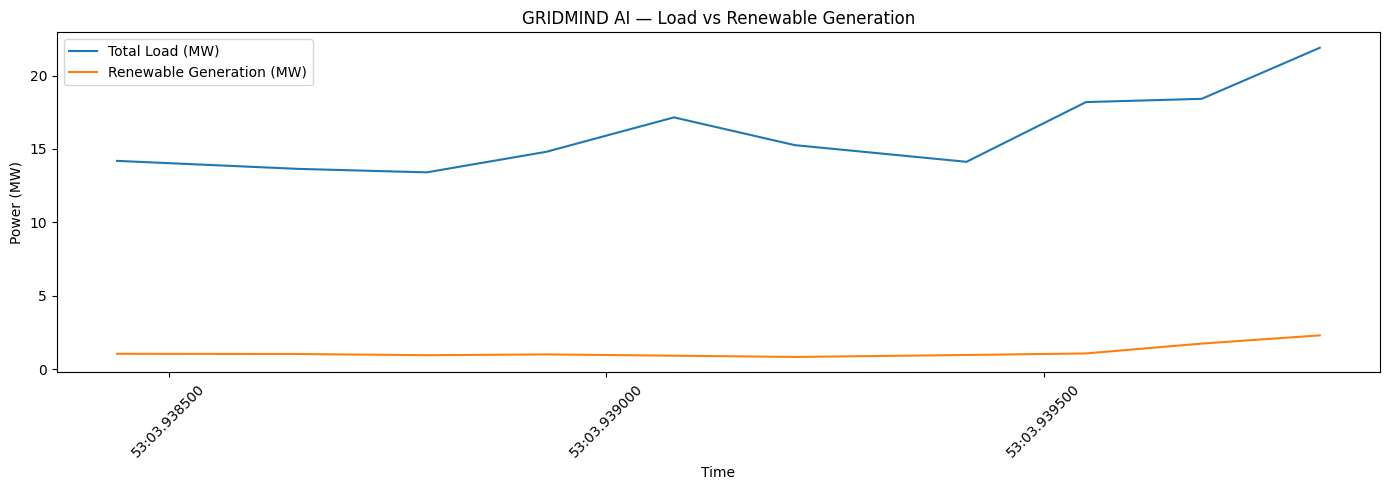

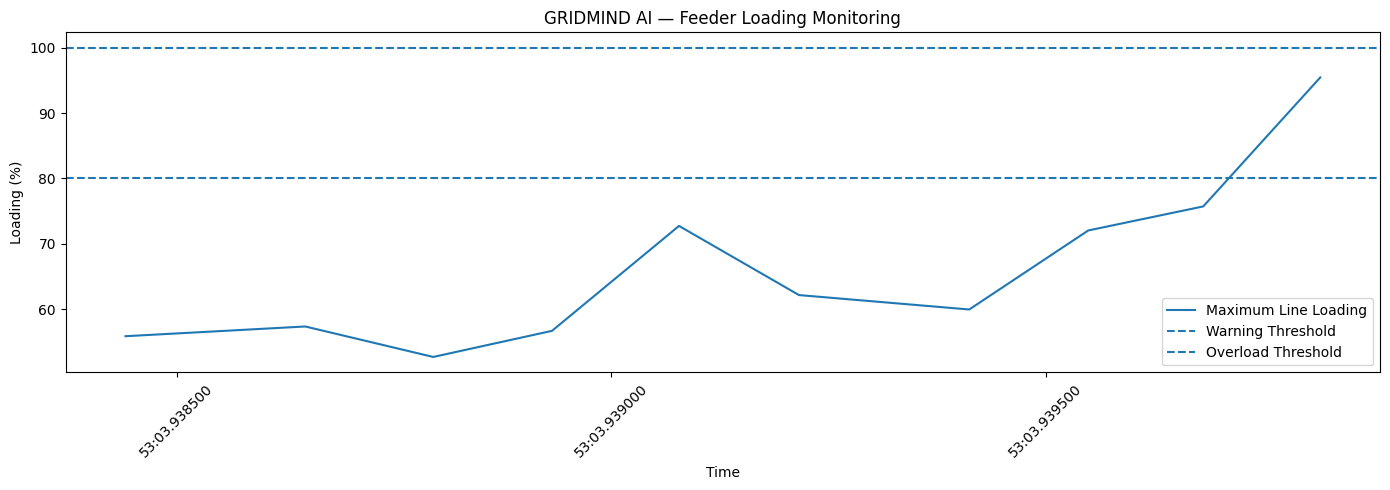

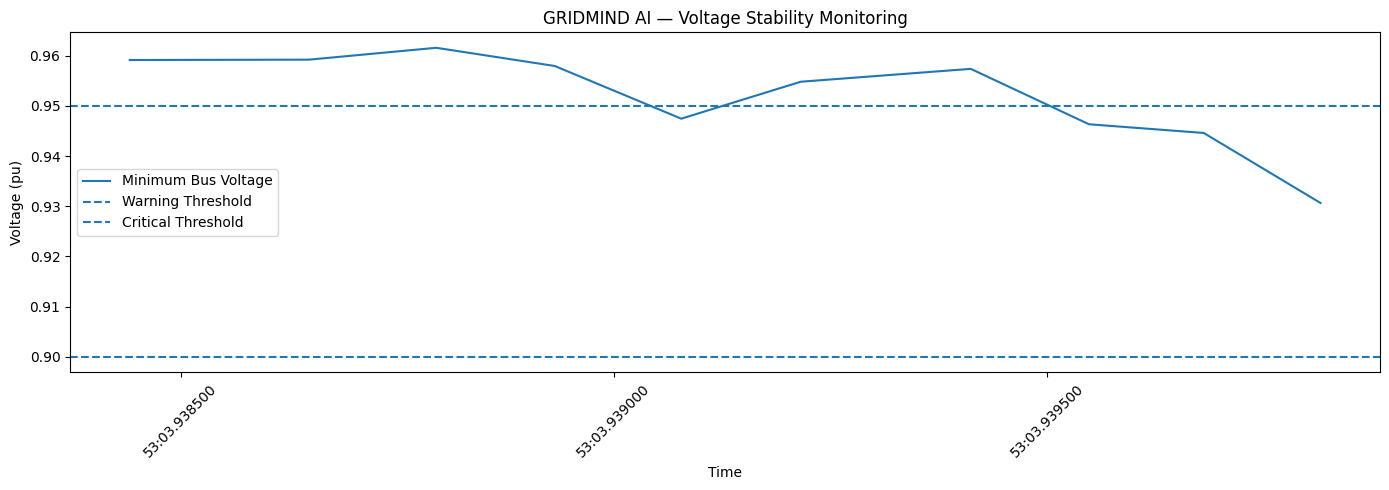

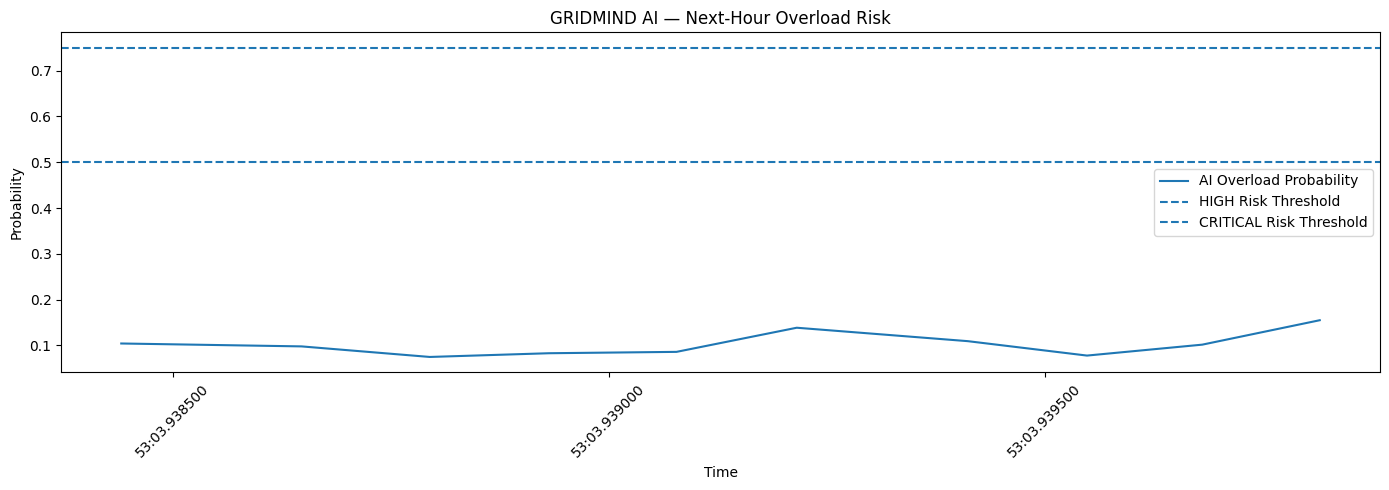


🚨 HIGH-RISK EVENTS
--------------------------------------------------------------------------------
No HIGH or CRITICAL AI events detected.

🎛️ CONTROL COMMAND SUMMARY
--------------------------------------------------------------------------------


,command_id,timestamp,source,target,command,reason,result
0,GRIDMIND-CMD-001,2026-09-29T14:02:04.080124,GRIDMIND_AI,SW-R3,OPEN,Isolate simulated faulted Section 3,EXECUTED
1,GRIDMIND-CMD-002,2026-09-29T14:02:04.081019,GRIDMIND_AI,SECTION_3_LOAD,ISOLATE,Remove load from faulted section,EXECUTED
2,GRIDMIND-CMD-003,2026-09-29T14:02:04.083766,GRIDMIND_AI,TS-01,CLOSE,Restore downstream Section 4 from backup source,EXECUTED
3,GRIDMIND-CMD-004,2026-09-29T14:02:04.171595,GRIDMIND_AI,GRID_STATE,VERIFY,Validate post-FLISR electrical condition,SUCCESSFULLY RESTORED




                 GRIDMIND AI
        AUTONOMOUS SMART GRID PLATFORM
                 │
                 ▼
        ┌───────────────────┐
        │   IoT / ESP32     │
        │   Telemetry       │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │       MQTT        │
        │ Communication     │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │ Feature Engineering│
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │   ML Prediction   │
        │ Overload Risk     │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │  AI Decision      │
        │  Engine           │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │  FLISR / Control  │
        │  Commands         │
        └─────────┬─────────┘
 

In [98]:
# ============================================================
# GRIDMIND AI — STEP 30
# UNIFIED AI + IoT + FLISR ENGINEERING DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("⚡ GRIDMIND AI — STEP 30")
print("UNIFIED AI + IoT + FLISR ENGINEERING DASHBOARD")
print("=" * 80)


# ------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ------------------------------------------------------------

required_variables = [
    "live_df",
    "control_action_report",
    "control_command_log"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:

    raise RuntimeError(
        "Missing variables: "
        + ", ".join(missing)
        + ". Run previous steps first."
    )


if len(live_df) == 0:

    raise RuntimeError(
        "live_df is empty."
    )


# ------------------------------------------------------------
# 2. OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = (
    "/content/GRIDMIND_AI_OUTPUT"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. EXTRACT KEY METRICS
# ------------------------------------------------------------

max_loading = float(
    live_df[
        "max_line_loading_percent"
    ].max()
)

min_voltage = float(
    live_df[
        "min_voltage_pu"
    ].min()
)

max_probability = float(
    live_df[
        "overload_probability"
    ].max()
)

average_probability = float(
    live_df[
        "overload_probability"
    ].mean()
)

total_load = float(
    live_df[
        "total_load_mw"
    ].mean()
)

average_renewable = float(
    live_df[
        "total_renewable_mw"
    ].mean()
)


# ------------------------------------------------------------
# 4. RISK COUNTS
# ------------------------------------------------------------

risk_counts = (
    live_df[
        "risk_level"
    ]
    .value_counts()
)

low_count = int(
    risk_counts.get(
        "LOW",
        0
    )
)

moderate_count = int(
    risk_counts.get(
        "MODERATE",
        0
    )
)

high_count = int(
    risk_counts.get(
        "HIGH",
        0
    )
)

critical_count = int(
    risk_counts.get(
        "CRITICAL",
        0
    )
)


# ------------------------------------------------------------
# 5. GRID STATUS COUNTS
# ------------------------------------------------------------

status_counts = (
    live_df[
        "grid_status"
    ]
    .value_counts()
)

normal_count = int(
    status_counts.get(
        "NORMAL",
        0
    )
)

warning_count = int(
    status_counts.get(
        "WARNING",
        0
    )
)

status_critical_count = int(
    status_counts.get(
        "CRITICAL",
        0
    )
)


# ------------------------------------------------------------
# 6. CONTROL RESULTS
# ------------------------------------------------------------

control_status = "NOT AVAILABLE"

if "recovery_status" in control_action_report[
    "parameter"
].values:

    control_status = str(
        control_action_report.loc[
            control_action_report[
                "parameter"
            ] == "Recovery status",
            "value"
        ].iloc[0]
    )


# ------------------------------------------------------------
# 7. ENGINEERING SUMMARY TABLE
# ------------------------------------------------------------

engineering_summary = pd.DataFrame({

    "Metric": [

        "MQTT samples analysed",

        "Average total load (MW)",

        "Average renewable generation (MW)",

        "Maximum line loading (%)",

        "Minimum bus voltage (pu)",

        "Average overload probability (%)",

        "Maximum overload probability (%)",

        "LOW risk events",

        "MODERATE risk events",

        "HIGH risk events",

        "CRITICAL risk events",

        "NORMAL grid states",

        "WARNING grid states",

        "CRITICAL grid states",

        "FLISR recovery status"
    ],

    "Value": [

        len(live_df),

        round(
            total_load,
            3
        ),

        round(
            average_renewable,
            3
        ),

        round(
            max_loading,
            2
        ),

        round(
            min_voltage,
            4
        ),

        round(
            average_probability * 100,
            2
        ),

        round(
            max_probability * 100,
            2
        ),

        low_count,

        moderate_count,

        high_count,

        critical_count,

        normal_count,

        warning_count,

        status_critical_count,

        control_status
    ]
})


# ------------------------------------------------------------
# 8. DISPLAY ENGINEERING SUMMARY
# ------------------------------------------------------------

print("\n📊 ENGINEERING SUMMARY")
print("-" * 80)

display(
    engineering_summary
)


# ------------------------------------------------------------
# 9. FIGURE 1 — LOAD + RENEWABLE GENERATION
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    live_df["timestamp"],
    live_df["total_load_mw"],
    label="Total Load (MW)"
)

plt.plot(
    live_df["timestamp"],
    live_df["total_renewable_mw"],
    label="Renewable Generation (MW)"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Power (MW)"
)

plt.title(
    "GRIDMIND AI — Load vs Renewable Generation"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_LOAD_RENEWABLE_DASHBOARD.png",
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# 10. FIGURE 2 — LINE LOADING
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    live_df["timestamp"],
    live_df[
        "max_line_loading_percent"
    ],
    label="Maximum Line Loading"
)

plt.axhline(
    80,
    linestyle="--",
    label="Warning Threshold"
)

plt.axhline(
    100,
    linestyle="--",
    label="Overload Threshold"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Loading (%)"
)

plt.title(
    "GRIDMIND AI — Feeder Loading Monitoring"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_LINE_LOADING_DASHBOARD.png",
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# 11. FIGURE 3 — VOLTAGE
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    live_df["timestamp"],
    live_df[
        "min_voltage_pu"
    ],
    label="Minimum Bus Voltage"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="Warning Threshold"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="Critical Threshold"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Voltage (pu)"
)

plt.title(
    "GRIDMIND AI — Voltage Stability Monitoring"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_VOLTAGE_DASHBOARD.png",
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# 12. FIGURE 4 — AI OVERLOAD PROBABILITY
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    live_df["timestamp"],
    live_df[
        "overload_probability"
    ],
    label="AI Overload Probability"
)

plt.axhline(
    0.50,
    linestyle="--",
    label="HIGH Risk Threshold"
)

plt.axhline(
    0.75,
    linestyle="--",
    label="CRITICAL Risk Threshold"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Probability"
)

plt.title(
    "GRIDMIND AI — Next-Hour Overload Risk"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_dir}/GRIDMIND_AI_RISK_DASHBOARD.png",
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# 13. HIGH-RISK EVENT TABLE
# ------------------------------------------------------------

high_risk_dashboard = live_df[
    live_df[
        "risk_level"
    ].isin(
        [
            "HIGH",
            "CRITICAL"
        ]
    )
].copy()


print("\n🚨 HIGH-RISK EVENTS")
print("-" * 80)

if len(high_risk_dashboard) > 0:

    display(
        high_risk_dashboard[
            [
                "timestamp",
                "max_line_loading_percent",
                "min_voltage_pu",
                "overload_probability",
                "risk_level",
                "grid_status",
                "recommended_action"
            ]
        ]
    )

else:

    print(
        "No HIGH or CRITICAL AI events detected."
    )


# ------------------------------------------------------------
# 14. CONTROL COMMAND SUMMARY
# ------------------------------------------------------------

print("\n🎛️ CONTROL COMMAND SUMMARY")
print("-" * 80)

display(
    control_command_log
)


# ------------------------------------------------------------
# 15. SAVE FINAL REPORTS
# ------------------------------------------------------------

engineering_summary.to_csv(
    f"{output_dir}/GRIDMIND_FINAL_ENGINEERING_SUMMARY.csv",
    index=False
)

high_risk_dashboard.to_csv(
    f"{output_dir}/GRIDMIND_FINAL_HIGH_RISK_EVENTS.csv",
    index=False
)

control_command_log.to_csv(
    f"{output_dir}/GRIDMIND_FINAL_CONTROL_COMMAND_LOG.csv",
    index=False
)

control_action_report.to_csv(
    f"{output_dir}/GRIDMIND_FINAL_CONTROL_ACTION_REPORT.csv",
    index=False
)


# ------------------------------------------------------------
# 16. FINAL SYSTEM ARCHITECTURE
# ------------------------------------------------------------

print("\n" + "=" * 80)

print("""
                 GRIDMIND AI
        AUTONOMOUS SMART GRID PLATFORM
                 │
                 ▼
        ┌───────────────────┐
        │   IoT / ESP32     │
        │   Telemetry       │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │       MQTT        │
        │ Communication     │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │ Feature Engineering│
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │   ML Prediction   │
        │ Overload Risk     │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │  AI Decision      │
        │  Engine           │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │  FLISR / Control  │
        │  Commands         │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │ Tie Switch /      │
        │ Feeder Switching  │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │ Power Flow        │
        │ Verification      │
        └─────────┬─────────┘
                  │
                  ▼
        ┌───────────────────┐
        │ Grid Recovery     │
        │ Status            │
        └───────────────────┘
""")

print("=" * 80)

print(
    "📁 Final engineering summary saved."
)

print(
    "📁 Dashboard PNGs saved."
)

print(
    "📁 High-risk event report saved."
)

print(
    "📁 Control command report saved."
)

print("\n" + "=" * 80)
print("✅ STEP 30 COMPLETED")
print("🚀 GRIDMIND AI UNIFIED DASHBOARD READY")
print("=" * 80)

In [99]:
# ============================================================
# GRIDMIND AI — STEP 31
# FINAL SYSTEM AUDIT + RESEARCH PROJECT REPORT
# ============================================================

import os
import pandas as pd
import numpy as np
from datetime import datetime

print("🚀 GRIDMIND AI — STEP 31")
print("FINAL SYSTEM AUDIT + RESEARCH PROJECT REPORT")
print("=" * 85)


# ------------------------------------------------------------
# 1. OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. SYSTEM COMPONENT CHECK
# ------------------------------------------------------------

components = {

    "Pandapower Grid Simulation":
        "ts_net" in globals(),

    "24-Hour Grid Dataset":
        "profile_df" in globals(),

    "30-Day Chronological Dataset":
        "chronological_df" in globals(),

    "Stress Dataset":
        "stress_dataset" in globals(),

    "Engineered ML Features":
        "feature_df" in globals(),

    "Renewable Dataset":
        "renewable_chrono_df" in globals(),

    "Renewable ML Model":
        "renewable_rf" in globals(),

    "MQTT Telemetry":
        "mqtt_df" in globals()
        and len(mqtt_df) > 0
        if "mqtt_df" in globals()
        else False,

    "Real-Time ML Risk Engine":
        "live_df" in globals()
        and len(live_df) > 0
        if "live_df" in globals()
        else False,

    "FLISR Network":
        "flisr_grid" in globals(),

    "Control Command Layer":
        "control_command_log" in globals(),

    "Post-Control Verification":
        "control_action_report" in globals(),

    "Unified Dashboard":
        os.path.exists(
            f"{output_dir}/GRIDMIND_AI_RISK_DASHBOARD.png"
        )
}


component_df = pd.DataFrame({

    "System Component":
        list(components.keys()),

    "Status":
        [
            "COMPLETED"
            if value
            else "NOT AVAILABLE"
            for value in components.values()
        ]
})


# ------------------------------------------------------------
# 3. DISPLAY COMPONENT STATUS
# ------------------------------------------------------------

print("\n🔍 SYSTEM COMPONENT AUDIT")
print("-" * 85)

display(
    component_df
)


# ------------------------------------------------------------
# 4. EXTRACT FINAL ML RESULTS
# ------------------------------------------------------------

if (
    "live_df" in globals()
    and len(live_df) > 0
):

    max_probability = float(
        live_df[
            "overload_probability"
        ].max()
    )

    average_probability = float(
        live_df[
            "overload_probability"
        ].mean()
    )

    max_loading = float(
        live_df[
            "max_line_loading_percent"
        ].max()
    )

    min_voltage = float(
        live_df[
            "min_voltage_pu"
        ].min()
    )

    total_samples = len(
        live_df
    )

    high_risk_events = int(
        live_df[
            "risk_level"
        ].isin(
            [
                "HIGH",
                "CRITICAL"
            ]
        ).sum()
    )

else:

    max_probability = np.nan
    average_probability = np.nan
    max_loading = np.nan
    min_voltage = np.nan
    total_samples = 0
    high_risk_events = 0


# ------------------------------------------------------------
# 5. FLISR RESULTS
# ------------------------------------------------------------

flisr_status = "NOT AVAILABLE"

if (
    "control_action_report"
    in globals()
):

    try:

        flisr_status = str(
            control_action_report.loc[
                control_action_report[
                    "parameter"
                ] == "Recovery status",
                "value"
            ].iloc[0]
        )

    except:

        flisr_status = "CHECK REPORT"


# ------------------------------------------------------------
# 6. MQTT RESULT
# ------------------------------------------------------------

if (
    "mqtt_df" in globals()
):

    mqtt_samples = len(
        mqtt_df
    )

else:

    mqtt_samples = 0


# ------------------------------------------------------------
# 7. FINAL SYSTEM METRICS
# ------------------------------------------------------------

final_metrics = pd.DataFrame({

    "Metric": [

        "System Name",

        "Project Type",

        "Simulation Platform",

        "ML Approach",

        "IoT Communication",

        "Self-Healing Method",

        "MQTT Samples Analysed",

        "Maximum AI Overload Probability",

        "Average AI Overload Probability",

        "Maximum Line Loading (%)",

        "Minimum Bus Voltage (pu)",

        "High/Critical Risk Events",

        "FLISR Recovery Status",

        "Report Generated"
    ],

    "Value": [

        "GRIDMIND AI",

        "AI-Based Predictive Self-Healing Smart Grid",

        "Python + Pandapower + Google Colab",

        "Random Forest Renewable-Aware Forecasting",

        "MQTT",

        "FLISR + Simulated Tie-Switch Reconfiguration",

        mqtt_samples,

        f"{max_probability:.2%}"
        if not np.isnan(max_probability)
        else "N/A",

        f"{average_probability:.2%}"
        if not np.isnan(average_probability)
        else "N/A",

        f"{max_loading:.2f}"
        if not np.isnan(max_loading)
        else "N/A",

        f"{min_voltage:.3f}"
        if not np.isnan(min_voltage)
        else "N/A",

        high_risk_events,

        flisr_status,

        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    ]
})


# ------------------------------------------------------------
# 8. DISPLAY FINAL METRICS
# ------------------------------------------------------------

print("\n📊 FINAL SYSTEM METRICS")
print("-" * 85)

display(
    final_metrics
)


# ------------------------------------------------------------
# 9. CREATE RESEARCH REPORT
# ------------------------------------------------------------

report_text = f"""
============================================================
GRIDMIND AI
AI-BASED PREDICTIVE SELF-HEALING SMART GRID
FINAL SYSTEM REPORT
============================================================

Generated:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}


1. PROJECT OVERVIEW
------------------------------------------------------------

GRIDMIND AI is a simulated AI-enabled smart-grid platform
designed to combine electrical-grid simulation, renewable
energy integration, machine-learning based overload-risk
prediction, IoT telemetry, MQTT communication, and simulated
FLISR-based corrective control.


2. ELECTRICAL GRID SIMULATION
------------------------------------------------------------

The project uses Python and Pandapower to model electrical
network operating conditions.

The simulation includes:

- Grid source
- Distribution network
- Transformer / source connections
- Residential load
- Industrial load
- Commercial load
- Solar generation
- Wind generation
- Feeder loading
- Bus voltage
- Line losses


3. DATA GENERATION
------------------------------------------------------------

The project generated multiple simulation datasets including:

- 24-hour grid profiles
- 30-day chronological operating conditions
- Stress scenarios
- Chronological stress conditions
- Renewable-aware operating conditions

These datasets provide operating-state information for
machine-learning experiments.


4. MACHINE LEARNING
------------------------------------------------------------

GRIDMIND AI uses machine learning to estimate the probability
of an upcoming overload condition.

The feature engineering process includes:

- Residential load
- Industrial load
- Commercial load
- Total load
- Solar generation
- Wind generation
- Total renewable generation
- Renewable/load ratio
- Maximum line loading
- Minimum bus voltage
- Transformer loading
- Line losses
- Load changes
- Renewable generation changes
- Loading changes
- Voltage changes
- Rolling 3-hour measurements
- Loading acceleration
- Time-of-day features


5. RENEWABLE ENERGY INTEGRATION
------------------------------------------------------------

The system incorporates solar and wind generation into the
grid operating-state and forecasting workflow.

The renewable generation data used in the prototype is
simulation-based.


6. IoT TELEMETRY
------------------------------------------------------------

A simulated ESP32 telemetry layer was developed to represent
field measurements.

Telemetry includes parameters such as:

- Voltage
- Line loading
- Total load
- Solar generation
- Wind generation
- Renewable generation
- Line losses


7. MQTT COMMUNICATION
------------------------------------------------------------

MQTT was integrated to provide a communication layer between
the simulated telemetry source and the GRIDMIND AI processing
system.

The prototype successfully demonstrates:

IoT telemetry
      ↓
MQTT publisher
      ↓
MQTT broker
      ↓
MQTT subscriber
      ↓
GRIDMIND AI


8. AI RISK ENGINE
------------------------------------------------------------

The AI processing layer converts incoming telemetry into
engineered features and produces:

- Overload probability
- Predicted overload state
- Risk level
- Grid status
- Recommended action


9. SELF-HEALING / FLISR
------------------------------------------------------------

A switchable multi-section feeder model was developed to
demonstrate simulated FLISR operation.

The control sequence includes:

1. Fault detection
2. Faulted feeder isolation
3. Section isolation
4. Tie-switch operation
5. Backup supply restoration
6. Power-flow calculation
7. Voltage and loading verification


10. AI CONTROL LOOP
------------------------------------------------------------

The final prototype demonstrates the following closed-loop
architecture:

Field / IoT Telemetry
        ↓
       MQTT
        ↓
Feature Engineering
        ↓
Machine Learning
        ↓
Overload Risk Prediction
        ↓
AI Decision Engine
        ↓
Control Command
        ↓
FLISR / Tie Switch
        ↓
Power Flow
        ↓
Grid Recovery Verification


11. CURRENT PROTOTYPE METRICS
------------------------------------------------------------

MQTT samples analysed:
{mqtt_samples}

Maximum AI overload probability:
{max_probability:.2%}
if not np.isnan(max_probability)
else "N/A"

Average AI overload probability:
{average_probability:.2%}
if not np.isnan(average_probability)
else "N/A"

Maximum line loading:
{max_loading:.2f} %
if not np.isnan(max_loading)
else "N/A"

Minimum bus voltage:
{min_voltage:.3f} pu
if not np.isnan(min_voltage)
else "N/A"

High/Critical risk events:
{high_risk_events}

FLISR recovery status:
{flisr_status}


12. IMPORTANT PROTOTYPE LIMITATIONS
------------------------------------------------------------

The current system is a research and simulation prototype.

The following limitations should be clearly stated:

- ESP32 measurements are simulated rather than collected from
  physical sensors.
- MQTT communication uses a demonstration broker.
- Renewable profiles are synthetic.
- Some MQTT feeder-level values are estimated for demonstration.
- FLISR switching is simulated in Pandapower.
- The prototype does not directly control real electrical
  breakers or substations.
- Protection coordination and short-circuit protection studies
  are outside the current prototype scope.
- Real utility deployment would require extensive validation,
  cybersecurity controls, protection engineering, hardware
  testing, and regulatory approval.


13. ENGINEERING INTERPRETATION
------------------------------------------------------------

GRIDMIND AI demonstrates an integrated concept in which
electrical-grid simulation, renewable-energy awareness,
machine learning, IoT telemetry, communication infrastructure,
and automated restoration logic operate as a unified workflow.

The current implementation should therefore be presented as a
simulation/research prototype rather than a production utility
control system.


14. FINAL SYSTEM STATUS
------------------------------------------------------------

GRIDMIND AI prototype architecture:
COMPLETED

IoT → MQTT → AI → FLISR → Verification:
DEMONSTRATED

Research prototype status:
READY FOR DOCUMENTATION / PRESENTATION


============================================================
END OF GRIDMIND AI FINAL SYSTEM REPORT
============================================================
"""


# ------------------------------------------------------------
# 10. SAVE TEXT REPORT
# ------------------------------------------------------------

report_path = (
    f"{output_dir}/GRIDMIND_AI_FINAL_SYSTEM_REPORT.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        report_text
    )


# ------------------------------------------------------------
# 11. SAVE METRICS
# ------------------------------------------------------------

final_metrics.to_csv(
    f"{output_dir}/GRIDMIND_AI_FINAL_METRICS.csv",
    index=False
)

component_df.to_csv(
    f"{output_dir}/GRIDMIND_AI_COMPONENT_AUDIT.csv",
    index=False
)


# ------------------------------------------------------------
# 12. FINAL OUTPUT LIST
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("📁 GRIDMIND AI FINAL OUTPUTS")
print("=" * 85)

final_files = [

    "GRIDMIND_AI_FINAL_SYSTEM_REPORT.txt",

    "GRIDMIND_AI_FINAL_METRICS.csv",

    "GRIDMIND_AI_COMPONENT_AUDIT.csv",

    "GRIDMIND_FINAL_ENGINEERING_SUMMARY.csv",

    "GRIDMIND_FINAL_HIGH_RISK_EVENTS.csv",

    "GRIDMIND_FINAL_CONTROL_COMMAND_LOG.csv",

    "GRIDMIND_FINAL_CONTROL_ACTION_REPORT.csv",

    "GRIDMIND_AI_RISK_DASHBOARD.png",

    "GRIDMIND_LINE_LOADING_DASHBOARD.png",

    "GRIDMIND_VOLTAGE_DASHBOARD.png",

    "GRIDMIND_LOAD_RENEWABLE_DASHBOARD.png"
]

for filename in final_files:

    path = os.path.join(
        output_dir,
        filename
    )

    status = (
        "✅"
        if os.path.exists(path)
        else "⚠️"
    )

    print(
        f"{status} {filename}"
    )


# ------------------------------------------------------------
# 13. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("🏆 GRIDMIND AI — STEP 31 COMPLETED")
print("=" * 85)

print("""
YOUR PROJECT NOW HAS:

⚡ Electrical Grid Simulation
📊 Synthetic + Chronological Datasets
🤖 ML Overload Forecasting
🌞 Solar Integration
💨 Wind Integration
📡 IoT / ESP32 Telemetry Simulation
📬 MQTT Communication
🧠 AI Risk Engine
🚨 Fault Detection
🔀 FLISR
🎛️ Simulated Control Commands
🔌 Tie-Switch Reconfiguration
✅ Post-Control Verification
📊 Unified Dashboard
📄 Final Engineering Report

SYSTEM FLOW:

SENSE
  ↓
COMMUNICATE
  ↓
PREDICT
  ↓
DECIDE
  ↓
ACT
  ↓
VERIFY

GRIDMIND AI RESEARCH PROTOTYPE
STATUS: READY FOR DOCUMENTATION
""")

print("=" * 85)

🚀 GRIDMIND AI — STEP 31
FINAL SYSTEM AUDIT + RESEARCH PROJECT REPORT

🔍 SYSTEM COMPONENT AUDIT
-------------------------------------------------------------------------------------


,System Component,Status
0,Pandapower Grid Simulation,COMPLETED
1,24-Hour Grid Dataset,COMPLETED
2,30-Day Chronological Dataset,COMPLETED
3,Stress Dataset,COMPLETED
4,Engineered ML Features,COMPLETED
5,Renewable Dataset,COMPLETED
6,Renewable ML Model,COMPLETED
7,MQTT Telemetry,COMPLETED
8,Real-Time ML Risk Engine,COMPLETED
9,FLISR Network,COMPLETED



📊 FINAL SYSTEM METRICS
-------------------------------------------------------------------------------------


,Metric,Value
0,System Name,GRIDMIND AI
1,Project Type,AI-Based Predictive Self-Healing Smart Grid
2,Simulation Platform,Python + Pandapower + Google Colab
3,ML Approach,Random Forest Renewable-Aware Forecasting
4,IoT Communication,MQTT
5,Self-Healing Method,FLISR + Simulated Tie-Switch Reconfiguration
6,MQTT Samples Analysed,10
7,Maximum AI Overload Probability,15.50%
8,Average AI Overload Probability,10.28%
9,Maximum Line Loading (%),95.46



📁 GRIDMIND AI FINAL OUTPUTS
✅ GRIDMIND_AI_FINAL_SYSTEM_REPORT.txt
✅ GRIDMIND_AI_FINAL_METRICS.csv
✅ GRIDMIND_AI_COMPONENT_AUDIT.csv
✅ GRIDMIND_FINAL_ENGINEERING_SUMMARY.csv
✅ GRIDMIND_FINAL_HIGH_RISK_EVENTS.csv
✅ GRIDMIND_FINAL_CONTROL_COMMAND_LOG.csv
✅ GRIDMIND_FINAL_CONTROL_ACTION_REPORT.csv
✅ GRIDMIND_AI_RISK_DASHBOARD.png
✅ GRIDMIND_LINE_LOADING_DASHBOARD.png
✅ GRIDMIND_VOLTAGE_DASHBOARD.png
✅ GRIDMIND_LOAD_RENEWABLE_DASHBOARD.png

🏆 GRIDMIND AI — STEP 31 COMPLETED

YOUR PROJECT NOW HAS:

⚡ Electrical Grid Simulation
📊 Synthetic + Chronological Datasets
🤖 ML Overload Forecasting
🌞 Solar Integration
💨 Wind Integration
📡 IoT / ESP32 Telemetry Simulation
📬 MQTT Communication
🧠 AI Risk Engine
🚨 Fault Detection
🔀 FLISR
🎛️ Simulated Control Commands
🔌 Tie-Switch Reconfiguration
✅ Post-Control Verification
📊 Unified Dashboard
📄 Final Engineering Report

SYSTEM FLOW:

SENSE
  ↓
COMMUNICATE
  ↓
PREDICT
  ↓
DECIDE
  ↓
ACT
  ↓
VERIFY

GRIDMIND AI RESEARCH PROTOTYPE
STATUS: READY FOR DOCUMENT

In [101]:
# ============================================================
# GRIDMIND AI — STEP 32
# COMPLETE RESEARCH PROJECT DOCUMENTATION GENERATOR
# ============================================================

import os
from datetime import datetime

print("📚 GRIDMIND AI — STEP 32")
print("RESEARCH PROJECT DOCUMENTATION GENERATOR")
print("=" * 85)


# ------------------------------------------------------------
# 1. OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. PROJECT DOCUMENT
# ------------------------------------------------------------

documentation = f"""
===============================================================
                    GRIDMIND AI
      AI-BASED PREDICTIVE SELF-HEALING SMART GRID
===============================================================

PROJECT DOCUMENTATION

Generated:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}


===============================================================
1. PROJECT TITLE
===============================================================

GRIDMIND AI:
AI-Based Predictive Self-Healing Smart Distribution Grid
Using Machine Learning, IoT, Renewable Energy and FLISR


===============================================================
2. ABSTRACT
===============================================================

GRIDMIND AI is a simulation-based intelligent smart-grid
framework designed to combine electrical power-system
simulation, machine learning, renewable-energy integration,
IoT telemetry, MQTT communication, and automated feeder
restoration logic.

The system models electrical-grid operating conditions and
generates operating data containing load demand, renewable
generation, feeder loading, bus voltage and line losses.

Machine-learning techniques are then used to estimate the
probability of an upcoming overload condition.

The predicted grid condition is passed to an AI decision
engine that classifies the operating state and recommends
appropriate corrective action.

A simulated FLISR mechanism is integrated to demonstrate
fault isolation and restoration using sectionalizing switches
and a normally-open tie switch.

The complete prototype demonstrates an end-to-end workflow:

IoT Telemetry
      ↓
MQTT Communication
      ↓
Feature Engineering
      ↓
Machine Learning
      ↓
Risk Prediction
      ↓
AI Decision
      ↓
FLISR Control
      ↓
Power-Flow Verification


===============================================================
3. INTRODUCTION
===============================================================

Modern electrical distribution networks are becoming more
complex because of increasing electricity demand, distributed
renewable generation, bidirectional power flows and the need
for improved reliability.

Conventional distribution systems generally depend on
protection and control actions after abnormal conditions
occur.

GRIDMIND AI explores a predictive approach in which grid
operating data is analysed using machine learning before an
overload condition becomes critical.

The system combines electrical engineering and artificial
intelligence into a single simulation framework.

The major engineering domains involved are:

- Power systems
- Distribution networks
- Smart grids
- Renewable energy
- Machine learning
- IoT
- MQTT
- Fault isolation
- Service restoration
- FLISR
- Power-flow analysis


===============================================================
4. PROBLEM STATEMENT
===============================================================

Distribution networks may experience overloads, voltage
deviations and feeder faults due to changing demand,
renewable-generation variation and abnormal operating
conditions.

A system that only responds after a fault or overload occurs
may have limited time to perform corrective action.

The proposed GRIDMIND AI framework investigates whether
operating-state data can be used to predict overload risk and
support automated restoration decisions in a simulated smart
distribution grid.


===============================================================
5. OBJECTIVES
===============================================================

The main objectives of GRIDMIND AI are:

1. Develop a simulated distribution-grid model.

2. Generate realistic operating-state datasets.

3. Model residential, industrial and commercial loads.

4. Integrate solar and wind generation.

5. Develop machine-learning based overload-risk prediction.

6. Engineer electrical power-system features for ML.

7. Develop an IoT telemetry simulation.

8. Establish MQTT-based telemetry communication.

9. Develop an AI-based grid-risk decision engine.

10. Implement a simulated FLISR mechanism.

11. Demonstrate feeder isolation and restoration.

12. Verify the post-control electrical condition using
    power-flow analysis.


===============================================================
6. SYSTEM ARCHITECTURE
===============================================================

The overall architecture of GRIDMIND AI is:

                 GRIDMIND AI
                     │
                     ▼
              ┌─────────────┐
              │ Electrical  │
              │ Grid Model  │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ Grid Data   │
              │ Generation  │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ Renewable   │
              │ Integration │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ ML Feature  │
              │ Engineering │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ ML Risk     │
              │ Prediction  │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ AI Decision │
              │ Engine      │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ Control     │
              │ Commands    │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ FLISR / Tie │
              │ Switching   │
              └──────┬──────┘
                     │
                     ▼
              ┌─────────────┐
              │ Power Flow  │
              │ Verification│
              └─────────────┘


===============================================================
7. ELECTRICAL GRID MODEL
===============================================================

The electrical network is implemented using Pandapower.

The project contains multiple distribution loads representing
different consumer categories.

The simulated network includes:

- Grid source
- Distribution buses
- Transformer/source connections
- Residential feeder
- Industrial feeder
- Commercial feeder
- Residential load
- Industrial load
- Commercial load
- Solar generation
- Wind generation

Power-flow analysis is used to obtain:

- Bus voltage
- Feeder loading
- Transformer loading
- Line losses
- Grid operating condition


===============================================================
8. DATA GENERATION
===============================================================

Multiple datasets were developed during the project.

These include:

- 24-hour operating profiles
- 30-day chronological operating conditions
- Stress scenarios
- Chronological stress conditions
- Renewable-aware chronological data
- MQTT telemetry data

The datasets contain electrical operating parameters that
can be used for machine-learning experiments.


===============================================================
9. FEATURE ENGINEERING
===============================================================

GRIDMIND AI uses electrical and temporal features.

The feature set includes:

Electrical features:

- Residential load
- Industrial load
- Commercial load
- Total load
- Solar generation
- Wind generation
- Total renewable generation
- Renewable/load ratio
- Maximum line loading
- Minimum bus voltage
- Transformer loading
- Line losses

Dynamic features:

- Load change
- Load percentage change
- Solar change
- Wind change
- Line-loading change
- Voltage change
- Transformer-loading change
- Rolling 3-hour load
- Rolling 3-hour loading
- Rolling 3-hour voltage
- Loading acceleration

Temporal features:

- Hour-of-day
- Sine hour encoding
- Cosine hour encoding


===============================================================
10. MACHINE LEARNING
===============================================================

The project uses a Random Forest based renewable-aware
machine-learning model for overload-risk prediction.

The ML workflow is:

Grid simulation
      ↓
Dataset generation
      ↓
Feature engineering
      ↓
Chronological training/testing
      ↓
Random Forest
      ↓
Overload probability
      ↓
Risk classification


The model produces an overload probability rather than only
a binary operating-state output.

This probability is then used by the AI decision layer.


===============================================================
11. RISK CLASSIFICATION
===============================================================

GRIDMIND AI classifies predicted overload risk using the
following thresholds:

Probability >= 0.75

    CRITICAL


Probability >= 0.50

    HIGH


Probability >= 0.25

    MODERATE


Probability < 0.25

    LOW


The risk classification is combined with electrical
measurements such as feeder loading and bus voltage.


===============================================================
12. GRID STATUS
===============================================================

The grid status logic considers both machine-learning output
and electrical operating limits.

Potential states are:

NORMAL

WARNING

CRITICAL


A critical state may be associated with:

- High overload probability
- High feeder loading
- Low bus voltage


===============================================================
13. IOT TELEMETRY
===============================================================

A simulated ESP32 telemetry layer represents field-level
measurements.

The telemetry interface contains parameters such as:

- Voltage
- Line loading
- Total load
- Solar generation
- Wind generation
- Renewable generation
- Line losses

The current implementation uses simulated telemetry rather
than measurements from a physical ESP32 installation.


===============================================================
14. MQTT COMMUNICATION
===============================================================

MQTT provides the communication layer between the telemetry
source and the GRIDMIND AI processing system.

The demonstrated communication sequence is:

Telemetry
    ↓
MQTT Publisher
    ↓
MQTT Broker
    ↓
MQTT Subscriber
    ↓
GRIDMIND AI


The MQTT layer allows the AI system to process telemetry
packets in a streaming-style workflow.


===============================================================
15. AI DECISION ENGINE
===============================================================

The AI decision engine converts the ML prediction and
electrical measurements into an operational recommendation.

Possible actions include:

NORMAL MONITORING

PREVENTIVE CORRECTIVE ACTION

TRIGGER FLISR / SELF-HEALING


The decision is based on:

- Overload probability
- Feeder loading
- Bus voltage
- Grid status


===============================================================
16. FLISR
===============================================================

FLISR means:

Fault Location
Isolation
and Service Restoration.

GRIDMIND AI demonstrates a simplified FLISR process using a
multi-section feeder model.

The process is:

1. Detect simulated fault.

2. Identify the affected section.

3. Open the sectionalizing switch.

4. Isolate the affected section.

5. Close the normally-open tie switch.

6. Restore downstream supply using the backup path.

7. Execute power-flow analysis.

8. Verify loading and voltage.


===============================================================
17. CONTROL COMMAND LAYER
===============================================================

A simulated control-command layer was developed between the
AI decision engine and the FLISR network.

The command sequence is represented as:

AI Decision
     ↓
Control Command
     ↓
Switch Operation
     ↓
Power Flow
     ↓
Verification


Commands are recorded in an audit log containing information
such as:

- Command ID
- Timestamp
- Source
- Target
- Command
- Reason
- Result


===============================================================
18. GRID RECOVERY VERIFICATION
===============================================================

After the simulated control action, Pandapower power-flow
analysis is performed again.

The system checks:

- Power-flow convergence
- Maximum line loading
- Minimum bus voltage

The recovery logic evaluates whether the simulated grid
condition satisfies the selected operating criteria.


===============================================================
19. RESULTS
===============================================================

The current prototype generates:

- Electrical grid datasets
- ML prediction results
- Renewable-aware forecasting results
- IoT telemetry
- MQTT telemetry
- AI risk predictions
- High-risk event reports
- FLISR reports
- Control-command logs
- Post-control verification
- Engineering dashboard plots


===============================================================
20. KEY CONTRIBUTION
===============================================================

The main contribution of GRIDMIND AI is the integration of
multiple smart-grid technologies into a single simulation
workflow.

The prototype combines:

Electrical Engineering
        +
Machine Learning
        +
Renewable Energy
        +
IoT
        +
MQTT
        +
AI Decision Making
        +
FLISR


This creates an integrated research platform for investigating
predictive and self-healing concepts in distribution networks.


===============================================================
21. LIMITATIONS
===============================================================

The current implementation is a research and simulation
prototype.

Important limitations include:

1. ESP32 telemetry is simulated.

2. Renewable generation profiles are synthetic.

3. MQTT is demonstrated using a public broker.

4. Some feeder-level MQTT parameters are estimated for
   demonstration because the current telemetry packet does
   not contain individual physical feeder measurements.

5. FLISR switching is simulated.

6. Real electrical breaker control is not implemented.

7. Protection coordination studies are not included.

8. Short-circuit analysis is outside the present prototype.

9. Real utility deployment would require hardware testing,
   cybersecurity validation, protection coordination,
   communication reliability testing and regulatory approval.


===============================================================
22. FUTURE SCOPE
===============================================================

Future development can include:

1. Physical ESP32 sensor integration.

2. Real voltage and current measurement.

3. CT/PT based feeder monitoring.

4. Real feeder-specific telemetry.

5. Private secured MQTT infrastructure.

6. SCADA integration.

7. Digital-twin implementation.

8. Real-time hardware-in-the-loop testing.

9. Advanced deep-learning forecasting.

10. Graph neural networks for distribution-grid topology.

11. Reinforcement-learning based control.

12. Real-time digital protection integration.

13. Cybersecurity monitoring.

14. Hardware-based automatic switching.

15. Utility-scale deployment validation.


===============================================================
23. CONCLUSION
===============================================================

GRIDMIND AI demonstrates a simulation-based framework for an
AI-enabled predictive self-healing smart distribution grid.

The system combines electrical network modelling, renewable
energy, machine learning, IoT telemetry, MQTT communication,
AI-based risk assessment and simulated FLISR control.

The complete prototype demonstrates the concept of:

SENSE
  ↓
COMMUNICATE
  ↓
PREDICT
  ↓
DECIDE
  ↓
ACT
  ↓
VERIFY


The current implementation should be presented as a research
and engineering prototype. Its purpose is to demonstrate the
integration of AI and smart-grid technologies rather than
claim direct production-level utility control.


===============================================================
24. FINAL PROJECT STATEMENT
===============================================================

GRIDMIND AI provides an integrated experimental platform for
studying predictive overload detection and automated
distribution-grid restoration using machine learning,
renewable-aware grid modelling, IoT telemetry, MQTT
communication and FLISR.


===============================================================
END OF DOCUMENT
===============================================================
"""


# ------------------------------------------------------------
# 3. SAVE DOCUMENTATION
# ------------------------------------------------------------

documentation_path = (
    f"{output_dir}/GRIDMIND_AI_PROJECT_DOCUMENTATION.txt"
)

with open(
    documentation_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        documentation
    )


# ------------------------------------------------------------
# 4. CREATE SECTION INDEX
# ------------------------------------------------------------

section_index = [
    "Project Title",
    "Abstract",
    "Introduction",
    "Problem Statement",
    "Objectives",
    "System Architecture",
    "Electrical Grid Model",
    "Data Generation",
    "Feature Engineering",
    "Machine Learning",
    "Risk Classification",
    "Grid Status",
    "IoT Telemetry",
    "MQTT Communication",
    "AI Decision Engine",
    "FLISR",
    "Control Command Layer",
    "Grid Recovery Verification",
    "Results",
    "Key Contribution",
    "Limitations",
    "Future Scope",
    "Conclusion",
    "Final Project Statement"
]

section_df = pd.DataFrame({
    "Section Number":
        range(
            1,
            len(section_index) + 1
        ),

    "Section":
        section_index
})


section_df.to_csv(
    f"{output_dir}/GRIDMIND_AI_DOCUMENT_SECTION_INDEX.csv",
    index=False
)


# ------------------------------------------------------------
# 5. FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("📚 DOCUMENTATION GENERATED")
print("=" * 85)

print(
    "\n📄 GRIDMIND_AI_PROJECT_DOCUMENTATION.txt"
)

print(
    "📄 GRIDMIND_AI_DOCUMENT_SECTION_INDEX.csv"
)

print("\n" + "=" * 85)
print("🏆 STEP 32 COMPLETED")
print("=" * 85)

print("""
GRIDMIND AI DOCUMENTATION STRUCTURE:

ABSTRACT
   ↓
PROBLEM
   ↓
OBJECTIVES
   ↓
SYSTEM ARCHITECTURE
   ↓
GRID MODEL
   ↓
DATASET
   ↓
MACHINE LEARNING
   ↓
IoT + MQTT
   ↓
AI DECISION
   ↓
FLISR
   ↓
RESULTS
   ↓
LIMITATIONS
   ↓
FUTURE SCOPE
   ↓
CONCLUSION
""")

print("=" * 85)

📚 GRIDMIND AI — STEP 32
RESEARCH PROJECT DOCUMENTATION GENERATOR

📚 DOCUMENTATION GENERATED

📄 GRIDMIND_AI_PROJECT_DOCUMENTATION.txt
📄 GRIDMIND_AI_DOCUMENT_SECTION_INDEX.csv

🏆 STEP 32 COMPLETED

GRIDMIND AI DOCUMENTATION STRUCTURE:

ABSTRACT
   ↓
PROBLEM
   ↓
OBJECTIVES
   ↓
SYSTEM ARCHITECTURE
   ↓
GRID MODEL
   ↓
DATASET
   ↓
MACHINE LEARNING
   ↓
IoT + MQTT
   ↓
AI DECISION
   ↓
FLISR
   ↓
RESULTS
   ↓
LIMITATIONS
   ↓
FUTURE SCOPE
   ↓
CONCLUSION



🎨 GRIDMIND AI — STEP 33
VISUAL SYSTEM ARCHITECTURE GENERATOR


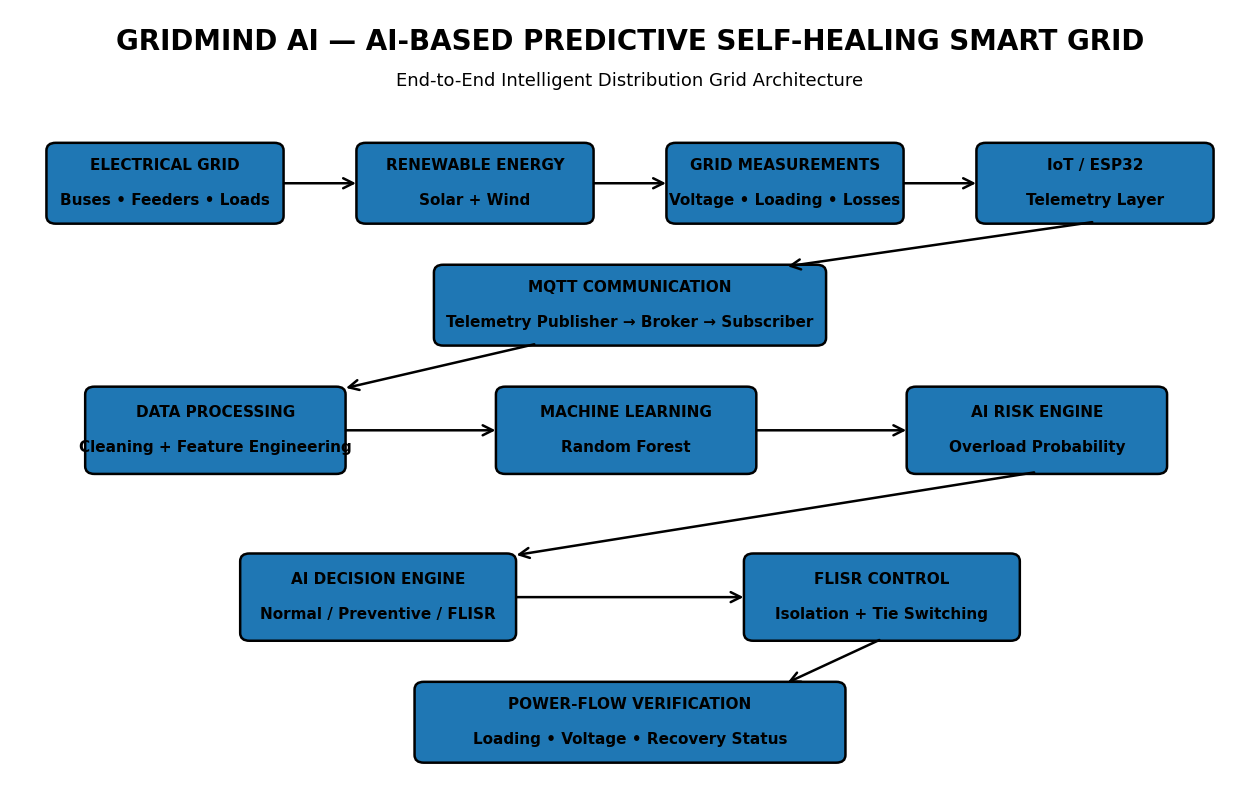

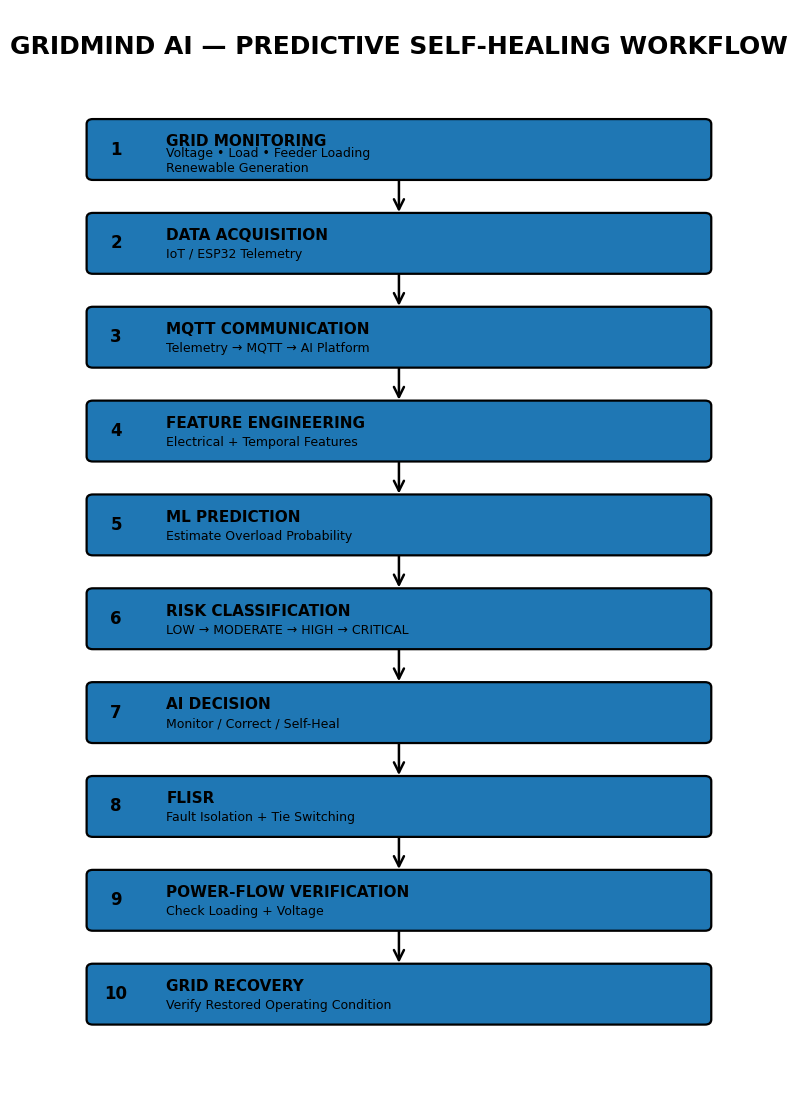

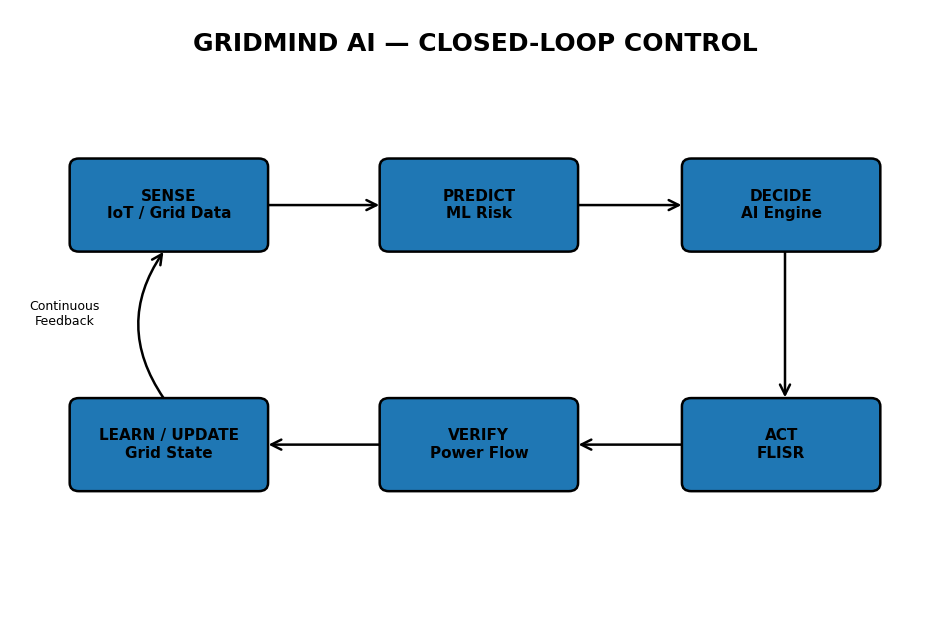


🎨 STEP 33 COMPLETED
📌 GRIDMIND_AI_SYSTEM_ARCHITECTURE.png
📌 GRIDMIND_AI_SELF_HEALING_WORKFLOW.png
📌 GRIDMIND_AI_CLOSED_LOOP.png

These diagrams are ready for:
✅ Project PPT
✅ Final-year project report
✅ Research documentation
✅ GitHub README
✅ Viva / project demonstration


In [102]:
# ============================================================
# GRIDMIND AI — STEP 33
# VISUAL SYSTEM ARCHITECTURE + WORKFLOW DIAGRAMS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os

print("🎨 GRIDMIND AI — STEP 33")
print("VISUAL SYSTEM ARCHITECTURE GENERATOR")
print("=" * 80)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "/content/GRIDMIND_AI_OUTPUT"

os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================================
# DIAGRAM 1 — COMPLETE SYSTEM ARCHITECTURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 10)
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis("off")

# Title

ax.text(
    8,
    11.5,
    "GRIDMIND AI — AI-BASED PREDICTIVE SELF-HEALING SMART GRID",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    8,
    10.9,
    "End-to-End Intelligent Distribution Grid Architecture",
    ha="center",
    va="center",
    fontsize=13
)


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def add_box(
    x,
    y,
    w,
    h,
    text,
    fontsize=11
):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.8
    )

    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold"
    )


def add_arrow(
    x1,
    y1,
    x2,
    y2
):

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.8
    )

    ax.add_patch(
        arrow
    )


# ------------------------------------------------------------
# ROW 1 — PHYSICAL GRID
# ------------------------------------------------------------

add_box(
    0.5,
    8.7,
    3.0,
    1.2,
    "ELECTRICAL GRID\n\nBuses • Feeders • Loads"
)

add_box(
    4.5,
    8.7,
    3.0,
    1.2,
    "RENEWABLE ENERGY\n\nSolar + Wind"
)

add_box(
    8.5,
    8.7,
    3.0,
    1.2,
    "GRID MEASUREMENTS\n\nVoltage • Loading • Losses"
)

add_box(
    12.5,
    8.7,
    3.0,
    1.2,
    "IoT / ESP32\n\nTelemetry Layer"
)

add_arrow(
    3.5,
    9.3,
    4.5,
    9.3
)

add_arrow(
    7.5,
    9.3,
    8.5,
    9.3
)

add_arrow(
    11.5,
    9.3,
    12.5,
    9.3
)


# ------------------------------------------------------------
# ROW 2 — COMMUNICATION
# ------------------------------------------------------------

add_box(
    5.5,
    6.8,
    5.0,
    1.2,
    "MQTT COMMUNICATION\n\nTelemetry Publisher → Broker → Subscriber"
)

add_arrow(
    14,
    8.7,
    10,
    8.0
)


# ------------------------------------------------------------
# ROW 3 — DATA / ML
# ------------------------------------------------------------

add_box(
    1.0,
    4.8,
    3.3,
    1.3,
    "DATA PROCESSING\n\nCleaning + Feature Engineering"
)

add_box(
    6.3,
    4.8,
    3.3,
    1.3,
    "MACHINE LEARNING\n\nRandom Forest"
)

add_box(
    11.6,
    4.8,
    3.3,
    1.3,
    "AI RISK ENGINE\n\nOverload Probability"
)

add_arrow(
    6.8,
    6.8,
    4.3,
    6.1
)

add_arrow(
    4.3,
    5.45,
    6.3,
    5.45
)

add_arrow(
    9.6,
    5.45,
    11.6,
    5.45
)


# ------------------------------------------------------------
# ROW 4 — CONTROL
# ------------------------------------------------------------

add_box(
    3.0,
    2.2,
    3.5,
    1.3,
    "AI DECISION ENGINE\n\nNormal / Preventive / FLISR"
)

add_box(
    9.5,
    2.2,
    3.5,
    1.3,
    "FLISR CONTROL\n\nIsolation + Tie Switching"
)

add_arrow(
    13.25,
    4.8,
    6.5,
    3.5
)

add_arrow(
    6.5,
    2.85,
    9.5,
    2.85
)


# ------------------------------------------------------------
# ROW 5 — VERIFICATION
# ------------------------------------------------------------

add_box(
    5.25,
    0.3,
    5.5,
    1.2,
    "POWER-FLOW VERIFICATION\n\nLoading • Voltage • Recovery Status"
)

add_arrow(
    11.25,
    2.2,
    10,
    1.5
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

architecture_path = (
    f"{output_dir}/GRIDMIND_AI_SYSTEM_ARCHITECTURE.png"
)

plt.savefig(
    architecture_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# DIAGRAM 2 — AI SELF-HEALING WORKFLOW
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 14)
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 17)
ax.axis("off")

ax.text(
    5,
    16.3,
    "GRIDMIND AI — PREDICTIVE SELF-HEALING WORKFLOW",
    ha="center",
    fontsize=18,
    fontweight="bold"
)


workflow = [

    (
        "1",
        "GRID MONITORING",
        "Voltage • Load • Feeder Loading\nRenewable Generation"
    ),

    (
        "2",
        "DATA ACQUISITION",
        "IoT / ESP32 Telemetry"
    ),

    (
        "3",
        "MQTT COMMUNICATION",
        "Telemetry → MQTT → AI Platform"
    ),

    (
        "4",
        "FEATURE ENGINEERING",
        "Electrical + Temporal Features"
    ),

    (
        "5",
        "ML PREDICTION",
        "Estimate Overload Probability"
    ),

    (
        "6",
        "RISK CLASSIFICATION",
        "LOW → MODERATE → HIGH → CRITICAL"
    ),

    (
        "7",
        "AI DECISION",
        "Monitor / Correct / Self-Heal"
    ),

    (
        "8",
        "FLISR",
        "Fault Isolation + Tie Switching"
    ),

    (
        "9",
        "POWER-FLOW VERIFICATION",
        "Check Loading + Voltage"
    ),

    (
        "10",
        "GRID RECOVERY",
        "Verify Restored Operating Condition"
    )
]


start_y = 14.8

for i, (num, title, desc) in enumerate(workflow):

    y = start_y - i * 1.48

    box = FancyBboxPatch(
        (1.0, y - 0.45),
        8.0,
        0.9,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.6
    )

    ax.add_patch(
        box
    )

    ax.text(
        1.35,
        y,
        num,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        2.0,
        y + 0.12,
        title,
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        2.0,
        y - 0.18,
        desc,
        ha="left",
        va="center",
        fontsize=9
    )

    if i < len(workflow) - 1:

        add_arrow(
            5,
            y - 0.45,
            5,
            y - 1.03
        )


workflow_path = (
    f"{output_dir}/GRIDMIND_AI_SELF_HEALING_WORKFLOW.png"
)

plt.savefig(
    workflow_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# DIAGRAM 3 — AI CONTROL LOOP
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.set_xlim(0, 12)
ax.set_ylim(0, 9)
ax.axis("off")

ax.text(
    6,
    8.4,
    "GRIDMIND AI — CLOSED-LOOP CONTROL",
    ha="center",
    fontsize=18,
    fontweight="bold"
)


# Boxes

add_box(
    0.8,
    5.5,
    2.5,
    1.3,
    "SENSE\nIoT / Grid Data"
)

add_box(
    4.8,
    5.5,
    2.5,
    1.3,
    "PREDICT\nML Risk"
)

add_box(
    8.7,
    5.5,
    2.5,
    1.3,
    "DECIDE\nAI Engine"
)

add_box(
    8.7,
    2.0,
    2.5,
    1.3,
    "ACT\nFLISR"
)

add_box(
    4.8,
    2.0,
    2.5,
    1.3,
    "VERIFY\nPower Flow"
)

add_box(
    0.8,
    2.0,
    2.5,
    1.3,
    "LEARN / UPDATE\nGrid State"
)


# Arrows

add_arrow(
    3.3,
    6.15,
    4.8,
    6.15
)

add_arrow(
    7.3,
    6.15,
    8.7,
    6.15
)

add_arrow(
    10,
    5.5,
    10,
    3.3
)

add_arrow(
    8.7,
    2.65,
    7.3,
    2.65
)

add_arrow(
    4.8,
    2.65,
    3.3,
    2.65
)

# Feedback loop

feedback = FancyArrowPatch(
    (2.0, 3.3),
    (2.0, 5.5),
    connectionstyle="arc3,rad=-0.35",
    arrowstyle="->",
    mutation_scale=18,
    linewidth=1.8
)

ax.add_patch(
    feedback
)

ax.text(
    0.7,
    4.4,
    "Continuous\nFeedback",
    fontsize=9,
    ha="center"
)


control_loop_path = (
    f"{output_dir}/GRIDMIND_AI_CLOSED_LOOP.png"
)

plt.savefig(
    control_loop_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("🎨 STEP 33 COMPLETED")
print("=" * 80)

print(
    "📌 GRIDMIND_AI_SYSTEM_ARCHITECTURE.png"
)

print(
    "📌 GRIDMIND_AI_SELF_HEALING_WORKFLOW.png"
)

print(
    "📌 GRIDMIND_AI_CLOSED_LOOP.png"
)

print("\nThese diagrams are ready for:")

print("✅ Project PPT")
print("✅ Final-year project report")
print("✅ Research documentation")
print("✅ GitHub README")
print("✅ Viva / project demonstration")

print("=" * 80)